# Notebook 10 — LLM feature-citation grounding and attribution agreement

## Purpose

This notebook provides a supporting reproducibility analysis for the feature-attribution component of the team’s RQ3:

> To what extent do features cited by the LLM agree with independent instance-level feature attributions from Logistic Regression and Random Forest?

The analysis uses the frozen 200-sample, 46-feature pilot dataset and the validated LLM responses exported by Notebook 09. The primary comparison is restricted to the 178 samples with valid responses under both the structured-JSON and deterministic-text conditions.

## Analysis boundaries

This notebook evaluates:

1. whether cited feature names are valid and grounded in the supplied 46-feature input;
2. the sample-level agreement between the LLM’s five cited features and the top-five held-out feature attributions from Logistic Regression and Random Forest;
3. whether attribution agreement differs between structured JSON and deterministic text;
4. exploratory variation by true class and prediction correctness.

The LLM output contains a predicted label and five cited feature names, but no unrestricted natural-language explanation. Consequently, this notebook evaluates **citation grounding and attribution agreement**, not the overall usefulness, causal validity, or faithfulness of a complete natural-language rationale.

All baseline attribution references must preserve the fixed five-fold out-of-fold design. Attribution for each sample must be produced by a model fitted without that sample. Transformed predictors, including one-hot encoded categorical levels, must be aggregated back to the original 46-feature contract before comparison with LLM citations.

No LLM requests are made, no frozen predictions are changed, and no Notebook 09 metrics are recalculated or overwritten.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys

import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------------------
# 1. Locate the repository without assuming the notebook launch folder
# ---------------------------------------------------------------------
def find_project_root(start_path):
    start_path = Path(start_path).resolve()

    for candidate in [start_path, *start_path.parents]:
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "results").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the project root. Expected a parent directory "
        "containing both 'notebooks/' and 'results/'."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
NOTEBOOK_09_EXPORT_DIRECTORY = (
    PROJECT_ROOT / "results" / "evaluation" / "primary_46"
)

if not NOTEBOOK_09_EXPORT_DIRECTORY.is_dir():
    raise RuntimeError(
        "Notebook 09 export directory was not found:\n"
        f"{NOTEBOOK_09_EXPORT_DIRECTORY}"
    )


# ---------------------------------------------------------------------
# 2. Read-only inventory of the frozen Notebook 09 export package
# ---------------------------------------------------------------------
artifact_paths = sorted(
    path
    for path in NOTEBOOK_09_EXPORT_DIRECTORY.rglob("*")
    if path.is_file()
)

if not artifact_paths:
    raise RuntimeError(
        "The Notebook 09 export directory exists but contains no files."
    )

artifact_inventory = pd.DataFrame(
    [
        {
            "relative_path": path.relative_to(PROJECT_ROOT).as_posix(),
            "file_name": path.name,
            "suffix": path.suffix.lower(),
            "size_bytes": path.stat().st_size,
        }
        for path in artifact_paths
    ]
).sort_values(
    ["relative_path"],
    kind="stable",
).reset_index(drop=True)

manifest_candidates = [
    path
    for path in artifact_paths
    if "manifest" in path.name.lower()
    and path.suffix.lower() == ".json"
]

csv_candidates = [
    path
    for path in artifact_paths
    if path.suffix.lower() == ".csv"
]

json_candidates = [
    path
    for path in artifact_paths
    if path.suffix.lower() == ".json"
]


# ---------------------------------------------------------------------
# 3. Display the handoff inventory; do not select files yet
# ---------------------------------------------------------------------
handoff_environment_summary = pd.Series(
    {
        "project_root": str(PROJECT_ROOT),
        "notebook_09_export_directory": str(
            NOTEBOOK_09_EXPORT_DIRECTORY
        ),
        "artifact_count": len(artifact_paths),
        "csv_count": len(csv_candidates),
        "json_count": len(json_candidates),
        "manifest_candidate_count": len(manifest_candidates),
        "python_version": sys.version.split()[0],
        "platform": platform.platform(),
        "files_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_10_phase": "read_only_notebook_09_handoff_inventory",
    },
    name="value",
)

print("Notebook 10 handoff environment:")
display(handoff_environment_summary)

print("\nFrozen Notebook 09 artifact inventory:")
display(artifact_inventory)

print("\nManifest candidates:")
if manifest_candidates:
    display(
        pd.DataFrame(
            {
                "relative_path": [
                    path.relative_to(PROJECT_ROOT).as_posix()
                    for path in manifest_candidates
                ],
                "size_bytes": [
                    path.stat().st_size
                    for path in manifest_candidates
                ],
            }
        )
    )
else:
    print("No JSON file containing 'manifest' in its filename was found.")

print(
    "\nRead-only handoff inventory completed. "
    "No file was written and no experimental object was modified."
)

Notebook 10 handoff environment:


project_root                        /Users/ruiwang/Developer/compsci742-rui-pilot
notebook_09_export_directory    /Users/ruiwang/Developer/compsci742-rui-pilot/...
artifact_count                                                                 50
csv_count                                                                      28
json_count                                                                      2
manifest_candidate_count                                                        1
python_version                                                            3.11.14
platform                                             macOS-15.7.3-arm64-arm-64bit
files_written_by_this_cell                                                  False
network_request_made                                                        False
notebook_10_phase                         read_only_notebook_09_handoff_inventory
Name: value, dtype: object


Frozen Notebook 09 artifact inventory:


,relative_path,file_name,suffix,size_bytes
0,results/evaluation/primary_46/diagnostics/abla...,ablation_categorical_feature_names.csv,.csv,149
1,results/evaluation/primary_46/diagnostics/abla...,ablation_change_metric_order.csv,.csv,61
2,results/evaluation/primary_46/diagnostics/abla...,ablation_feature_names.csv,.csv,783
3,results/evaluation/primary_46/diagnostics/abla...,ablation_figure_metrics.csv,.csv,48
4,results/evaluation/primary_46/diagnostics/abla...,ablation_metric_records.csv,.csv,387
5,results/evaluation/primary_46/diagnostics/abla...,ablation_oof_prediction_table.csv,.csv,3290
6,results/evaluation/primary_46/diagnostics/abla...,ablation_point_metrics_table.csv,.csv,387
7,results/evaluation/primary_46/diagnostics/abla...,ablation_predictor_matrix.csv,.csv,30622
8,results/evaluation/primary_46/diagnostics/abla...,ablation_quantitative_feature_names.csv,.csv,636
9,results/evaluation/primary_46/diagnostics/abla...,ablation_row.csv,.csv,271



Manifest candidates:


,relative_path,size_bytes
0,results/evaluation/primary_46/notebook_09_eval...,20797



Read-only handoff inventory completed. No file was written and no experimental object was modified.


## 1. Frozen Notebook 09 handoff validation

Before any explanation-alignment analysis, the final Notebook 09 manifest is inspected directly. This establishes the provenance and readiness of the frozen evaluation package without relying on in-memory objects from the previous notebook.

This stage is read-only. It does not modify the manifest, recalculate metrics, regenerate predictions, refit models, or write any Notebook 10 result.

In [2]:
# ---------------------------------------------------------------------
# Read and inspect the exact final Notebook 09 manifest
# ---------------------------------------------------------------------
MANIFEST_PATH = (
    NOTEBOOK_09_EXPORT_DIRECTORY
    / "notebook_09_evaluation_manifest.json"
)

if not MANIFEST_PATH.is_file():
    raise RuntimeError(
        "The final Notebook 09 manifest was not found:\n"
        f"{MANIFEST_PATH}"
    )

manifest_bytes = MANIFEST_PATH.read_bytes()
manifest_sha256 = hashlib.sha256(manifest_bytes).hexdigest()

try:
    notebook_09_manifest = json.loads(
        manifest_bytes.decode("utf-8")
    )
except (UnicodeDecodeError, json.JSONDecodeError) as error:
    raise RuntimeError(
        "The Notebook 09 manifest could not be decoded as valid UTF-8 JSON."
    ) from error

if not isinstance(notebook_09_manifest, dict):
    raise RuntimeError(
        "The Notebook 09 manifest must contain a JSON object at its root, "
        f"but found {type(notebook_09_manifest).__name__}."
    )


# ---------------------------------------------------------------------
# Describe the top-level structure without assuming a schema
# ---------------------------------------------------------------------
def value_structure(value):
    if isinstance(value, dict):
        return "dict", len(value)
    if isinstance(value, list):
        return "list", len(value)
    return type(value).__name__, None


manifest_structure_records = []

for key, value in notebook_09_manifest.items():
    value_type, item_count = value_structure(value)
    manifest_structure_records.append(
        {
            "top_level_key": key,
            "value_type": value_type,
            "item_count": item_count,
        }
    )

manifest_structure_table = (
    pd.DataFrame(manifest_structure_records)
    .sort_values("top_level_key", kind="stable")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Find critical fields recursively, without assuming their location
# ---------------------------------------------------------------------
critical_field_names = {
    "ready_for_notebook_10",
    "manifest_status",
    "check_count",
    "passed_check_count",
    "failed_check_count",
    "artifact_hashes_matched",
    "figure_hashes_matched",
    "baseline_oof_sample_rows",
    "baseline_model_specific_predictions",
    "models_refitted",
    "predictions_regenerated",
    "metrics_modified",
    "network_request_made",
    "notebook_09_phase",
}


def collect_named_fields(value, path="$"):
    matches = []

    if isinstance(value, dict):
        for key, child_value in value.items():
            child_path = f"{path}.{key}"

            if key in critical_field_names:
                matches.append(
                    {
                        "json_path": child_path,
                        "field_name": key,
                        "value": child_value,
                        "value_type": type(child_value).__name__,
                    }
                )

            matches.extend(
                collect_named_fields(child_value, child_path)
            )

    elif isinstance(value, list):
        for index, child_value in enumerate(value):
            matches.extend(
                collect_named_fields(
                    child_value,
                    f"{path}[{index}]",
                )
            )

    return matches


critical_field_records = collect_named_fields(
    notebook_09_manifest
)

critical_field_table = pd.DataFrame(
    critical_field_records,
    columns=[
        "json_path",
        "field_name",
        "value",
        "value_type",
    ],
)

if not critical_field_table.empty:
    critical_field_table = (
        critical_field_table
        .sort_values(
            ["field_name", "json_path"],
            kind="stable",
        )
        .reset_index(drop=True)
    )

found_critical_fields = set(
    critical_field_table["field_name"].tolist()
) if not critical_field_table.empty else set()

missing_critical_fields = sorted(
    critical_field_names - found_critical_fields
)


# ---------------------------------------------------------------------
# Display read-only inspection results
# ---------------------------------------------------------------------
manifest_file_summary = pd.Series(
    {
        "manifest_relative_path": (
            MANIFEST_PATH.relative_to(PROJECT_ROOT).as_posix()
        ),
        "manifest_size_bytes": len(manifest_bytes),
        "manifest_sha256": manifest_sha256,
        "json_root_type": type(notebook_09_manifest).__name__,
        "top_level_key_count": len(notebook_09_manifest),
        "critical_field_match_count": len(
            critical_field_table
        ),
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "read_only_manifest_schema_inspection"
        ),
    },
    name="value",
)

print("Notebook 09 manifest file summary:")
display(manifest_file_summary)

print("\nManifest top-level structure:")
display(manifest_structure_table)

print("\nCritical manifest fields found recursively:")
if critical_field_table.empty:
    print("No requested critical fields were found.")
else:
    display(critical_field_table)

print("\nRequested critical field names not found:")
if missing_critical_fields:
    display(
        pd.Series(
            missing_critical_fields,
            name="missing_field_name",
        )
    )
else:
    print("None")

print(
    "\nRead-only manifest inspection completed. "
    "No file was written and no experimental object was modified."
)

Notebook 09 manifest file summary:


manifest_relative_path           results/evaluation/primary_46/notebook_09_eval...
manifest_size_bytes                                                          20797
manifest_sha256                  96948ed8fc06c55bc3ee486d4e3c039fff264e0832f594...
json_root_type                                                                dict
top_level_key_count                                                             37
critical_field_match_count                                                       8
files_written_by_this_cell                                                   False
experimental_objects_modified                                                False
network_request_made                                                         False
notebook_10_phase                             read_only_manifest_schema_inspection
Name: value, dtype: object


Manifest top-level structure:


,top_level_key,value_type,item_count
0,analysis_contract,dict,16.0
1,artifacts,list,29.0
2,created_utc,str,NaN
3,existing_figures_modified_by_export,bool,NaN
4,export_corrections,list,1.0
5,figure_discovery,dict,2.0
6,figures,list,10.0
7,figures_modified_by_correction,bool,NaN
8,figures_modified_by_correction_or_gate,bool,NaN
9,figures_modified_by_finalisation,bool,NaN



Critical manifest fields found recursively:


,json_path,field_name,value,value_type
0,$.integrity_gate.check_count,check_count,36,int
1,$.integrity_gate.failed_check_count,failed_check_count,0,int
2,$.manifest_status,manifest_status,final_integrity_gate_passed,str
3,$.export_corrections[0].models_refitted,models_refitted,False,bool
4,$.network_request_made,network_request_made,False,bool
5,$.integrity_gate.passed_check_count,passed_check_count,36,int
6,$.export_corrections[0].predictions_regenerated,predictions_regenerated,False,bool
7,$.ready_for_notebook_10,ready_for_notebook_10,True,bool



Requested critical field names not found:


0                artifact_hashes_matched
1    baseline_model_specific_predictions
2               baseline_oof_sample_rows
3                  figure_hashes_matched
4                       metrics_modified
5                      notebook_09_phase
Name: missing_field_name, dtype: str


Read-only manifest inspection completed. No file was written and no experimental object was modified.


In [3]:
# ---------------------------------------------------------------------
# Inspect the confirmed manifest sections and record schemas
# ---------------------------------------------------------------------
required_top_level_sections = [
    "analysis_contract",
    "integrity_gate",
    "oof_storage_contract",
    "primary_rq1_result",
    "source_variables",
    "artifacts",
    "figures",
]

missing_top_level_sections = [
    section_name
    for section_name in required_top_level_sections
    if section_name not in notebook_09_manifest
]

if missing_top_level_sections:
    raise RuntimeError(
        "The following required manifest sections are missing: "
        f"{missing_top_level_sections}"
    )


def manifest_mapping_to_table(section_name, mapping):
    if not isinstance(mapping, dict):
        raise RuntimeError(
            f"Manifest section '{section_name}' must be a dictionary, "
            f"but found {type(mapping).__name__}."
        )

    records = []

    for key, value in mapping.items():
        if isinstance(value, (dict, list)):
            displayed_value = json.dumps(
                value,
                ensure_ascii=False,
                sort_keys=True,
            )
        else:
            displayed_value = value

        records.append(
            {
                "section": section_name,
                "field": key,
                "value": displayed_value,
                "value_type": type(value).__name__,
            }
        )

    return pd.DataFrame(records)


manifest_contract_tables = {
    section_name: manifest_mapping_to_table(
        section_name,
        notebook_09_manifest[section_name],
    )
    for section_name in [
        "analysis_contract",
        "integrity_gate",
        "oof_storage_contract",
        "primary_rq1_result",
        "source_variables",
    ]
}


def normalise_manifest_record_list(section_name):
    records = notebook_09_manifest[section_name]

    if not isinstance(records, list):
        raise RuntimeError(
            f"Manifest section '{section_name}' must be a list, "
            f"but found {type(records).__name__}."
        )

    non_dictionary_indices = [
        index
        for index, record in enumerate(records)
        if not isinstance(record, dict)
    ]

    if non_dictionary_indices:
        raise RuntimeError(
            f"Manifest section '{section_name}' contains non-dictionary "
            f"records at indices {non_dictionary_indices}."
        )

    if not records:
        return pd.DataFrame()

    return pd.json_normalize(records, sep=".")


manifest_artifact_records = normalise_manifest_record_list(
    "artifacts"
)
manifest_figure_records = normalise_manifest_record_list(
    "figures"
)


# ---------------------------------------------------------------------
# Display the exact schemas and values
# ---------------------------------------------------------------------
for section_name, section_table in manifest_contract_tables.items():
    print(f"\nManifest section: {section_name}")
    display(section_table)

print("\nArtifact-record table shape:")
print(manifest_artifact_records.shape)

print("\nArtifact-record column names:")
display(
    pd.Series(
        manifest_artifact_records.columns.tolist(),
        name="artifact_record_column",
    )
)

print("\nFirst five artifact records:")
display(manifest_artifact_records.head(5))

print("\nFigure-record table shape:")
print(manifest_figure_records.shape)

print("\nFigure-record column names:")
display(
    pd.Series(
        manifest_figure_records.columns.tolist(),
        name="figure_record_column",
    )
)

print("\nAll figure records:")
display(manifest_figure_records)

manifest_schema_inspection_summary = pd.Series(
    {
        "required_top_level_section_count": len(
            required_top_level_sections
        ),
        "missing_top_level_section_count": len(
            missing_top_level_sections
        ),
        "manifest_artifact_record_count": len(
            manifest_artifact_records
        ),
        "manifest_figure_record_count": len(
            manifest_figure_records
        ),
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "read_only_manifest_contract_and_record_inspection"
        ),
    },
    name="value",
)

print("\nManifest schema inspection summary:")
display(manifest_schema_inspection_summary)

print(
    "\nManifest contract and record-schema inspection completed. "
    "No file was written and no experimental object was modified."
)


Manifest section: analysis_contract


,section,field,value,value_type
0,analysis_contract,fixed_pilot_sample_count,200,int
1,analysis_contract,benign_sample_count,100,int
2,analysis_contract,dos_sample_count,100,int
3,analysis_contract,locked_primary_feature_count,46,int
4,analysis_contract,planned_llm_request_count,400,int
5,analysis_contract,valid_llm_response_count,359,int
6,analysis_contract,complete_pair_count,178,int
7,analysis_contract,complete_pair_benign_count,92,int
8,analysis_contract,complete_pair_dos_count,86,int
9,analysis_contract,baseline_model_count,2,int



Manifest section: integrity_gate


,section,field,value,value_type
0,integrity_gate,completed_utc,2026-09-04T10:37:48.726030+00:00,str
1,integrity_gate,check_count,36,int
2,integrity_gate,passed_check_count,36,int
3,integrity_gate,failed_check_count,0,int
4,integrity_gate,all_checks_passed,True,bool



Manifest section: oof_storage_contract


...


All figure records:


,figure_number,png_path,png_sha256,pdf_path,pdf_sha256
0,1,/Users/ruiwang/Developer/compsci742-rui-pilot/...,2deabaeeeb081bb90d849c190e5bbcfcd4f341026af55f...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,ae64cb7a79f854412d37d167e9901c7d4abced279fea7e...
1,2,/Users/ruiwang/Developer/compsci742-rui-pilot/...,856dcb84b755fcf98234ccb1010aca0a5a9e3b807e17b0...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,8e64acdad217aa54cf3ee8be66a3e0a18dde67027f9952...
2,3,/Users/ruiwang/Developer/compsci742-rui-pilot/...,7f2689c7e056b7faaea030b411c4591d09c74c5c7ac78a...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,1058c1e9ce6c6186079ea44ea108352116929fea35456a...
3,4,/Users/ruiwang/Developer/compsci742-rui-pilot/...,30c7d18285f9b023541d5a358679404b3033be6ae12628...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,7190279c98dd8e076b89c1f7d3ef4886a0dca51df0e59e...
4,5,/Users/ruiwang/Developer/compsci742-rui-pilot/...,a8fe8957c5d3c499bc41cd786884ff471606c7d3d9d3ff...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,e862d429b950bb074a5368ab3ccfd5525ec2eab8f2daf4...
5,6,/Users/ruiwang/Developer/compsci742-rui-pilot/...,bc737786840ccb957720d3dbe3f42c82a91700ab0bdd57...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,787c57a2ea89a72e62056460c97bafab8d9bf6d44b990c...
6,7,/Users/ruiwang/Developer/compsci742-rui-pilot/...,8c18115a5b8c552746931be08d29641fb7cca20722c149...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,1266d8f7192c0fe449b612fb0c3c739b7fe0b86fb402e3...
7,8,/Users/ruiwang/Developer/compsci742-rui-pilot/...,234c079e1a888b21e67a7e268e14960a55d418acacf2a0...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,029a977b7546d83892a9cc5f1538bdbb1d034e6eaf160f...
8,9,/Users/ruiwang/Developer/compsci742-rui-pilot/...,573b12eed98b77a31106f35ac249e6b4414e8b3736de42...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,3878ca2ba0f7e20f9105735a17a8814de033342a7f2b73...
9,10,/Users/ruiwang/Developer/compsci742-rui-pilot/...,76f4e9d0f069247e44d5482f925009e0242afdfb43c42c...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,fc09f86ae1c02e8920f10664368cc4b066977a65684c27...



Manifest schema inspection summary:


required_top_level_section_count                                                    7
missing_top_level_section_count                                                     0
manifest_artifact_record_count                                                     29
manifest_figure_record_count                                                       10
files_written_by_this_cell                                                      False
experimental_objects_modified                                                   False
network_request_made                                                            False
notebook_10_phase                   read_only_manifest_contract_and_record_inspection
Name: value, dtype: object


Manifest contract and record-schema inspection completed. No file was written and no experimental object was modified.


## 2. Strict Notebook 09 handoff gate

The frozen Notebook 09 package is accepted only if its declared analysis contract, primary RQ1 results, OOF storage contract, exported artifacts, and Figure 1–10 files independently match the final manifest.

File sizes and SHA-256 hashes are recomputed from disk. Absolute paths recorded by Notebook 09 are not treated as the sole source of truth; project-relative paths are used wherever available to preserve portability.

Failure of any check stops Notebook 10 before analytical data are loaded.

In [4]:
# ---------------------------------------------------------------------
# Strict, read-only Notebook 09 handoff gate
# ---------------------------------------------------------------------
handoff_checks = []


def add_handoff_check(check, observed, expected, passed):
    handoff_checks.append(
        {
            "check": check,
            "observed": observed,
            "expected": expected,
            "passed": bool(passed),
        }
    )


def sha256_file(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def values_close(observed, expected, tolerance=1e-6):
    try:
        return bool(
            np.isclose(
                float(observed),
                float(expected),
                rtol=0.0,
                atol=tolerance,
            )
        )
    except (TypeError, ValueError):
        return False


def resolve_project_figure_path(recorded_path):
    recorded_path = Path(str(recorded_path))

    candidate_paths = []

    if recorded_path.is_absolute():
        candidate_paths.append(recorded_path)
    else:
        candidate_paths.append(PROJECT_ROOT / recorded_path)

    candidate_paths.append(
        NOTEBOOK_09_EXPORT_DIRECTORY
        / "figures"
        / recorded_path.name
    )

    resolved_candidates = []

    for candidate_path in candidate_paths:
        resolved_candidate = candidate_path.resolve()

        try:
            resolved_candidate.relative_to(PROJECT_ROOT)
        except ValueError:
            continue

        if (
            resolved_candidate.is_file()
            and resolved_candidate
            not in resolved_candidates
        ):
            resolved_candidates.append(resolved_candidate)

    if len(resolved_candidates) != 1:
        return None

    return resolved_candidates[0]


# ---------------------------------------------------------------------
# 1. Final manifest status
# ---------------------------------------------------------------------
integrity_gate_contract = notebook_09_manifest[
    "integrity_gate"
]

add_handoff_check(
    "Manifest status",
    notebook_09_manifest.get("manifest_status"),
    "final_integrity_gate_passed",
    notebook_09_manifest.get("manifest_status")
    == "final_integrity_gate_passed",
)

add_handoff_check(
    "Ready for Notebook 10",
    notebook_09_manifest.get("ready_for_notebook_10"),
    True,
    notebook_09_manifest.get("ready_for_notebook_10")
    is True,
)

add_handoff_check(
    "Integrity gate completed",
    notebook_09_manifest.get("integrity_gate_completed"),
    True,
    notebook_09_manifest.get("integrity_gate_completed")
    is True,
)

add_handoff_check(
    "Notebook 09 gate check count",
    integrity_gate_contract.get("check_count"),
    36,
    integrity_gate_contract.get("check_count") == 36,
)

add_handoff_check(
    "Notebook 09 passed-check count",
    integrity_gate_contract.get("passed_check_count"),
    36,
    integrity_gate_contract.get("passed_check_count")
    == 36,
)

add_handoff_check(
    "Notebook 09 failed-check count",
    integrity_gate_contract.get("failed_check_count"),
    0,
    integrity_gate_contract.get("failed_check_count")
    == 0,
)

add_handoff_check(
    "Notebook 09 all-checks-passed flag",
    integrity_gate_contract.get("all_checks_passed"),
    True,
    integrity_gate_contract.get("all_checks_passed")
    is True,
)


# ---------------------------------------------------------------------
# 2. Frozen analysis contract
# ---------------------------------------------------------------------
analysis_contract = notebook_09_manifest[
    "analysis_contract"
]

expected_analysis_contract = {
    "fixed_pilot_sample_count": 200,
    "benign_sample_count": 100,
    "dos_sample_count": 100,
    "locked_primary_feature_count": 46,
    "planned_llm_request_count": 400,
    "valid_llm_response_count": 359,
    "complete_pair_count": 178,
    "complete_pair_benign_count": 92,
    "complete_pair_dos_count": 86,
    "baseline_model_count": 2,
    "cross_validation_fold_count": 5,
    "cross_validation_seed": 742,
    "bootstrap_replicate_count": 10000,
    "bootstrap_seed": 742,
    "baseline_oof_sample_row_count": 200,
    "baseline_oof_model_specific_prediction_count": 400,
}

for field_name, expected_value in (
    expected_analysis_contract.items()
):
    observed_value = analysis_contract.get(field_name)

    add_handoff_check(
        f"Analysis contract: {field_name}",
        observed_value,
        expected_value,
        observed_value == expected_value,
    )


# ---------------------------------------------------------------------
# 3. Frozen OOF storage contract
# ---------------------------------------------------------------------
oof_storage_contract = notebook_09_manifest[
    "oof_storage_contract"
]

expected_oof_columns = [
    "sample_id",
    "true_binary",
    "cv_fold",
    "logistic_regression_predicted_binary",
    "logistic_regression_dos_probability",
    "random_forest_predicted_binary",
    "random_forest_dos_probability",
]

expected_oof_contract = {
    "format": "wide_one_row_per_sample",
    "sample_row_count": 200,
    "model_count": 2,
    "model_specific_prediction_count": 400,
}

for field_name, expected_value in (
    expected_oof_contract.items()
):
    observed_value = oof_storage_contract.get(field_name)

    add_handoff_check(
        f"OOF storage contract: {field_name}",
        observed_value,
        expected_value,
        observed_value == expected_value,
    )

observed_oof_columns = oof_storage_contract.get("columns")

add_handoff_check(
    "OOF storage contract: exact ordered columns",
    observed_oof_columns,
    expected_oof_columns,
    observed_oof_columns == expected_oof_columns,
)


# ---------------------------------------------------------------------
# 4. Frozen primary RQ1 results
# ---------------------------------------------------------------------
primary_rq1_result = notebook_09_manifest[
    "primary_rq1_result"
]

expected_primary_scalar_results = {
    "structured_json_accuracy": 0.500000,
    "deterministic_text_accuracy": 0.421348,
    "paired_accuracy_difference": 0.078652,
    "mcnemar_exact_two_sided_p_value": 0.043559,
}

for field_name, expected_value in (
    expected_primary_scalar_results.items()
):
    observed_value = primary_rq1_result.get(field_name)

    add_handoff_check(
        f"Primary RQ1 result: {field_name}",
        observed_value,
        expected_value,
        values_close(
            observed_value,
            expected_value,
            tolerance=1e-6,
        ),
    )

observed_accuracy_ci = primary_rq1_result.get(
    "paired_accuracy_bootstrap_95_ci"
)
expected_accuracy_ci = [0.0112, 0.1461]

accuracy_ci_passed = (
    isinstance(observed_accuracy_ci, list)
    and len(observed_accuracy_ci) == 2
    and np.allclose(
        np.asarray(observed_accuracy_ci, dtype=float),
        np.asarray(expected_accuracy_ci, dtype=float),
        rtol=0.0,
        atol=1e-6,
    )
)

add_handoff_check(
    "Primary RQ1 result: paired accuracy 95% CI",
    observed_accuracy_ci,
    expected_accuracy_ci,
    accuracy_ci_passed,
)


# ---------------------------------------------------------------------
# 5. Confirm that Notebook 09 finalisation did not alter results
# ---------------------------------------------------------------------
expected_false_manifest_flags = [
    "existing_figures_modified_by_export",
    "figures_modified_by_correction",
    "figures_modified_by_correction_or_gate",
    "figures_modified_by_finalisation",
    "metrics_recalculated_by_correction",
    "metrics_recalculated_by_export",
    "models_refitted_by_correction",
    "models_refitted_by_correction_or_gate",
    "models_refitted_by_export",
    "models_refitted_by_finalisation",
    "network_request_made",
    "network_request_made_by_correction",
    "network_request_made_by_correction_or_gate",
    "network_request_made_by_finalisation",
    "predictions_modified_by_export",
    "predictions_regenerated_by_correction",
    "predictions_regenerated_by_correction_or_gate",
    "predictions_regenerated_by_finalisation",
    "primary_metrics_modified_by_correction_or_gate",
    "primary_metrics_modified_by_finalisation",
]

for field_name in expected_false_manifest_flags:
    field_present = field_name in notebook_09_manifest
    observed_value = notebook_09_manifest.get(field_name)

    add_handoff_check(
        f"Finalisation invariant: {field_name}",
        observed_value if field_present else "<missing>",
        False,
        field_present and observed_value is False,
    )


# ---------------------------------------------------------------------
# 6. Independently verify all 29 non-figure artifacts
# ---------------------------------------------------------------------
artifact_verification_records = []

for record_index, artifact_record in (
    manifest_artifact_records.iterrows()
):
    relative_path_text = str(
        artifact_record["relative_path"]
    )
    expected_size = int(
        artifact_record["size_bytes"]
    )
    expected_sha256 = str(
        artifact_record["sha256"]
    ).lower()

    artifact_path = (
        PROJECT_ROOT / relative_path_text
    ).resolve()

    try:
        artifact_path.relative_to(PROJECT_ROOT)
        path_is_within_project = True
    except ValueError:
        path_is_within_project = False

    file_exists = (
        path_is_within_project
        and artifact_path.is_file()
    )

    observed_size = (
        artifact_path.stat().st_size
        if file_exists
        else None
    )
    observed_sha256 = (
        sha256_file(artifact_path)
        if file_exists
        else None
    )

    record_passed = (
        file_exists
        and observed_size == expected_size
        and observed_sha256 == expected_sha256
    )

    artifact_verification_records.append(
        {
            "relative_path": relative_path_text,
            "file_exists": file_exists,
            "observed_size_bytes": observed_size,
            "expected_size_bytes": expected_size,
            "size_matches": (
                observed_size == expected_size
                if file_exists
                else False
            ),
            "sha256_matches": (
                observed_sha256 == expected_sha256
                if file_exists
                else False
            ),
            "passed": record_passed,
        }
    )

artifact_verification_table = pd.DataFrame(
    artifact_verification_records
)

add_handoff_check(
    "Manifest non-figure artifact record count",
    len(artifact_verification_table),
    29,
    len(artifact_verification_table) == 29,
)

add_handoff_check(
    "All non-figure artifact hashes and sizes",
    int(artifact_verification_table["passed"].sum()),
    len(artifact_verification_table),
    bool(artifact_verification_table["passed"].all()),
)


# ---------------------------------------------------------------------
# 7. Independently verify Figure 1–10 PNG and PDF files
# ---------------------------------------------------------------------
figure_verification_records = []

for _, figure_record in manifest_figure_records.iterrows():
    figure_number = int(
        figure_record["figure_number"]
    )

    for file_format in ["png", "pdf"]:
        path_field = f"{file_format}_path"
        hash_field = f"{file_format}_sha256"

        resolved_path = resolve_project_figure_path(
            figure_record[path_field]
        )
        expected_sha256 = str(
            figure_record[hash_field]
        ).lower()

        file_exists = (
            resolved_path is not None
            and resolved_path.is_file()
        )
        observed_sha256 = (
            sha256_file(resolved_path)
            if file_exists
            else None
        )

        record_passed = (
            file_exists
            and observed_sha256 == expected_sha256
        )

        figure_verification_records.append(
            {
                "figure_number": figure_number,
                "format": file_format.upper(),
                "resolved_path": (
                    resolved_path.relative_to(
                        PROJECT_ROOT
                    ).as_posix()
                    if file_exists
                    else None
                ),
                "file_exists": file_exists,
                "sha256_matches": (
                    observed_sha256 == expected_sha256
                    if file_exists
                    else False
                ),
                "passed": record_passed,
            }
        )

figure_verification_table = pd.DataFrame(
    figure_verification_records
)

observed_figure_numbers = sorted(
    figure_verification_table[
        "figure_number"
    ].unique().tolist()
)
expected_figure_numbers = list(range(1, 11))

add_handoff_check(
    "Figure-number coverage",
    observed_figure_numbers,
    expected_figure_numbers,
    observed_figure_numbers == expected_figure_numbers,
)

add_handoff_check(
    "Figure file record count",
    len(figure_verification_table),
    20,
    len(figure_verification_table) == 20,
)

add_handoff_check(
    "All Figure 1–10 hashes",
    int(figure_verification_table["passed"].sum()),
    20,
    (
        len(figure_verification_table) == 20
        and bool(
            figure_verification_table[
                "passed"
            ].all()
        )
    ),
)


# ---------------------------------------------------------------------
# 8. Verify the complete exported-package count
# ---------------------------------------------------------------------
expected_package_file_count = (
    len(manifest_artifact_records)
    + len(figure_verification_table)
    + 1
)

add_handoff_check(
    "Complete Notebook 09 package file count",
    len(artifact_paths),
    expected_package_file_count,
    len(artifact_paths) == expected_package_file_count,
)


# ---------------------------------------------------------------------
# 9. Final handoff decision
# ---------------------------------------------------------------------
notebook_09_handoff_gate_table = pd.DataFrame(
    handoff_checks
)

notebook_09_handoff_passed = bool(
    notebook_09_handoff_gate_table["passed"].all()
)

failed_handoff_checks = (
    notebook_09_handoff_gate_table.loc[
        ~notebook_09_handoff_gate_table["passed"]
    ]
    .reset_index(drop=True)
)

notebook_09_handoff_summary = pd.Series(
    {
        "handoff_check_count": len(
            notebook_09_handoff_gate_table
        ),
        "passed_check_count": int(
            notebook_09_handoff_gate_table[
                "passed"
            ].sum()
        ),
        "failed_check_count": int(
            (
                ~notebook_09_handoff_gate_table[
                    "passed"
                ]
            ).sum()
        ),
        "verified_non_figure_artifact_count": int(
            artifact_verification_table[
                "passed"
            ].sum()
        ),
        "verified_figure_file_count": int(
            figure_verification_table[
                "passed"
            ].sum()
        ),
        "notebook_09_manifest_sha256": (
            manifest_sha256
        ),
        "notebook_09_handoff_passed": (
            notebook_09_handoff_passed
        ),
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "strict_notebook_09_handoff_gate"
        ),
    },
    name="value",
)

print("Notebook 09 strict handoff checks:")
display(notebook_09_handoff_gate_table)

print("\nNon-figure artifact verification:")
display(artifact_verification_table)

print("\nFigure-file verification:")
display(figure_verification_table)

print("\nFailed handoff checks:")
if failed_handoff_checks.empty:
    print("None")
else:
    display(failed_handoff_checks)

print("\nNotebook 09 handoff summary:")
display(notebook_09_handoff_summary)

if not notebook_09_handoff_passed:
    raise AssertionError(
        "Notebook 09 handoff gate failed. "
        "Notebook 10 analysis must not proceed."
    )

print(
    "\nNotebook 09 handoff gate passed. "
    "The frozen evaluation package is accepted for Notebook 10."
)

Notebook 09 strict handoff checks:


,check,observed,expected,passed
0,Manifest status,final_integrity_gate_passed,final_integrity_gate_passed,True
1,Ready for Notebook 10,True,True,True
2,Integrity gate completed,True,True,True
3,Notebook 09 gate check count,36,36,True
4,Notebook 09 passed-check count,36,36,True
5,Notebook 09 failed-check count,0,0,True
6,Notebook 09 all-checks-passed flag,True,True,True
7,Analysis contract: fixed_pilot_sample_count,200,200,True
8,Analysis contract: benign_sample_count,100,100,True
9,Analysis contract: dos_sample_count,100,100,True



Non-figure artifact verification:


,relative_path,file_exists,observed_size_bytes,expected_size_bytes,size_matches,sha256_matches,passed
0,results/evaluation/primary_46/llm_detection_me...,True,489,489,True,True,True
1,results/evaluation/primary_46/llm_paired_metri...,True,1795,1795,True,True,True
2,results/evaluation/primary_46/llm_paired_corre...,True,134,134,True,True,True
3,results/evaluation/primary_46/llm_paired_test_...,True,419,419,True,True,True
4,results/evaluation/primary_46/supporting_basel...,True,379,379,True,True,True
5,results/evaluation/primary_46/supporting_basel...,True,8852,8852,True,True,True
6,results/evaluation/primary_46/diagnostics/base...,True,34046,34046,True,True,True
7,results/evaluation/primary_46/diagnostics/base...,True,368,368,True,True,True
8,results/evaluation/primary_46/diagnostics/diag...,True,14,14,True,True,True
9,results/evaluation/primary_46/diagnostics/diag...,True,1113,1113,True,True,True



Figure-file verification:


,figure_number,format,resolved_path,file_exists,sha256_matches,passed
0,1,PNG,results/evaluation/primary_46/figures/figure_0...,True,True,True
1,1,PDF,results/evaluation/primary_46/figures/figure_0...,True,True,True
2,2,PNG,results/evaluation/primary_46/figures/figure_0...,True,True,True
3,2,PDF,results/evaluation/primary_46/figures/figure_0...,True,True,True
4,3,PNG,results/evaluation/primary_46/figures/figure_0...,True,True,True
5,3,PDF,results/evaluation/primary_46/figures/figure_0...,True,True,True
6,4,PNG,results/evaluation/primary_46/figures/figure_0...,True,True,True
7,4,PDF,results/evaluation/primary_46/figures/figure_0...,True,True,True
8,5,PNG,results/evaluation/primary_46/figures/figure_0...,True,True,True
9,5,PDF,results/evaluation/primary_46/figures/figure_0...,True,True,True



Failed handoff checks:
None

Notebook 09 handoff summary:


handoff_check_count                                                                  59
passed_check_count                                                                   59
failed_check_count                                                                    0
verified_non_figure_artifact_count                                                   29
verified_figure_file_count                                                           20
notebook_09_manifest_sha256           96948ed8fc06c55bc3ee486d4e3c039fff264e0832f594...
notebook_09_handoff_passed                                                         True
files_written_by_this_cell                                                        False
experimental_objects_modified                                                     False
network_request_made                                                              False
notebook_10_phase                                       strict_notebook_09_handoff_gate
Name: value, dtype: object


Notebook 09 handoff gate passed. The frozen evaluation package is accepted for Notebook 10.


## 3. Discovery of frozen analytical inputs

Notebook 09 exported aggregate LLM metrics and baseline OOF predictions, but sample-level citation analysis requires the frozen validated LLM responses and the original 46-feature pilot table produced upstream.

This step searches the repository for candidate structured-data files using filenames and paths only. It does not select an analytical source, load full datasets, or modify any file. Candidate sources will be accepted only after their schemas, row counts, sample identifiers, feature contracts, and provenance are verified.

In [5]:
# ---------------------------------------------------------------------
# Read-only discovery of upstream structured-data files
# ---------------------------------------------------------------------
structured_data_suffixes = {
    ".csv",
    ".tsv",
    ".json",
    ".jsonl",
    ".ndjson",
    ".parquet",
    ".feather",
    ".pkl",
    ".pickle",
    ".joblib",
    ".sqlite",
    ".sqlite3",
    ".db",
}

discovery_keywords = [
    "frozen",
    "valid",
    "response",
    "inference",
    "checkpoint",
    "primary_46",
    "pilot",
    "sample",
    "representation",
    "feature",
    "predictor",
    "baseline",
    "ground_truth",
]

excluded_directory_names = {
    ".git",
    "__pycache__",
    ".ipynb_checkpoints",
    "node_modules",
}


def is_inside_directory(path, directory):
    try:
        path.resolve().relative_to(directory.resolve())
        return True
    except ValueError:
        return False


candidate_records = []

for path in PROJECT_ROOT.rglob("*"):
    if not path.is_file():
        continue

    if any(
        excluded_name in path.parts
        for excluded_name in excluded_directory_names
    ):
        continue

    if path.suffix.lower() not in structured_data_suffixes:
        continue

    # Notebook 09 exports are already validated and are excluded here
    # because this step searches only for upstream analytical inputs.
    if is_inside_directory(
        path,
        NOTEBOOK_09_EXPORT_DIRECTORY,
    ):
        continue

    relative_path = path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    searchable_text = relative_path.lower()

    matched_keywords = [
        keyword
        for keyword in discovery_keywords
        if keyword in searchable_text
    ]

    if not matched_keywords:
        continue

    candidate_records.append(
        {
            "relative_path": relative_path,
            "file_name": path.name,
            "suffix": path.suffix.lower(),
            "size_bytes": path.stat().st_size,
            "matched_keywords": ", ".join(
                matched_keywords
            ),
            "keyword_match_count": len(
                matched_keywords
            ),
        }
    )

upstream_candidate_inventory = pd.DataFrame(
    candidate_records,
    columns=[
        "relative_path",
        "file_name",
        "suffix",
        "size_bytes",
        "matched_keywords",
        "keyword_match_count",
    ],
)

if not upstream_candidate_inventory.empty:
    upstream_candidate_inventory = (
        upstream_candidate_inventory
        .sort_values(
            [
                "keyword_match_count",
                "relative_path",
            ],
            ascending=[False, True],
            kind="stable",
        )
        .reset_index(drop=True)
    )

discovery_summary = pd.Series(
    {
        "candidate_file_count": len(
            upstream_candidate_inventory
        ),
        "candidate_suffixes": sorted(
            upstream_candidate_inventory[
                "suffix"
            ].unique().tolist()
        )
        if not upstream_candidate_inventory.empty
        else [],
        "notebook_09_export_files_excluded": True,
        "full_datasets_loaded": False,
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "read_only_upstream_input_discovery"
        ),
    },
    name="value",
)

print("Upstream structured-data discovery summary:")
display(discovery_summary)

print("\nCandidate upstream analytical files:")
if upstream_candidate_inventory.empty:
    print(
        "No candidate structured-data files were found "
        "using the declared filename and path keywords."
    )
else:
    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_colwidth",
        120,
    ):
        display(upstream_candidate_inventory)

print(
    "\nRead-only upstream input discovery completed. "
    "No dataset was loaded in full and no file was written."
)

Upstream structured-data discovery summary:


candidate_file_count                                                430
candidate_suffixes                                [.csv, .json, .jsonl]
notebook_09_export_files_excluded                                  True
full_datasets_loaded                                              False
files_written_by_this_cell                                        False
experimental_objects_modified                                     False
network_request_made                                              False
notebook_10_phase                    read_only_upstream_input_discovery
Name: value, dtype: object


Candidate upstream analytical files:


,relative_path,file_name,suffix,size_bytes,matched_keywords,keyword_match_count
0,results/validation/primary_46/opencode_frozen_inference.jsonl,opencode_frozen_inference.jsonl,.jsonl,1978434,"frozen, valid, inference, primary_46",4
1,data/interim/representations/primary_46/equivalence_validation.csv,equivalence_validation.csv,.csv,10276,"valid, primary_46, representation",3
2,results/inference/primary_46/checkpoints/record_0000__deterministic_text.json,record_0000__deterministic_text.json,.json,3355,"inference, checkpoint, primary_46",3
3,results/inference/primary_46/checkpoints/record_0000__structured.json,record_0000__structured.json,.json,3228,"inference, checkpoint, primary_46",3
4,results/inference/primary_46/checkpoints/record_0001__deterministic_text.json,record_0001__deterministic_text.json,.json,4072,"inference, checkpoint, primary_46",3
5,results/inference/primary_46/checkpoints/record_0001__structured.json,record_0001__structured.json,.json,3987,"inference, checkpoint, primary_46",3
6,results/inference/primary_46/checkpoints/record_0002__deterministic_text.json,record_0002__deterministic_text.json,.json,3789,"inference, checkpoint, primary_46",3
7,results/inference/primary_46/checkpoints/record_0002__structured.json,record_0002__structured.json,.json,4016,"inference, checkpoint, primary_46",3
8,results/inference/primary_46/checkpoints/record_0003__deterministic_text.json,record_0003__deterministic_text.json,.json,3997,"inference, checkpoint, primary_46",3
9,results/inference/primary_46/checkpoints/record_0003__structured.json,record_0003__structured.json,.json,3777,"inference, checkpoint, primary_46",3



Read-only upstream input discovery completed. No dataset was loaded in full and no file was written.


## 4. Canonical upstream-source schema inspection

Repository discovery identified the canonical Notebook 08 frozen-inference file and its validation manifest. Individual inference checkpoints, preflight records, and reliability-test records are not analytical inputs for Notebook 10.

The pilot-sample manifest, LLM protocol, and feature-policy table are also inspected to locate the authoritative sample and feature contracts. This stage validates file readability and reports schemas without yet accepting rows into the RQ3 analytical population.

In [6]:
# ---------------------------------------------------------------------
# Inspect canonical upstream files without selecting an analysis cohort
# ---------------------------------------------------------------------
FROZEN_INFERENCE_PATH = (
    PROJECT_ROOT
    / "results"
    / "validation"
    / "primary_46"
    / "opencode_frozen_inference.jsonl"
)

VALIDATION_MANIFEST_PATH = (
    PROJECT_ROOT
    / "results"
    / "validation"
    / "primary_46"
    / "opencode_validation_manifest.json"
)

PILOT_MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "pilot_benign_dos_n200_manifest.json"
)

LLM_PROTOCOL_PATH = (
    PROJECT_ROOT
    / "configs"
    / "llm_protocol_primary_46.json"
)

FEATURE_POLICY_PATH = (
    PROJECT_ROOT
    / "configs"
    / "feature_policy_provisional.csv"
)

canonical_source_paths = {
    "frozen_inference": FROZEN_INFERENCE_PATH,
    "validation_manifest": VALIDATION_MANIFEST_PATH,
    "pilot_manifest": PILOT_MANIFEST_PATH,
    "llm_protocol": LLM_PROTOCOL_PATH,
    "feature_policy": FEATURE_POLICY_PATH,
}

missing_canonical_sources = [
    source_name
    for source_name, source_path
    in canonical_source_paths.items()
    if not source_path.is_file()
]

if missing_canonical_sources:
    raise RuntimeError(
        "The following canonical upstream sources are missing: "
        f"{missing_canonical_sources}"
    )


def load_json_dictionary(path):
    try:
        loaded_value = json.loads(
            Path(path).read_text(encoding="utf-8")
        )
    except (UnicodeDecodeError, json.JSONDecodeError) as error:
        raise RuntimeError(
            f"Could not decode valid UTF-8 JSON from {path}"
        ) from error

    if not isinstance(loaded_value, dict):
        raise RuntimeError(
            f"Expected a JSON object in {path}, but found "
            f"{type(loaded_value).__name__}."
        )

    return loaded_value


def dictionary_structure_table(dictionary_name, dictionary):
    records = []

    for key, value in dictionary.items():
        if isinstance(value, dict):
            value_type = "dict"
            item_count = len(value)
            displayed_value = json.dumps(
                value,
                ensure_ascii=False,
                sort_keys=True,
            )
        elif isinstance(value, list):
            value_type = "list"
            item_count = len(value)
            displayed_value = json.dumps(
                value,
                ensure_ascii=False,
            )
        else:
            value_type = type(value).__name__
            item_count = None
            displayed_value = value

        records.append(
            {
                "dictionary": dictionary_name,
                "field": key,
                "value_type": value_type,
                "item_count": item_count,
                "value": displayed_value,
            }
        )

    return pd.DataFrame(records)


validation_manifest = load_json_dictionary(
    VALIDATION_MANIFEST_PATH
)
pilot_manifest = load_json_dictionary(
    PILOT_MANIFEST_PATH
)
llm_protocol = load_json_dictionary(
    LLM_PROTOCOL_PATH
)

validation_manifest_table = dictionary_structure_table(
    "validation_manifest",
    validation_manifest,
)
pilot_manifest_table = dictionary_structure_table(
    "pilot_manifest",
    pilot_manifest,
)
llm_protocol_table = dictionary_structure_table(
    "llm_protocol",
    llm_protocol,
)


# ---------------------------------------------------------------------
# Parse every frozen JSONL line and preserve the records read from disk
# ---------------------------------------------------------------------
frozen_inference_records = []
jsonl_parse_errors = []

with FROZEN_INFERENCE_PATH.open(
    "r",
    encoding="utf-8",
) as file_handle:
    for line_number, raw_line in enumerate(
        file_handle,
        start=1,
    ):
        stripped_line = raw_line.strip()

        if not stripped_line:
            jsonl_parse_errors.append(
                {
                    "line_number": line_number,
                    "error": "blank_line",
                }
            )
            continue

        try:
            parsed_record = json.loads(stripped_line)
        except json.JSONDecodeError as error:
            jsonl_parse_errors.append(
                {
                    "line_number": line_number,
                    "error": (
                        f"invalid_json: {error.msg}"
                    ),
                }
            )
            continue

        if not isinstance(parsed_record, dict):
            jsonl_parse_errors.append(
                {
                    "line_number": line_number,
                    "error": (
                        "record_is_not_a_json_object"
                    ),
                }
            )
            continue

        frozen_inference_records.append(parsed_record)

frozen_inference_raw = pd.DataFrame(
    frozen_inference_records
)

jsonl_parse_error_table = pd.DataFrame(
    jsonl_parse_errors,
    columns=["line_number", "error"],
)


# ---------------------------------------------------------------------
# Read the small feature-policy table
# ---------------------------------------------------------------------
feature_policy_raw = pd.read_csv(
    FEATURE_POLICY_PATH
)


# ---------------------------------------------------------------------
# Create schema reports without assuming analytical column names
# ---------------------------------------------------------------------
frozen_schema_table = pd.DataFrame(
    {
        "column": frozen_inference_raw.columns,
        "dtype": [
            str(frozen_inference_raw[column].dtype)
            for column in frozen_inference_raw.columns
        ],
        "non_missing_count": [
            int(
                frozen_inference_raw[
                    column
                ].notna().sum()
            )
            for column in frozen_inference_raw.columns
        ],
        "missing_count": [
            int(
                frozen_inference_raw[
                    column
                ].isna().sum()
            )
            for column in frozen_inference_raw.columns
        ],
    }
)

feature_policy_schema_table = pd.DataFrame(
    {
        "column": feature_policy_raw.columns,
        "dtype": [
            str(feature_policy_raw[column].dtype)
            for column in feature_policy_raw.columns
        ],
        "non_missing_count": [
            int(feature_policy_raw[column].notna().sum())
            for column in feature_policy_raw.columns
        ],
    }
)

preferred_preview_columns = [
    "record_index",
    "sample_id",
    "condition",
    "feature_set_id",
    "overall_response_valid",
    "analysis_eligible",
    "paired_analysis_eligible",
    "predicted_label",
    "predicted_label_valid",
    "cited_features",
    "grounding_valid",
    "observed_values_match",
    "schema_structure_valid",
    "exclusion_reason",
]

available_preview_columns = [
    column
    for column in preferred_preview_columns
    if column in frozen_inference_raw.columns
]


# ---------------------------------------------------------------------
# Display results
# ---------------------------------------------------------------------
canonical_source_summary = pd.DataFrame(
    [
        {
            "source_name": source_name,
            "relative_path": (
                source_path.relative_to(
                    PROJECT_ROOT
                ).as_posix()
            ),
            "size_bytes": source_path.stat().st_size,
            "sha256": sha256_file(source_path),
        }
        for source_name, source_path
        in canonical_source_paths.items()
    ]
)

print("Canonical source files:")
display(canonical_source_summary)

print("\nValidation manifest:")
display(validation_manifest_table)

print("\nPilot-sample manifest:")
display(pilot_manifest_table)

print("\nLLM protocol:")
display(llm_protocol_table)

print("\nFrozen-inference table shape:")
print(frozen_inference_raw.shape)

print("\nFrozen-inference schema:")
with pd.option_context("display.max_rows", None):
    display(frozen_schema_table)

print("\nFrozen-inference preview columns:")
print(available_preview_columns)

print("\nFirst five frozen-inference records:")
if available_preview_columns:
    display(
        frozen_inference_raw[
            available_preview_columns
        ].head(5)
    )
else:
    display(frozen_inference_raw.head(5))

print("\nJSONL parse errors:")
if jsonl_parse_error_table.empty:
    print("None")
else:
    display(jsonl_parse_error_table)

print("\nFeature-policy table shape:")
print(feature_policy_raw.shape)

print("\nFeature-policy schema:")
display(feature_policy_schema_table)

print("\nFeature-policy preview:")
display(feature_policy_raw.head(10))

canonical_schema_summary = pd.Series(
    {
        "frozen_jsonl_record_count": len(
            frozen_inference_raw
        ),
        "frozen_jsonl_column_count": len(
            frozen_inference_raw.columns
        ),
        "jsonl_parse_error_count": len(
            jsonl_parse_error_table
        ),
        "feature_policy_row_count": len(
            feature_policy_raw
        ),
        "feature_policy_column_count": len(
            feature_policy_raw.columns
        ),
        "analysis_population_selected": False,
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "canonical_upstream_source_schema_inspection"
        ),
    },
    name="value",
)

print("\nCanonical schema inspection summary:")
display(canonical_schema_summary)

print(
    "\nCanonical upstream-source inspection completed. "
    "No analytical cohort was selected and no file was written."
)

Canonical source files:


,source_name,relative_path,size_bytes,sha256
0,frozen_inference,results/validation/primary_46/opencode_frozen_...,1978434,773761e420b06b6b19057c930da57c33bbe29d063d2a04...
1,validation_manifest,results/validation/primary_46/opencode_validat...,4652,02bf4eb0fa76bf196461ae049740615ebfca1cfdfbfbb2...
2,pilot_manifest,data/interim/pilot_benign_dos_n200_manifest.json,1387,64b734b55eac5dd0b409aa799a28ad2dfda3cf69c4565e...
3,llm_protocol,configs/llm_protocol_primary_46.json,2816,3ff01d1b7fa91f0b38d03a4324034e26e71c3288b74cd3...
4,feature_policy,configs/feature_policy_provisional.csv,12534,4325e1e68479e1e18032c8989aa676d5a772f3eb22fe56...



Validation manifest:


,dictionary,field,value_type,item_count,value
0,validation_manifest,artifact_type,str,NaN,independently_validated_frozen_inference_dataset
1,validation_manifest,exclusion_evidence,dict,7.0,"{""automatic_retry_used"": false, ""deterministic..."
2,validation_manifest,feature_set_id,str,NaN,primary_46
3,validation_manifest,frozen_inference_dataset,dict,8.0,"{""contains_all_execution_evidence"": true, ""con..."
4,validation_manifest,notebook,str,NaN,08_llm_response_validation.ipynb
5,validation_manifest,research_boundary,dict,5.0,"{""failed_evidence_deleted"": false, ""model_requ..."
6,validation_manifest,response_coverage,dict,12.0,"{""analysis_eligible_condition_count"": 359, ""bo..."
7,validation_manifest,source_artifacts,dict,8.0,"{""deterministic_text_representation"": {""path"":..."
8,validation_manifest,source_integrity,dict,13.0,"{""aggregate_payloads_matched_checkpoints"": 400..."
9,validation_manifest,validation_completed_at_utc,str,NaN,2026-09-04T01:58:20.990041+00:00



Pilot-sample manifest:


...


Feature-policy preview:


,column_position,column_name,provider_description,feature_role,core_decision,decision_reason,provisional_core_input,value_treatment
0,1,FLOW_START_MILLISECONDS,Flow start timestamp in milliseconds,temporal_provenance,exclude_from_core,Retained for provenance and possible temporal ...,False,retain_for_provenance_but_exclude_from_model
1,2,FLOW_END_MILLISECONDS,Flow end timestamp in milliseconds,temporal_provenance,exclude_from_core,Retained for provenance and possible temporal ...,False,retain_for_provenance_but_exclude_from_model
2,3,IPV4_SRC_ADDR,IPv4 source address,direct_identifier,exclude_from_core,Direct endpoint identifier with high dataset-s...,False,retain_for_audit_but_exclude_from_model
3,4,L4_SRC_PORT,IPv4 source port number,encoded_categorical_candidate,requires_encoding_review,Numeric code or flag requiring semantic treatm...,True,retain_raw_code_and_review_semantic_encoding
4,5,IPV4_DST_ADDR,IPv4 destination address,direct_identifier,exclude_from_core,Direct endpoint identifier with high dataset-s...,False,retain_for_audit_but_exclude_from_model
5,6,L4_DST_PORT,IPv4 destination port number,encoded_categorical_candidate,requires_encoding_review,Numeric code or flag requiring semantic treatm...,True,retain_raw_code_and_review_semantic_encoding
6,7,PROTOCOL,IP protocol identifier byte,encoded_categorical_candidate,requires_encoding_review,Numeric code or flag requiring semantic treatm...,True,retain_raw_code_and_review_semantic_encoding
7,8,L7_PROTO,Layer 7 protocol (numeric),encoded_categorical_candidate,requires_encoding_review,Numeric code or flag requiring semantic treatm...,True,retain_raw_code_and_review_semantic_encoding
8,9,IN_BYTES,Incoming number of bytes,quantitative_candidate,provisional_include,Quantitative network-flow measurement provisio...,True,retain_quantitative_value
9,10,IN_PKTS,Incoming number of packets,quantitative_candidate,provisional_include,Quantitative network-flow measurement provisio...,True,retain_quantitative_value



Canonical schema inspection summary:


frozen_jsonl_record_count                                                400
frozen_jsonl_column_count                                                 72
jsonl_parse_error_count                                                    0
feature_policy_row_count                                                  55
feature_policy_column_count                                                8
analysis_population_selected                                           False
files_written_by_this_cell                                             False
experimental_objects_modified                                          False
network_request_made                                                   False
notebook_10_phase                canonical_upstream_source_schema_inspection
Name: value, dtype: object


Canonical upstream-source inspection completed. No analytical cohort was selected and no file was written.


### 2.4 Canonical contract and citation-structure inspection

Before selecting the Notebook 10 analytical population, this step expands the exact
nested contracts governing the frozen inference dataset, pilot sample, locked feature
set, and response schema.

It also verifies the observed condition and eligibility counts and inspects the stored
type of `cited_features`. This is a read-only structural check: no cohort is selected,
no metric is calculated, and no file is written.

In [7]:
# =============================================================================
# Notebook 10 — Canonical contract and citation-structure inspection
# =============================================================================

import json
import pandas as pd


def nested_contract_table(section_name, section_value):
    """
    Convert a nested dictionary into a readable leaf-level table.

    Dictionaries are traversed recursively. Lists are retained as JSON strings so
    that their exact order and contents remain visible.
    """
    rows = []

    def visit(value, path):
        if isinstance(value, dict):
            if not value:
                rows.append(
                    {
                        "section": section_name,
                        "json_path": path,
                        "value_type": "dict",
                        "value": "{}",
                    }
                )
            else:
                for key, child_value in value.items():
                    child_path = f"{path}.{key}" if path else str(key)
                    visit(child_value, child_path)

        elif isinstance(value, list):
            rows.append(
                {
                    "section": section_name,
                    "json_path": path,
                    "value_type": "list",
                    "value": json.dumps(
                        value,
                        ensure_ascii=False,
                        sort_keys=True,
                        default=str,
                    ),
                }
            )

        else:
            rows.append(
                {
                    "section": section_name,
                    "json_path": path,
                    "value_type": type(value).__name__,
                    "value": value,
                }
            )

    visit(section_value, "")
    return pd.DataFrame(
        rows,
        columns=["section", "json_path", "value_type", "value"],
    )


required_dictionary_sections = {
    "validation_manifest.frozen_inference_dataset":
        validation_manifest.get("frozen_inference_dataset"),
    "validation_manifest.response_coverage":
        validation_manifest.get("response_coverage"),
    "validation_manifest.source_integrity":
        validation_manifest.get("source_integrity"),
    "validation_manifest.validation_contract":
        validation_manifest.get("validation_contract"),
    "pilot_manifest.outputs":
        pilot_manifest.get("outputs"),
    "llm_protocol.evaluation_inputs":
        llm_protocol.get("evaluation_inputs"),
    "llm_protocol.feature_set":
        llm_protocol.get("feature_set"),
    "llm_protocol.response_policy":
        llm_protocol.get("response_policy"),
    "llm_protocol.task":
        llm_protocol.get("task"),
}

missing_dictionary_sections = [
    section_name
    for section_name, section_value in required_dictionary_sections.items()
    if not isinstance(section_value, dict)
]

if missing_dictionary_sections:
    raise RuntimeError(
        "The following required canonical sections are missing or are not "
        f"dictionaries: {missing_dictionary_sections}"
    )

contract_tables = [
    nested_contract_table(section_name, section_value)
    for section_name, section_value in required_dictionary_sections.items()
]

canonical_contract_details = pd.concat(
    contract_tables,
    ignore_index=True,
)

condition_eligibility_counts = (
    frozen_inference_raw
    .groupby(
        [
            "condition",
            "overall_response_valid",
            "analysis_eligible",
            "paired_analysis_eligible",
        ],
        dropna=False,
    )
    .size()
    .rename("record_count")
    .reset_index()
    .sort_values(
        [
            "condition",
            "overall_response_valid",
            "analysis_eligible",
            "paired_analysis_eligible",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

cited_feature_type_counts = (
    frozen_inference_raw["cited_features"]
    .map(lambda value: type(value).__name__)
    .value_counts(dropna=False)
    .rename_axis("stored_python_type")
    .rename("record_count")
    .reset_index()
)

nonmissing_citation_examples = (
    frozen_inference_raw.loc[
        frozen_inference_raw["cited_features"].notna(),
        [
            "record_index",
            "sample_id",
            "condition",
            "analysis_eligible",
            "paired_analysis_eligible",
            "cited_features",
        ],
    ]
    .head(8)
    .copy()
)

locked_feature_policy_rows = (
    feature_policy_raw.loc[
        feature_policy_raw["provisional_core_input"].eq(True),
        [
            "column_position",
            "column_name",
            "feature_role",
            "core_decision",
            "value_treatment",
        ],
    ]
    .sort_values("column_position", kind="stable")
    .reset_index(drop=True)
)

feature_policy_decision_counts = (
    feature_policy_raw
    .groupby(
        ["provisional_core_input", "core_decision"],
        dropna=False,
    )
    .size()
    .rename("row_count")
    .reset_index()
    .sort_values(
        ["provisional_core_input", "core_decision"],
        kind="stable",
    )
    .reset_index(drop=True)
)

print("Canonical nested contract details:")
display(canonical_contract_details)

print("\nFrozen-inference condition and eligibility counts:")
display(condition_eligibility_counts)

print("\nStored Python types in cited_features:")
display(cited_feature_type_counts)

print("\nFirst eight non-missing citation records:")
display(nonmissing_citation_examples)

print("\nFeature-policy decision counts:")
display(feature_policy_decision_counts)

print("\nRows marked as provisional core inputs:")
display(locked_feature_policy_rows)

canonical_contract_inspection_summary = pd.Series(
    {
        "required_nested_section_count": len(required_dictionary_sections),
        "missing_nested_section_count": len(missing_dictionary_sections),
        "frozen_record_count": int(len(frozen_inference_raw)),
        "nonmissing_cited_feature_count": int(
            frozen_inference_raw["cited_features"].notna().sum()
        ),
        "analysis_eligible_count": int(
            frozen_inference_raw["analysis_eligible"].eq(True).sum()
        ),
        "paired_analysis_eligible_record_count": int(
            frozen_inference_raw["paired_analysis_eligible"].eq(True).sum()
        ),
        "locked_feature_policy_row_count": int(len(locked_feature_policy_rows)),
        "analysis_population_selected": False,
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": "canonical_contract_and_citation_structure_inspection",
    },
    name="value",
)

print("\nCanonical contract inspection summary:")
display(canonical_contract_inspection_summary)

print(
    "\nCanonical contract and citation-structure inspection completed. "
    "No analytical cohort was selected and no file was written."
)

Canonical nested contract details:


,section,json_path,value_type,value
0,validation_manifest.frozen_inference_dataset,contains_all_execution_evidence,bool,True
1,validation_manifest.frozen_inference_dataset,contains_analysis_eligibility_fields,bool,True
2,validation_manifest.frozen_inference_dataset,path,str,results/validation/primary_46/opencode_frozen_...
3,validation_manifest.frozen_inference_dataset,record_count,int,400
4,validation_manifest.frozen_inference_dataset,sample_count,int,200
...,...,...,...,...
59,llm_protocol.response_policy,schema_path,str,configs/llm_output_schema.json
60,llm_protocol.response_policy,self_reported_confidence_included,bool,False
61,llm_protocol.task,allowed_labels,list,"[""Benign"", ""DoS""]"
62,llm_protocol.task,decision_mode,str,forced_binary_classification



Frozen-inference condition and eligibility counts:


,condition,overall_response_valid,analysis_eligible,paired_analysis_eligible,record_count
0,deterministic_text,False,False,False,20
1,deterministic_text,True,True,False,2
2,deterministic_text,True,True,True,178
3,structured,False,False,False,21
4,structured,True,True,False,1
5,structured,True,True,True,178



Stored Python types in cited_features:


...


Rows marked as provisional core inputs:


,column_position,column_name,feature_role,core_decision,value_treatment
0,4,L4_SRC_PORT,encoded_categorical_candidate,requires_encoding_review,retain_raw_code_and_review_semantic_encoding
1,6,L4_DST_PORT,encoded_categorical_candidate,requires_encoding_review,retain_raw_code_and_review_semantic_encoding
2,7,PROTOCOL,encoded_categorical_candidate,requires_encoding_review,retain_raw_code_and_review_semantic_encoding
3,8,L7_PROTO,encoded_categorical_candidate,requires_encoding_review,retain_raw_code_and_review_semantic_encoding
4,9,IN_BYTES,quantitative_candidate,provisional_include,retain_quantitative_value
5,10,IN_PKTS,quantitative_candidate,provisional_include,retain_quantitative_value
6,11,OUT_BYTES,quantitative_candidate,provisional_include,retain_quantitative_value
7,12,OUT_PKTS,quantitative_candidate,provisional_include,retain_quantitative_value
8,13,TCP_FLAGS,encoded_categorical_candidate,requires_encoding_review,retain_raw_code_and_review_semantic_encoding
9,14,CLIENT_TCP_FLAGS,encoded_categorical_candidate,requires_encoding_review,retain_raw_code_and_review_semantic_encoding



Canonical contract inspection summary:


required_nested_section_count                                                            9
missing_nested_section_count                                                             0
frozen_record_count                                                                    400
nonmissing_cited_feature_count                                                         359
analysis_eligible_count                                                                359
paired_analysis_eligible_record_count                                                  356
locked_feature_policy_row_count                                                         48
analysis_population_selected                                                         False
files_written_by_this_cell                                                           False
experimental_objects_modified                                                        False
network_request_made                                                                 False


Canonical contract and citation-structure inspection completed. No analytical cohort was selected and no file was written.


### 2.5 Locked 46-feature configuration and pilot-output references

The provisional feature-policy table contains 48 candidate core inputs and therefore
does not, by itself, define the locked `primary_46` analytical feature set.

This step follows the exact configuration reference stored in the locked LLM protocol,
inspects the final feature-set configuration, and exposes the pilot-sample output
references recorded in the sampling manifest. Referenced files are checked for
existence and SHA-256 identity where an expected digest is available.

No feature list is inferred from column counts, no analytical cohort is selected, and
no file is written.

In [8]:
# =============================================================================
# Notebook 10 — Locked 46-feature configuration and pilot-output references
# =============================================================================

import hashlib
import json
from pathlib import Path

import pandas as pd


def sha256_file(file_path):
    """Return the complete SHA-256 digest of one local file."""
    digest = hashlib.sha256()

    with Path(file_path).open("rb") as input_file:
        for chunk in iter(lambda: input_file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()


def collect_string_lists(value, json_path="$"):
    """Find every nested list whose elements are all strings."""
    records = []

    if isinstance(value, dict):
        for key, child_value in value.items():
            records.extend(
                collect_string_lists(
                    child_value,
                    f"{json_path}.{key}",
                )
            )

    elif isinstance(value, list):
        if all(isinstance(item, str) for item in value):
            records.append(
                {
                    "json_path": json_path,
                    "item_count": len(value),
                    "items": value,
                }
            )

        for item_index, child_value in enumerate(value):
            if isinstance(child_value, (dict, list)):
                records.extend(
                    collect_string_lists(
                        child_value,
                        f"{json_path}[{item_index}]",
                    )
                )

    return records


def collect_file_references(value, source_section, json_path="$"):
    """Collect nested string values that look like local analytical file paths."""
    records = []

    if isinstance(value, dict):
        for key, child_value in value.items():
            records.extend(
                collect_file_references(
                    child_value,
                    source_section,
                    f"{json_path}.{key}",
                )
            )

    elif isinstance(value, list):
        for item_index, child_value in enumerate(value):
            records.extend(
                collect_file_references(
                    child_value,
                    source_section,
                    f"{json_path}[{item_index}]",
                )
            )

    elif isinstance(value, str):
        suffix = Path(value).suffix.lower()

        if suffix in {".csv", ".json", ".jsonl"}:
            referenced_path = Path(value)
            resolved_path = (
                referenced_path
                if referenced_path.is_absolute()
                else PROJECT_ROOT / referenced_path
            ).resolve()

            records.append(
                {
                    "source_section": source_section,
                    "json_path": json_path,
                    "reference": value,
                    "resolved_path": str(resolved_path),
                    "file_exists": resolved_path.is_file(),
                }
            )

    return records


feature_set_contract = llm_protocol.get("feature_set")
pilot_output_contract = pilot_manifest.get("outputs")
frozen_dataset_contract = validation_manifest.get("frozen_inference_dataset")

required_contracts = {
    "llm_protocol.feature_set": feature_set_contract,
    "pilot_manifest.outputs": pilot_output_contract,
    "validation_manifest.frozen_inference_dataset": frozen_dataset_contract,
}

invalid_contracts = [
    contract_name
    for contract_name, contract_value in required_contracts.items()
    if not isinstance(contract_value, dict)
]

if invalid_contracts:
    raise RuntimeError(
        "Required contracts are missing or are not dictionaries: "
        f"{invalid_contracts}"
    )

print("Exact llm_protocol.feature_set contract:")
print(json.dumps(feature_set_contract, indent=2, ensure_ascii=False, sort_keys=True))

print("\nExact pilot_manifest.outputs contract:")
print(json.dumps(pilot_output_contract, indent=2, ensure_ascii=False, sort_keys=True))

print("\nExact validation_manifest.frozen_inference_dataset contract:")
print(json.dumps(frozen_dataset_contract, indent=2, ensure_ascii=False, sort_keys=True))

feature_config_reference = feature_set_contract.get("feature_config_path")

if not isinstance(feature_config_reference, str) or not feature_config_reference:
    raise RuntimeError(
        "llm_protocol.feature_set does not contain a usable "
        "'feature_config_path' string."
    )

feature_config_path = Path(feature_config_reference)

if not feature_config_path.is_absolute():
    feature_config_path = PROJECT_ROOT / feature_config_path

feature_config_path = feature_config_path.resolve()

if not feature_config_path.is_file():
    raise FileNotFoundError(
        f"The locked feature configuration does not exist: {feature_config_path}"
    )

with feature_config_path.open("r", encoding="utf-8") as input_file:
    locked_feature_config = json.load(input_file)

if not isinstance(locked_feature_config, dict):
    raise RuntimeError(
        "The locked feature configuration must have a dictionary at its JSON root."
    )

print("\nLocked feature-configuration file:")
print(feature_config_path.relative_to(PROJECT_ROOT))

print("\nLocked feature-configuration SHA-256:")
print(sha256_file(feature_config_path))

print("\nExact locked feature configuration:")
print(json.dumps(locked_feature_config, indent=2, ensure_ascii=False, sort_keys=True))

locked_string_list_candidates = pd.DataFrame(
    collect_string_lists(locked_feature_config)
)

if locked_string_list_candidates.empty:
    locked_string_list_candidates = pd.DataFrame(
        columns=["json_path", "item_count", "items"]
    )

print("\nString-list candidates found in the locked feature configuration:")
display(locked_string_list_candidates)

locked_46_list_candidates = locked_string_list_candidates.loc[
    locked_string_list_candidates["item_count"].eq(46)
].reset_index(drop=True)

print("\nExactly 46-item string-list candidates:")
display(locked_46_list_candidates)

reference_records = []

for section_name, section_value in {
    "llm_protocol.feature_set": feature_set_contract,
    "pilot_manifest.outputs": pilot_output_contract,
    "validation_manifest.frozen_inference_dataset": frozen_dataset_contract,
}.items():
    reference_records.extend(
        collect_file_references(
            section_value,
            source_section=section_name,
        )
    )

referenced_file_table = (
    pd.DataFrame(reference_records)
    .drop_duplicates(
        subset=["source_section", "json_path", "resolved_path"]
    )
    .reset_index(drop=True)
)

if referenced_file_table.empty:
    referenced_file_table = pd.DataFrame(
        columns=[
            "source_section",
            "json_path",
            "reference",
            "resolved_path",
            "file_exists",
            "size_bytes",
            "observed_sha256",
        ]
    )
else:
    referenced_file_table["size_bytes"] = referenced_file_table.apply(
        lambda row: (
            Path(row["resolved_path"]).stat().st_size
            if row["file_exists"]
            else pd.NA
        ),
        axis=1,
    )

    referenced_file_table["observed_sha256"] = referenced_file_table.apply(
        lambda row: (
            sha256_file(Path(row["resolved_path"]))
            if row["file_exists"]
            else pd.NA
        ),
        axis=1,
    )

print("\nReferenced canonical files:")
display(referenced_file_table)

locked_feature_reference_summary = pd.Series(
    {
        "provisional_policy_core_input_count": int(
            feature_policy_raw["provisional_core_input"].eq(True).sum()
        ),
        "locked_feature_config_reference": feature_config_reference,
        "locked_feature_config_exists": feature_config_path.is_file(),
        "locked_46_string_list_candidate_count": int(
            len(locked_46_list_candidates)
        ),
        "referenced_file_count": int(len(referenced_file_table)),
        "missing_referenced_file_count": int(
            (~referenced_file_table["file_exists"]).sum()
        ),
        "analysis_population_selected": False,
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": "locked_feature_and_pilot_reference_inspection",
    },
    name="value",
)

print("\nLocked-feature and pilot-reference inspection summary:")
display(locked_feature_reference_summary)

print(
    "\nLocked-feature configuration and pilot-output reference inspection "
    "completed. No analytical cohort was selected and no file was written."
)

Exact llm_protocol.feature_set contract:
{
  "feature_config_path": "configs/feature_set_primary_46.json",
  "feature_config_sha256": "15a41ad4cb2625c87d7ff9684c19d5209a6bebce0b1ac8564c3f1f6fd2a93521",
  "feature_count": 46,
  "feature_set_id": "primary_46"
}

Exact pilot_manifest.outputs contract:
{
  "features_csv": {
    "path": "data/interim/pilot_benign_dos_n200_features.csv",
    "sha256": "aeca58027c2b2ff4307c230ccfd010c1e940ec84d11b1a560dd41cef93f387de"
  },
  "private_ground_truth_csv": {
    "path": "data/interim/pilot_benign_dos_n200_ground_truth_private.csv",
    "sha256": "ffb453ba9955fd1892be31a6db458e9558b60338a0d00801bc9d63efd1147e38"
  }
}

Exact validation_manifest.frozen_inference_dataset contract:
{
  "contains_all_execution_evidence": true,
  "contains_analysis_eligibility_fields": true,
  "path": "results/validation/primary_46/opencode_frozen_inference.jsonl",
  "record_count": 400,
  "sample_count": 200,
  "serialization": "utf-8 JSON Lines; sorted keys; compact 

,json_path,item_count,items
0,$.excluded_from_source_feature_set,2,"[DST_TO_SRC_SECOND_BYTES, SRC_TO_DST_SECOND_BY..."
1,$.ordered_fields,46,"[L4_SRC_PORT, L4_DST_PORT, PROTOCOL, L7_PROTO,..."



Exactly 46-item string-list candidates:


,json_path,item_count,items
0,$.ordered_fields,46,"[L4_SRC_PORT, L4_DST_PORT, PROTOCOL, L7_PROTO,..."



Referenced canonical files:


,source_section,json_path,reference,resolved_path,file_exists,size_bytes,observed_sha256
0,llm_protocol.feature_set,$.feature_config_path,configs/feature_set_primary_46.json,/Users/ruiwang/Developer/compsci742-rui-pilot/...,True,1819,15a41ad4cb2625c87d7ff9684c19d5209a6bebce0b1ac8...
1,pilot_manifest.outputs,$.features_csv.path,data/interim/pilot_benign_dos_n200_features.csv,/Users/ruiwang/Developer/compsci742-rui-pilot/...,True,42568,aeca58027c2b2ff4307c230ccfd010c1e940ec84d11b1a...
2,pilot_manifest.outputs,$.private_ground_truth_csv.path,data/interim/pilot_benign_dos_n200_ground_trut...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,True,14079,ffb453ba9955fd1892be31a6db458e9558b60338a0d008...
3,validation_manifest.frozen_inference_dataset,$.path,results/validation/primary_46/opencode_frozen_...,/Users/ruiwang/Developer/compsci742-rui-pilot/...,True,1978434,773761e420b06b6b19057c930da57c33bbe29d063d2a04...



Locked-feature and pilot-reference inspection summary:


provisional_policy_core_input_count                                                 48
locked_feature_config_reference                    configs/feature_set_primary_46.json
locked_feature_config_exists                                                      True
locked_46_string_list_candidate_count                                                1
referenced_file_count                                                                4
missing_referenced_file_count                                                        0
analysis_population_selected                                                     False
files_written_by_this_cell                                                       False
experimental_objects_modified                                                    False
network_request_made                                                             False
notebook_10_phase                        locked_feature_and_pilot_reference_inspection
Name: value, dtype: object


Locked-feature configuration and pilot-output reference inspection completed. No analytical cohort was selected and no file was written.


### 2.6 Canonical input-integrity gate and pilot-table schema

This step verifies the SHA-256 identity of the locked 46-feature configuration,
the frozen inference dataset, the pilot feature table, and the private ground-truth
table against their originating contracts.

After identity verification, the two pilot CSV files are loaded read-only for schema
inspection. The ordered 46-feature list is taken exclusively from the locked feature
configuration, and its coverage in the pilot feature table is checked exactly.

No model is fitted, no analytical cohort is selected, and no file is written.

In [9]:
# =============================================================================
# Notebook 10 — Canonical input-integrity gate and pilot-table schema
# =============================================================================

import hashlib
from pathlib import Path

import pandas as pd


def resolve_project_reference(reference):
    """Resolve one project-relative or absolute file reference."""
    reference_path = Path(reference)

    if not reference_path.is_absolute():
        reference_path = PROJECT_ROOT / reference_path

    return reference_path.resolve()


def complete_sha256(file_path):
    """Calculate the complete SHA-256 digest of one file."""
    digest = hashlib.sha256()

    with Path(file_path).open("rb") as input_file:
        for chunk in iter(lambda: input_file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()


feature_config_contract = llm_protocol["feature_set"]
feature_csv_contract = pilot_manifest["outputs"]["features_csv"]
ground_truth_csv_contract = pilot_manifest["outputs"]["private_ground_truth_csv"]
frozen_inference_contract = validation_manifest["frozen_inference_dataset"]

canonical_input_contracts = [
    {
        "source_name": "locked_feature_configuration",
        "path_reference": feature_config_contract["feature_config_path"],
        "expected_sha256": feature_config_contract["feature_config_sha256"],
        "expected_size_bytes": None,
    },
    {
        "source_name": "pilot_feature_table",
        "path_reference": feature_csv_contract["path"],
        "expected_sha256": feature_csv_contract["sha256"],
        "expected_size_bytes": None,
    },
    {
        "source_name": "private_ground_truth_table",
        "path_reference": ground_truth_csv_contract["path"],
        "expected_sha256": ground_truth_csv_contract["sha256"],
        "expected_size_bytes": None,
    },
    {
        "source_name": "frozen_inference_dataset",
        "path_reference": frozen_inference_contract["path"],
        "expected_sha256": frozen_inference_contract["sha256"],
        "expected_size_bytes": frozen_inference_contract["size_bytes"],
    },
]

canonical_input_rows = []

for contract in canonical_input_contracts:
    resolved_path = resolve_project_reference(contract["path_reference"])
    file_exists = resolved_path.is_file()

    observed_size_bytes = (
        resolved_path.stat().st_size
        if file_exists
        else None
    )

    observed_sha256 = (
        complete_sha256(resolved_path)
        if file_exists
        else None
    )

    expected_size_bytes = contract["expected_size_bytes"]

    size_matches = (
        True
        if expected_size_bytes is None
        else observed_size_bytes == expected_size_bytes
    )

    sha256_matches = (
        file_exists
        and observed_sha256 == contract["expected_sha256"]
    )

    canonical_input_rows.append(
        {
            "source_name": contract["source_name"],
            "relative_path": contract["path_reference"],
            "file_exists": file_exists,
            "observed_size_bytes": observed_size_bytes,
            "expected_size_bytes": expected_size_bytes,
            "size_matches": size_matches,
            "observed_sha256": observed_sha256,
            "expected_sha256": contract["expected_sha256"],
            "sha256_matches": sha256_matches,
            "passed": bool(file_exists and size_matches and sha256_matches),
        }
    )

canonical_input_integrity = pd.DataFrame(canonical_input_rows)

print("Canonical input-integrity checks:")
display(canonical_input_integrity)

failed_input_integrity_checks = canonical_input_integrity.loc[
    ~canonical_input_integrity["passed"]
].copy()

if not failed_input_integrity_checks.empty:
    print("\nFailed canonical input-integrity checks:")
    display(failed_input_integrity_checks)

    raise RuntimeError(
        "Canonical input-integrity gate failed. "
        "Notebook 10 must not continue with unverified inputs."
    )

locked_feature_names = locked_feature_config.get("ordered_fields")
excluded_primary_feature_names = locked_feature_config.get(
    "excluded_from_source_feature_set"
)

if not isinstance(locked_feature_names, list):
    raise RuntimeError(
        "The locked feature configuration does not contain an "
        "'ordered_fields' list."
    )

if len(locked_feature_names) != 46:
    raise RuntimeError(
        "Expected exactly 46 locked features, but found "
        f"{len(locked_feature_names)}."
    )

if not all(isinstance(name, str) for name in locked_feature_names):
    raise RuntimeError(
        "Every entry in locked_feature_config['ordered_fields'] must be a string."
    )

if len(set(locked_feature_names)) != len(locked_feature_names):
    raise RuntimeError(
        "The locked ordered feature list contains duplicate feature names."
    )

if not isinstance(excluded_primary_feature_names, list):
    raise RuntimeError(
        "The locked feature configuration does not contain an "
        "'excluded_from_source_feature_set' list."
    )

pilot_feature_path = resolve_project_reference(feature_csv_contract["path"])
ground_truth_path = resolve_project_reference(
    ground_truth_csv_contract["path"]
)

pilot_feature_table_raw = pd.read_csv(pilot_feature_path)
private_ground_truth_raw = pd.read_csv(ground_truth_path)

pilot_feature_schema = pd.DataFrame(
    {
        "column_position": range(1, len(pilot_feature_table_raw.columns) + 1),
        "column": pilot_feature_table_raw.columns,
        "dtype": [
            str(pilot_feature_table_raw[column].dtype)
            for column in pilot_feature_table_raw.columns
        ],
        "non_missing_count": [
            int(pilot_feature_table_raw[column].notna().sum())
            for column in pilot_feature_table_raw.columns
        ],
        "missing_count": [
            int(pilot_feature_table_raw[column].isna().sum())
            for column in pilot_feature_table_raw.columns
        ],
    }
)

ground_truth_schema = pd.DataFrame(
    {
        "column_position": range(1, len(private_ground_truth_raw.columns) + 1),
        "column": private_ground_truth_raw.columns,
        "dtype": [
            str(private_ground_truth_raw[column].dtype)
            for column in private_ground_truth_raw.columns
        ],
        "non_missing_count": [
            int(private_ground_truth_raw[column].notna().sum())
            for column in private_ground_truth_raw.columns
        ],
        "missing_count": [
            int(private_ground_truth_raw[column].isna().sum())
            for column in private_ground_truth_raw.columns
        ],
    }
)

locked_feature_coverage = pd.DataFrame(
    {
        "feature_order": range(1, len(locked_feature_names) + 1),
        "feature_name": locked_feature_names,
        "present_in_pilot_feature_table": [
            feature_name in pilot_feature_table_raw.columns
            for feature_name in locked_feature_names
        ],
    }
)

excluded_feature_presence = pd.DataFrame(
    {
        "feature_name": excluded_primary_feature_names,
        "present_in_pilot_feature_table": [
            feature_name in pilot_feature_table_raw.columns
            for feature_name in excluded_primary_feature_names
        ],
        "included_in_locked_primary_46": [
            feature_name in locked_feature_names
            for feature_name in excluded_primary_feature_names
        ],
    }
)

missing_locked_features = locked_feature_coverage.loc[
    ~locked_feature_coverage["present_in_pilot_feature_table"],
    "feature_name",
].tolist()

if missing_locked_features:
    raise RuntimeError(
        "The pilot feature table is missing locked primary_46 fields: "
        f"{missing_locked_features}"
    )

print("\nPilot feature-table shape:")
print(pilot_feature_table_raw.shape)

print("\nPilot feature-table schema:")
display(pilot_feature_schema)

print("\nPrivate ground-truth-table shape:")
print(private_ground_truth_raw.shape)

print("\nPrivate ground-truth-table schema:")
display(ground_truth_schema)

print("\nFirst five pilot feature rows:")
display(pilot_feature_table_raw.head())

print("\nFirst five private ground-truth rows:")
display(private_ground_truth_raw.head())

print("\nLocked primary_46 feature coverage:")
display(locked_feature_coverage)

print("\nFeatures excluded when sensitivity_48 became primary_46:")
display(excluded_feature_presence)

canonical_input_gate_summary = pd.Series(
    {
        "canonical_input_check_count": int(
            len(canonical_input_integrity)
        ),
        "passed_input_check_count": int(
            canonical_input_integrity["passed"].sum()
        ),
        "failed_input_check_count": int(
            (~canonical_input_integrity["passed"]).sum()
        ),
        "pilot_feature_row_count": int(len(pilot_feature_table_raw)),
        "pilot_feature_column_count": int(
            len(pilot_feature_table_raw.columns)
        ),
        "ground_truth_row_count": int(len(private_ground_truth_raw)),
        "ground_truth_column_count": int(
            len(private_ground_truth_raw.columns)
        ),
        "locked_primary_feature_count": int(len(locked_feature_names)),
        "missing_locked_feature_count": int(len(missing_locked_features)),
        "excluded_from_sensitivity_48_count": int(
            len(excluded_primary_feature_names)
        ),
        "analysis_population_selected": False,
        "models_fitted": False,
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": "canonical_input_integrity_and_schema_gate",
    },
    name="value",
)

print("\nCanonical input gate summary:")
display(canonical_input_gate_summary)

print(
    "\nCanonical input-integrity gate passed. "
    "The verified pilot tables were loaded read-only; "
    "no analytical cohort was selected and no file was written."
)

Canonical input-integrity checks:


,source_name,relative_path,file_exists,observed_size_bytes,expected_size_bytes,size_matches,observed_sha256,expected_sha256,sha256_matches,passed
0,locked_feature_configuration,configs/feature_set_primary_46.json,True,1819,NaN,True,15a41ad4cb2625c87d7ff9684c19d5209a6bebce0b1ac8...,15a41ad4cb2625c87d7ff9684c19d5209a6bebce0b1ac8...,True,True
1,pilot_feature_table,data/interim/pilot_benign_dos_n200_features.csv,True,42568,NaN,True,aeca58027c2b2ff4307c230ccfd010c1e940ec84d11b1a...,aeca58027c2b2ff4307c230ccfd010c1e940ec84d11b1a...,True,True
2,private_ground_truth_table,data/interim/pilot_benign_dos_n200_ground_trut...,True,14079,NaN,True,ffb453ba9955fd1892be31a6db458e9558b60338a0d008...,ffb453ba9955fd1892be31a6db458e9558b60338a0d008...,True,True
3,frozen_inference_dataset,results/validation/primary_46/opencode_frozen_...,True,1978434,1978434.0,True,773761e420b06b6b19057c930da57c33bbe29d063d2a04...,773761e420b06b6b19057c930da57c33bbe29d063d2a04...,True,True



Pilot feature-table shape:
(200, 50)

Pilot feature-table schema:


,column_position,column,dtype,non_missing_count,missing_count
0,1,sample_id,str,200,0
1,2,model_profile_id,str,200,0
2,3,L4_SRC_PORT,int64,200,0
3,4,L4_DST_PORT,int64,200,0
4,5,PROTOCOL,int64,200,0
5,6,L7_PROTO,float64,200,0
6,7,IN_BYTES,int64,200,0
7,8,IN_PKTS,int64,200,0
8,9,OUT_BYTES,int64,200,0
9,10,OUT_PKTS,int64,200,0



Private ground-truth-table shape:
(200, 7)

Private ground-truth-table schema:


...


Features excluded when sensitivity_48 became primary_46:


,feature_name,present_in_pilot_feature_table,included_in_locked_primary_46
0,DST_TO_SRC_SECOND_BYTES,True,False
1,SRC_TO_DST_SECOND_BYTES,True,False



Canonical input gate summary:


canonical_input_check_count                                                   4
passed_input_check_count                                                      4
failed_input_check_count                                                      0
pilot_feature_row_count                                                     200
pilot_feature_column_count                                                   50
ground_truth_row_count                                                      200
ground_truth_column_count                                                     7
locked_primary_feature_count                                                 46
missing_locked_feature_count                                                  0
excluded_from_sensitivity_48_count                                            2
analysis_population_selected                                              False
models_fitted                                                             False
files_written_by_this_cell              


Canonical input-integrity gate passed. The verified pilot tables were loaded read-only; no analytical cohort was selected and no file was written.


### 3. Construction and independent validation of the paired citation cohort

The primary Notebook 10 population is restricted to samples for which both input
representations produced analysis-eligible responses. Selection therefore follows the
pre-existing `paired_analysis_eligible` flag and does not depend on prediction
correctness or attribution agreement.

The pilot feature table, private ground truth, and frozen inference records are joined
by their locked identifiers. Each cited feature is then independently checked for:

1. a five-position citation list;
2. dictionary structure with `feature_name` and `observed_value`;
3. membership in the locked `primary_46` feature set;
4. uniqueness within the response; and
5. agreement between the cited value and the frozen pilot feature value.

This step constructs and validates the analytical cohort but does not fit a model,
calculate attribution agreement, or write any file.

In [10]:
# =============================================================================
# Notebook 10 — Construction and validation of the paired citation cohort
# =============================================================================

from decimal import Decimal, InvalidOperation
from numbers import Number

import numpy as np
import pandas as pd


def decimal_if_numeric(value):
    """
    Convert a numeric scalar or numeric string to Decimal.

    Boolean values and non-numeric strings return None. Decimal conversion through
    str preserves the displayed numeric value and treats 0 and 0.0 as equivalent.
    """
    if isinstance(value, (bool, np.bool_)):
        return None

    if isinstance(value, Number):
        try:
            return Decimal(str(value))
        except (InvalidOperation, ValueError):
            return None

    if isinstance(value, str):
        stripped_value = value.strip()

        if not stripped_value:
            return None

        try:
            return Decimal(stripped_value)
        except InvalidOperation:
            return None

    return None


def citation_value_matches_source(cited_value, source_value):
    """
    Compare one cited observed value with its canonical pilot-table value.

    Numeric values are compared through Decimal so harmless representation
    differences such as 6 versus 6.0 do not create false mismatches. Other scalar
    values require exact string agreement after surrounding whitespace is removed.
    """
    cited_numeric = decimal_if_numeric(cited_value)
    source_numeric = decimal_if_numeric(source_value)

    if cited_numeric is not None and source_numeric is not None:
        return cited_numeric == source_numeric

    if pd.isna(cited_value) and pd.isna(source_value):
        return True

    return str(cited_value).strip() == str(source_value).strip()


cohort_check_rows = []


def add_cohort_check(check, observed, expected, passed):
    """Append one auditable cohort-construction check."""
    cohort_check_rows.append(
        {
            "check": check,
            "observed": observed,
            "expected": expected,
            "passed": bool(passed),
        }
    )


# -----------------------------------------------------------------------------
# 1. Verify identifier uniqueness and cross-table coverage
# -----------------------------------------------------------------------------

feature_sample_unique = pilot_feature_table_raw["sample_id"].is_unique
truth_sample_unique = private_ground_truth_raw["sample_id"].is_unique

feature_profile_unique = pilot_feature_table_raw["model_profile_id"].is_unique
truth_profile_unique = private_ground_truth_raw["model_profile_id"].is_unique

feature_sample_ids = set(pilot_feature_table_raw["sample_id"])
truth_sample_ids = set(private_ground_truth_raw["sample_id"])
frozen_sample_ids = set(frozen_inference_raw["sample_id"])

add_cohort_check(
    "Pilot feature sample_id uniqueness",
    feature_sample_unique,
    True,
    feature_sample_unique,
)

add_cohort_check(
    "Ground-truth sample_id uniqueness",
    truth_sample_unique,
    True,
    truth_sample_unique,
)

add_cohort_check(
    "Pilot feature model_profile_id uniqueness",
    feature_profile_unique,
    True,
    feature_profile_unique,
)

add_cohort_check(
    "Ground-truth model_profile_id uniqueness",
    truth_profile_unique,
    True,
    truth_profile_unique,
)

add_cohort_check(
    "Feature and ground-truth sample-ID sets",
    len(feature_sample_ids & truth_sample_ids),
    200,
    feature_sample_ids == truth_sample_ids,
)

add_cohort_check(
    "Feature and frozen-inference sample-ID sets",
    len(feature_sample_ids & frozen_sample_ids),
    200,
    feature_sample_ids == frozen_sample_ids,
)


# -----------------------------------------------------------------------------
# 2. Construct the verified 200-sample pilot base
# -----------------------------------------------------------------------------

ground_truth_for_join = private_ground_truth_raw.rename(
    columns={
        "model_profile_id": "ground_truth_model_profile_id",
    }
)

pilot_analysis_base = pilot_feature_table_raw.merge(
    ground_truth_for_join,
    on="sample_id",
    how="inner",
    validate="one_to_one",
)

profile_ids_match = pilot_analysis_base[
    "model_profile_id"
].eq(
    pilot_analysis_base["ground_truth_model_profile_id"]
)

label_attack_consistency = (
    (
        pilot_analysis_base["Label"].eq(0)
        & pilot_analysis_base["Attack"].eq("Benign")
    )
    |
    (
        pilot_analysis_base["Label"].eq(1)
        & pilot_analysis_base["Attack"].eq("DoS")
    )
)

add_cohort_check(
    "Joined pilot sample rows",
    len(pilot_analysis_base),
    200,
    len(pilot_analysis_base) == 200,
)

add_cohort_check(
    "Cross-table model_profile_id agreement",
    int(profile_ids_match.sum()),
    200,
    profile_ids_match.all(),
)

add_cohort_check(
    "Label-to-Attack mapping agreement",
    int(label_attack_consistency.sum()),
    200,
    label_attack_consistency.all(),
)


# -----------------------------------------------------------------------------
# 3. Verify the complete frozen two-condition design
# -----------------------------------------------------------------------------

frozen_key_duplicate_count = int(
    frozen_inference_raw.duplicated(
        subset=["sample_id", "condition"]
    ).sum()
)

condition_sets_by_sample = frozen_inference_raw.groupby(
    "sample_id"
)["condition"].agg(lambda values: frozenset(values))

expected_condition_set = frozenset(
    {"structured", "deterministic_text"}
)

complete_design_sample_count = int(
    condition_sets_by_sample.eq(expected_condition_set).sum()
)

add_cohort_check(
    "Frozen sample-condition duplicate keys",
    frozen_key_duplicate_count,
    0,
    frozen_key_duplicate_count == 0,
)

add_cohort_check(
    "Frozen records",
    len(frozen_inference_raw),
    400,
    len(frozen_inference_raw) == 400,
)

add_cohort_check(
    "Samples with both planned conditions",
    complete_design_sample_count,
    200,
    complete_design_sample_count == 200,
)


# -----------------------------------------------------------------------------
# 4. Select the pre-declared complete-pair population
# -----------------------------------------------------------------------------

paired_llm_records = (
    frozen_inference_raw.loc[
        frozen_inference_raw["paired_analysis_eligible"].eq(True)
    ]
    .copy()
    .sort_values(
        ["sample_id", "condition"],
        kind="stable",
    )
    .reset_index(drop=True)
)

paired_condition_sets = paired_llm_records.groupby(
    "sample_id"
)["condition"].agg(lambda values: frozenset(values))

paired_sample_ids = sorted(
    paired_condition_sets.index.tolist()
)

paired_complete_sample_count = int(
    paired_condition_sets.eq(expected_condition_set).sum()
)

paired_key_duplicate_count = int(
    paired_llm_records.duplicated(
        subset=["sample_id", "condition"]
    ).sum()
)

paired_llm_records = paired_llm_records.merge(
    pilot_analysis_base,
    on="sample_id",
    how="left",
    validate="many_to_one",
    suffixes=("_inference", "_pilot"),
)

paired_profile_ids_match = paired_llm_records[
    "model_profile_id"
].eq(
    paired_llm_records["ground_truth_model_profile_id"]
)

add_cohort_check(
    "Paired eligible response records",
    len(paired_llm_records),
    356,
    len(paired_llm_records) == 356,
)

add_cohort_check(
    "Paired eligible unique samples",
    len(paired_sample_ids),
    178,
    len(paired_sample_ids) == 178,
)

add_cohort_check(
    "Paired samples containing both conditions",
    paired_complete_sample_count,
    178,
    paired_complete_sample_count == 178,
)

add_cohort_check(
    "Paired sample-condition duplicate keys",
    paired_key_duplicate_count,
    0,
    paired_key_duplicate_count == 0,
)

add_cohort_check(
    "Paired records remain analysis eligible",
    int(paired_llm_records["analysis_eligible"].eq(True).sum()),
    356,
    paired_llm_records["analysis_eligible"].eq(True).all(),
)

add_cohort_check(
    "Paired model_profile_id agreement",
    int(paired_profile_ids_match.sum()),
    356,
    paired_profile_ids_match.all(),
)


# -----------------------------------------------------------------------------
# 5. Independently expand and validate the five cited features per response
# -----------------------------------------------------------------------------

pilot_feature_lookup = pilot_feature_table_raw.set_index("sample_id")
locked_feature_name_set = set(locked_feature_names)

citation_rows = []
citation_structure_error_rows = []

for response_row in paired_llm_records.itertuples(index=False):
    cited_features = response_row.cited_features

    if not isinstance(cited_features, list):
        citation_structure_error_rows.append(
            {
                "sample_id": response_row.sample_id,
                "condition": response_row.condition,
                "error": "cited_features is not a list",
            }
        )
        continue

    for citation_position, citation in enumerate(
        cited_features,
        start=1,
    ):
        if not isinstance(citation, dict):
            citation_structure_error_rows.append(
                {
                    "sample_id": response_row.sample_id,
                    "condition": response_row.condition,
                    "citation_position": citation_position,
                    "error": "citation item is not a dictionary",
                }
            )
            continue

        feature_name = citation.get("feature_name")
        cited_observed_value = citation.get("observed_value")

        feature_name_present = isinstance(feature_name, str)
        feature_in_locked_set = (
            feature_name_present
            and feature_name in locked_feature_name_set
        )

        source_observed_value = (
            pilot_feature_lookup.at[
                response_row.sample_id,
                feature_name,
            ]
            if feature_in_locked_set
            else None
        )

        observed_value_matches = (
            citation_value_matches_source(
                cited_observed_value,
                source_observed_value,
            )
            if feature_in_locked_set
            else False
        )

        citation_rows.append(
            {
                "record_index": response_row.record_index,
                "sample_id": response_row.sample_id,
                "model_profile_id": response_row.model_profile_id,
                "condition": response_row.condition,
                "true_label": response_row.Attack,
                "predicted_label": response_row.predicted_label,
                "citation_position": citation_position,
                "feature_name": feature_name,
                "cited_observed_value": cited_observed_value,
                "source_observed_value": source_observed_value,
                "feature_name_present": feature_name_present,
                "feature_in_locked_primary_46": feature_in_locked_set,
                "observed_value_matches_source": observed_value_matches,
            }
        )

paired_citation_long = pd.DataFrame(citation_rows)
citation_structure_errors = pd.DataFrame(
    citation_structure_error_rows
)

citation_counts_by_response = (
    paired_citation_long.groupby(
        ["sample_id", "condition"],
        dropna=False,
    )
    .size()
    .rename("citation_count")
    .reset_index()
)

distinct_citation_counts = (
    paired_citation_long.groupby(
        ["sample_id", "condition"],
        dropna=False,
    )["feature_name"]
    .nunique(dropna=False)
    .rename("distinct_feature_count")
    .reset_index()
)

citation_response_validation = citation_counts_by_response.merge(
    distinct_citation_counts,
    on=["sample_id", "condition"],
    how="outer",
    validate="one_to_one",
)

citation_response_validation["citation_count_is_five"] = (
    citation_response_validation["citation_count"].eq(5)
)

citation_response_validation["five_features_are_distinct"] = (
    citation_response_validation["distinct_feature_count"].eq(5)
)

add_cohort_check(
    "Citation structure errors",
    len(citation_structure_errors),
    0,
    citation_structure_errors.empty,
)

add_cohort_check(
    "Expanded paired citation rows",
    len(paired_citation_long),
    1780,
    len(paired_citation_long) == 1780,
)

add_cohort_check(
    "Responses with exactly five citations",
    int(
        citation_response_validation[
            "citation_count_is_five"
        ].sum()
    ),
    356,
    citation_response_validation[
        "citation_count_is_five"
    ].all(),
)

add_cohort_check(
    "Responses with five distinct feature names",
    int(
        citation_response_validation[
            "five_features_are_distinct"
        ].sum()
    ),
    356,
    citation_response_validation[
        "five_features_are_distinct"
    ].all(),
)

add_cohort_check(
    "Citations belonging to locked primary_46",
    int(
        paired_citation_long[
            "feature_in_locked_primary_46"
        ].sum()
    ),
    1780,
    paired_citation_long[
        "feature_in_locked_primary_46"
    ].all(),
)

add_cohort_check(
    "Cited values matching pilot feature values",
    int(
        paired_citation_long[
            "observed_value_matches_source"
        ].sum()
    ),
    1780,
    paired_citation_long[
        "observed_value_matches_source"
    ].all(),
)


# -----------------------------------------------------------------------------
# 6. Verify paired class composition and finalise the cohort gate
# -----------------------------------------------------------------------------

paired_sample_population = (
    pilot_analysis_base.loc[
        pilot_analysis_base["sample_id"].isin(paired_sample_ids)
    ]
    .copy()
    .sort_values("sample_id", kind="stable")
    .reset_index(drop=True)
)

paired_class_counts = (
    paired_sample_population["Attack"]
    .value_counts()
    .reindex(["Benign", "DoS"], fill_value=0)
    .rename_axis("true_class")
    .rename("sample_count")
    .reset_index()
)

benign_pair_count = int(
    paired_class_counts.loc[
        paired_class_counts["true_class"].eq("Benign"),
        "sample_count",
    ].iloc[0]
)

dos_pair_count = int(
    paired_class_counts.loc[
        paired_class_counts["true_class"].eq("DoS"),
        "sample_count",
    ].iloc[0]
)

add_cohort_check(
    "Paired Benign samples",
    benign_pair_count,
    92,
    benign_pair_count == 92,
)

add_cohort_check(
    "Paired DoS samples",
    dos_pair_count,
    86,
    dos_pair_count == 86,
)

paired_citation_cohort_checks = pd.DataFrame(
    cohort_check_rows
)

failed_paired_citation_checks = (
    paired_citation_cohort_checks.loc[
        ~paired_citation_cohort_checks["passed"]
    ]
    .copy()
)

print("Paired citation-cohort checks:")
display(paired_citation_cohort_checks)

print("\nPaired analytical class composition:")
display(paired_class_counts)

print("\nCitation count and distinctness summary:")
display(
    citation_response_validation[
        [
            "citation_count",
            "distinct_feature_count",
            "citation_count_is_five",
            "five_features_are_distinct",
        ]
    ].describe(include="all")
)

print("\nFirst ten independently validated citation rows:")
display(paired_citation_long.head(10))

print("\nFailed paired citation-cohort checks:")
if failed_paired_citation_checks.empty:
    print("None")
else:
    display(failed_paired_citation_checks)

paired_citation_cohort_summary = pd.Series(
    {
        "paired_sample_count": int(len(paired_sample_population)),
        "paired_response_record_count": int(len(paired_llm_records)),
        "paired_citation_row_count": int(len(paired_citation_long)),
        "paired_benign_sample_count": benign_pair_count,
        "paired_dos_sample_count": dos_pair_count,
        "cohort_check_count": int(
            len(paired_citation_cohort_checks)
        ),
        "passed_cohort_check_count": int(
            paired_citation_cohort_checks["passed"].sum()
        ),
        "failed_cohort_check_count": int(
            (~paired_citation_cohort_checks["passed"]).sum()
        ),
        "analysis_population_selected": True,
        "models_fitted": False,
        "attribution_metrics_calculated": False,
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": "paired_citation_cohort_construction",
    },
    name="value",
)

print("\nPaired citation-cohort summary:")
display(paired_citation_cohort_summary)

if not failed_paired_citation_checks.empty:
    raise RuntimeError(
        "Paired citation-cohort validation failed. "
        "Attribution analysis must not continue."
    )

print(
    "\nPaired citation-cohort gate passed. "
    "The locked 178-sample paired population and its 1,780 citations "
    "are ready for attribution analysis; no model was fitted and no file "
    "was written."
)

Paired citation-cohort checks:


,check,observed,expected,passed
0,Pilot feature sample_id uniqueness,True,True,True
1,Ground-truth sample_id uniqueness,True,True,True
2,Pilot feature model_profile_id uniqueness,True,True,True
3,Ground-truth model_profile_id uniqueness,True,True,True
4,Feature and ground-truth sample-ID sets,200,200,True
5,Feature and frozen-inference sample-ID sets,200,200,True
6,Joined pilot sample rows,200,200,True
7,Cross-table model_profile_id agreement,200,200,True
8,Label-to-Attack mapping agreement,200,200,True
9,Frozen sample-condition duplicate keys,0,0,True



Paired analytical class composition:


,true_class,sample_count
0,Benign,92
1,DoS,86



Citation count and distinctness summary:


...


First ten independently validated citation rows:


,record_index,sample_id,model_profile_id,condition,true_label,predicted_label,citation_position,feature_name,cited_observed_value,source_observed_value,feature_name_present,feature_in_locked_primary_46,observed_value_matches_source
0,0,pilot_001,29dd49612fe1b4b0,deterministic_text,DoS,Benign,1,TCP_FLAGS,19,19.0,True,True,True
1,0,pilot_001,29dd49612fe1b4b0,deterministic_text,DoS,Benign,2,IN_PKTS,10,10.0,True,True,True
2,0,pilot_001,29dd49612fe1b4b0,deterministic_text,DoS,Benign,3,OUT_PKTS,10,10.0,True,True,True
3,0,pilot_001,29dd49612fe1b4b0,deterministic_text,DoS,Benign,4,SRC_TO_DST_AVG_THROUGHPUT,4587,4587.0,True,True,True
4,0,pilot_001,29dd49612fe1b4b0,deterministic_text,DoS,Benign,5,FLOW_DURATION_MILLISECONDS,857,857.0,True,True,True
5,0,pilot_001,29dd49612fe1b4b0,structured,DoS,Benign,1,IN_PKTS,10,10.0,True,True,True
6,0,pilot_001,29dd49612fe1b4b0,structured,DoS,Benign,2,TCP_FLAGS,19,19.0,True,True,True
7,0,pilot_001,29dd49612fe1b4b0,structured,DoS,Benign,3,FLOW_DURATION_MILLISECONDS,857,857.0,True,True,True
8,0,pilot_001,29dd49612fe1b4b0,structured,DoS,Benign,4,IN_BYTES,492,492.0,True,True,True
9,0,pilot_001,29dd49612fe1b4b0,structured,DoS,Benign,5,L4_SRC_PORT,47350,47350.0,True,True,True



Failed paired citation-cohort checks:
None

Paired citation-cohort summary:


paired_sample_count                                               178
paired_response_record_count                                      356
paired_citation_row_count                                        1780
paired_benign_sample_count                                         92
paired_dos_sample_count                                            86
cohort_check_count                                                 26
passed_cohort_check_count                                          26
failed_cohort_check_count                                           0
analysis_population_selected                                     True
models_fitted                                                   False
attribution_metrics_calculated                                  False
files_written_by_this_cell                                      False
experimental_objects_modified                                   False
network_request_made                                            False
notebook_10_phase   


Paired citation-cohort gate passed. The locked 178-sample paired population and its 1,780 citations are ready for attribution analysis; no model was fitted and no file was written.


### 4. Read-only discovery of the frozen baseline modelling specification

Instance-level attribution must be derived from models that reproduce the supporting
baseline evaluated in Notebook 09. The preprocessing rules, estimator parameters,
cross-validation splitter, random seed, and out-of-fold construction must therefore
be recovered from the executed Notebook 09 source rather than reconstructed from
memory or defaults.

This step inventories the relevant Notebook 09 cells and prints line-numbered context
around modelling keywords. It does not execute Notebook 09, fit any estimator, select
features, or write files.

In [11]:
# =============================================================================
# Notebook 10 — Read-only discovery of Notebook 09 baseline specification
# =============================================================================

import hashlib
import json
from pathlib import Path

import pandas as pd


notebook_09_path = (
    PROJECT_ROOT / "notebooks" / "09_detection_evaluation.ipynb"
).resolve()

if not notebook_09_path.is_file():
    raise FileNotFoundError(
        f"Notebook 09 was not found at: {notebook_09_path}"
    )

with notebook_09_path.open("r", encoding="utf-8") as input_file:
    notebook_09_document = json.load(input_file)

notebook_09_cells = notebook_09_document.get("cells")

if not isinstance(notebook_09_cells, list):
    raise RuntimeError(
        "Notebook 09 does not contain a valid top-level 'cells' list."
    )


def notebook_cell_source(cell):
    """Return one notebook cell's source as a single string."""
    source = cell.get("source", "")

    if isinstance(source, list):
        return "".join(source)

    if isinstance(source, str):
        return source

    raise RuntimeError(
        "Encountered a Notebook 09 cell with an unsupported source type: "
        f"{type(source).__name__}"
    )


baseline_search_terms = [
    "LogisticRegression",
    "RandomForestClassifier",
    "StratifiedKFold",
    "ColumnTransformer",
    "StandardScaler",
    "OneHotEncoder",
    "Pipeline",
    "make_pipeline",
    "cross_val_predict",
    "cross_validate",
    "predict_proba",
    "baseline_oof_prediction_table",
    "baseline_predictor_matrix",
    "categorical_feature",
    "quantitative_feature",
    "cv_fold",
    "random_state",
    "n_estimators",
    "max_iter",
]

notebook_cell_inventory_rows = []
candidate_cell_sources = {}

for cell_index, cell in enumerate(notebook_09_cells):
    cell_type = cell.get("cell_type")
    source_text = notebook_cell_source(cell)
    matching_terms = [
        term
        for term in baseline_search_terms
        if term in source_text
    ]

    if matching_terms:
        source_sha256 = hashlib.sha256(
            source_text.encode("utf-8")
        ).hexdigest()

        notebook_cell_inventory_rows.append(
            {
                "cell_index": cell_index,
                "cell_type": cell_type,
                "execution_count": cell.get("execution_count"),
                "line_count": len(source_text.splitlines()),
                "character_count": len(source_text),
                "matching_term_count": len(matching_terms),
                "matching_terms": matching_terms,
                "source_sha256": source_sha256,
            }
        )

        candidate_cell_sources[cell_index] = source_text

baseline_source_cell_inventory = pd.DataFrame(
    notebook_cell_inventory_rows
)

if baseline_source_cell_inventory.empty:
    raise RuntimeError(
        "No Notebook 09 cells matched the baseline-modelling search terms."
    )

print("Notebook 09 source file:")
print(notebook_09_path.relative_to(PROJECT_ROOT))

print("\nNotebook 09 source-file SHA-256:")
print(complete_sha256(notebook_09_path))

print("\nCandidate baseline-specification cells:")
display(baseline_source_cell_inventory)


def merged_context_ranges(line_numbers, total_line_count, radius=12):
    """
    Build merged one-based line ranges around matched source lines.
    """
    ranges = []

    for line_number in sorted(set(line_numbers)):
        start_line = max(1, line_number - radius)
        end_line = min(total_line_count, line_number + radius)

        if not ranges or start_line > ranges[-1][1] + 1:
            ranges.append([start_line, end_line])
        else:
            ranges[-1][1] = max(ranges[-1][1], end_line)

    return ranges


source_context_records = []

for cell_index, source_text in candidate_cell_sources.items():
    source_lines = source_text.splitlines()

    matched_line_numbers = [
        line_number
        for line_number, line_text in enumerate(source_lines, start=1)
        if any(
            search_term in line_text
            for search_term in baseline_search_terms
        )
    ]

    context_ranges = merged_context_ranges(
        matched_line_numbers,
        total_line_count=len(source_lines),
        radius=12,
    )

    for range_number, (start_line, end_line) in enumerate(
        context_ranges,
        start=1,
    ):
        numbered_lines = [
            f"{line_number:04d}: {source_lines[line_number - 1]}"
            for line_number in range(start_line, end_line + 1)
        ]

        source_context_records.append(
            {
                "cell_index": cell_index,
                "cell_type": notebook_09_cells[cell_index].get(
                    "cell_type"
                ),
                "context_range_number": range_number,
                "start_line": start_line,
                "end_line": end_line,
                "context_text": "\n".join(numbered_lines),
            }
        )

baseline_source_contexts = pd.DataFrame(source_context_records)

print("\nLine-numbered baseline-specification contexts:")

for context_row in baseline_source_contexts.itertuples(index=False):
    print(
        "\n"
        + "=" * 96
        + f"\nNotebook cell {context_row.cell_index} "
        + f"({context_row.cell_type}), "
        + f"source lines {context_row.start_line}–{context_row.end_line}"
        + "\n"
        + "=" * 96
    )
    print(context_row.context_text)

baseline_source_discovery_summary = pd.Series(
    {
        "notebook_09_cell_count": int(len(notebook_09_cells)),
        "candidate_cell_count": int(
            len(baseline_source_cell_inventory)
        ),
        "printed_context_range_count": int(
            len(baseline_source_contexts)
        ),
        "notebook_09_executed": False,
        "models_fitted": False,
        "predictions_generated": False,
        "attribution_metrics_calculated": False,
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": "baseline_modelling_specification_discovery",
    },
    name="value",
)

print("\nBaseline-source discovery summary:")
display(baseline_source_discovery_summary)

print(
    "\nRead-only Notebook 09 baseline-source discovery completed. "
    "No model was fitted, no prediction was generated, and no file was written."
)

Notebook 09 source file:
notebooks/09_detection_evaluation.ipynb

Notebook 09 source-file SHA-256:
614649e1f4672de522243e3c8fbe32c9b5d9c6ab3d3292f0ae81060edc4dde89

Candidate baseline-specification cells:


,cell_index,cell_type,execution_count,line_count,character_count,matching_term_count,matching_terms,source_sha256
0,26,code,13,275,8109,2,"[categorical_feature, quantitative_feature]",da9a7e67b03f76320500dafd2c03fa937eda27986f104e...
1,28,code,14,491,13967,14,"[LogisticRegression, RandomForestClassifier, S...",e4d9d14a22ff29f238212099428a515fa9aeafa055b16e...
2,30,code,15,261,7298,2,"[baseline_oof_prediction_table, cv_fold]",aff2fb15bad734373cf31f8aa65287cc84c7273387b6fb...
3,32,code,16,856,20720,2,"[baseline_oof_prediction_table, cv_fold]",fa9fb88fe9fc1d1a6fddeb2a7ce15c8ae33ce8dfdfdf59...
4,34,code,17,512,14702,9,"[LogisticRegression, StratifiedKFold, ColumnTr...",39f64f815515e1af62aeaabff2f46e3564cb28c52c119c...
5,36,code,18,874,20993,9,"[LogisticRegression, RandomForestClassifier, C...",adcbfdd2f8b9abc0bfd3d0e39d60172f9476c201a1b5e1...
6,38,code,19,943,21638,1,[baseline_oof_prediction_table],6ae310e3374713f183588b855937abe24d72e3d4123a9d...
7,45,code,22,940,27864,1,[baseline_oof_prediction_table],b300408c89be4c5e395f44b5595b646dee41195e15c92a...
8,50,code,31,924,21879,2,"[baseline_oof_prediction_table, cv_fold]",8860aa2d1264bcfbee88f8ac835421e3d6b583ef973d93...



Line-numbered baseline-specification contexts:

Notebook cell 26 (code), source lines 176–258
0176: 
0177: zero_variance_feature_names = (
0178:     baseline_feature_treatment_table.loc[
0179:         baseline_feature_treatment_table[
0180:             "observed_unique_value_count"
0181:         ].eq(1),
0182:         "feature_name",
0183:     ]
0184:     .tolist()
0185: )
0186: 
0187: # Display the exact feature assignments that the modelling pipelines will use.
0188: categorical_feature_audit = (
0189:     baseline_feature_treatment_table.loc[
0190:         baseline_feature_treatment_table["feature_name"].isin(
0191:             CATEGORICAL_FEATURE_NAMES
0192:         ),
0193:         [
0194:             "locked_feature_position",
0195:             "feature_name",
0196:             "pandas_dtype",
0197:             "observed_unique_value_count",
0198:             "feature_role",
0199:             "value_treatment",
0200:             "decision_reason",
0201:         ],
0202:     ]
02

notebook_09_cell_count                                                    53
candidate_cell_count                                                       9
printed_context_range_count                                               20
notebook_09_executed                                                   False
models_fitted                                                          False
predictions_generated                                                  False
attribution_metrics_calculated                                         False
files_written_by_this_cell                                             False
experimental_objects_modified                                          False
network_request_made                                                   False
notebook_10_phase                 baseline_modelling_specification_discovery
Name: value, dtype: object


Read-only Notebook 09 baseline-source discovery completed. No model was fitted, no prediction was generated, and no file was written.


### 4.1 Targeted recovery of the primary baseline specification

The preceding source inventory identified the Notebook 09 cells that may contain
baseline-related code. This step narrows the inspection to the three cells most
directly associated with feature treatment, primary five-fold model fitting, and
out-of-fold prediction construction.

The purpose is to recover the exact preprocessing, estimator, cross-validation, and
prediction-storage specification before any attribution model is fitted. Diagnostic,
stability, and ablation models are deliberately excluded from this inspection.

This remains a read-only source audit: Notebook 09 is not executed, no estimator is
fitted, and no file is written.

In [12]:
# =============================================================================
# Notebook 10 — Targeted recovery of the primary baseline specification
# =============================================================================

target_cell_terms = {
    26: [
        "categorical_feature",
        "quantitative_feature",
        "zero_variance",
        "feature_treatment",
    ],
    28: [
        "StratifiedKFold",
        "ColumnTransformer",
        "OneHotEncoder",
        "StandardScaler",
        "LogisticRegression",
        "RandomForestClassifier",
        "Pipeline",
        "random_state",
        "n_estimators",
        "max_iter",
        ".split(",
        ".fit(",
        "predict_proba",
        "cv_fold",
    ],
    30: [
        "baseline_oof_prediction_table",
        "cv_fold",
        "predicted_binary",
        "dos_probability",
    ],
}


def merge_source_ranges(line_numbers, total_line_count, radius=7):
    """Merge overlapping source-code windows around matched lines."""
    ranges = []

    for line_number in sorted(set(line_numbers)):
        start_line = max(1, line_number - radius)
        end_line = min(total_line_count, line_number + radius)

        if not ranges or start_line > ranges[-1][1] + 1:
            ranges.append([start_line, end_line])
        else:
            ranges[-1][1] = max(
                ranges[-1][1],
                end_line,
            )

    return ranges


targeted_context_rows = []

for cell_index, search_terms in target_cell_terms.items():
    if cell_index >= len(notebook_09_cells):
        raise RuntimeError(
            f"Notebook 09 does not contain cell index {cell_index}."
        )

    cell = notebook_09_cells[cell_index]
    source_text = notebook_cell_source(cell)
    source_lines = source_text.splitlines()

    matched_line_numbers = [
        line_number
        for line_number, line_text in enumerate(
            source_lines,
            start=1,
        )
        if any(
            search_term in line_text
            for search_term in search_terms
        )
    ]

    if not matched_line_numbers:
        raise RuntimeError(
            f"No requested primary-baseline terms were found in "
            f"Notebook 09 cell {cell_index}."
        )

    context_ranges = merge_source_ranges(
        matched_line_numbers,
        total_line_count=len(source_lines),
        radius=7,
    )

    for context_number, (start_line, end_line) in enumerate(
        context_ranges,
        start=1,
    ):
        context_text = "\n".join(
            f"{line_number:04d}: {source_lines[line_number - 1]}"
            for line_number in range(start_line, end_line + 1)
        )

        targeted_context_rows.append(
            {
                "cell_index": cell_index,
                "execution_count": cell.get("execution_count"),
                "context_number": context_number,
                "start_line": start_line,
                "end_line": end_line,
                "context_text": context_text,
            }
        )

targeted_primary_baseline_contexts = pd.DataFrame(
    targeted_context_rows
)

targeted_context_inventory = (
    targeted_primary_baseline_contexts[
        [
            "cell_index",
            "execution_count",
            "context_number",
            "start_line",
            "end_line",
        ]
    ]
    .copy()
)

print("Targeted primary-baseline source windows:")
display(targeted_context_inventory)

for context_row in targeted_primary_baseline_contexts.itertuples(
    index=False
):
    print(
        "\n"
        + "=" * 96
        + f"\nNotebook 09 cell {context_row.cell_index}, "
        + f"source lines {context_row.start_line}–{context_row.end_line}"
        + "\n"
        + "=" * 96
    )
    print(context_row.context_text)

targeted_baseline_recovery_summary = pd.Series(
    {
        "target_cell_count": len(target_cell_terms),
        "target_cell_indices": sorted(target_cell_terms),
        "printed_context_count": int(
            len(targeted_primary_baseline_contexts)
        ),
        "diagnostic_cells_included": False,
        "notebook_09_executed": False,
        "models_fitted": False,
        "predictions_generated": False,
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": "targeted_primary_baseline_specification_recovery",
    },
    name="value",
)

print("\nTargeted baseline-recovery summary:")
display(targeted_baseline_recovery_summary)

print(
    "\nPrimary baseline source recovery completed. "
    "Only the relevant Notebook 09 source was inspected; "
    "no model was fitted and no file was written."
)

Targeted primary-baseline source windows:


,cell_index,execution_count,context_number,start_line,end_line
0,26,13,1,20,79
1,26,13,2,92,130
2,26,13,3,158,197
3,26,13,4,199,215
4,26,13,5,223,275
5,28,14,1,1,21
6,28,14,2,100,154
7,28,14,3,156,222
8,28,14,4,224,268
9,28,14,5,291,305



Notebook 09 cell 26, source lines 20–79
0020:     if column not in primary_feature_policy_table.columns
0021: ]
0022: assert not missing_policy_audit_columns, (
0023:     "Required feature-policy columns are missing: "
0024:     f"{missing_policy_audit_columns}"
0025: )
0026: 
0027: baseline_feature_treatment_table = (
0028:     primary_feature_policy_table.loc[:, policy_audit_columns]
0029:     .copy()
0030:     .rename(columns={FEATURE_POLICY_NAME_COLUMN: "feature_name"})
0031: )
0032: 
0033: # Normalise policy text only for comparison. The original policy values remain
0034: # unchanged in primary_feature_policy_table.
0035: for column in [
0036:     "feature_name",
0037:     "feature_role",
0038:     "core_decision",
0039:     "value_treatment",
0040:     "decision_reason",
0041: ]:
0042:     baseline_feature_treatment_table[column] = (
0043:         baseline_feature_treatment_table[column]
0044:         .astype(str)
0045:         .str.strip()
0046:     )
0047: 
0048: # Preserve t

target_cell_count                                                               3
target_cell_indices                                                  [26, 28, 30]
printed_context_count                                                          13
diagnostic_cells_included                                                   False
notebook_09_executed                                                        False
models_fitted                                                               False
predictions_generated                                                       False
files_written_by_this_cell                                                  False
experimental_objects_modified                                               False
network_request_made                                                        False
notebook_10_phase                targeted_primary_baseline_specification_recovery
Name: value, dtype: object


Primary baseline source recovery completed. Only the relevant Notebook 09 source was inspected; no model was fitted and no file was written.


## Exact reconstruction of the Notebook 09 out-of-fold baselines

Before calculating feature attributions, the fold-specific Logistic Regression
and Random Forest models must be reconstructed from the exact modelling
specification used in Notebook 09.

This is a strict replication gate rather than a new modelling experiment.
The locked feature policy determines the categorical and quantitative feature
groups. The same five stratified folds, preprocessing pipelines, estimator
settings, and random seed are then used to regenerate every held-out prediction.

The reconstructed fold assignments, predicted labels, and predicted
probabilities are compared against the exported Notebook 09 out-of-fold table.
Attribution analysis will proceed only if the reconstruction reproduces the
original OOF results.

In [13]:
# Preflight diagnostic: inspect the current in-memory Notebook 10 state.
# This cell does not fit models, modify data, or write files.

from pathlib import Path

preflight_exact_candidates = [
    "project_root",
    "PROJECT_ROOT",
    "repo_root",
    "REPO_ROOT",
    "locked_feature_names",
    "PRIMARY_FEATURE_NAMES",
    "pilot_analysis_base",
    "paired_llm_records",
    "paired_sample_population",
    "paired_citation_long",
]

preflight_candidate_records = []

for variable_name in preflight_exact_candidates:
    variable_exists = variable_name in globals()

    if variable_exists:
        variable_value = globals()[variable_name]

        if isinstance(variable_value, (list, tuple, set)):
            value_summary = (
                f"collection with {len(variable_value)} items"
            )
        elif isinstance(variable_value, pd.DataFrame):
            value_summary = (
                f"DataFrame with shape {variable_value.shape}"
            )
        else:
            value_summary = repr(variable_value)

        preflight_candidate_records.append(
            {
                "variable_name": variable_name,
                "exists": True,
                "python_type": type(variable_value).__name__,
                "value_summary": value_summary[:200],
            }
        )
    else:
        preflight_candidate_records.append(
            {
                "variable_name": variable_name,
                "exists": False,
                "python_type": None,
                "value_summary": None,
            }
        )

preflight_candidate_table = pd.DataFrame(
    preflight_candidate_records
)

print("Current working directory:")
print(Path.cwd())

print("\nRelevant variables currently stored in kernel memory:")
display(preflight_candidate_table)

print(
    "\nKernel-state interpretation:",
    (
        "Earlier Notebook 10 analytical state is present."
        if any(
            variable_name in globals()
            for variable_name in [
                "pilot_analysis_base",
                "paired_llm_records",
                "paired_citation_long",
            ]
        )
        else
        "Earlier Notebook 10 analytical state is absent or incomplete."
    ),
)

print(
    "\nThis diagnostic fitted no model, modified no experimental "
    "object, and wrote no file."
)

Current working directory:
/Users/ruiwang/Developer/compsci742-rui-pilot/notebooks

Relevant variables currently stored in kernel memory:


,variable_name,exists,python_type,value_summary
0,project_root,False,NaN,NaN
1,PROJECT_ROOT,True,PosixPath,PosixPath('/Users/ruiwang/Developer/compsci742...
2,repo_root,False,NaN,NaN
3,REPO_ROOT,False,NaN,NaN
4,locked_feature_names,True,list,collection with 46 items
5,PRIMARY_FEATURE_NAMES,False,NaN,NaN
6,pilot_analysis_base,True,DataFrame,"DataFrame with shape (200, 56)"
7,paired_llm_records,True,DataFrame,"DataFrame with shape (356, 127)"
8,paired_sample_population,True,DataFrame,"DataFrame with shape (178, 56)"
9,paired_citation_long,True,DataFrame,"DataFrame with shape (1780, 13)"



Kernel-state interpretation: Earlier Notebook 10 analytical state is present.

This diagnostic fitted no model, modified no experimental object, and wrote no file.


## Exact reconstruction and verification of the Notebook 09 OOF baselines

### Purpose

Notebook 09 evaluated two supporting machine-learning baselines:

1. L2-regularised Logistic Regression; and
2. Random Forest.

Their reported predictions were generated through five-fold stratified
out-of-fold cross-validation. However, the exported evaluation artifacts contain
the OOF predictions rather than the ten fitted fold-specific models.

Notebook 10 requires those fold-specific models because every attribution must
be calculated for a sample that was held out from the corresponding model's
training fold. Explaining a model fitted on the complete dataset would introduce
training-data leakage and would not explain the predictions reported in
Notebook 09.

### Reconstruction contract

This cell reconstructs the baselines using the exact Notebook 09 specification:

- the locked `primary_46` feature set;
- feature roles taken from the pre-declared feature policy rather than inferred
  from data types or observed outcomes;
- 35 quantitative predictors and 11 encoded-categorical predictors;
- five stratified folds;
- shuffled folds with random seed 742;
- the same folds for both models;
- fold-local imputation, scaling, and one-hot encoding;
- no hyperparameter search;
- one held-out prediction per sample.

For Logistic Regression, quantitative predictors receive median imputation and
standardisation, while categorical predictors receive mode imputation and
one-hot encoding. The classifier uses L2 regularisation, `C = 1.0`, the
`liblinear` solver, and a maximum of 5,000 iterations.

For Random Forest, quantitative predictors receive median imputation without
standardisation, while categorical predictors receive mode imputation and
one-hot encoding. The classifier contains 1,000 trees, uses the Gini criterion,
considers the square root of the transformed predictors at each split, and does
not apply class weighting.

### Strict replication gate

The reconstruction is accepted only if:

1. all 200 fold assignments exactly match Notebook 09;
2. all 200 Logistic Regression labels exactly match;
3. all 200 Random Forest labels exactly match; and
4. both sets of predicted probabilities match within a numerical tolerance of
   \(10^{-12}\).

The ten reconstructed fold-specific models are retained in memory for later
held-out attribution analysis. This cell does not calculate attribution
metrics, modify upstream experimental objects, make network requests, or write
files.

## Exact reconstruction and verification of the Notebook 09 OOF baselines

### Purpose

Notebook 09 evaluated two supporting machine-learning baselines:

1. L2-regularised Logistic Regression; and
2. Random Forest.

Their reported predictions were generated using five-fold stratified
out-of-fold cross-validation. The exported Notebook 09 artifacts preserve the
OOF predictions, but they do not contain the ten fitted fold-specific models.

Notebook 10 requires these fold-specific models because each attribution must
be calculated using the model for which that sample was held out. Explaining a
model trained on all 200 samples would introduce training-data leakage and would
not explain the predictions reported in Notebook 09.

### Reconstruction contract

The models are reconstructed using the exact Notebook 09 specification:

- the locked `primary_46` feature set;
- feature roles determined by the pre-declared feature policy;
- 35 quantitative predictors;
- 11 encoded-categorical predictors;
- five stratified folds;
- shuffled folds with random seed 742;
- identical folds for both baseline models;
- preprocessing fitted independently inside each training fold;
- no hyperparameter search;
- exactly one held-out prediction per sample.

For Logistic Regression:

- quantitative predictors receive median imputation and standardisation;
- categorical predictors receive mode imputation and one-hot encoding;
- L2 regularisation is used with `C = 1.0`;
- the solver is `liblinear`;
- the maximum iteration count is 5,000.

For Random Forest:

- quantitative predictors receive median imputation without standardisation;
- categorical predictors receive mode imputation and one-hot encoding;
- the model contains 1,000 trees;
- the split criterion is Gini impurity;
- `sqrt` feature sampling is used at each split;
- no class weighting is applied.

### Strict replication gate

The reconstruction is accepted only if:

1. all 200 fold assignments exactly match Notebook 09;
2. all 200 Logistic Regression predicted labels exactly match;
3. all 200 Random Forest predicted labels exactly match; and
4. the regenerated probabilities match the exported probabilities within a
   numerical tolerance of \(10^{-12}\).

The ten verified fold-specific models are retained in memory for subsequent
held-out attribution analysis. This cell does not calculate attribution
metrics, alter the analytical population, modify upstream experimental objects,
make network requests, or write files.

In [14]:
# Reconstruct and strictly verify the exact Notebook 09 OOF baselines.
#
# This cell:
#   1. validates the upstream Notebook 10 state;
#   2. loads the canonical pilot inputs and locked feature policy;
#   3. locates the exported Notebook 09 OOF table by schema;
#   4. recreates the exact five folds and model pipelines;
#   5. fits ten fold-specific models;
#   6. compares every regenerated fold, label, and probability with Notebook 09;
#   7. retains the verified fold models for later held-out attribution.
#
# It does NOT calculate attribution metrics, alter upstream objects,
# make network requests, or write files.

from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# =========================================================================
# 1. Validate the exact upstream Notebook 10 state.
# =========================================================================

assert "PROJECT_ROOT" in globals(), (
    "PROJECT_ROOT is missing. "
    "Run the earlier Notebook 10 source-loading cells first."
)

assert isinstance(PROJECT_ROOT, Path), (
    "PROJECT_ROOT must be a pathlib.Path object."
)

assert "locked_feature_names" in globals(), (
    "locked_feature_names is missing. "
    "Run the locked-feature inspection cell first."
)

assert isinstance(locked_feature_names, list), (
    "locked_feature_names must be a list."
)

assert len(locked_feature_names) == 46, (
    "Expected 46 locked features; observed "
    f"{len(locked_feature_names)}."
)

assert len(set(locked_feature_names)) == 46, (
    "Locked feature names are not unique."
)

baseline_replication_project_root = PROJECT_ROOT.resolve()
baseline_replication_locked_features = list(locked_feature_names)

assert baseline_replication_project_root.is_dir(), (
    "Project root does not exist: "
    f"{baseline_replication_project_root}"
)


# =========================================================================
# 2. Resolve and audit all canonical input paths.
# =========================================================================

baseline_replication_paths = {
    "feature_policy": (
        baseline_replication_project_root
        / "configs"
        / "feature_policy_provisional.csv"
    ),
    "pilot_feature_table": (
        baseline_replication_project_root
        / "data"
        / "interim"
        / "pilot_benign_dos_n200_features.csv"
    ),
    "private_ground_truth": (
        baseline_replication_project_root
        / "data"
        / "interim"
        / "pilot_benign_dos_n200_ground_truth_private.csv"
    ),
    "notebook_09_evaluation_directory": (
        baseline_replication_project_root
        / "results"
        / "evaluation"
        / "primary_46"
    ),
}

baseline_replication_path_audit = pd.DataFrame(
    [
        {
            "source_name": source_name,
            "relative_path": str(
                source_path.relative_to(
                    baseline_replication_project_root
                )
            ),
            "exists": bool(source_path.exists()),
            "object_type": (
                "directory"
                if source_path.is_dir()
                else "file"
                if source_path.is_file()
                else "missing"
            ),
        }
        for source_name, source_path
        in baseline_replication_paths.items()
    ]
)

assert baseline_replication_path_audit["exists"].all(), (
    "One or more canonical baseline-reconstruction inputs are missing."
)

baseline_replication_policy_path = (
    baseline_replication_paths["feature_policy"]
)

baseline_replication_feature_path = (
    baseline_replication_paths["pilot_feature_table"]
)

baseline_replication_ground_truth_path = (
    baseline_replication_paths["private_ground_truth"]
)

baseline_replication_evaluation_directory = (
    baseline_replication_paths[
        "notebook_09_evaluation_directory"
    ]
)


# =========================================================================
# 3. Load and validate the canonical source tables.
# =========================================================================

baseline_replication_policy_table = pd.read_csv(
    baseline_replication_policy_path
)

baseline_replication_feature_table = pd.read_csv(
    baseline_replication_feature_path
)

baseline_replication_ground_truth_table = pd.read_csv(
    baseline_replication_ground_truth_path
)

assert baseline_replication_feature_table.shape[0] == 200, (
    "The pilot feature table must contain 200 rows."
)

assert baseline_replication_ground_truth_table.shape[0] == 200, (
    "The private ground-truth table must contain 200 rows."
)

for table_name, dataframe in {
    "pilot feature table": baseline_replication_feature_table,
    "private ground-truth table": (
        baseline_replication_ground_truth_table
    ),
}.items():
    assert "sample_id" in dataframe.columns, (
        f"{table_name} is missing sample_id."
    )

    assert dataframe["sample_id"].notna().all(), (
        f"{table_name} contains missing sample IDs."
    )

    assert dataframe["sample_id"].is_unique, (
        f"{table_name} contains duplicate sample IDs."
    )

missing_locked_predictors = sorted(
    set(baseline_replication_locked_features)
    - set(baseline_replication_feature_table.columns)
)

assert not missing_locked_predictors, (
    "Locked predictors missing from the pilot table: "
    f"{missing_locked_predictors}"
)


# =========================================================================
# 4. Recover feature groups from the pre-declared feature policy.
# =========================================================================

required_policy_columns = {
    "column_name",
    "feature_role",
}

missing_policy_columns = sorted(
    required_policy_columns
    - set(baseline_replication_policy_table.columns)
)

assert not missing_policy_columns, (
    "Required feature-policy columns are missing: "
    f"{missing_policy_columns}"
)

baseline_replication_locked_policy = (
    baseline_replication_policy_table.loc[
        baseline_replication_policy_table["column_name"].isin(
            baseline_replication_locked_features
        ),
        ["column_name", "feature_role"],
    ]
    .copy()
)

for column_name in ["column_name", "feature_role"]:
    baseline_replication_locked_policy[column_name] = (
        baseline_replication_locked_policy[column_name]
        .astype(str)
        .str.strip()
    )

assert baseline_replication_locked_policy.shape[0] == 46, (
    "Expected exactly 46 locked feature-policy rows."
)

assert baseline_replication_locked_policy[
    "column_name"
].is_unique, (
    "The locked feature-policy subset contains duplicate names."
)

assert set(
    baseline_replication_locked_policy["column_name"]
) == set(baseline_replication_locked_features), (
    "The policy names do not exactly match primary_46."
)

baseline_replication_role_lookup = (
    baseline_replication_locked_policy
    .set_index("column_name")["feature_role"]
    .to_dict()
)

expected_role_vocabulary = {
    "quantitative_candidate",
    "encoded_categorical_candidate",
}

observed_role_vocabulary = set(
    baseline_replication_locked_policy["feature_role"]
)

assert observed_role_vocabulary == expected_role_vocabulary, (
    "Unexpected feature roles: "
    f"{sorted(observed_role_vocabulary)}"
)

# Preserve the locked primary_46 order within each feature group.
baseline_replication_quantitative_features = [
    feature_name
    for feature_name in baseline_replication_locked_features
    if baseline_replication_role_lookup[feature_name]
    == "quantitative_candidate"
]

baseline_replication_categorical_features = [
    feature_name
    for feature_name in baseline_replication_locked_features
    if baseline_replication_role_lookup[feature_name]
    == "encoded_categorical_candidate"
]

assert len(
    baseline_replication_quantitative_features
) == 35, (
    "Expected 35 quantitative predictors; observed "
    f"{len(baseline_replication_quantitative_features)}."
)

assert len(
    baseline_replication_categorical_features
) == 11, (
    "Expected 11 encoded-categorical predictors; observed "
    f"{len(baseline_replication_categorical_features)}."
)

assert set(
    baseline_replication_quantitative_features
).isdisjoint(
    baseline_replication_categorical_features
), (
    "The quantitative and categorical feature groups overlap."
)

assert (
    set(baseline_replication_quantitative_features)
    | set(baseline_replication_categorical_features)
) == set(baseline_replication_locked_features), (
    "The two feature groups do not exactly cover primary_46."
)


# =========================================================================
# 5. Discover the Notebook 09 OOF artifact by its required schema.
# =========================================================================

baseline_replication_required_oof_columns = {
    "sample_id",
    "true_binary",
    "cv_fold",
    "logistic_regression_predicted_binary",
    "logistic_regression_dos_probability",
    "random_forest_predicted_binary",
    "random_forest_dos_probability",
}

baseline_replication_oof_candidates = []

for candidate_path in sorted(
    baseline_replication_evaluation_directory.glob("*.csv")
):
    candidate_columns = set(
        pd.read_csv(candidate_path, nrows=0).columns
    )

    if baseline_replication_required_oof_columns.issubset(
        candidate_columns
    ):
        baseline_replication_oof_candidates.append(
            candidate_path
        )

assert len(baseline_replication_oof_candidates) == 1, (
    "Expected exactly one OOF artifact; found "
    f"{len(baseline_replication_oof_candidates)}: "
    f"{baseline_replication_oof_candidates}"
)

baseline_replication_oof_path = (
    baseline_replication_oof_candidates[0]
)

baseline_replication_exported_oof = (
    pd.read_csv(baseline_replication_oof_path)
    .reset_index(drop=True)
)

assert baseline_replication_exported_oof.shape[0] == 200, (
    "The exported OOF table must contain 200 rows."
)

assert baseline_replication_exported_oof[
    "sample_id"
].notna().all(), (
    "The exported OOF table contains missing sample IDs."
)

assert baseline_replication_exported_oof[
    "sample_id"
].is_unique, (
    "The exported OOF table contains duplicate sample IDs."
)

# Compute the missing-value details outside the f-string.
# This avoids the multiline f-string syntax error in the previous version.
missing_exported_oof_values = (
    baseline_replication_exported_oof[
        sorted(
            baseline_replication_required_oof_columns
        )
    ]
    .isna()
    .sum()
)

missing_exported_oof_value_details = (
    missing_exported_oof_values.loc[
        missing_exported_oof_values.gt(0)
    ]
    .to_dict()
)

assert not missing_exported_oof_value_details, (
    "The OOF artifact contains missing required values: "
    f"{missing_exported_oof_value_details}"
)


# =========================================================================
# 6. Align predictors and labels to the exact exported OOF order.
# =========================================================================

baseline_replication_feature_table = (
    baseline_replication_feature_table.copy()
)

baseline_replication_ground_truth_table = (
    baseline_replication_ground_truth_table.copy()
)

baseline_replication_exported_oof = (
    baseline_replication_exported_oof.copy()
)

for dataframe in [
    baseline_replication_feature_table,
    baseline_replication_ground_truth_table,
    baseline_replication_exported_oof,
]:
    dataframe["sample_id"] = (
        dataframe["sample_id"].astype(str)
    )

baseline_replication_sample_order = (
    baseline_replication_exported_oof[
        "sample_id"
    ]
    .tolist()
)

assert set(
    baseline_replication_sample_order
) == set(
    baseline_replication_feature_table["sample_id"]
), (
    "Pilot-feature and OOF sample-ID sets differ."
)

assert set(
    baseline_replication_sample_order
) == set(
    baseline_replication_ground_truth_table["sample_id"]
), (
    "Ground-truth and OOF sample-ID sets differ."
)

baseline_replication_feature_lookup = (
    baseline_replication_feature_table
    .set_index(
        "sample_id",
        verify_integrity=True,
    )
)

baseline_replication_ground_truth_lookup = (
    baseline_replication_ground_truth_table
    .set_index(
        "sample_id",
        verify_integrity=True,
    )
)

baseline_replication_X = (
    baseline_replication_feature_lookup.loc[
        baseline_replication_sample_order,
        baseline_replication_locked_features,
    ]
    .reset_index(drop=True)
)

baseline_replication_y = (
    baseline_replication_ground_truth_lookup.loc[
        baseline_replication_sample_order,
        "Label",
    ]
    .astype(int)
    .to_numpy()
)

assert baseline_replication_X.shape == (200, 46), (
    "The aligned predictor matrix must have shape (200, 46); "
    f"observed {baseline_replication_X.shape}."
)

assert set(
    np.unique(baseline_replication_y)
) == {0, 1}, (
    "The aligned target must contain labels 0 and 1."
)

assert np.array_equal(
    baseline_replication_y,
    baseline_replication_exported_oof[
        "true_binary"
    ]
    .astype(int)
    .to_numpy(),
), (
    "Private labels do not match exported OOF labels."
)

# Independently verify the binary-label semantics.
attack_mapping_audit = (
    baseline_replication_ground_truth_lookup.loc[
        baseline_replication_sample_order,
        ["Label", "Attack"],
    ]
    .copy()
)

attack_mapping_audit["Attack"] = (
    attack_mapping_audit["Attack"]
    .astype(str)
    .str.strip()
)

assert attack_mapping_audit.loc[
    attack_mapping_audit["Label"].eq(0),
    "Attack",
].eq("Benign").all(), (
    "At least one Label=0 row is not Benign."
)

assert attack_mapping_audit.loc[
    attack_mapping_audit["Label"].eq(1),
    "Attack",
].eq("DoS").all(), (
    "At least one Label=1 row is not DoS."
)


# =========================================================================
# 7. Recreate the exact Notebook 09 model pipelines.
# =========================================================================

BASELINE_REPLICATION_RANDOM_SEED = 742
BASELINE_REPLICATION_FOLD_COUNT = 5


def make_baseline_replication_encoder():
    """
    Create the Notebook 09 encoder across scikit-learn versions.

    The sparse-output argument was renamed in scikit-learn 1.2.
    This branch changes only API compatibility, not feature treatment.
    """
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True,
        )


# Logistic Regression quantitative preprocessing:
# training-fold median imputation followed by standardisation.
logistic_quantitative_pipeline = Pipeline(
    steps=[
        (
            "median_imputation",
            SimpleImputer(strategy="median"),
        ),
        (
            "standardisation",
            StandardScaler(),
        ),
    ]
)

# Logistic Regression categorical preprocessing:
# training-fold mode imputation followed by one-hot encoding.
logistic_categorical_pipeline = Pipeline(
    steps=[
        (
            "mode_imputation",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot_encoding",
            make_baseline_replication_encoder(),
        ),
    ]
)

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "quantitative",
            logistic_quantitative_pipeline,
            baseline_replication_quantitative_features,
        ),
        (
            "categorical",
            logistic_categorical_pipeline,
            baseline_replication_categorical_features,
        ),
    ],
    remainder="drop",
)

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            logistic_preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="liblinear",
                max_iter=5000,
                random_state=(
                    BASELINE_REPLICATION_RANDOM_SEED
                ),
            ),
        ),
    ]
)

# Random Forest quantitative preprocessing:
# training-fold median imputation without standardisation.
random_forest_quantitative_pipeline = Pipeline(
    steps=[
        (
            "median_imputation",
            SimpleImputer(strategy="median"),
        ),
    ]
)

# Random Forest categorical preprocessing:
# training-fold mode imputation followed by one-hot encoding.
random_forest_categorical_pipeline = Pipeline(
    steps=[
        (
            "mode_imputation",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot_encoding",
            make_baseline_replication_encoder(),
        ),
    ]
)

random_forest_preprocessor = ColumnTransformer(
    transformers=[
        (
            "quantitative",
            random_forest_quantitative_pipeline,
            baseline_replication_quantitative_features,
        ),
        (
            "categorical",
            random_forest_categorical_pipeline,
            baseline_replication_categorical_features,
        ),
    ],
    remainder="drop",
)

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            random_forest_preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=1000,
                criterion="gini",
                max_features="sqrt",
                class_weight=None,
                random_state=(
                    BASELINE_REPLICATION_RANDOM_SEED
                ),
                n_jobs=-1,
            ),
        ),
    ]
)

baseline_replication_model_templates = {
    "logistic_regression": logistic_pipeline,
    "random_forest": random_forest_pipeline,
}


# =========================================================================
# 8. Recreate and audit the fixed five folds.
# =========================================================================

baseline_replication_cross_validator = StratifiedKFold(
    n_splits=BASELINE_REPLICATION_FOLD_COUNT,
    shuffle=True,
    random_state=BASELINE_REPLICATION_RANDOM_SEED,
)

baseline_replication_cv_splits = list(
    baseline_replication_cross_validator.split(
        baseline_replication_X,
        baseline_replication_y,
    )
)

assert len(baseline_replication_cv_splits) == 5

baseline_replication_fold_audit_records = []

for fold_number, (
    training_indices,
    testing_indices,
) in enumerate(
    baseline_replication_cv_splits,
    start=1,
):
    training_labels = baseline_replication_y[
        training_indices
    ]

    testing_labels = baseline_replication_y[
        testing_indices
    ]

    baseline_replication_fold_audit_records.append(
        {
            "cv_fold": fold_number,
            "training_samples": len(
                training_indices
            ),
            "training_benign": int(
                np.sum(training_labels == 0)
            ),
            "training_dos": int(
                np.sum(training_labels == 1)
            ),
            "held_out_samples": len(
                testing_indices
            ),
            "held_out_benign": int(
                np.sum(testing_labels == 0)
            ),
            "held_out_dos": int(
                np.sum(testing_labels == 1)
            ),
        }
    )

baseline_replication_fold_audit = pd.DataFrame(
    baseline_replication_fold_audit_records
)

assert baseline_replication_fold_audit[
    "training_samples"
].eq(160).all(), (
    "Every fold must contain 160 training samples."
)

assert baseline_replication_fold_audit[
    "held_out_samples"
].eq(40).all(), (
    "Every fold must contain 40 held-out samples."
)


# =========================================================================
# 9. Fit the ten models and regenerate all OOF predictions.
# =========================================================================

baseline_replication_reconstructed_oof = (
    baseline_replication_exported_oof.loc[
        :,
        ["sample_id", "true_binary"],
    ]
    .copy()
)

baseline_replication_reconstructed_oof[
    "cv_fold"
] = pd.Series(
    pd.NA,
    index=(
        baseline_replication_reconstructed_oof.index
    ),
    dtype="Int64",
)

for model_name in baseline_replication_model_templates:
    baseline_replication_reconstructed_oof[
        f"{model_name}_predicted_binary"
    ] = np.nan

    baseline_replication_reconstructed_oof[
        f"{model_name}_dos_probability"
    ] = np.nan

# These ten fitted models will be used by the attribution cells.
baseline_fitted_fold_models = {
    model_name: {}
    for model_name in baseline_replication_model_templates
}

for fold_number, (
    training_indices,
    testing_indices,
) in enumerate(
    baseline_replication_cv_splits,
    start=1,
):
    X_train = baseline_replication_X.iloc[
        training_indices
    ]

    X_test = baseline_replication_X.iloc[
        testing_indices
    ]

    y_train = baseline_replication_y[
        training_indices
    ]

    baseline_replication_reconstructed_oof.loc[
        testing_indices,
        "cv_fold",
    ] = fold_number

    for model_name, model_template in (
        baseline_replication_model_templates.items()
    ):
        # Create an independent, unfitted pipeline for this fold.
        fold_model = clone(model_template)

        # Both preprocessing and classification are fitted only
        # using the 160 training-fold observations.
        fold_model.fit(
            X_train,
            y_train,
        )

        held_out_predictions = (
            fold_model
            .predict(X_test)
            .astype(int)
        )

        held_out_probabilities = (
            fold_model
            .predict_proba(X_test)[:, 1]
            .astype(float)
        )

        baseline_replication_reconstructed_oof.loc[
            testing_indices,
            f"{model_name}_predicted_binary",
        ] = held_out_predictions

        baseline_replication_reconstructed_oof.loc[
            testing_indices,
            f"{model_name}_dos_probability",
        ] = held_out_probabilities

        baseline_fitted_fold_models[
            model_name
        ][fold_number] = fold_model

required_reconstructed_columns = [
    "cv_fold",
    "logistic_regression_predicted_binary",
    "logistic_regression_dos_probability",
    "random_forest_predicted_binary",
    "random_forest_dos_probability",
]

assert baseline_replication_reconstructed_oof[
    required_reconstructed_columns
].notna().all().all(), (
    "At least one sample is missing a reconstructed OOF result."
)

assert len(
    baseline_fitted_fold_models["logistic_regression"]
) == 5, (
    "Expected five fitted Logistic Regression models."
)

assert len(
    baseline_fitted_fold_models["random_forest"]
) == 5, (
    "Expected five fitted Random Forest models."
)


# =========================================================================
# 10. Compare the reconstruction with the Notebook 09 export.
# =========================================================================

PROBABILITY_TOLERANCE = 1e-12

baseline_replication_check_records = []

exported_folds = (
    baseline_replication_exported_oof[
        "cv_fold"
    ]
    .astype(int)
    .to_numpy()
)

reconstructed_folds = (
    baseline_replication_reconstructed_oof[
        "cv_fold"
    ]
    .astype(int)
    .to_numpy()
)

fold_match_count = int(
    np.sum(
        exported_folds == reconstructed_folds
    )
)

baseline_replication_check_records.append(
    {
        "category": "cross_validation",
        "check": "Exact fold assignments",
        "observed": fold_match_count,
        "expected": "200",
        "passed": fold_match_count == 200,
    }
)

for model_name in baseline_replication_model_templates:
    exported_predictions = (
        baseline_replication_exported_oof[
            f"{model_name}_predicted_binary"
        ]
        .astype(int)
        .to_numpy()
    )

    reconstructed_predictions = (
        baseline_replication_reconstructed_oof[
            f"{model_name}_predicted_binary"
        ]
        .astype(int)
        .to_numpy()
    )

    exported_probabilities = (
        baseline_replication_exported_oof[
            f"{model_name}_dos_probability"
        ]
        .astype(float)
        .to_numpy()
    )

    reconstructed_probabilities = (
        baseline_replication_reconstructed_oof[
            f"{model_name}_dos_probability"
        ]
        .astype(float)
        .to_numpy()
    )

    label_match_count = int(
        np.sum(
            exported_predictions
            == reconstructed_predictions
        )
    )

    absolute_probability_differences = np.abs(
        exported_probabilities
        - reconstructed_probabilities
    )

    maximum_probability_difference = float(
        absolute_probability_differences.max()
    )

    mean_probability_difference = float(
        absolute_probability_differences.mean()
    )

    probability_match = bool(
        np.allclose(
            exported_probabilities,
            reconstructed_probabilities,
            rtol=PROBABILITY_TOLERANCE,
            atol=PROBABILITY_TOLERANCE,
        )
    )

    baseline_replication_check_records.extend(
        [
            {
                "category": model_name,
                "check": "Exact predicted labels",
                "observed": label_match_count,
                "expected": "200",
                "passed": (
                    label_match_count == 200
                ),
            },
            {
                "category": model_name,
                "check": (
                    "Maximum absolute probability difference"
                ),
                "observed": (
                    maximum_probability_difference
                ),
                "expected": (
                    f"≤ {PROBABILITY_TOLERANCE:.0e}"
                ),
                "passed": probability_match,
            },
            {
                "category": model_name,
                "check": (
                    "Mean absolute probability difference"
                ),
                "observed": (
                    mean_probability_difference
                ),
                "expected": (
                    f"≤ {PROBABILITY_TOLERANCE:.0e}"
                ),
                "passed": probability_match,
            },
        ]
    )

baseline_replication_checks = pd.DataFrame(
    baseline_replication_check_records
)

failed_baseline_replication_checks = (
    baseline_replication_checks.loc[
        ~baseline_replication_checks["passed"]
    ]
    .copy()
)


# =========================================================================
# 11. Construct readable visual audit tables.
# =========================================================================

baseline_replication_contract_summary = pd.DataFrame(
    [
        (
            "Pilot samples",
            len(baseline_replication_X),
        ),
        (
            "Locked predictors",
            len(
                baseline_replication_locked_features
            ),
        ),
        (
            "Quantitative predictors",
            len(
                baseline_replication_quantitative_features
            ),
        ),
        (
            "Encoded-categorical predictors",
            len(
                baseline_replication_categorical_features
            ),
        ),
        (
            "Cross-validation folds",
            len(
                baseline_replication_cv_splits
            ),
        ),
        (
            "Logistic fold models",
            len(
                baseline_fitted_fold_models[
                    "logistic_regression"
                ]
            ),
        ),
        (
            "Random Forest fold models",
            len(
                baseline_fitted_fold_models[
                    "random_forest"
                ]
            ),
        ),
        (
            "Random seed",
            BASELINE_REPLICATION_RANDOM_SEED,
        ),
        (
            "Hyperparameter search performed",
            False,
        ),
        (
            "Attribution calculated",
            False,
        ),
        (
            "Files written",
            False,
        ),
        (
            "Network requests",
            False,
        ),
    ],
    columns=[
        "contract_item",
        "observed_value",
    ],
)


def colour_audit_boolean(column):
    """Use green for pass and red for failure."""
    return [
        (
            "background-color: #d9ead3; "
            "color: #274e13; "
            "font-weight: bold;"
            if bool(value)
            else
            "background-color: #f4cccc; "
            "color: #990000; "
            "font-weight: bold;"
        )
        for value in column
    ]


print("Canonical input-path audit:")

display(
    baseline_replication_path_audit.style
    .apply(
        colour_audit_boolean,
        subset=["exists"],
    )
    .hide(axis="index")
)

print("\nExact reconstruction contract:")

display(
    baseline_replication_contract_summary.style
    .hide(axis="index")
    .set_properties(
        subset=["contract_item"],
        **{"font-weight": "bold"},
    )
)

print("\nFive-fold held-out class audit:")

display(
    baseline_replication_fold_audit.style
    .hide(axis="index")
    .set_properties(
        subset=["cv_fold"],
        **{"font-weight": "bold"},
    )
)

print("\nStrict Notebook 09 OOF replication gate:")

display(
    baseline_replication_checks.style
    .apply(
        colour_audit_boolean,
        subset=["passed"],
    )
    .hide(axis="index")
)

print("\nFailed replication checks:")

if failed_baseline_replication_checks.empty:
    print("None")
else:
    display(
        failed_baseline_replication_checks.style
        .apply(
            colour_audit_boolean,
            subset=["passed"],
        )
        .hide(axis="index")
    )


# =========================================================================
# 12. Enforce the strict replication gate.
# =========================================================================

assert failed_baseline_replication_checks.empty, (
    "The reconstructed baselines did not reproduce Notebook 09. "
    "Attribution analysis must not proceed."
)

baseline_replication_gate_summary = pd.Series(
    {
        "input_path_check_count": len(
            baseline_replication_path_audit
        ),
        "passed_input_path_check_count": int(
            baseline_replication_path_audit[
                "exists"
            ].sum()
        ),
        "replication_check_count": len(
            baseline_replication_checks
        ),
        "passed_replication_check_count": int(
            baseline_replication_checks[
                "passed"
            ].sum()
        ),
        "failed_replication_check_count": len(
            failed_baseline_replication_checks
        ),
        "all_fold_assignments_reproduced": (
            fold_match_count == 200
        ),
        "fold_specific_models_available": True,
        "analysis_population_changed": False,
        "hyperparameter_search_performed": False,
        "attribution_metrics_calculated": False,
        "files_written_by_this_cell": False,
        "experimental_objects_modified": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "exact_notebook_09_baseline_reconstruction"
        ),
    },
    name="value",
)

print("\nBaseline-reconstruction gate summary:")

display(
    baseline_replication_gate_summary.to_frame()
)

print(
    "\nExact baseline reconstruction passed. "
    "All ten fold-specific held-out models are available for "
    "subsequent attribution analysis. No attribution metric was "
    "calculated and no file was written."
)

/var/folders/1w/czgqbh3d18l4ts5k9y40z32h0000gn/T/ipykernel_88740/1888058879.py:453: Pandas4Warning: The 'verify_integrity' keyword in DataFrame.set_index is deprecated and will be removed in a future version. Directly check the result.index.is_unique instead.
  .set_index(
/var/folders/1w/czgqbh3d18l4ts5k9y40z32h0000gn/T/ipykernel_88740/1888058879.py:461: Pandas4Warning: The 'verify_integrity' keyword in DataFrame.set_index is deprecated and will be removed in a future version. Directly check the result.index.is_unique instead.
  .set_index(
/opt/anaconda3/envs/compsci742-a2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf inst

Canonical input-path audit:


source_name,relative_path,exists,object_type
feature_policy,configs/feature_policy_provisional.csv,True,file
pilot_feature_table,data/interim/pilot_benign_dos_n200_features.csv,True,file
private_ground_truth,data/interim/pilot_benign_dos_n200_ground_truth_private.csv,True,file
notebook_09_evaluation_directory,results/evaluation/primary_46,True,directory



Exact reconstruction contract:


contract_item,observed_value
Pilot samples,200
Locked predictors,46
Quantitative predictors,35
Encoded-categorical predictors,11
Cross-validation folds,5
Logistic fold models,5
Random Forest fold models,5
Random seed,742
Hyperparameter search performed,False
Attribution calculated,False


...


Strict Notebook 09 OOF replication gate:


category,check,observed,expected,passed
cross_validation,Exact fold assignments,200.000000,200,True
logistic_regression,Exact predicted labels,200.000000,200,True
logistic_regression,Maximum absolute probability difference,0.000000,≤ 1e-12,True
logistic_regression,Mean absolute probability difference,0.000000,≤ 1e-12,True
random_forest,Exact predicted labels,200.000000,200,True
random_forest,Maximum absolute probability difference,0.000000,≤ 1e-12,True
random_forest,Mean absolute probability difference,0.000000,≤ 1e-12,True



Failed replication checks:
None

Baseline-reconstruction gate summary:


,value
input_path_check_count,4
passed_input_path_check_count,4
replication_check_count,7
passed_replication_check_count,7
failed_replication_check_count,0
all_fold_assignments_reproduced,True
fold_specific_models_available,True
analysis_population_changed,False
hyperparameter_search_performed,False
attribution_metrics_calculated,False



Exact baseline reconstruction passed. All ten fold-specific held-out models are available for subsequent attribution analysis. No attribution metric was calculated and no file was written.


## Fold-specific Logistic Regression attribution

### Attribution definition

For a binary Logistic Regression model, the predicted DoS log-odds for sample
\(i\) can be written as

\[
\operatorname{logit}(p_i)
=
\beta_0 + \sum_j \beta_j z_{ij},
\]

where \(z_{ij}\) is the fold-specific transformed value of predictor \(j\),
\(\beta_j\) is its fitted coefficient, and \(\beta_0\) is the intercept.

The local contribution of transformed predictor \(j\) is therefore

\[
c_{ij} = \beta_j z_{ij}.
\]

A positive signed contribution moves the prediction toward DoS, whereas a
negative contribution moves it toward Benign. Absolute contribution magnitude
is used to rank features because the LLM citation output identifies referenced
features but does not report attribution direction or magnitude.

### Leakage control and feature aggregation

Every sample is explained only by the Logistic Regression model for whose
training fold it was held out. The preprocessing parameters and coefficients
therefore contain no information from that sample's held-out fold.

Categorical predictors are represented by multiple one-hot columns inside the
model. Because the LLM cites original `primary_46` fields rather than transformed
columns, all transformed contributions belonging to the same original field are
summed before ranking. Each sample consequently receives exactly 46
original-feature contributions and five distinct top-ranked features.

### Validation

The attribution calculation is accepted only if:

1. all 200 held-out samples are explained;
2. every sample receives exactly 46 original-feature contributions;
3. every sample receives five distinct top-ranked features;
4. the associated predictions match the verified Notebook 09 OOF predictions;
5. the intercept plus all feature contributions reconstructs the model's
   decision value; and
6. applying the logistic function reconstructs the predicted DoS probability.

These values describe the internal behaviour of the fitted Logistic Regression
baseline. They must not be interpreted as causal effects or evidence that a
network feature is intrinsically important outside this fixed dataset.

Logistic Regression attribution integrity checks:


check,observed,expected,passed
Held-out samples explained,200.000000,200,True
Original-feature attribution rows,9200.000000,9200,True
Samples with exactly 46 distinct original features,200.000000,200,True
Samples with exactly five distinct top-ranked features,200.000000,200,True
Predictions matching verified Notebook 09 OOF results,200.000000,200,True
Maximum log-odds additivity error,0.000000,≤ 1e-10,True
Maximum probability reconstruction error,0.000000,≤ 1e-12,True



Failed attribution checks:
None

First three samples: five largest absolute Logistic Regression contributions:


sample_id,cv_fold,true_binary,predicted_binary,dos_probability,absolute_contribution_rank,feature_name,signed_log_odds_contribution,absolute_log_odds_contribution,contribution_direction
pilot_001,5,1,1,0.9968,1,MAX_TTL,1.2475,1.2475,toward_DoS
pilot_001,5,1,1,0.9968,2,MIN_TTL,1.2457,1.2457,toward_DoS
pilot_001,5,1,1,0.9968,3,SERVER_TCP_FLAGS,1.0697,1.0697,toward_DoS
pilot_001,5,1,1,0.9968,4,MIN_IP_PKT_LEN,0.3130,0.3130,toward_DoS
pilot_001,5,1,1,0.9968,5,DST_TO_SRC_AVG_THROUGHPUT,0.2668,0.2668,toward_DoS
pilot_002,1,0,0,0.0092,1,DST_TO_SRC_AVG_THROUGHPUT,-1.0694,1.0694,toward_Benign
pilot_002,1,0,0,0.0092,2,SERVER_TCP_FLAGS,-0.9887,0.9887,toward_Benign
pilot_002,1,0,0,0.0092,3,MIN_IP_PKT_LEN,-0.9205,0.9205,toward_Benign
pilot_002,1,0,0,0.0092,4,MIN_TTL,-0.7487,0.7487,toward_Benign
pilot_002,1,0,0,0.0092,5,MAX_TTL,-0.7485,0.7485,toward_Benign



Global held-out Logistic Regression contribution summary:


feature_name,mean_absolute_log_odds_contribution,median_absolute_log_odds_contribution,mean_signed_log_odds_contribution,top_five_frequency,global_mean_absolute_rank
MIN_IP_PKT_LEN,1.0764,0.9205,0.0218,133,1
MAX_TTL,0.8902,0.7507,0.0004,190,2
MIN_TTL,0.8901,0.7514,0.0004,194,3
SERVER_TCP_FLAGS,0.6879,0.8836,-0.0052,140,4
DST_TO_SRC_AVG_THROUGHPUT,0.3614,0.2630,0.0024,53,5
NUM_PKTS_256_TO_512_BYTES,0.3408,0.0130,-0.3211,5,6
L7_PROTO,0.3093,0.1980,-0.0056,61,7
DST_TO_SRC_IAT_AVG,0.3022,0.2067,0.0182,28,8
TCP_WIN_MAX_IN,0.2721,0.1604,0.0204,51,9
NUM_PKTS_UP_TO_128_BYTES,0.2703,0.0718,-0.1179,13,10


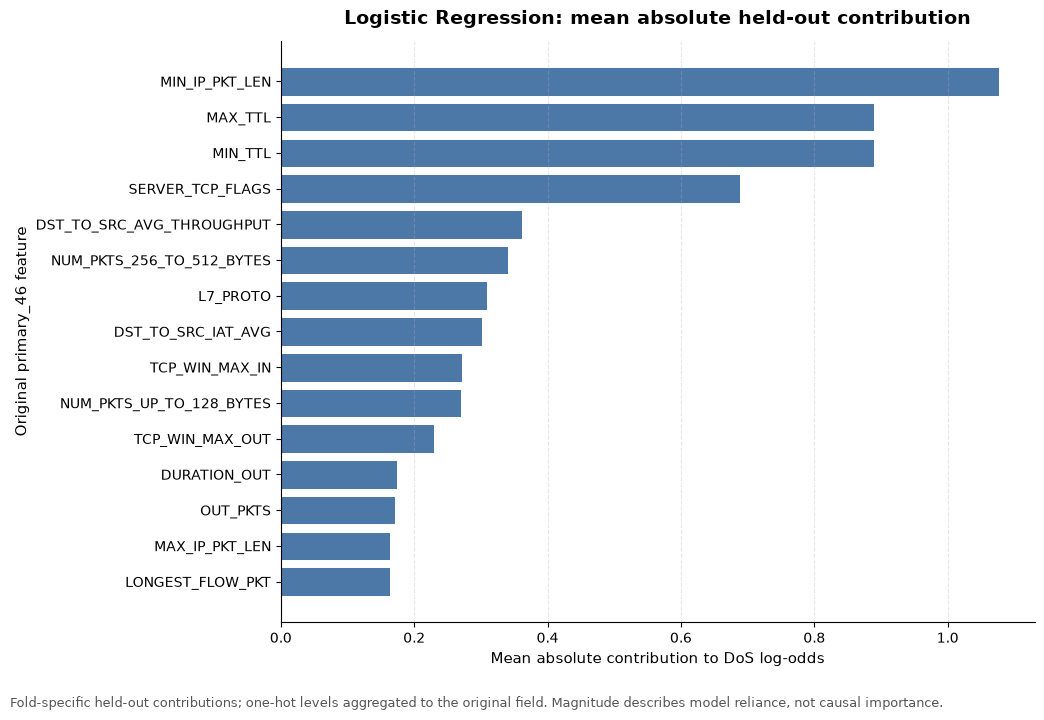


Logistic Regression attribution gate summary:


,value
held_out_sample_count,200
original_feature_count,46
attribution_row_count,9200
top_five_attribution_row_count,1000
maximum_decision_additivity_error,0.0
maximum_probability_reconstruction_error,0.0
attribution_check_count,7
passed_attribution_check_count,7
failed_attribution_check_count,0
attribution_scale,DoS log-odds



Verified held-out Logistic Regression attribution completed. The results remain in memory; no file was written.


In [15]:
# Calculate leakage-safe, fold-specific Logistic Regression attribution.
#
# This cell:
#   1. verifies that exact Notebook 09 reconstruction passed;
#   2. transforms each held-out fold using its own fitted preprocessor;
#   3. calculates beta_j * z_ij contributions on the DoS log-odds scale;
#   4. aggregates one-hot columns back to the original primary_46 fields;
#   5. ranks the 46 contributions separately for every sample;
#   6. validates decision-value and probability additivity;
#   7. presents an audit table and a descriptive global summary figure.
#
# It does NOT perform LLM alignment yet, alter the analytical population,
# make network requests, or write files.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy import sparse
from scipy.special import expit


# =========================================================================
# 1. Verify the exact baseline-reconstruction state.
# =========================================================================

required_logistic_attribution_objects = [
    "baseline_replication_gate_summary",
    "baseline_replication_X",
    "baseline_replication_y",
    "baseline_replication_sample_order",
    "baseline_replication_cv_splits",
    "baseline_replication_reconstructed_oof",
    "baseline_fitted_fold_models",
    "baseline_replication_locked_features",
    "baseline_replication_quantitative_features",
    "baseline_replication_categorical_features",
]

missing_logistic_attribution_objects = [
    object_name
    for object_name in required_logistic_attribution_objects
    if object_name not in globals()
]

assert not missing_logistic_attribution_objects, (
    "Required verified baseline objects are missing: "
    f"{missing_logistic_attribution_objects}"
)

assert int(
    baseline_replication_gate_summary[
        "failed_replication_check_count"
    ]
) == 0, (
    "The exact Notebook 09 baseline-reconstruction gate did not pass."
)

assert bool(
    baseline_replication_gate_summary[
        "fold_specific_models_available"
    ]
), (
    "The verified fold-specific baseline models are unavailable."
)

assert baseline_replication_X.shape == (200, 46)

assert len(
    baseline_fitted_fold_models["logistic_regression"]
) == 5


# =========================================================================
# 2. Calculate transformed-column contributions for every held-out fold.
# =========================================================================

logistic_original_contribution_frames = []
logistic_additivity_audit_records = []
logistic_transformed_schema_records = []

locked_feature_position_lookup = {
    feature_name: feature_position
    for feature_position, feature_name in enumerate(
        baseline_replication_locked_features,
        start=1,
    )
}

for fold_number, (
    _,
    testing_indices,
) in enumerate(
    baseline_replication_cv_splits,
    start=1,
):
    # Retrieve the already-verified pipeline fitted without this test fold.
    fold_pipeline = baseline_fitted_fold_models[
        "logistic_regression"
    ][fold_number]

    fold_preprocessor = fold_pipeline.named_steps[
        "preprocessing"
    ]

    fold_classifier = fold_pipeline.named_steps[
        "classifier"
    ]

    X_test = baseline_replication_X.iloc[
        testing_indices
    ]

    # Transform only through this fold's fitted preprocessing pipeline.
    transformed_X_test = fold_preprocessor.transform(
        X_test
    )

    if sparse.issparse(transformed_X_test):
        transformed_X_test_dense = (
            transformed_X_test.toarray()
        )
    else:
        transformed_X_test_dense = np.asarray(
            transformed_X_test
        )

    logistic_coefficients = np.asarray(
        fold_classifier.coef_[0],
        dtype=float,
    )

    logistic_intercept = float(
        fold_classifier.intercept_[0]
    )

    assert (
        transformed_X_test_dense.shape[1]
        == logistic_coefficients.shape[0]
    ), (
        "The transformed predictor count does not match "
        "the Logistic Regression coefficient count."
    )

    # ---------------------------------------------------------------------
    # Recover the original primary_46 owner of every transformed column.
    #
    # ColumnTransformer emits the 35 quantitative outputs first.
    # It then emits all learned one-hot columns for the 11 categorical
    # fields. One source field can therefore own several transformed
    # model columns.
    # ---------------------------------------------------------------------

    fitted_encoder = (
        fold_preprocessor
        .named_transformers_["categorical"]
        .named_steps["one_hot_encoding"]
    )

    categorical_output_names = list(
        fitted_encoder.get_feature_names_out(
            baseline_replication_categorical_features
        )
    )

    categorical_source_features = []

    for feature_name, learned_categories in zip(
        baseline_replication_categorical_features,
        fitted_encoder.categories_,
    ):
        categorical_source_features.extend(
            [feature_name] * len(learned_categories)
        )

    assert (
        len(categorical_output_names)
        == len(categorical_source_features)
    )

    transformed_output_names = (
        [
            f"quantitative__{feature_name}"
            for feature_name
            in baseline_replication_quantitative_features
        ]
        + [
            f"categorical__{output_name}"
            for output_name in categorical_output_names
        ]
    )

    transformed_source_features = (
        list(
            baseline_replication_quantitative_features
        )
        + categorical_source_features
    )

    assert (
        len(transformed_output_names)
        == transformed_X_test_dense.shape[1]
    )

    assert (
        len(transformed_source_features)
        == transformed_X_test_dense.shape[1]
    )

    for transformed_position, (
        output_name,
        source_feature,
    ) in enumerate(
        zip(
            transformed_output_names,
            transformed_source_features,
        ),
        start=1,
    ):
        logistic_transformed_schema_records.append(
            {
                "cv_fold": fold_number,
                "transformed_position": (
                    transformed_position
                ),
                "transformed_feature_name": (
                    output_name
                ),
                "source_feature_name": (
                    source_feature
                ),
            }
        )

    # Local transformed-column contribution:
    # beta_j multiplied by the fold-transformed feature value z_ij.
    transformed_contributions = (
        transformed_X_test_dense
        * logistic_coefficients[np.newaxis, :]
    )

    pipeline_decision_values = np.asarray(
        fold_pipeline.decision_function(X_test),
        dtype=float,
    )

    reconstructed_decision_values = (
        logistic_intercept
        + transformed_contributions.sum(axis=1)
    )

    pipeline_probabilities = np.asarray(
        fold_pipeline.predict_proba(X_test)[:, 1],
        dtype=float,
    )

    reconstructed_probabilities = expit(
        reconstructed_decision_values
    )

    fold_predictions = (
        fold_pipeline.predict(X_test)
        .astype(int)
    )

    for local_row_position, global_sample_position in enumerate(
        testing_indices
    ):
        global_sample_position = int(
            global_sample_position
        )

        sample_id = (
            baseline_replication_sample_order[
                global_sample_position
            ]
        )

        # ---------------------------------------------------------------
        # Aggregate every transformed column back to its original field.
        # Quantitative fields contribute one column. A categorical field
        # may contribute several one-hot columns, which are summed here.
        # ---------------------------------------------------------------

        sample_transformed_table = pd.DataFrame(
            {
                "feature_name": (
                    transformed_source_features
                ),
                "signed_log_odds_contribution": (
                    transformed_contributions[
                        local_row_position,
                        :,
                    ]
                ),
            }
        )

        sample_original_feature_table = (
            sample_transformed_table
            .groupby(
                "feature_name",
                sort=False,
                as_index=False,
            )[
                "signed_log_odds_contribution"
            ]
            .sum()
            .set_index("feature_name")
            .reindex(
                baseline_replication_locked_features
            )
            .reset_index()
        )

        assert sample_original_feature_table[
            "signed_log_odds_contribution"
        ].notna().all(), (
            "At least one original feature is missing "
            "after transformed-column aggregation."
        )

        sample_original_feature_table[
            "absolute_log_odds_contribution"
        ] = (
            sample_original_feature_table[
                "signed_log_odds_contribution"
            ]
            .abs()
        )

        sample_original_feature_table[
            "sample_position"
        ] = global_sample_position

        sample_original_feature_table[
            "sample_id"
        ] = sample_id

        sample_original_feature_table[
            "cv_fold"
        ] = fold_number

        sample_original_feature_table[
            "true_binary"
        ] = int(
            baseline_replication_y[
                global_sample_position
            ]
        )

        sample_original_feature_table[
            "predicted_binary"
        ] = int(
            fold_predictions[
                local_row_position
            ]
        )

        sample_original_feature_table[
            "dos_probability"
        ] = float(
            pipeline_probabilities[
                local_row_position
            ]
        )

        sample_original_feature_table[
            "feature_position"
        ] = (
            sample_original_feature_table[
                "feature_name"
            ]
            .map(
                locked_feature_position_lookup
            )
        )

        logistic_original_contribution_frames.append(
            sample_original_feature_table
        )

        # Preserve one row per sample for the mathematical additivity audit.
        logistic_additivity_audit_records.append(
            {
                "sample_position": (
                    global_sample_position
                ),
                "sample_id": sample_id,
                "cv_fold": fold_number,
                "model_decision_value": float(
                    pipeline_decision_values[
                        local_row_position
                    ]
                ),
                "reconstructed_decision_value": float(
                    reconstructed_decision_values[
                        local_row_position
                    ]
                ),
                "absolute_decision_error": float(
                    abs(
                        pipeline_decision_values[
                            local_row_position
                        ]
                        - reconstructed_decision_values[
                            local_row_position
                        ]
                    )
                ),
                "model_dos_probability": float(
                    pipeline_probabilities[
                        local_row_position
                    ]
                ),
                "reconstructed_dos_probability": float(
                    reconstructed_probabilities[
                        local_row_position
                    ]
                ),
                "absolute_probability_error": float(
                    abs(
                        pipeline_probabilities[
                            local_row_position
                        ]
                        - reconstructed_probabilities[
                            local_row_position
                        ]
                    )
                ),
            }
        )


# =========================================================================
# 3. Assemble and rank the 46 original-feature contributions per sample.
# =========================================================================

logistic_attribution_long = pd.concat(
    logistic_original_contribution_frames,
    ignore_index=True,
)

logistic_additivity_audit = pd.DataFrame(
    logistic_additivity_audit_records
)

logistic_transformed_schema_audit = pd.DataFrame(
    logistic_transformed_schema_records
)

# Rank by descending absolute contribution.
# Locked feature order provides deterministic tie-breaking.
logistic_attribution_long = (
    logistic_attribution_long
    .sort_values(
        [
            "sample_position",
            "absolute_log_odds_contribution",
            "feature_position",
        ],
        ascending=[
            True,
            False,
            True,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

logistic_attribution_long[
    "absolute_contribution_rank"
] = (
    logistic_attribution_long
    .groupby("sample_position")
    .cumcount()
    + 1
)

logistic_attribution_long[
    "contribution_direction"
] = np.select(
    [
        logistic_attribution_long[
            "signed_log_odds_contribution"
        ].gt(0),
        logistic_attribution_long[
            "signed_log_odds_contribution"
        ].lt(0),
    ],
    [
        "toward_DoS",
        "toward_Benign",
    ],
    default="neutral",
)

logistic_top_five_attributions = (
    logistic_attribution_long.loc[
        logistic_attribution_long[
            "absolute_contribution_rank"
        ].le(5)
    ]
    .copy()
)


# =========================================================================
# 4. Enforce coverage, ranking, prediction, and additivity checks.
# =========================================================================

logistic_attribution_check_records = []


def add_logistic_attribution_check(
    check,
    observed,
    expected,
    passed,
):
    """Append one explicit validation result."""
    logistic_attribution_check_records.append(
        {
            "check": check,
            "observed": observed,
            "expected": expected,
            "passed": bool(passed),
        }
    )


per_sample_feature_counts = (
    logistic_attribution_long
    .groupby("sample_id")[
        "feature_name"
    ]
    .nunique()
)

per_sample_top_five_counts = (
    logistic_top_five_attributions
    .groupby("sample_id")[
        "feature_name"
    ]
    .nunique()
)

logistic_prediction_by_sample = (
    logistic_attribution_long
    .drop_duplicates("sample_id")
    .set_index("sample_id")[
        "predicted_binary"
    ]
    .reindex(
        baseline_replication_sample_order
    )
    .astype(int)
    .to_numpy()
)

verified_oof_logistic_predictions = (
    baseline_replication_reconstructed_oof[
        "logistic_regression_predicted_binary"
    ]
    .astype(int)
    .to_numpy()
)

maximum_decision_error = float(
    logistic_additivity_audit[
        "absolute_decision_error"
    ]
    .max()
)

maximum_probability_error = float(
    logistic_additivity_audit[
        "absolute_probability_error"
    ]
    .max()
)

add_logistic_attribution_check(
    check="Held-out samples explained",
    observed=(
        logistic_attribution_long[
            "sample_id"
        ]
        .nunique()
    ),
    expected=200,
    passed=(
        logistic_attribution_long[
            "sample_id"
        ]
        .nunique()
        == 200
    ),
)

add_logistic_attribution_check(
    check="Original-feature attribution rows",
    observed=len(
        logistic_attribution_long
    ),
    expected=200 * 46,
    passed=(
        len(logistic_attribution_long)
        == 200 * 46
    ),
)

add_logistic_attribution_check(
    check=(
        "Samples with exactly 46 distinct original features"
    ),
    observed=int(
        per_sample_feature_counts.eq(46).sum()
    ),
    expected=200,
    passed=(
        per_sample_feature_counts.eq(46).all()
    ),
)

add_logistic_attribution_check(
    check=(
        "Samples with exactly five distinct top-ranked features"
    ),
    observed=int(
        per_sample_top_five_counts.eq(5).sum()
    ),
    expected=200,
    passed=(
        per_sample_top_five_counts.eq(5).all()
    ),
)

add_logistic_attribution_check(
    check=(
        "Predictions matching verified Notebook 09 OOF results"
    ),
    observed=int(
        np.sum(
            logistic_prediction_by_sample
            == verified_oof_logistic_predictions
        )
    ),
    expected=200,
    passed=np.array_equal(
        logistic_prediction_by_sample,
        verified_oof_logistic_predictions,
    ),
)

add_logistic_attribution_check(
    check="Maximum log-odds additivity error",
    observed=maximum_decision_error,
    expected="≤ 1e-10",
    passed=(
        maximum_decision_error <= 1e-10
    ),
)

add_logistic_attribution_check(
    check=(
        "Maximum probability reconstruction error"
    ),
    observed=maximum_probability_error,
    expected="≤ 1e-12",
    passed=(
        maximum_probability_error <= 1e-12
    ),
)

logistic_attribution_checks = pd.DataFrame(
    logistic_attribution_check_records
)

failed_logistic_attribution_checks = (
    logistic_attribution_checks.loc[
        ~logistic_attribution_checks["passed"]
    ]
    .copy()
)


# =========================================================================
# 5. Summarise global held-out contribution magnitude.
# =========================================================================

logistic_global_contribution_summary = (
    logistic_attribution_long
    .groupby(
        "feature_name",
        as_index=False,
    )
    .agg(
        mean_absolute_log_odds_contribution=(
            "absolute_log_odds_contribution",
            "mean",
        ),
        median_absolute_log_odds_contribution=(
            "absolute_log_odds_contribution",
            "median",
        ),
        mean_signed_log_odds_contribution=(
            "signed_log_odds_contribution",
            "mean",
        ),
        top_five_frequency=(
            "absolute_contribution_rank",
            lambda values: int(
                (values <= 5).sum()
            ),
        ),
    )
    .sort_values(
        [
            "mean_absolute_log_odds_contribution",
            "feature_name",
        ],
        ascending=[
            False,
            True,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

logistic_global_contribution_summary[
    "global_mean_absolute_rank"
] = np.arange(
    1,
    len(
        logistic_global_contribution_summary
    )
    + 1,
)


# =========================================================================
# 6. Display the validation evidence and descriptive results.
# =========================================================================

def colour_pass_values(column):
    """Display passed checks in green and failed checks in red."""
    return [
        (
            "background-color: #d9ead3; "
            "color: #274e13; "
            "font-weight: bold;"
            if bool(value)
            else
            "background-color: #f4cccc; "
            "color: #990000; "
            "font-weight: bold;"
        )
        for value in column
    ]


print(
    "Logistic Regression attribution integrity checks:"
)

display(
    logistic_attribution_checks.style
    .apply(
        colour_pass_values,
        subset=["passed"],
    )
    .hide(axis="index")
)

print("\nFailed attribution checks:")

if failed_logistic_attribution_checks.empty:
    print("None")
else:
    display(
        failed_logistic_attribution_checks
    )

assert failed_logistic_attribution_checks.empty, (
    "Logistic Regression attribution validation failed. "
    "Subsequent attribution comparison must not proceed."
)

print(
    "\nFirst three samples: five largest absolute "
    "Logistic Regression contributions:"
)

first_three_sample_ids = (
    baseline_replication_sample_order[:3]
)

display(
    logistic_top_five_attributions.loc[
        logistic_top_five_attributions[
            "sample_id"
        ].isin(first_three_sample_ids),
        [
            "sample_id",
            "cv_fold",
            "true_binary",
            "predicted_binary",
            "dos_probability",
            "absolute_contribution_rank",
            "feature_name",
            "signed_log_odds_contribution",
            "absolute_log_odds_contribution",
            "contribution_direction",
        ],
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "dos_probability": "{:.4f}",
            "signed_log_odds_contribution": (
                "{:.4f}"
            ),
            "absolute_log_odds_contribution": (
                "{:.4f}"
            ),
        }
    )
)

print(
    "\nGlobal held-out Logistic Regression "
    "contribution summary:"
)

display(
    logistic_global_contribution_summary
    .head(15)
    .style
    .hide(axis="index")
    .format(
        {
            "mean_absolute_log_odds_contribution": (
                "{:.4f}"
            ),
            "median_absolute_log_odds_contribution": (
                "{:.4f}"
            ),
            "mean_signed_log_odds_contribution": (
                "{:.4f}"
            ),
        }
    )
)


# =========================================================================
# 7. Visualise the global mean absolute held-out contributions.
# =========================================================================
#
# A horizontal ranked bar chart is appropriate because the axes compare
# named categorical items. This is descriptive model evidence and is not
# presented as causal feature importance.

plot_table = (
    logistic_global_contribution_summary
    .head(15)
    .sort_values(
        "mean_absolute_log_odds_contribution",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(10.5, 7.2)
)

ax.barh(
    plot_table["feature_name"],
    plot_table[
        "mean_absolute_log_odds_contribution"
    ],
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.7,
)

ax.set_title(
    "Logistic Regression: mean absolute held-out contribution",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel(
    "Mean absolute contribution to DoS log-odds",
    fontsize=11,
)

ax.set_ylabel(
    "Original primary_46 feature",
    fontsize=11,
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Fold-specific held-out contributions; one-hot levels "
        "aggregated to the original field. Magnitude describes "
        "model reliance, not causal importance."
    ),
    fontsize=9,
    color="#555555",
)

plt.tight_layout(
    rect=[
        0,
        0.045,
        1,
        1,
    ]
)

plt.show()


# =========================================================================
# 8. Record the completed attribution gate without writing files.
# =========================================================================

logistic_attribution_gate_summary = pd.Series(
    {
        "held_out_sample_count": 200,
        "original_feature_count": 46,
        "attribution_row_count": len(
            logistic_attribution_long
        ),
        "top_five_attribution_row_count": len(
            logistic_top_five_attributions
        ),
        "maximum_decision_additivity_error": (
            maximum_decision_error
        ),
        "maximum_probability_reconstruction_error": (
            maximum_probability_error
        ),
        "attribution_check_count": len(
            logistic_attribution_checks
        ),
        "passed_attribution_check_count": int(
            logistic_attribution_checks[
                "passed"
            ].sum()
        ),
        "failed_attribution_check_count": len(
            failed_logistic_attribution_checks
        ),
        "attribution_scale": "DoS log-odds",
        "ranking_basis": (
            "absolute original-feature contribution"
        ),
        "one_hot_levels_aggregated_to_original_feature": True,
        "held_out_fold_models_used": True,
        "causal_interpretation_supported": False,
        "files_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "verified_logistic_regression_attribution"
        ),
    },
    name="value",
)

print(
    "\nLogistic Regression attribution gate summary:"
)

display(
    logistic_attribution_gate_summary.to_frame()
)

print(
    "\nVerified held-out Logistic Regression attribution "
    "completed. The results remain in memory; no file was written."
)

## TreeSHAP compatibility and additivity preflight

### Why a separate preflight is required

Unlike Logistic Regression, a Random Forest does not have a single coefficient
for each transformed predictor. Local Random Forest attribution therefore
requires a tree-specific explanation method.

TreeSHAP distributes the difference between a model's expected output and an
individual prediction across the transformed predictors. For the positive DoS
class, the required additive relationship is

\[
\hat{p}_{i,\mathrm{DoS}}
=
E[f(X)]_{\mathrm{DoS}}
+
\sum_j \phi_{ij},
\]

where \(E[f(X)]_{\mathrm{DoS}}\) is the explainer's expected positive-class
output and \(\phi_{ij}\) is the SHAP contribution assigned to transformed
predictor \(j\).

SHAP versions differ in how binary-class results are returned. Older versions
commonly return a list containing one matrix per class, whereas newer versions
may return a three-dimensional array with a class dimension. Assuming one
specific structure without checking it could accidentally select the Benign
class or misalign samples, features, and classes.

### Preflight scope

This cell therefore:

1. verifies the transformed predictor dimensions of all five fitted Random
   Forest fold models;
2. checks whether SHAP is available in the active environment;
3. inspects the installed SHAP version and returned data structure;
4. normalises the output to the positive DoS class;
5. explains only five held-out records from fold 1; and
6. verifies that the SHAP baseline plus all feature contributions reconstructs
   the model's DoS probability within a tolerance of \(10^{-8}\).

No formal Random Forest attribution result is retained at this stage. The full
200-sample calculation will run only if this compatibility gate passes. This
cell does not alter the analysis population, make network requests, or write
files.

In [16]:
# Test TreeSHAP compatibility and additivity on five held-out records.
#
# This is a short environment and API preflight. It does not calculate the
# formal 200-sample Random Forest attribution result and writes no files.

import importlib.util

import numpy as np
import pandas as pd

from IPython.display import display
from scipy import sparse


# =========================================================================
# 1. Verify the exact reconstructed Random Forest state.
# =========================================================================

required_rf_shap_preflight_objects = [
    "baseline_replication_gate_summary",
    "baseline_replication_X",
    "baseline_replication_cv_splits",
    "baseline_fitted_fold_models",
    "baseline_replication_categorical_features",
    "baseline_replication_quantitative_features",
]

missing_rf_shap_preflight_objects = [
    object_name
    for object_name
    in required_rf_shap_preflight_objects
    if object_name not in globals()
]

assert not missing_rf_shap_preflight_objects, (
    "Required verified baseline objects are missing: "
    f"{missing_rf_shap_preflight_objects}"
)

assert int(
    baseline_replication_gate_summary[
        "failed_replication_check_count"
    ]
) == 0, (
    "The exact Notebook 09 baseline-reconstruction gate "
    "did not pass."
)

assert len(
    baseline_fitted_fold_models["random_forest"]
) == 5, (
    "Five verified Random Forest fold models are required."
)


# =========================================================================
# 2. Define version-independent binary-class SHAP helpers.
# =========================================================================

def extract_positive_class_shap_values(
    raw_values,
    sample_count,
    feature_count,
):
    """
    Normalise older list output and newer ndarray output.

    The returned matrix always has:
        rows    = held-out samples
        columns = transformed predictors

    Only positive-class (DoS) SHAP values are returned.
    """

    if isinstance(raw_values, list):
        # Older SHAP versions commonly return:
        # [Benign matrix, DoS matrix]
        if len(raw_values) != 2:
            raise ValueError(
                "Expected a two-element class list from binary "
                "TreeSHAP; observed "
                f"{len(raw_values)} elements."
            )

        positive_values = np.asarray(
            raw_values[1],
            dtype=float,
        )

    else:
        values_array = np.asarray(
            raw_values,
            dtype=float,
        )

        if values_array.ndim == 2:
            # Some versions return a positive-class matrix directly.
            positive_values = values_array

        elif values_array.ndim == 3:
            if values_array.shape == (
                sample_count,
                feature_count,
                2,
            ):
                # Newer layout:
                # samples × transformed features × classes
                positive_values = (
                    values_array[:, :, 1]
                )

            elif values_array.shape == (
                2,
                sample_count,
                feature_count,
            ):
                # Alternative layout:
                # classes × samples × transformed features
                positive_values = (
                    values_array[1, :, :]
                )

            else:
                raise ValueError(
                    "Unrecognised three-dimensional TreeSHAP "
                    "output shape: "
                    f"{values_array.shape}."
                )

        else:
            raise ValueError(
                "Unrecognised TreeSHAP output dimensions: "
                f"{values_array.shape}."
            )

    expected_shape = (
        sample_count,
        feature_count,
    )

    if positive_values.shape != expected_shape:
        raise ValueError(
            "Normalised positive-class SHAP matrix has shape "
            f"{positive_values.shape}; expected "
            f"{expected_shape}."
        )

    return positive_values


def extract_positive_class_expected_value(
    raw_expected_value,
):
    """
    Return the scalar TreeSHAP expected value for the DoS class.
    """

    expected_array = np.asarray(
        raw_expected_value,
        dtype=float,
    )

    if expected_array.ndim == 0:
        return float(expected_array)

    expected_flat = expected_array.reshape(-1)

    if expected_flat.size == 2:
        # Binary-class vector:
        # position 0 = Benign; position 1 = DoS.
        return float(expected_flat[1])

    if expected_flat.size == 1:
        return float(expected_flat[0])

    raise ValueError(
        "Unrecognised binary TreeSHAP expected-value shape: "
        f"{expected_array.shape}."
    )


# =========================================================================
# 3. Check transformed dimensions for all five RF fold models.
# =========================================================================

rf_shap_fold_schema_records = []

for fold_number, (
    _,
    testing_indices,
) in enumerate(
    baseline_replication_cv_splits,
    start=1,
):
    fold_pipeline = (
        baseline_fitted_fold_models[
            "random_forest"
        ][fold_number]
    )

    fold_preprocessor = (
        fold_pipeline.named_steps[
            "preprocessing"
        ]
    )

    fold_classifier = (
        fold_pipeline.named_steps[
            "classifier"
        ]
    )

    transformed_test = (
        fold_preprocessor.transform(
            baseline_replication_X.iloc[
                testing_indices
            ]
        )
    )

    transformed_feature_count = int(
        transformed_test.shape[1]
    )

    classifier_feature_count = int(
        fold_classifier.n_features_in_
    )

    rf_shap_fold_schema_records.append(
        {
            "cv_fold": fold_number,
            "held_out_sample_count": len(
                testing_indices
            ),
            "transformed_feature_count": (
                transformed_feature_count
            ),
            "classifier_feature_count": (
                classifier_feature_count
            ),
            "dimensions_match": (
                transformed_feature_count
                == classifier_feature_count
            ),
        }
    )

rf_shap_fold_schema_audit = pd.DataFrame(
    rf_shap_fold_schema_records
)


# =========================================================================
# 4. Import SHAP safely and test five records from fold 1.
# =========================================================================
#
# Any unavailable package or incompatible output is captured as a readable
# audit result instead of ending the notebook with a traceback.

rf_shap_package_available = (
    importlib.util.find_spec("shap")
    is not None
)

rf_shap_import_succeeded = False
rf_shap_small_test_succeeded = False
rf_shap_version = None
rf_shap_raw_output_type = None
rf_shap_raw_output_shape = None
rf_shap_positive_matrix_shape = None
rf_shap_maximum_additivity_error = np.nan
rf_shap_preflight_message = None

if not rf_shap_package_available:
    rf_shap_preflight_message = (
        "The shap package is not installed in the active "
        "conda environment."
    )

else:
    try:
        import shap

        rf_shap_import_succeeded = True

        rf_shap_version = getattr(
            shap,
            "__version__",
            "unknown",
        )

        # Select only the first five held-out records from fold 1.
        fold_number = 1

        _, fold_one_testing_indices = (
            baseline_replication_cv_splits[0]
        )

        fold_one_pipeline = (
            baseline_fitted_fold_models[
                "random_forest"
            ][fold_number]
        )

        fold_one_preprocessor = (
            fold_one_pipeline.named_steps[
                "preprocessing"
            ]
        )

        fold_one_classifier = (
            fold_one_pipeline.named_steps[
                "classifier"
            ]
        )

        rf_shap_preflight_X = (
            baseline_replication_X.iloc[
                fold_one_testing_indices[:5]
            ]
        )

        rf_shap_preflight_transformed = (
            fold_one_preprocessor.transform(
                rf_shap_preflight_X
            )
        )

        if sparse.issparse(
            rf_shap_preflight_transformed
        ):
            rf_shap_preflight_dense = (
                rf_shap_preflight_transformed
                .toarray()
            )
        else:
            rf_shap_preflight_dense = np.asarray(
                rf_shap_preflight_transformed
            )

        # tree_path_dependent uses paths learned by the fitted forest
        # and does not require a separate background dataset.
        rf_shap_preflight_explainer = (
            shap.TreeExplainer(
                fold_one_classifier,
                feature_perturbation=(
                    "tree_path_dependent"
                ),
                model_output="raw",
            )
        )

        # Older SHAP versions may not accept check_additivity here.
        try:
            rf_shap_preflight_raw_values = (
                rf_shap_preflight_explainer
                .shap_values(
                    rf_shap_preflight_dense,
                    check_additivity=False,
                )
            )
        except TypeError:
            rf_shap_preflight_raw_values = (
                rf_shap_preflight_explainer
                .shap_values(
                    rf_shap_preflight_dense
                )
            )

        rf_shap_raw_output_type = type(
            rf_shap_preflight_raw_values
        ).__name__

        if isinstance(
            rf_shap_preflight_raw_values,
            list,
        ):
            rf_shap_raw_output_shape = str(
                [
                    np.asarray(item).shape
                    for item
                    in rf_shap_preflight_raw_values
                ]
            )
        else:
            rf_shap_raw_output_shape = str(
                np.asarray(
                    rf_shap_preflight_raw_values
                ).shape
            )

        rf_shap_preflight_positive_values = (
            extract_positive_class_shap_values(
                rf_shap_preflight_raw_values,
                sample_count=(
                    rf_shap_preflight_dense.shape[0]
                ),
                feature_count=(
                    rf_shap_preflight_dense.shape[1]
                ),
            )
        )

        rf_shap_positive_matrix_shape = str(
            rf_shap_preflight_positive_values.shape
        )

        rf_shap_preflight_expected_value = (
            extract_positive_class_expected_value(
                rf_shap_preflight_explainer
                .expected_value
            )
        )

        # For sklearn RandomForestClassifier, the positive-class
        # TreeSHAP values should reconstruct the DoS probability.
        rf_shap_preflight_reconstructed_probabilities = (
            rf_shap_preflight_expected_value
            + rf_shap_preflight_positive_values.sum(
                axis=1
            )
        )

        rf_shap_preflight_model_probabilities = (
            fold_one_classifier.predict_proba(
                rf_shap_preflight_dense
            )[:, 1]
        )

        rf_shap_maximum_additivity_error = float(
            np.max(
                np.abs(
                    rf_shap_preflight_reconstructed_probabilities
                    - rf_shap_preflight_model_probabilities
                )
            )
        )

        rf_shap_small_test_succeeded = bool(
            rf_shap_maximum_additivity_error
            <= 1e-8
        )

        if rf_shap_small_test_succeeded:
            rf_shap_preflight_message = (
                "TreeSHAP positive-class values reconstructed "
                "all five tested Random Forest probabilities "
                "within tolerance."
            )
        else:
            rf_shap_preflight_message = (
                "TreeSHAP executed, but its positive-class "
                "values did not reconstruct the tested "
                "probabilities within tolerance."
            )

    except Exception as error:
        # Preserve the exact exception class and message in an
        # interpretable output without producing a notebook traceback.
        rf_shap_preflight_message = (
            f"{type(error).__name__}: {error}"
        )


# =========================================================================
# 5. Construct the preflight decision.
# =========================================================================

all_rf_fold_dimensions_match = bool(
    rf_shap_fold_schema_audit[
        "dimensions_match"
    ]
    .all()
)

rf_shap_preflight_ready = bool(
    rf_shap_package_available
    and rf_shap_import_succeeded
    and rf_shap_small_test_succeeded
    and all_rf_fold_dimensions_match
)

rf_shap_preflight_summary = pd.DataFrame(
    [
        (
            "SHAP package available",
            rf_shap_package_available,
        ),
        (
            "SHAP import succeeded",
            rf_shap_import_succeeded,
        ),
        (
            "SHAP version",
            rf_shap_version,
        ),
        (
            "Raw SHAP output type",
            rf_shap_raw_output_type,
        ),
        (
            "Raw SHAP output shape",
            rf_shap_raw_output_shape,
        ),
        (
            "Positive-class SHAP matrix shape",
            rf_shap_positive_matrix_shape,
        ),
        (
            "Five-record additivity test passed",
            rf_shap_small_test_succeeded,
        ),
        (
            "Maximum additivity error",
            rf_shap_maximum_additivity_error,
        ),
        (
            "All fold dimensions matched",
            all_rf_fold_dimensions_match,
        ),
        (
            "Ready for full RF attribution",
            rf_shap_preflight_ready,
        ),
        (
            "Formal attribution retained",
            False,
        ),
        (
            "Files written",
            False,
        ),
        (
            "Network requests",
            False,
        ),
    ],
    columns=[
        "preflight_item",
        "observed_value",
    ],
)


# =========================================================================
# 6. Display a compact, readable compatibility audit.
# =========================================================================

def colour_preflight_boolean(column):
    """
    Colour only Boolean values.

    Non-Boolean diagnostic values such as the SHAP version and output
    shape remain uncoloured.
    """
    styles = []

    for value in column:
        if isinstance(
            value,
            (bool, np.bool_),
        ):
            if bool(value):
                styles.append(
                    "background-color: #d9ead3; "
                    "color: #274e13; "
                    "font-weight: bold;"
                )
            else:
                styles.append(
                    "background-color: #f4cccc; "
                    "color: #990000; "
                    "font-weight: bold;"
                )
        else:
            styles.append("")

    return styles


print(
    "Random Forest transformed-schema audit:"
)

display(
    rf_shap_fold_schema_audit.style
    .apply(
        colour_preflight_boolean,
        subset=["dimensions_match"],
    )
    .hide(axis="index")
)

print(
    "\nTreeSHAP environment and additivity preflight:"
)

display(
    rf_shap_preflight_summary.style
    .apply(
        colour_preflight_boolean,
        subset=["observed_value"],
    )
    .hide(axis="index")
)

print("\nPreflight interpretation:")

print(
    rf_shap_preflight_message
)

if rf_shap_preflight_ready:
    print(
        "The environment is ready for full fold-specific "
        "Random Forest attribution. No formal attribution "
        "result was retained by this cell."
    )
else:
    print(
        "Full Random Forest attribution must not run yet. "
        "The compatibility information above will determine "
        "the required correction."
    )

Random Forest transformed-schema audit:


/opt/anaconda3/envs/compsci742-a2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cv_fold,held_out_sample_count,transformed_feature_count,classifier_feature_count,dimensions_match
1,40,472,472,True
2,40,459,459,True
3,40,465,465,True
4,40,458,458,True
5,40,466,466,True



TreeSHAP environment and additivity preflight:


preflight_item,observed_value
SHAP package available,True
SHAP import succeeded,True
SHAP version,0.51.0
Raw SHAP output type,ndarray
Raw SHAP output shape,"(5, 472, 2)"
Positive-class SHAP matrix shape,"(5, 472)"
Five-record additivity test passed,True
Maximum additivity error,0.000000
All fold dimensions matched,True
Ready for full RF attribution,True



Preflight interpretation:
TreeSHAP positive-class values reconstructed all five tested Random Forest probabilities within tolerance.
The environment is ready for full fold-specific Random Forest attribution. No formal attribution result was retained by this cell.


## 10.X Install and verify the pinned SHAP dependency

### Purpose

The Random Forest models have already been reconstructed exactly from the
Notebook 09 specification. Their five transformed feature spaces also match
their fitted classifiers:

- every fold contains 40 held-out samples;
- every transformed matrix has the same number of columns as its classifier;
- all five dimension checks passed.

The remaining prerequisite for Random Forest attribution is the `shap`
package. The active environment uses Python 3.11, whereas the latest SHAP
release requires Python 3.12 or later. Therefore, this notebook pins
**SHAP 0.51.0**, a release that supports Python 3.11.

### Why the installation is audited

Installing a new scientific package can sometimes update existing dependencies.
That would be undesirable here because the reconstructed baseline predictions
have already been verified against Notebook 09.

The following cell therefore:

1. records the active Python interpreter;
2. records the installed NumPy, pandas, SciPy, and scikit-learn versions;
3. installs exactly `shap==0.51.0`;
4. requests upgrades only when a dependency is genuinely unsatisfied;
5. verifies the SHAP import in a fresh Python process;
6. confirms that the four core scientific packages were not changed.

### Decision rule

TreeSHAP analysis may proceed only if:

- the imported SHAP version is exactly `0.51.0`;
- a fresh-process SHAP import succeeds; and
- NumPy, pandas, SciPy, and scikit-learn retain their existing versions.

After a successful installation, the Jupyter kernel must be restarted before
SHAP is used. Restarting clears the in-memory fitted models, so the preceding
Notebook 10 cells will subsequently be rerun in order to reconstruct the same
verified analytical state.

In [17]:
import importlib.metadata as metadata
import json
import subprocess
import sys

import pandas as pd
from IPython.display import display


# -----------------------------------------------------------------------------
# 1. Record the active interpreter and the scientific stack before installation.
# -----------------------------------------------------------------------------
# We pin this version because the current notebook kernel uses Python 3.11.
# SHAP 0.52.0 requires Python 3.12 or later, whereas SHAP 0.51.0 supports 3.11.
TARGET_SHAP_VERSION = "0.51.0"

# These packages are central to the already-verified Notebook 09 replication.
# We do not want the SHAP installation to silently replace any of them.
CORE_DISTRIBUTIONS = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
]


def installed_version(distribution_name):
    """
    Return the installed version of a Python distribution.

    None is returned when the distribution is not installed. Using
    importlib.metadata avoids importing and altering the state of the
    scientific packages merely to inspect their versions.
    """
    try:
        return metadata.version(distribution_name)
    except metadata.PackageNotFoundError:
        return None


versions_before = {
    distribution_name: installed_version(distribution_name)
    for distribution_name in CORE_DISTRIBUTIONS
}

print("Active Python interpreter:")
print(sys.executable)

print("\nPython version:")
print(sys.version.split()[0])

print("\nCore package versions before SHAP installation:")
display(
    pd.DataFrame(
        {
            "distribution": list(versions_before.keys()),
            "version_before": list(versions_before.values()),
        }
    )
)


# -----------------------------------------------------------------------------
# 2. Install the exact Python-3.11-compatible SHAP release.
# -----------------------------------------------------------------------------
# sys.executable guarantees that pip targets the same environment as this
# Jupyter kernel.
#
# "only-if-needed" tells pip not to upgrade packages that already satisfy
# SHAP's dependency requirements.
pip_command = [
    sys.executable,
    "-m",
    "pip",
    "install",
    f"shap=={TARGET_SHAP_VERSION}",
    "--upgrade-strategy",
    "only-if-needed",
    "--disable-pip-version-check",
    "--no-input",
]

print("\nInstallation command:")
print(" ".join(pip_command))

print("\nInstalling SHAP; this normally takes about 1–3 minutes ...")

installation = subprocess.run(
    pip_command,
    text=True,
    capture_output=True,
    check=False,
)

# Show only the final portion of pip's report. This contains the installation
# result without filling the notebook with dependency-resolution messages.
pip_report = "\n".join(
    part.strip()
    for part in (installation.stdout, installation.stderr)
    if part.strip()
)
pip_report_lines = pip_report.splitlines()

print("\nFinal lines from pip:")
print(
    "\n".join(pip_report_lines[-40:])
    if pip_report_lines
    else "No pip output."
)

if installation.returncode != 0:
    raise RuntimeError(
        "SHAP installation did not complete successfully. "
        "Do not restart the kernel yet; send the complete red error output."
    )


# -----------------------------------------------------------------------------
# 3. Verify the installation using a fresh Python process.
# -----------------------------------------------------------------------------
# Importing in a fresh process is more reliable than importing immediately in
# the current kernel, which may still contain cached modules from before the
# installation.
verification_program = """
import json
import numpy
import pandas
import scipy
import shap
import sklearn

print(json.dumps({
    "shap": shap.__version__,
    "numpy": numpy.__version__,
    "pandas": pandas.__version__,
    "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
}))
"""

verification = subprocess.run(
    [sys.executable, "-c", verification_program],
    text=True,
    capture_output=True,
    check=False,
)

if verification.returncode != 0:
    print("\nFresh-process import error:")
    print(verification.stderr)

    raise RuntimeError(
        "SHAP was installed, but a fresh Python process could not import it. "
        "Do not continue to TreeSHAP; send the complete error output."
    )

# The verification program prints one JSON object on its final output line.
verified_versions = json.loads(
    verification.stdout.strip().splitlines()[-1]
)

versions_after = {
    distribution_name: verified_versions[distribution_name]
    for distribution_name in CORE_DISTRIBUTIONS
}


# -----------------------------------------------------------------------------
# 4. Confirm that the core analytical environment did not change.
# -----------------------------------------------------------------------------
version_audit = pd.DataFrame(
    {
        "distribution": CORE_DISTRIBUTIONS,
        "version_before": [
            versions_before[name]
            for name in CORE_DISTRIBUTIONS
        ],
        "version_after": [
            versions_after[name]
            for name in CORE_DISTRIBUTIONS
        ],
    }
)

version_audit["unchanged"] = (
    version_audit["version_before"]
    == version_audit["version_after"]
)

installation_verification = pd.DataFrame(
    {
        "check": [
            "Requested SHAP version",
            "Imported SHAP version",
            "Fresh-process SHAP import succeeded",
            "All four core package versions unchanged",
        ],
        "observed": [
            TARGET_SHAP_VERSION,
            verified_versions["shap"],
            True,
            bool(version_audit["unchanged"].all()),
        ],
    }
)

print("\nFresh-process installation verification:")
display(
    installation_verification.style.map(
        lambda value: (
            "background-color: #d9ead3; "
            "color: #274e13; "
            "font-weight: bold;"
            if value is True
            else ""
        )
    )
)

print("\nCore-version preservation audit:")
display(
    version_audit.style.map(
        lambda value: (
            "background-color: #d9ead3; "
            "color: #274e13; "
            "font-weight: bold;"
            if value is True
            else (
                "background-color: #f4cccc; "
                "color: #990000; "
                "font-weight: bold;"
                if value is False
                else ""
            )
        ),
        subset=["unchanged"],
    )
)


# -----------------------------------------------------------------------------
# 5. Enforce the installation contract.
# -----------------------------------------------------------------------------
assert verified_versions["shap"] == TARGET_SHAP_VERSION, (
    "The imported SHAP version does not match the pinned target."
)

assert version_audit["unchanged"].all(), (
    "At least one core scientific package changed during installation. "
    "Stop here and send the version-audit table before restarting the kernel."
)

print(
    "\nSHAP 0.51.0 was installed and verified without changing the four "
    "core scientific packages. Restart the Jupyter kernel before importing "
    "SHAP in the attribution analysis."
)

Active Python interpreter:
/opt/anaconda3/envs/compsci742-a2/bin/python

Python version:
3.11.14

Core package versions before SHAP installation:


,distribution,version_before
0,numpy,2.4.6
1,pandas,3.0.5
2,scipy,1.17.1
3,scikit-learn,1.9.0



Installation command:
/opt/anaconda3/envs/compsci742-a2/bin/python -m pip install shap==0.51.0 --upgrade-strategy only-if-needed --disable-pip-version-check --no-input

Installing SHAP; this normally takes about 1–3 minutes ...

Final lines from pip:

Fresh-process installation verification:


,check,observed
0,Requested SHAP version,0.51.0
1,Imported SHAP version,0.51.0
2,Fresh-process SHAP import succeeded,True
3,All four core package versions unchanged,True



Core-version preservation audit:


,distribution,version_before,version_after,unchanged
0,numpy,2.4.6,2.4.6,True
1,pandas,3.0.5,3.0.5,True
2,scipy,1.17.1,1.17.1,True
3,scikit-learn,1.9.0,1.9.0,True



SHAP 0.51.0 was installed and verified without changing the four core scientific packages. Restart the Jupyter kernel before importing SHAP in the attribution analysis.


## 10.X Freeze the in-memory interface for full Random Forest attribution

### Purpose

The TreeSHAP compatibility preflight has passed:

- SHAP 0.51.0 imports successfully;
- all five transformed feature dimensions match their classifiers;
- the binary SHAP output has been normalised to the positive-class matrix;
- the five-record additivity test reconstructs the Random Forest positive-class
  probabilities with zero displayed error.

The next stage will calculate and retain formal TreeSHAP values for all 200
out-of-fold samples. Before starting that longer computation, this cell freezes
the exact in-memory interface created by the baseline-reconstruction cells.

This is necessary because the fitted fold models, cross-validation splits, and
sample order may be stored in nested dictionaries, lists, tuples, arrays, or
data frames. The formal attribution cell must use the observed structure rather
than assuming a particular container layout.

### What this audit inspects

The cell reports:

1. the type, size, shape, and relevant keys of each required object;
2. the paths of fitted objects exposing `predict_proba`;
3. the named pipeline steps available at each fitted-model path;
4. the structure of the first two cross-validation split records;
5. the shapes of the reconstructed feature matrix and sample-order object.

### Scope and safety

This is a read-only interface audit. It:

- does not fit a model;
- does not calculate formal SHAP values;
- does not alter the paired analytical population;
- does not write a file;
- does not make a network request.

The resulting contract will be used to construct the full TreeSHAP cell without
guessing the structure of the reconstructed baseline objects.

In [18]:
from collections.abc import Mapping, Sequence

import numpy as np
import pandas as pd
from IPython.display import display


# -----------------------------------------------------------------------------
# 1. Define the exact objects required by the formal Random Forest attribution.
# -----------------------------------------------------------------------------
required_object_names = [
    "baseline_fitted_fold_models",
    "baseline_replication_cv_splits",
    "baseline_replication_X",
    "baseline_replication_y",
    "baseline_replication_sample_order",
    "baseline_replication_locked_features",
    "baseline_replication_quantitative_features",
    "baseline_replication_categorical_features",
    "baseline_replication_reconstructed_oof",
]

missing_required_objects = [
    object_name
    for object_name in required_object_names
    if object_name not in globals()
]

assert not missing_required_objects, (
    "Required reconstructed-baseline objects are missing after the kernel "
    f"restart: {missing_required_objects}. Do not run formal TreeSHAP yet."
)


# -----------------------------------------------------------------------------
# 2. Create concise, non-destructive summaries of the required containers.
# -----------------------------------------------------------------------------
def safe_length(value):
    """Return len(value) when available, otherwise return None."""
    try:
        return len(value)
    except TypeError:
        return None


def shape_summary(value):
    """Return an object's shape as a tuple when the object exposes a shape."""
    observed_shape = getattr(value, "shape", None)

    if observed_shape is None:
        return None

    try:
        return tuple(observed_shape)
    except TypeError:
        return str(observed_shape)


def key_summary(value, maximum_keys=20):
    """
    Return a bounded representation of keys or columns.

    The audit intentionally limits the number displayed so that large
    data-frame schemas do not overwhelm the notebook output.
    """
    if isinstance(value, Mapping):
        observed_keys = list(value.keys())
        displayed_keys = observed_keys[:maximum_keys]

        if len(observed_keys) > maximum_keys:
            displayed_keys.append(
                f"... {len(observed_keys) - maximum_keys} additional keys"
            )

        return displayed_keys

    if isinstance(value, pd.DataFrame):
        observed_columns = list(value.columns)
        displayed_columns = observed_columns[:maximum_keys]

        if len(observed_columns) > maximum_keys:
            displayed_columns.append(
                f"... {len(observed_columns) - maximum_keys} additional columns"
            )

        return displayed_columns

    if isinstance(value, pd.Series):
        return [f"Series name: {value.name}"]

    return None


object_contract_rows = []

for object_name in required_object_names:
    observed_object = globals()[object_name]

    object_contract_rows.append(
        {
            "object_name": object_name,
            "python_type": type(observed_object).__name__,
            "length": safe_length(observed_object),
            "shape": shape_summary(observed_object),
            "keys_or_columns": key_summary(observed_object),
        }
    )

object_contract_table = pd.DataFrame(object_contract_rows)

print("Required in-memory object contract:")
with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_columns",
    None,
    "display.width",
    220,
):
    display(object_contract_table)


# -----------------------------------------------------------------------------
# 3. Recursively locate fitted objects that expose predict_proba.
# -----------------------------------------------------------------------------
# Only ordinary containers are traversed. Fitted sklearn estimators are treated
# as leaves, preventing recursion into their large internal parameter trees.
fitted_object_rows = []
visited_container_ids = set()


def record_fitted_objects(value, path, depth=0, maximum_depth=5):
    """
    Traverse nested mappings and sequences and record estimator-like objects.

    The recorded path gives the exact expression pattern needed to retrieve
    each fold-specific fitted pipeline in the formal attribution cell.
    """
    if hasattr(value, "predict_proba"):
        named_steps = getattr(value, "named_steps", None)

        fitted_object_rows.append(
            {
                "object_path": path,
                "python_type": type(value).__name__,
                "has_predict_proba": True,
                "named_steps": (
                    list(named_steps.keys())
                    if named_steps is not None
                    else None
                ),
                "classes": (
                    np.asarray(value.classes_).tolist()
                    if hasattr(value, "classes_")
                    else None
                ),
                "n_features_in": (
                    int(value.n_features_in_)
                    if hasattr(value, "n_features_in_")
                    else None
                ),
            }
        )
        return

    if depth >= maximum_depth:
        return

    if isinstance(value, Mapping):
        container_id = id(value)

        if container_id in visited_container_ids:
            return

        visited_container_ids.add(container_id)

        for key, child_value in value.items():
            record_fitted_objects(
                child_value,
                f"{path}[{key!r}]",
                depth=depth + 1,
                maximum_depth=maximum_depth,
            )

        return

    if isinstance(value, (list, tuple)):
        container_id = id(value)

        if container_id in visited_container_ids:
            return

        visited_container_ids.add(container_id)

        for position, child_value in enumerate(value):
            record_fitted_objects(
                child_value,
                f"{path}[{position}]",
                depth=depth + 1,
                maximum_depth=maximum_depth,
            )

        return

    # A DataFrame can occasionally be used as an object registry. Inspect only
    # object-typed cells and avoid traversing ordinary numerical tables.
    if isinstance(value, pd.DataFrame):
        object_columns = [
            column_name
            for column_name in value.columns
            if value[column_name].dtype == "object"
        ]

        for column_name in object_columns:
            for row_position, child_value in enumerate(
                value[column_name].tolist()
            ):
                if hasattr(child_value, "predict_proba"):
                    record_fitted_objects(
                        child_value,
                        (
                            f"{path}.iloc[{row_position}]"
                            f"[{column_name!r}]"
                        ),
                        depth=depth + 1,
                        maximum_depth=maximum_depth,
                    )


record_fitted_objects(
    baseline_fitted_fold_models,
    "baseline_fitted_fold_models",
)

fitted_object_contract = pd.DataFrame(fitted_object_rows)

assert not fitted_object_contract.empty, (
    "No fitted object exposing predict_proba was found inside "
    "baseline_fitted_fold_models."
)

print("\nFitted probability-model paths:")
with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_columns",
    None,
    "display.width",
    220,
):
    display(fitted_object_contract)


# -----------------------------------------------------------------------------
# 4. Inspect the structure of the first two cross-validation split records.
# -----------------------------------------------------------------------------
def component_summary(component):
    """Describe one component of a split record without printing its contents."""
    return {
        "python_type": type(component).__name__,
        "length": safe_length(component),
        "shape": shape_summary(component),
        "keys": (
            list(component.keys())
            if isinstance(component, Mapping)
            else None
        ),
    }


split_contract_rows = []
split_container = baseline_replication_cv_splits

if isinstance(split_container, Mapping):
    split_items = list(split_container.items())[:2]

    for split_key, split_value in split_items:
        if isinstance(split_value, Mapping):
            component_description = {
                key: component_summary(value)
                for key, value in split_value.items()
            }
        elif isinstance(split_value, (list, tuple)):
            component_description = {
                f"component_{position}": component_summary(component)
                for position, component in enumerate(split_value)
            }
        else:
            component_description = {
                "split_value": component_summary(split_value)
            }

        split_contract_rows.append(
            {
                "split_identifier": repr(split_key),
                "split_record_type": type(split_value).__name__,
                "component_structure": component_description,
            }
        )

elif isinstance(split_container, (list, tuple)):
    for split_position, split_value in enumerate(split_container[:2]):
        if isinstance(split_value, Mapping):
            component_description = {
                key: component_summary(value)
                for key, value in split_value.items()
            }
        elif isinstance(split_value, (list, tuple)):
            component_description = {
                f"component_{position}": component_summary(component)
                for position, component in enumerate(split_value)
            }
        else:
            component_description = {
                "split_value": component_summary(split_value)
            }

        split_contract_rows.append(
            {
                "split_identifier": split_position,
                "split_record_type": type(split_value).__name__,
                "component_structure": component_description,
            }
        )

else:
    split_contract_rows.append(
        {
            "split_identifier": None,
            "split_record_type": type(split_container).__name__,
            "component_structure": component_summary(split_container),
        }
    )

split_contract_table = pd.DataFrame(split_contract_rows)

print("\nFirst two cross-validation split contracts:")
with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_columns",
    None,
    "display.width",
    220,
):
    display(split_contract_table)


# -----------------------------------------------------------------------------
# 5. Produce a compact gate summary.
# -----------------------------------------------------------------------------
pipeline_count = int(
    fitted_object_contract["named_steps"].notna().sum()
)

interface_contract_summary = pd.Series(
    {
        "required_object_count": len(required_object_names),
        "missing_required_object_count": len(missing_required_objects),
        "fitted_probability_object_count": len(fitted_object_contract),
        "fitted_pipeline_count": pipeline_count,
        "cross_validation_split_count": safe_length(
            baseline_replication_cv_splits
        ),
        "feature_matrix_shape": shape_summary(baseline_replication_X),
        "sample_order_length": safe_length(
            baseline_replication_sample_order
        ),
        "locked_original_feature_count": len(
            baseline_replication_locked_features
        ),
        "formal_shap_values_calculated": False,
        "models_refitted_by_this_cell": False,
        "experimental_objects_modified": False,
        "files_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_10_phase": "random_forest_interface_contract",
    },
    name="value",
)

print("\nRandom Forest attribution interface-contract summary:")
display(interface_contract_summary.to_frame())

print(
    "\nThe Random Forest attribution interface has been inspected read-only. "
    "No model was fitted, no SHAP value was calculated, and no file was written."
)

Required in-memory object contract:


,object_name,python_type,length,shape,keys_or_columns
0,baseline_fitted_fold_models,dict,2,None,"[logistic_regression, random_forest]"
1,baseline_replication_cv_splits,list,5,None,None
2,baseline_replication_X,DataFrame,200,"(200, 46)","[L4_SRC_PORT, L4_DST_PORT, PROTOCOL, L7_PROTO, IN_BYTES, IN_PKTS, OUT_BYTES, OUT_PKTS, TCP_FLAGS, CLIENT_TCP_FLAGS, SERVER_TCP_FLAGS, FLOW_DURATION_MILLISECONDS, DURATION_IN, DURATION_OUT, MIN_TTL, MAX_TTL, LONGEST_FLOW_PKT, SHORTEST_FLOW_PKT, MIN_IP_PKT_LEN, MAX_IP_PKT_LEN, ... 26 additional columns]"
3,baseline_replication_y,ndarray,200,"(200,)",None
4,baseline_replication_sample_order,list,200,None,None
5,baseline_replication_locked_features,list,46,None,None
6,baseline_replication_quantitative_features,list,35,None,None
7,baseline_replication_categorical_features,list,11,None,None
8,baseline_replication_reconstructed_oof,DataFrame,200,"(200, 7)","[sample_id, true_binary, cv_fold, logistic_regression_predicted_binary, logistic_regression_dos_probability, random_forest_predicted_binary, random_forest_dos_probability]"



Fitted probability-model paths:


,object_path,python_type,has_predict_proba,named_steps,classes,n_features_in
0,baseline_fitted_fold_models['logistic_regression'][1],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46
1,baseline_fitted_fold_models['logistic_regression'][2],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46
2,baseline_fitted_fold_models['logistic_regression'][3],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46
3,baseline_fitted_fold_models['logistic_regression'][4],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46
4,baseline_fitted_fold_models['logistic_regression'][5],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46
5,baseline_fitted_fold_models['random_forest'][1],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46
6,baseline_fitted_fold_models['random_forest'][2],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46
7,baseline_fitted_fold_models['random_forest'][3],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46
8,baseline_fitted_fold_models['random_forest'][4],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46
9,baseline_fitted_fold_models['random_forest'][5],Pipeline,True,"[preprocessing, classifier]","[0, 1]",46



First two cross-validation split contracts:


,split_identifier,split_record_type,component_structure
0,0,tuple,"{'component_0': {'python_type': 'ndarray', 'length': 160, 'shape': (160,), 'keys': None}, 'component_1': {'python_type': 'ndarray', 'length': 40, 'shape': (40,), 'keys': None}}"
1,1,tuple,"{'component_0': {'python_type': 'ndarray', 'length': 160, 'shape': (160,), 'keys': None}, 'component_1': {'python_type': 'ndarray', 'length': 40, 'shape': (40,), 'keys': None}}"



Random Forest attribution interface-contract summary:


,value
required_object_count,9
missing_required_object_count,0
fitted_probability_object_count,10
fitted_pipeline_count,10
cross_validation_split_count,5
feature_matrix_shape,"(200, 46)"
sample_order_length,200
locked_original_feature_count,46
formal_shap_values_calculated,False
models_refitted_by_this_cell,False



The Random Forest attribution interface has been inspected read-only. No model was fitted, no SHAP value was calculated, and no file was written.


## 10.X Verified held-out Random Forest TreeSHAP attribution

### Analytical purpose

This section calculates Random Forest feature attributions for the same 200
out-of-fold predictions verified against Notebook 09.

Each sample is explained exclusively by the fold-specific model that did not
use that sample for training. This preserves the held-out evaluation design and
prevents attribution leakage.

### Attribution method

TreeSHAP is applied to each fold's fitted Random Forest classifier using:

- `feature_perturbation="tree_path_dependent"`;
- `model_output="raw"`;
- the SHAP values for class label `1`, representing DoS;
- the exact transformed held-out matrix produced by that fold's fitted
  preprocessing pipeline.

For the reconstructed scikit-learn Random Forest models, the preceding
compatibility preflight established that the positive-class raw TreeSHAP
output is additive on the predicted-probability scale:

\[
P_i(\mathrm{DoS})
=
E[P(\mathrm{DoS})]
+
\sum_{j=1}^{m_f}\phi_{ijf},
\]

where \(m_f\) is the number of transformed features in fold \(f\).

Because categorical fields are one-hot encoded separately within each fold,
the transformed feature count varies across folds. The observed counts range
from 458 to 472. This variation is expected because some categorical levels
occur only in particular training folds.

### Returning to the original 46-feature schema

All transformed SHAP values are mapped back to their source fields. For a
categorical field represented by multiple one-hot levels, its signed
contribution is:

\[
\Phi_{ik}
=
\sum_{j\in G_k}\phi_{ij},
\]

where \(G_k\) is the set of transformed columns derived from original field
\(k\).

Signed one-hot contributions are summed before taking absolute values. This
preserves cancellation between levels belonging to the same original field and
produces one attribution for each of the locked 46 input features.

### Ranking

For each sample, the 46 original fields are ranked by:

\[
|\Phi_{ik}|.
\]

The five largest absolute contributions are retained for the subsequent
LLM–model alignment analysis. Ties are resolved deterministically using the
locked primary-feature order.

### Integrity requirements

Formal Random Forest attribution is retained only if:

1. all 200 samples are explained exactly once;
2. every sample has exactly 46 original-feature attributions;
3. every sample has exactly five distinct top-ranked fields;
4. fold assignments, labels, predictions, and probabilities match Notebook 09;
5. TreeSHAP reconstructs the classifier probability within \(10^{-10}\);
6. aggregation to the original schema preserves the total SHAP contribution
   within \(10^{-10}\);
7. every fold's transformed schema maps back to the complete primary-46 set.

### Interpretation boundary

The magnitude of a TreeSHAP value describes how strongly the fitted Random
Forest uses a field for a particular prediction under the selected SHAP
configuration. It is not evidence that the field causes benign or DoS traffic.

This section performs no model refitting, writes no file, and makes no network
request. Formal attribution objects remain in memory for the next paired
alignment stage.

Calculating formal held-out Random Forest TreeSHAP values for five folds.
Each completion message represents 40 additional held-out samples.

Fold 1/5 completed: 40 held-out samples, 472 transformed features, maximum additivity error 4.441e-16.
Fold 2/5 completed: 40 held-out samples, 459 transformed features, maximum additivity error 1.239e-15.
Fold 3/5 completed: 40 held-out samples, 465 transformed features, maximum additivity error 7.893e-16.
Fold 4/5 completed: 40 held-out samples, 458 transformed features, maximum additivity error 2.862e-16.
Fold 5/5 completed: 40 held-out samples, 466 transformed features, maximum additivity error 4.935e-16.

Random Forest TreeSHAP transformed-schema audit:


,cv_fold,training_sample_count,held_out_sample_count,transformed_feature_count,classifier_feature_count,mapped_original_feature_count,dimensions_match,mapping_covers_primary_46
0,1,160,40,472,472,46,True,True
1,2,160,40,459,459,46,True,True
2,3,160,40,465,465,46,True,True
3,4,160,40,458,458,46,True,True
4,5,160,40,466,466,46,True,True



Random Forest TreeSHAP fold-level additivity audit:


,cv_fold,held_out_sample_count,expected_positive_probability,maximum_pipeline_classifier_probability_error,maximum_tree_shap_additivity_error,mean_tree_shap_additivity_error,maximum_original_field_aggregation_error,additivity_passed,aggregation_passed
0,1,40,0.498756,0.000000,0.000000,0.000000,0.000000,True,True
1,2,40,0.499056,0.000000,0.000000,0.000000,0.000000,True,True
2,3,40,0.501644,0.000000,0.000000,0.000000,0.000000,True,True
3,4,40,0.498319,0.000000,0.000000,0.000000,0.000000,True,True
4,5,40,0.499112,0.000000,0.000000,0.000000,0.000000,True,True



Random Forest attribution integrity checks:


,check,observed,expected,passed
0,Held-out samples explained,200.000000,200,True
1,Original-feature attribution rows,9200.000000,9200,True
2,Samples with exactly 46 distinct original features,200.000000,200,True
3,Samples with exactly five distinct top features,200.000000,200,True
4,Fold assignments matching Notebook 09,200.000000,200,True
5,True labels matching Notebook 09,200.000000,200,True
6,Predictions matching verified Notebook 09 OOF results,200.000000,200,True
7,Maximum Notebook 09 probability difference,0.000000,<= 1e-10,True
8,Maximum TreeSHAP probability additivity error,0.000000,<= 1e-10,True
9,Maximum original-field aggregation error,0.000000,<= 1e-10,True



Failed Random Forest attribution checks:
None

First three samples: five largest absolute Random Forest SHAP values:


,sample_id,cv_fold,true_binary,predicted_binary,dos_probability,absolute_contribution_rank,feature_name,signed_probability_shap,absolute_probability_shap,contribution_direction
0,pilot_001,5,1,1,0.999000,1,MAX_TTL,0.052960,0.052960,toward_DoS
1,pilot_001,5,1,1,0.999000,2,MIN_IP_PKT_LEN,0.051998,0.051998,toward_DoS
2,pilot_001,5,1,1,0.999000,3,SHORTEST_FLOW_PKT,0.046434,0.046434,toward_DoS
3,pilot_001,5,1,1,0.999000,4,MIN_TTL,0.044956,0.044956,toward_DoS
4,pilot_001,5,1,1,0.999000,5,SERVER_TCP_FLAGS,0.039760,0.039760,toward_DoS
5,pilot_002,1,0,0,0.002000,1,MIN_IP_PKT_LEN,-0.058743,0.058743,toward_Benign
6,pilot_002,1,0,0,0.002000,2,MAX_TTL,-0.049981,0.049981,toward_Benign
7,pilot_002,1,0,0,0.002000,3,MIN_TTL,-0.049271,0.049271,toward_Benign
8,pilot_002,1,0,0,0.002000,4,SERVER_TCP_FLAGS,-0.039979,0.039979,toward_Benign
9,pilot_002,1,0,0,0.002000,5,SHORTEST_FLOW_PKT,-0.031159,0.031159,toward_Benign



Global held-out Random Forest contribution summary (top 15):


,feature_name,mean_absolute_probability_shap,median_absolute_probability_shap,mean_signed_probability_shap,top_five_frequency,locked_feature_position,global_mean_absolute_rank
0,MIN_IP_PKT_LEN,0.061140,0.059098,-0.003225,200,18,1
1,MAX_TTL,0.057002,0.054324,-0.001850,200,15,2
2,MIN_TTL,0.054736,0.053751,-0.002469,199,14,3
3,SHORTEST_FLOW_PKT,0.040521,0.041149,-0.002436,181,17,4
4,SERVER_TCP_FLAGS,0.032030,0.038862,0.002391,122,10,5
5,DST_TO_SRC_AVG_THROUGHPUT,0.028789,0.027999,0.000400,64,25,6
6,TCP_WIN_MAX_OUT,0.015910,0.016084,0.001167,2,32,7
7,OUT_BYTES,0.014159,0.013754,-0.001674,9,6,8
8,SRC_TO_DST_IAT_AVG,0.013899,0.014333,0.001260,2,40,9
9,OUT_PKTS,0.013820,0.012864,-0.001877,11,7,10


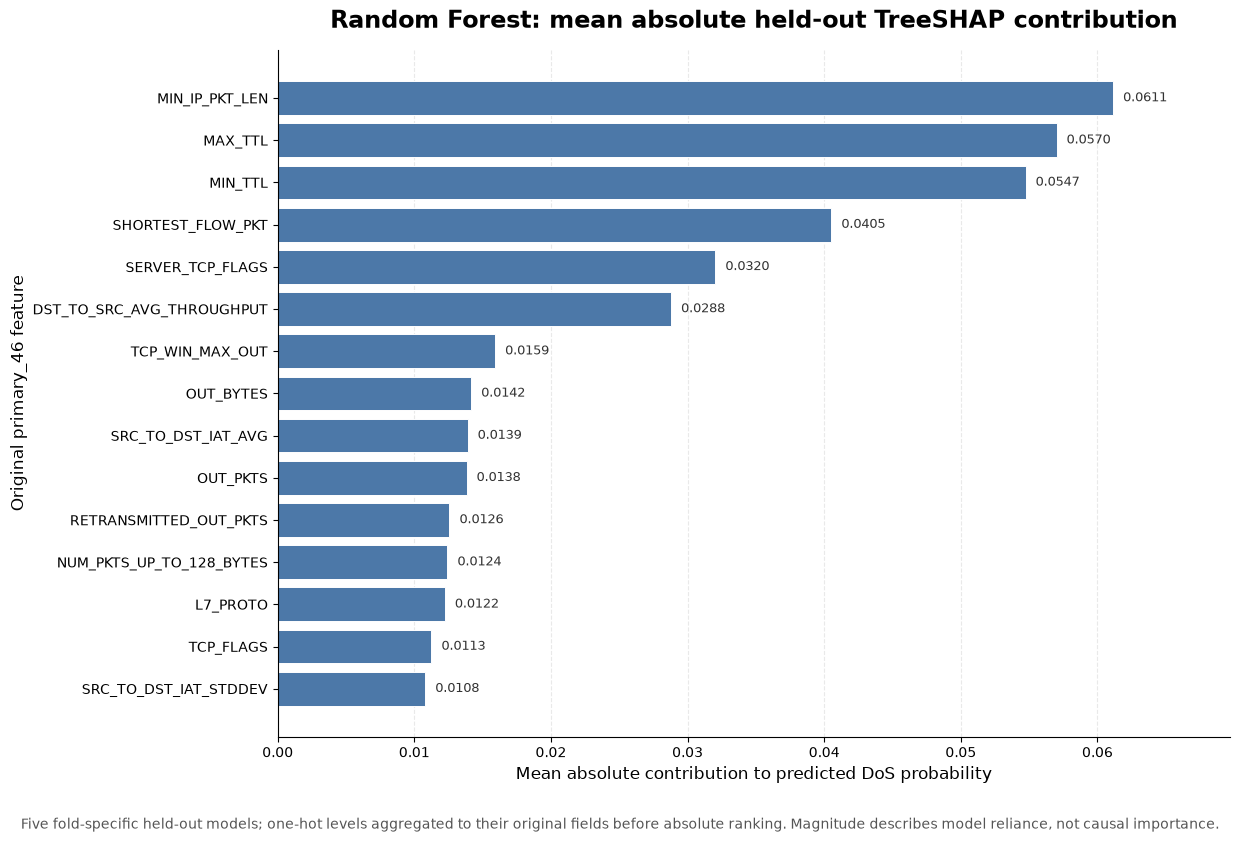


Random Forest TreeSHAP attribution gate summary:


,value
held_out_sample_count,200
original_feature_count,46
attribution_row_count,9200
top_five_attribution_row_count,1000
transformed_feature_count_minimum,458
transformed_feature_count_maximum,472
maximum_tree_shap_additivity_error,0.0
maximum_original_field_aggregation_error,0.0
attribution_check_count,10
passed_attribution_check_count,10



Verified held-out Random Forest TreeSHAP attribution completed. The formal values remain in memory; no model was refitted and no file was written.


In [19]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import display
from scipy import sparse


# -----------------------------------------------------------------------------
# 1. Freeze the formal attribution contract before the longer computation.
# -----------------------------------------------------------------------------
RF_SHAP_ADDITIVITY_TOLERANCE = 1e-10
RF_TOP_K = 5
RF_GLOBAL_PLOT_FEATURE_COUNT = 15

required_names = [
    "baseline_fitted_fold_models",
    "baseline_replication_cv_splits",
    "baseline_replication_X",
    "baseline_replication_y",
    "baseline_replication_sample_order",
    "baseline_replication_locked_features",
    "baseline_replication_quantitative_features",
    "baseline_replication_categorical_features",
    "baseline_replication_reconstructed_oof",
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

assert not missing_names, (
    "Required baseline-reconstruction objects are missing: "
    f"{missing_names}"
)

locked_features = list(
    baseline_replication_locked_features
)
quantitative_features = list(
    baseline_replication_quantitative_features
)
categorical_features = list(
    baseline_replication_categorical_features
)

locked_position = {
    feature_name: position
    for position, feature_name in enumerate(locked_features)
}

assert shap.__version__ == "0.51.0"
assert baseline_replication_X.shape == (200, 46)
assert len(baseline_replication_sample_order) == 200
assert len(baseline_replication_cv_splits) == 5
assert len(locked_features) == 46
assert len(quantitative_features) == 35
assert len(categorical_features) == 11
assert set(quantitative_features).isdisjoint(
    categorical_features
)
assert (
    set(quantitative_features)
    | set(categorical_features)
) == set(locked_features)

assert set(
    baseline_fitted_fold_models["random_forest"].keys()
) == {1, 2, 3, 4, 5}


# -----------------------------------------------------------------------------
# 2. Map every transformed column back to one of the original 46 fields.
# -----------------------------------------------------------------------------
def normalise_selected_columns(
    column_selector,
    input_columns,
):
    """
    Convert a ColumnTransformer selector to explicit input-column names.
    """
    input_columns = list(input_columns)

    if isinstance(column_selector, slice):
        return input_columns[column_selector]

    selected = list(column_selector)

    if not selected:
        return []

    if all(
        isinstance(value, (bool, np.bool_))
        for value in selected
    ):
        return [
            column_name
            for column_name, keep_column in zip(
                input_columns,
                selected,
            )
            if keep_column
        ]

    if all(
        isinstance(value, (int, np.integer))
        for value in selected
    ):
        return [
            input_columns[int(position)]
            for position in selected
        ]

    return [str(value) for value in selected]


def find_fitted_one_hot_encoder(transformer):
    """
    Find the fitted OneHotEncoder inside a transformer or pipeline.
    """
    if (
        hasattr(transformer, "categories_")
        and hasattr(
            transformer,
            "get_feature_names_out",
        )
    ):
        return transformer

    named_steps = getattr(
        transformer,
        "named_steps",
        None,
    )

    if named_steps is not None:
        for step in reversed(
            list(named_steps.values())
        ):
            if (
                hasattr(step, "categories_")
                and hasattr(
                    step,
                    "get_feature_names_out",
                )
            ):
                return step

    return None


def map_encoded_names_to_original(
    encoded_names,
    original_columns,
):
    """
    Map public OneHotEncoder output names back to source fields.
    """
    original_columns = [
        str(name)
        for name in original_columns
    ]

    mapping = []

    # Longest-first matching protects fields whose names share a prefix.
    longest_first = sorted(
        original_columns,
        key=len,
        reverse=True,
    )

    for encoded_name in encoded_names:
        encoded_name = str(encoded_name)

        candidates = [
            original_name
            for original_name in longest_first
            if encoded_name.startswith(
                f"{original_name}_"
            )
        ]

        if not candidates:
            raise ValueError(
                "Could not map an encoded feature to an "
                "original field: "
                f"{encoded_name!r}."
            )

        mapping.append(candidates[0])

    return mapping


def transformed_to_original_map(
    preprocessor,
    input_columns,
    output_count,
):
    """
    Return one original-field name for every transformed output column.
    """
    mapping = [None] * int(output_count)

    assert hasattr(
        preprocessor,
        "output_indices_",
    ), (
        "The fitted ColumnTransformer does not expose "
        "output_indices_."
    )

    for (
        transformer_name,
        transformer,
        selector,
    ) in preprocessor.transformers_:

        output_slice = (
            preprocessor.output_indices_.get(
                transformer_name
            )
        )

        if output_slice is None:
            continue

        output_start = int(output_slice.start)
        output_stop = int(output_slice.stop)
        block_output_count = (
            output_stop - output_start
        )

        if (
            block_output_count == 0
            or transformer == "drop"
        ):
            continue

        selected_columns = (
            normalise_selected_columns(
                selector,
                input_columns,
            )
        )

        if transformer == "passthrough":
            block_mapping = selected_columns

        elif set(selected_columns).issubset(
            set(quantitative_features)
        ):
            # Median imputation preserves one output column
            # per quantitative field.
            block_mapping = selected_columns

        elif set(selected_columns).issubset(
            set(categorical_features)
        ):
            encoder = (
                find_fitted_one_hot_encoder(
                    transformer
                )
            )

            if encoder is None:
                raise TypeError(
                    "The categorical transformer does not "
                    "contain a fitted OneHotEncoder."
                )

            encoded_names = (
                encoder.get_feature_names_out(
                    selected_columns
                )
            )

            block_mapping = (
                map_encoded_names_to_original(
                    encoded_names,
                    selected_columns,
                )
            )

        else:
            raise ValueError(
                "A preprocessing block could not be "
                "classified as purely quantitative or "
                "categorical. "
                f"Transformer: {transformer_name!r}; "
                f"columns: {selected_columns}."
            )

        if len(block_mapping) != block_output_count:
            raise ValueError(
                "The transformed-to-original mapping "
                "length does not match the fitted "
                "preprocessor output slice. "
                f"Transformer: {transformer_name!r}; "
                f"mapped: {len(block_mapping)}; "
                f"expected: {block_output_count}."
            )

        mapping[
            output_start:output_stop
        ] = block_mapping

    missing_positions = [
        position
        for position, feature_name in enumerate(mapping)
        if feature_name is None
    ]

    if missing_positions:
        raise ValueError(
            "Some transformed columns were not mapped "
            "to original fields: "
            f"{missing_positions[:20]}."
        )

    unknown_original_fields = sorted(
        set(mapping) - set(locked_features)
    )

    assert not unknown_original_fields, (
        "Transformed columns mapped outside primary_46: "
        f"{unknown_original_fields}"
    )

    return mapping


# -----------------------------------------------------------------------------
# 3. Normalise SHAP 0.51 binary output to class label 1 (DoS).
# -----------------------------------------------------------------------------
def positive_class_shap_matrix(
    raw_shap_values,
    class_count,
    class_index,
):
    """
    Extract an n_samples × n_features matrix for the requested class.

    SHAP versions and model families can represent binary outputs as a list,
    an n_samples × n_features matrix, or a three-dimensional class tensor.
    """
    if isinstance(raw_shap_values, list):
        matrix = np.asarray(
            raw_shap_values[class_index],
            dtype=float,
        )

    else:
        raw_array = np.asarray(
            raw_shap_values,
            dtype=float,
        )

        if raw_array.ndim == 2:
            matrix = raw_array

        elif (
            raw_array.ndim == 3
            and raw_array.shape[-1] == class_count
        ):
            matrix = raw_array[
                :,
                :,
                class_index,
            ]

        elif (
            raw_array.ndim == 3
            and raw_array.shape[0] == class_count
        ):
            matrix = raw_array[
                class_index,
                :,
                :,
            ]

        else:
            raise ValueError(
                "Unsupported SHAP output shape for a "
                "binary classifier: "
                f"{raw_array.shape}."
            )

    if matrix.ndim != 2:
        raise ValueError(
            "The normalised positive-class SHAP result "
            "is not two-dimensional: "
            f"{matrix.shape}."
        )

    return matrix


def positive_class_expected_value(
    raw_expected_value,
    class_index,
):
    """
    Extract the TreeExplainer expected value for class label 1.
    """
    expected_array = np.asarray(
        raw_expected_value,
        dtype=float,
    ).reshape(-1)

    if expected_array.size == 1:
        return float(expected_array[0])

    return float(
        expected_array[class_index]
    )


# -----------------------------------------------------------------------------
# 4. Explain each sample only with its corresponding held-out model.
# -----------------------------------------------------------------------------
fold_attribution_tables = []
fold_additivity_rows = []
fold_schema_rows = []

print(
    "Calculating formal held-out Random Forest "
    "TreeSHAP values for five folds."
)
print(
    "Each completion message represents 40 "
    "additional held-out samples.\n"
)

for fold_number, split_record in enumerate(
    baseline_replication_cv_splits,
    start=1,
):
    (
        training_positions,
        held_out_positions,
    ) = split_record

    held_out_positions = np.asarray(
        held_out_positions,
        dtype=int,
    )

    fold_pipeline = (
        baseline_fitted_fold_models[
            "random_forest"
        ][fold_number]
    )

    preprocessor = (
        fold_pipeline.named_steps[
            "preprocessing"
        ]
    )
    classifier = (
        fold_pipeline.named_steps[
            "classifier"
        ]
    )

    held_out_X_raw = (
        baseline_replication_X.iloc[
            held_out_positions
        ].copy()
    )

    held_out_y = np.asarray(
        baseline_replication_y
    )[held_out_positions]

    held_out_sample_ids = np.asarray(
        baseline_replication_sample_order,
        dtype=object,
    )[held_out_positions]

    transformed_X = preprocessor.transform(
        held_out_X_raw
    )

    # TreeExplainer requires a dense numeric array for this
    # scikit-learn Random Forest representation.
    if sparse.issparse(transformed_X):
        transformed_X = transformed_X.toarray()

    transformed_X = np.asarray(
        transformed_X,
        dtype=float,
    )

    class_labels = np.asarray(
        classifier.classes_
    )

    positive_matches = np.flatnonzero(
        class_labels == 1
    )

    assert positive_matches.size == 1, (
        "Random Forest class label 1 was not found "
        f"exactly once in fold {fold_number}: "
        f"{class_labels.tolist()}."
    )

    positive_class_index = int(
        positive_matches[0]
    )

    transformed_mapping = (
        transformed_to_original_map(
            preprocessor,
            baseline_replication_X.columns,
            transformed_X.shape[1],
        )
    )

    assert transformed_X.shape[0] == 40
    assert (
        transformed_X.shape[1]
        == classifier.n_features_in_
    )
    assert (
        len(transformed_mapping)
        == transformed_X.shape[1]
    )

    # tree_path_dependent uses the fitted tree structures as
    # its background distribution. The preceding preflight
    # confirmed additivity on the positive-class probability scale.
    explainer = shap.TreeExplainer(
        classifier,
        feature_perturbation=(
            "tree_path_dependent"
        ),
        model_output="raw",
    )

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=".*IProgress not found.*",
        )

        raw_shap_values = (
            explainer.shap_values(
                transformed_X,
                check_additivity=False,
            )
        )

    transformed_positive_shap = (
        positive_class_shap_matrix(
            raw_shap_values,
            class_count=len(class_labels),
            class_index=positive_class_index,
        )
    )

    expected_positive_probability = (
        positive_class_expected_value(
            explainer.expected_value,
            positive_class_index,
        )
    )

    assert (
        transformed_positive_shap.shape
        == transformed_X.shape
    )

    classifier_probability = (
        classifier.predict_proba(
            transformed_X
        )[:, positive_class_index]
    )

    pipeline_probability = (
        fold_pipeline.predict_proba(
            held_out_X_raw
        )[:, positive_class_index]
    )

    reconstructed_probability = (
        expected_positive_probability
        + transformed_positive_shap.sum(
            axis=1
        )
    )

    pipeline_classifier_error = float(
        np.max(
            np.abs(
                pipeline_probability
                - classifier_probability
            )
        )
    )

    additivity_errors = np.abs(
        reconstructed_probability
        - classifier_probability
    )

    maximum_additivity_error = float(
        additivity_errors.max()
    )
    mean_additivity_error = float(
        additivity_errors.mean()
    )

    assert (
        pipeline_classifier_error
        <= RF_SHAP_ADDITIVITY_TOLERANCE
    ), (
        "The raw pipeline and transformed classifier "
        "probabilities differ in fold "
        f"{fold_number}. Maximum difference: "
        f"{pipeline_classifier_error:.16g}."
    )

    assert (
        maximum_additivity_error
        <= RF_SHAP_ADDITIVITY_TOLERANCE
    ), (
        "TreeSHAP additivity failed in fold "
        f"{fold_number}. Maximum error: "
        f"{maximum_additivity_error:.16g}."
    )

    # Sum signed one-hot-level SHAP values before taking
    # absolute values. This preserves the net contribution
    # of each original categorical field.
    original_feature_shap = np.zeros(
        (
            len(held_out_positions),
            len(locked_features),
        ),
        dtype=float,
    )

    for (
        transformed_position,
        original_feature_name,
    ) in enumerate(transformed_mapping):

        original_position = locked_position[
            original_feature_name
        ]

        original_feature_shap[
            :,
            original_position,
        ] += transformed_positive_shap[
            :,
            transformed_position,
        ]

    aggregation_errors = np.abs(
        original_feature_shap.sum(axis=1)
        - transformed_positive_shap.sum(
            axis=1
        )
    )

    maximum_aggregation_error = float(
        aggregation_errors.max()
    )

    assert (
        maximum_aggregation_error
        <= RF_SHAP_ADDITIVITY_TOLERANCE
    ), (
        "Aggregating transformed SHAP values to "
        "original fields changed the total attribution "
        f"in fold {fold_number}. Maximum error: "
        f"{maximum_aggregation_error:.16g}."
    )

    fold_record_count = (
        len(held_out_positions)
        * len(locked_features)
    )

    fold_table = pd.DataFrame(
        {
            "sample_position": np.repeat(
                held_out_positions,
                len(locked_features),
            ),
            "sample_id": np.repeat(
                held_out_sample_ids,
                len(locked_features),
            ),
            "cv_fold": fold_number,
            "true_binary": np.repeat(
                held_out_y.astype(int),
                len(locked_features),
            ),
            "predicted_binary": np.repeat(
                (
                    classifier_probability
                    >= 0.5
                ).astype(int),
                len(locked_features),
            ),
            "dos_probability": np.repeat(
                classifier_probability,
                len(locked_features),
            ),
            "tree_shap_expected_probability": (
                np.repeat(
                    expected_positive_probability,
                    fold_record_count,
                )
            ),
            "tree_shap_reconstructed_probability": (
                np.repeat(
                    reconstructed_probability,
                    len(locked_features),
                )
            ),
            "locked_feature_position": np.tile(
                np.arange(
                    len(locked_features),
                    dtype=int,
                ),
                len(held_out_positions),
            ),
            "feature_name": np.tile(
                locked_features,
                len(held_out_positions),
            ),
            "observed_value": (
                held_out_X_raw.loc[
                    :,
                    locked_features,
                ]
                .to_numpy()
                .reshape(-1)
            ),
            "signed_probability_shap": (
                original_feature_shap.reshape(
                    -1
                )
            ),
            "absolute_probability_shap": (
                np.abs(
                    original_feature_shap
                ).reshape(-1)
            ),
        }
    )

    fold_attribution_tables.append(
        fold_table
    )

    fold_schema_rows.append(
        {
            "cv_fold": fold_number,
            "training_sample_count": len(
                training_positions
            ),
            "held_out_sample_count": len(
                held_out_positions
            ),
            "transformed_feature_count": (
                transformed_X.shape[1]
            ),
            "classifier_feature_count": (
                classifier.n_features_in_
            ),
            "mapped_original_feature_count": (
                len(set(transformed_mapping))
            ),
            "dimensions_match": (
                transformed_X.shape[1]
                == classifier.n_features_in_
            ),
            "mapping_covers_primary_46": (
                set(transformed_mapping)
                == set(locked_features)
            ),
        }
    )

    fold_additivity_rows.append(
        {
            "cv_fold": fold_number,
            "held_out_sample_count": len(
                held_out_positions
            ),
            "expected_positive_probability": (
                expected_positive_probability
            ),
            "maximum_pipeline_classifier_probability_error": (
                pipeline_classifier_error
            ),
            "maximum_tree_shap_additivity_error": (
                maximum_additivity_error
            ),
            "mean_tree_shap_additivity_error": (
                mean_additivity_error
            ),
            "maximum_original_field_aggregation_error": (
                maximum_aggregation_error
            ),
            "additivity_passed": (
                maximum_additivity_error
                <= RF_SHAP_ADDITIVITY_TOLERANCE
            ),
            "aggregation_passed": (
                maximum_aggregation_error
                <= RF_SHAP_ADDITIVITY_TOLERANCE
            ),
        }
    )

    print(
        f"Fold {fold_number}/5 completed: "
        f"40 held-out samples, "
        f"{transformed_X.shape[1]} transformed "
        "features, maximum additivity error "
        f"{maximum_additivity_error:.3e}."
    )


# -----------------------------------------------------------------------------
# 5. Combine folds and assign deterministic within-sample ranks.
# -----------------------------------------------------------------------------
random_forest_attribution_long = pd.concat(
    fold_attribution_tables,
    ignore_index=True,
)

random_forest_attribution_long = (
    random_forest_attribution_long
    .sort_values(
        [
            "sample_position",
            "absolute_probability_shap",
            "locked_feature_position",
        ],
        ascending=[True, False, True],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

random_forest_attribution_long[
    "absolute_contribution_rank"
] = (
    random_forest_attribution_long
    .groupby(
        "sample_id",
        sort=False,
    )
    .cumcount()
    .add(1)
    .astype(int)
)

random_forest_attribution_long[
    "contribution_direction"
] = np.select(
    [
        random_forest_attribution_long[
            "signed_probability_shap"
        ] > 0,
        random_forest_attribution_long[
            "signed_probability_shap"
        ] < 0,
    ],
    [
        "toward_DoS",
        "toward_Benign",
    ],
    default="neutral",
)

random_forest_top_five_attributions = (
    random_forest_attribution_long.loc[
        random_forest_attribution_long[
            "absolute_contribution_rank"
        ].le(RF_TOP_K)
    ]
    .sort_values(
        [
            "sample_position",
            "absolute_contribution_rank",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

random_forest_transformed_schema_audit = (
    pd.DataFrame(fold_schema_rows)
)

random_forest_additivity_audit = (
    pd.DataFrame(fold_additivity_rows)
)


# -----------------------------------------------------------------------------
# 6. Verify agreement with the reconstructed Notebook 09 OOF results.
# -----------------------------------------------------------------------------
random_forest_sample_predictions = (
    random_forest_attribution_long.loc[
        :,
        [
            "sample_position",
            "sample_id",
            "cv_fold",
            "true_binary",
            "predicted_binary",
            "dos_probability",
            "tree_shap_reconstructed_probability",
        ],
    ]
    .drop_duplicates(
        subset=["sample_id"]
    )
    .sort_values("sample_position")
    .reset_index(drop=True)
)

reference_oof = (
    baseline_replication_reconstructed_oof.loc[
        :,
        [
            "sample_id",
            "true_binary",
            "cv_fold",
            "random_forest_predicted_binary",
            "random_forest_dos_probability",
        ],
    ]
    .copy()
)

prediction_audit = (
    random_forest_sample_predictions.merge(
        reference_oof,
        on="sample_id",
        how="left",
        validate="one_to_one",
        suffixes=(
            "_tree_shap",
            "_notebook_09",
        ),
    )
)

prediction_audit["fold_matches"] = (
    prediction_audit[
        "cv_fold_tree_shap"
    ]
    == prediction_audit[
        "cv_fold_notebook_09"
    ]
)

prediction_audit[
    "true_label_matches"
] = (
    prediction_audit[
        "true_binary_tree_shap"
    ]
    == prediction_audit[
        "true_binary_notebook_09"
    ]
)

prediction_audit[
    "predicted_label_matches"
] = (
    prediction_audit["predicted_binary"]
    == prediction_audit[
        "random_forest_predicted_binary"
    ]
)

prediction_audit[
    "probability_absolute_error"
] = np.abs(
    prediction_audit["dos_probability"]
    - prediction_audit[
        "random_forest_dos_probability"
    ]
)


# -----------------------------------------------------------------------------
# 7. Apply strict integrity gates before interpretation or plotting.
# -----------------------------------------------------------------------------
per_sample_feature_counts = (
    random_forest_attribution_long
    .groupby("sample_id")[
        "feature_name"
    ]
    .nunique()
)

per_sample_top_five_counts = (
    random_forest_top_five_attributions
    .groupby("sample_id")[
        "feature_name"
    ]
    .nunique()
)

integrity_checks = pd.DataFrame(
    [
        {
            "check": (
                "Held-out samples explained"
            ),
            "observed": (
                random_forest_attribution_long[
                    "sample_id"
                ].nunique()
            ),
            "expected": 200,
            "passed": (
                random_forest_attribution_long[
                    "sample_id"
                ].nunique()
                == 200
            ),
        },
        {
            "check": (
                "Original-feature attribution rows"
            ),
            "observed": len(
                random_forest_attribution_long
            ),
            "expected": 200 * 46,
            "passed": (
                len(
                    random_forest_attribution_long
                )
                == 200 * 46
            ),
        },
        {
            "check": (
                "Samples with exactly 46 "
                "distinct original features"
            ),
            "observed": int(
                per_sample_feature_counts.eq(
                    46
                ).sum()
            ),
            "expected": 200,
            "passed": bool(
                per_sample_feature_counts.eq(
                    46
                ).all()
            ),
        },
        {
            "check": (
                "Samples with exactly five "
                "distinct top features"
            ),
            "observed": int(
                per_sample_top_five_counts.eq(
                    5
                ).sum()
            ),
            "expected": 200,
            "passed": bool(
                per_sample_top_five_counts.eq(
                    5
                ).all()
            ),
        },
        {
            "check": (
                "Fold assignments matching "
                "Notebook 09"
            ),
            "observed": int(
                prediction_audit[
                    "fold_matches"
                ].sum()
            ),
            "expected": 200,
            "passed": bool(
                prediction_audit[
                    "fold_matches"
                ].all()
            ),
        },
        {
            "check": (
                "True labels matching Notebook 09"
            ),
            "observed": int(
                prediction_audit[
                    "true_label_matches"
                ].sum()
            ),
            "expected": 200,
            "passed": bool(
                prediction_audit[
                    "true_label_matches"
                ].all()
            ),
        },
        {
            "check": (
                "Predictions matching verified "
                "Notebook 09 OOF results"
            ),
            "observed": int(
                prediction_audit[
                    "predicted_label_matches"
                ].sum()
            ),
            "expected": 200,
            "passed": bool(
                prediction_audit[
                    "predicted_label_matches"
                ].all()
            ),
        },
        {
            "check": (
                "Maximum Notebook 09 "
                "probability difference"
            ),
            "observed": float(
                prediction_audit[
                    "probability_absolute_error"
                ].max()
            ),
            "expected": (
                f"<= "
                f"{RF_SHAP_ADDITIVITY_TOLERANCE:.0e}"
            ),
            "passed": bool(
                prediction_audit[
                    "probability_absolute_error"
                ].max()
                <= RF_SHAP_ADDITIVITY_TOLERANCE
            ),
        },
        {
            "check": (
                "Maximum TreeSHAP probability "
                "additivity error"
            ),
            "observed": float(
                random_forest_additivity_audit[
                    "maximum_tree_shap_additivity_error"
                ].max()
            ),
            "expected": (
                f"<= "
                f"{RF_SHAP_ADDITIVITY_TOLERANCE:.0e}"
            ),
            "passed": bool(
                random_forest_additivity_audit[
                    "additivity_passed"
                ].all()
            ),
        },
        {
            "check": (
                "Maximum original-field "
                "aggregation error"
            ),
            "observed": float(
                random_forest_additivity_audit[
                    "maximum_original_field_aggregation_error"
                ].max()
            ),
            "expected": (
                f"<= "
                f"{RF_SHAP_ADDITIVITY_TOLERANCE:.0e}"
            ),
            "passed": bool(
                random_forest_additivity_audit[
                    "aggregation_passed"
                ].all()
            ),
        },
    ]
)

failed_integrity_checks = (
    integrity_checks.loc[
        ~integrity_checks["passed"]
    ].copy()
)


# -----------------------------------------------------------------------------
# 8. Display validation evidence before retaining analytical conclusions.
# -----------------------------------------------------------------------------
print(
    "\nRandom Forest TreeSHAP "
    "transformed-schema audit:"
)

display(
    random_forest_transformed_schema_audit.style.map(
        lambda value: (
            "background-color: #d9ead3; "
            "color: #274e13; "
            "font-weight: bold;"
            if value is True
            else (
                "background-color: #f4cccc; "
                "color: #990000; "
                "font-weight: bold;"
                if value is False
                else ""
            )
        ),
        subset=[
            "dimensions_match",
            "mapping_covers_primary_46",
        ],
    )
)

print(
    "\nRandom Forest TreeSHAP "
    "fold-level additivity audit:"
)

with pd.option_context(
    "display.float_format",
    "{:.12g}".format,
):
    display(
        random_forest_additivity_audit.style.map(
            lambda value: (
                "background-color: #d9ead3; "
                "color: #274e13; "
                "font-weight: bold;"
                if value is True
                else (
                    "background-color: #f4cccc; "
                    "color: #990000; "
                    "font-weight: bold;"
                    if value is False
                    else ""
                )
            ),
            subset=[
                "additivity_passed",
                "aggregation_passed",
            ],
        )
    )

print(
    "\nRandom Forest attribution "
    "integrity checks:"
)

with pd.option_context(
    "display.float_format",
    "{:.12g}".format,
):
    display(
        integrity_checks.style.map(
            lambda value: (
                "background-color: #d9ead3; "
                "color: #274e13; "
                "font-weight: bold;"
                if value is True
                else (
                    "background-color: #f4cccc; "
                    "color: #990000; "
                    "font-weight: bold;"
                    if value is False
                    else ""
                )
            ),
            subset=["passed"],
        )
    )

print(
    "\nFailed Random Forest "
    "attribution checks:"
)

if failed_integrity_checks.empty:
    print("None")
else:
    display(failed_integrity_checks)

assert failed_integrity_checks.empty, (
    "Formal Random Forest attribution failed "
    "one or more integrity gates. Do not use "
    "these values for alignment analysis."
)


# -----------------------------------------------------------------------------
# 9. Summarise global held-out attribution after every gate passes.
# -----------------------------------------------------------------------------
top_five_frequency = (
    random_forest_top_five_attributions[
        "feature_name"
    ]
    .value_counts()
    .rename("top_five_frequency")
)

random_forest_global_contribution_summary = (
    random_forest_attribution_long
    .groupby(
        "feature_name",
        as_index=False,
    )
    .agg(
        mean_absolute_probability_shap=(
            "absolute_probability_shap",
            "mean",
        ),
        median_absolute_probability_shap=(
            "absolute_probability_shap",
            "median",
        ),
        mean_signed_probability_shap=(
            "signed_probability_shap",
            "mean",
        ),
    )
    .merge(
        top_five_frequency,
        left_on="feature_name",
        right_index=True,
        how="left",
        validate="one_to_one",
    )
)

random_forest_global_contribution_summary[
    "top_five_frequency"
] = (
    random_forest_global_contribution_summary[
        "top_five_frequency"
    ]
    .fillna(0)
    .astype(int)
)

random_forest_global_contribution_summary[
    "locked_feature_position"
] = (
    random_forest_global_contribution_summary[
        "feature_name"
    ].map(locked_position)
)

random_forest_global_contribution_summary = (
    random_forest_global_contribution_summary
    .sort_values(
        [
            "mean_absolute_probability_shap",
            "locked_feature_position",
        ],
        ascending=[False, True],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

random_forest_global_contribution_summary[
    "global_mean_absolute_rank"
] = np.arange(
    1,
    (
        len(
            random_forest_global_contribution_summary
        )
        + 1
    ),
    dtype=int,
)


# -----------------------------------------------------------------------------
# 10. Display representative local and global attribution tables.
# -----------------------------------------------------------------------------
print(
    "\nFirst three samples: five largest "
    "absolute Random Forest SHAP values:"
)

first_three_sample_ids = (
    baseline_replication_sample_order[:3]
)

display_columns = [
    "sample_id",
    "cv_fold",
    "true_binary",
    "predicted_binary",
    "dos_probability",
    "absolute_contribution_rank",
    "feature_name",
    "signed_probability_shap",
    "absolute_probability_shap",
    "contribution_direction",
]

with pd.option_context(
    "display.float_format",
    "{:.6f}".format,
):
    display(
        random_forest_top_five_attributions.loc[
            random_forest_top_five_attributions[
                "sample_id"
            ].isin(first_three_sample_ids),
            display_columns,
        ]
    )

print(
    "\nGlobal held-out Random Forest "
    "contribution summary (top 15):"
)

with pd.option_context(
    "display.float_format",
    "{:.6f}".format,
):
    display(
        random_forest_global_contribution_summary.head(
            RF_GLOBAL_PLOT_FEATURE_COUNT
        )
    )


# -----------------------------------------------------------------------------
# 11. Publication-quality global attribution visualisation.
# -----------------------------------------------------------------------------
plot_table = (
    random_forest_global_contribution_summary
    .head(RF_GLOBAL_PLOT_FEATURE_COUNT)
    .sort_values(
        "mean_absolute_probability_shap",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(12.5, 8.5)
)

bars = ax.barh(
    plot_table["feature_name"],
    plot_table[
        "mean_absolute_probability_shap"
    ],
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.7,
)

ax.set_title(
    "Random Forest: mean absolute held-out "
    "TreeSHAP contribution",
    fontsize=17,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel(
    "Mean absolute contribution to predicted "
    "DoS probability",
    fontsize=12,
)

ax.set_ylabel(
    "Original primary_46 feature",
    fontsize=12,
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.28,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

maximum_bar_value = float(
    plot_table[
        "mean_absolute_probability_shap"
    ].max()
)

annotation_offset = (
    maximum_bar_value * 0.012
    if maximum_bar_value > 0
    else 0.001
)

for bar, value in zip(
    bars,
    plot_table[
        "mean_absolute_probability_shap"
    ],
):
    ax.text(
        float(value) + annotation_offset,
        (
            bar.get_y()
            + bar.get_height() / 2
        ),
        f"{float(value):.4f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333",
    )

ax.set_xlim(
    0,
    (
        maximum_bar_value * 1.14
        if maximum_bar_value > 0
        else 1
    ),
)

fig.text(
    0.5,
    0.015,
    (
        "Five fold-specific held-out models; "
        "one-hot levels aggregated to their "
        "original fields before absolute ranking. "
        "Magnitude describes model reliance, "
        "not causal importance."
    ),
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555",
)

plt.tight_layout(
    rect=[0, 0.055, 1, 1]
)
plt.show()


# -----------------------------------------------------------------------------
# 12. Retain an explicit gate summary for the alignment-analysis stage.
# -----------------------------------------------------------------------------
random_forest_attribution_gate_summary = pd.Series(
    {
        "held_out_sample_count": (
            random_forest_attribution_long[
                "sample_id"
            ].nunique()
        ),
        "original_feature_count": len(
            locked_features
        ),
        "attribution_row_count": len(
            random_forest_attribution_long
        ),
        "top_five_attribution_row_count": len(
            random_forest_top_five_attributions
        ),
        "transformed_feature_count_minimum": int(
            random_forest_transformed_schema_audit[
                "transformed_feature_count"
            ].min()
        ),
        "transformed_feature_count_maximum": int(
            random_forest_transformed_schema_audit[
                "transformed_feature_count"
            ].max()
        ),
        "maximum_tree_shap_additivity_error": float(
            random_forest_additivity_audit[
                "maximum_tree_shap_additivity_error"
            ].max()
        ),
        "maximum_original_field_aggregation_error": float(
            random_forest_additivity_audit[
                "maximum_original_field_aggregation_error"
            ].max()
        ),
        "attribution_check_count": len(
            integrity_checks
        ),
        "passed_attribution_check_count": int(
            integrity_checks["passed"].sum()
        ),
        "failed_attribution_check_count": int(
            (
                ~integrity_checks["passed"]
            ).sum()
        ),
        "attribution_scale": (
            "DoS probability"
        ),
        "feature_perturbation": (
            "tree_path_dependent"
        ),
        "ranking_basis": (
            "absolute original-feature "
            "TreeSHAP contribution"
        ),
        "one_hot_levels_aggregated_to_original_feature": True,
        "held_out_fold_models_used": True,
        "causal_interpretation_supported": False,
        "models_refitted_by_this_cell": False,
        "files_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "verified_random_forest_"
            "tree_shap_attribution"
        ),
    },
    name="value",
)

print(
    "\nRandom Forest TreeSHAP "
    "attribution gate summary:"
)

display(
    random_forest_attribution_gate_summary.to_frame()
)

print(
    "\nVerified held-out Random Forest TreeSHAP "
    "attribution completed. The formal values "
    "remain in memory; no model was refitted "
    "and no file was written."
)


## 10.6 Constructing the paired LLM–model attribution-alignment dataset

The preceding sections produced two independently validated conventional-model
reference explanations for every held-out pilot observation:

1. exact signed Logistic Regression contributions on the DoS log-odds scale; and
2. Random Forest TreeSHAP values on the predicted DoS-probability scale.

This section joins those reference explanations to the feature citations extracted
from the two LLM representation conditions. The analytical population remains the
178 pilot observations for which both representation conditions produced valid,
fully verified responses. Each observation therefore contributes four
response–reference combinations:

- deterministic-text response evaluated against Logistic Regression;
- structured response evaluated against Logistic Regression;
- deterministic-text response evaluated against Random Forest; and
- structured response evaluated against Random Forest.

The principal question is whether the five fields cited by an LLM response coincide
with the fields on which the corresponding held-out conventional model most strongly
relied for that same observation.

### Alignment measures

For each response and reference model, the following measures are constructed:

- **Top-five overlap count:** number of LLM-cited fields contained in the model's
  five largest absolute local attributions.
- **Top-five overlap fraction:** overlap count divided by five. Because both sets
  contain five fields, this is simultaneously precision@5 and recall@5.
- **Top-five Jaccard similarity:** intersection size divided by union size.
- **Attribution-mass coverage:** proportion of the model's total absolute local
  attribution carried by the five LLM-cited fields.
- **Relative top-five mass:** attribution mass captured by the LLM citations divided
  by the largest mass obtainable from any five fields—namely, the model's own five
  highest-ranked fields.
- **Mean cited reference rank:** mean model-attribution rank of the five cited fields;
  smaller values indicate stronger alignment.

The Logistic Regression and Random Forest raw attribution magnitudes are expressed
on different scales and must not be compared directly. All comparisons between
representation conditions will therefore be paired *within* each reference model.
The bounded overlap and normalized mass measures permit consistent interpretation
without treating log-odds contributions and probability-scale SHAP values as
numerically interchangeable.

Citation position is retained for traceability but is **not** interpreted as an
importance ranking. The response validation established that each answer cited five
distinct valid fields, but it did not establish that the order in which those fields
appeared represented a deliberate descending importance order.

This cell constructs and validates the analysis tables only. It performs no
hypothesis test, fits no model, changes no experimental object, writes no file, and
makes no network request. The descriptive means printed here are preliminary
summaries and are not inferential conclusions.

In [20]:
import numpy as np
import pandas as pd
from IPython.display import display


# -----------------------------------------------------------------------------
# 1. Freeze the paired alignment contract.
# -----------------------------------------------------------------------------
# Each valid LLM response cites exactly five distinct locked primary features.
ALIGNMENT_TOP_K = 5

# The paired analysis contains 178 samples and two representation conditions.
EXPECTED_PAIRED_SAMPLE_COUNT = 178
EXPECTED_RESPONSE_COUNT = 356

# Each response will be assessed against both independently verified models.
EXPECTED_REFERENCE_MODELS = {
    "logistic_regression",
    "random_forest",
}

EXPECTED_CONDITIONS = {
    "deterministic_text",
    "structured",
}

# These objects must already exist in the current Notebook 10 kernel.
required_alignment_objects = [
    "paired_citation_long",
    "paired_llm_records",
    "paired_sample_population",
    "logistic_attribution_long",
    "logistic_top_five_attributions",
    "logistic_attribution_gate_summary",
    "random_forest_attribution_long",
    "random_forest_top_five_attributions",
    "random_forest_attribution_gate_summary",
]

missing_alignment_objects = [
    object_name
    for object_name in required_alignment_objects
    if object_name not in globals()
]

assert not missing_alignment_objects, (
    "Required paired-alignment objects are missing: "
    f"{missing_alignment_objects}"
)

# Confirm the already established population and response counts before joining.
assert len(paired_sample_population) == EXPECTED_PAIRED_SAMPLE_COUNT
assert len(paired_llm_records) == EXPECTED_RESPONSE_COUNT
assert len(paired_citation_long) == EXPECTED_RESPONSE_COUNT * ALIGNMENT_TOP_K
assert set(paired_citation_long["condition"].unique()) == EXPECTED_CONDITIONS


# -----------------------------------------------------------------------------
# 2. Validate the citation schema and retain only the fields needed here.
# -----------------------------------------------------------------------------
required_citation_columns = [
    "record_index",
    "sample_id",
    "model_profile_id",
    "condition",
    "true_label",
    "predicted_label",
    "citation_position",
    "feature_name",
    "cited_observed_value",
    "source_observed_value",
    "feature_name_present",
    "feature_in_locked_primary_46",
    "observed_value_matches_source",
]

missing_citation_columns = sorted(
    set(required_citation_columns) - set(paired_citation_long.columns)
)

assert not missing_citation_columns, (
    "The paired citation table is missing required columns: "
    f"{missing_citation_columns}"
)

paired_citation_base = (
    paired_citation_long.loc[:, required_citation_columns]
    .copy()
    .sort_values(
        ["record_index", "condition", "citation_position"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

# A response is uniquely identified by its record, sample, and condition.
response_key = ["record_index", "sample_id", "condition"]

# Reconfirm the five-citation response contract immediately before alignment.
citation_group_audit = (
    paired_citation_base
    .groupby(response_key, as_index=False)
    .agg(
        citation_count=("feature_name", "size"),
        distinct_cited_feature_count=("feature_name", "nunique"),
        distinct_citation_position_count=("citation_position", "nunique"),
        minimum_citation_position=("citation_position", "min"),
        maximum_citation_position=("citation_position", "max"),
        all_feature_names_present=("feature_name_present", "all"),
        all_features_in_primary_46=("feature_in_locked_primary_46", "all"),
        all_observed_values_match=("observed_value_matches_source", "all"),
    )
)

assert len(citation_group_audit) == EXPECTED_RESPONSE_COUNT
assert citation_group_audit["citation_count"].eq(ALIGNMENT_TOP_K).all()
assert citation_group_audit["distinct_cited_feature_count"].eq(
    ALIGNMENT_TOP_K
).all()
assert citation_group_audit["distinct_citation_position_count"].eq(
    ALIGNMENT_TOP_K
).all()
assert citation_group_audit["minimum_citation_position"].eq(1).all()
assert citation_group_audit["maximum_citation_position"].eq(5).all()
assert citation_group_audit["all_feature_names_present"].all()
assert citation_group_audit["all_features_in_primary_46"].all()
assert citation_group_audit["all_observed_values_match"].all()


# -----------------------------------------------------------------------------
# 3. Standardise LR and RF attributions to one reference-table schema.
# -----------------------------------------------------------------------------
# The two models use different attribution scales and column names. They are
# standardised here without treating their raw magnitudes as interchangeable.
reference_specifications = {
    "logistic_regression": {
        "table": logistic_attribution_long,
        "rank_column": "absolute_contribution_rank",
        "signed_column": "signed_log_odds_contribution",
        "absolute_column": "absolute_log_odds_contribution",
        "attribution_scale": "DoS log-odds",
    },
    "random_forest": {
        "table": random_forest_attribution_long,
        "rank_column": "absolute_contribution_rank",
        "signed_column": "signed_probability_shap",
        "absolute_column": "absolute_probability_shap",
        "attribution_scale": "DoS probability",
    },
}

standardised_reference_tables = {}
reference_contract_rows = []

for reference_model, specification in reference_specifications.items():
    source_table = specification["table"]

    required_reference_columns = {
        "sample_id",
        "feature_name",
        specification["rank_column"],
        specification["signed_column"],
        specification["absolute_column"],
    }

    missing_reference_columns = sorted(
        required_reference_columns - set(source_table.columns)
    )

    assert not missing_reference_columns, (
        f"{reference_model} attribution is missing columns: "
        f"{missing_reference_columns}"
    )

    # Retain only the fields necessary for the alignment calculation and rename
    # model-specific columns to a shared reference schema.
    reference_table = (
        source_table.loc[
            :,
            [
                "sample_id",
                "feature_name",
                specification["rank_column"],
                specification["signed_column"],
                specification["absolute_column"],
            ],
        ]
        .rename(
            columns={
                specification["rank_column"]: "reference_absolute_rank",
                specification["signed_column"]: "reference_signed_attribution",
                specification["absolute_column"]: "reference_absolute_attribution",
            }
        )
        .copy()
    )

    reference_table["reference_model"] = reference_model
    reference_table["attribution_scale"] = specification[
        "attribution_scale"
    ]

    reference_table["reference_is_top_five"] = reference_table[
        "reference_absolute_rank"
    ].le(ALIGNMENT_TOP_K)

    # Every model must contain exactly one attribution for each of the 46
    # original locked features for each of the 200 held-out samples.
    per_sample_reference_count = (
        reference_table
        .groupby("sample_id")["feature_name"]
        .nunique()
    )

    per_sample_rank_count = (
        reference_table
        .groupby("sample_id")["reference_absolute_rank"]
        .nunique()
    )

    total_absolute_attribution = (
        reference_table
        .groupby("sample_id")["reference_absolute_attribution"]
        .sum()
    )

    assert len(reference_table) == 200 * 46
    assert reference_table["sample_id"].nunique() == 200
    assert per_sample_reference_count.eq(46).all()
    assert per_sample_rank_count.eq(46).all()
    assert total_absolute_attribution.gt(0).all()

    assert not reference_table.duplicated(
        subset=["sample_id", "feature_name"]
    ).any()

    standardised_reference_tables[reference_model] = reference_table

    reference_contract_rows.append(
        {
            "reference_model": reference_model,
            "attribution_scale": specification["attribution_scale"],
            "sample_count": reference_table["sample_id"].nunique(),
            "original_feature_count_per_sample": int(
                per_sample_reference_count.min()
            ),
            "attribution_row_count": len(reference_table),
            "all_sample_totals_positive": bool(
                total_absolute_attribution.gt(0).all()
            ),
        }
    )

reference_contract_table = pd.DataFrame(reference_contract_rows)


# -----------------------------------------------------------------------------
# 4. Join every verified citation to the corresponding LR and RF attribution.
# -----------------------------------------------------------------------------
alignment_feature_tables = []
alignment_summary_tables = []

response_metadata_columns = [
    "record_index",
    "sample_id",
    "model_profile_id",
    "condition",
    "true_label",
    "predicted_label",
]

for reference_model, reference_table in standardised_reference_tables.items():
    # Restrict the model-attribution table to the 178 samples retained in the
    # paired LLM analysis. The original 200-sample reference remains unchanged.
    paired_reference_table = reference_table.loc[
        reference_table["sample_id"].isin(
            paired_citation_base["sample_id"].unique()
        )
    ].copy()

    # Materialise the top-five contribution before grouping. This avoids
    # depending on groupby index behaviour inside a custom aggregation.
    paired_reference_table[
        "reference_top_five_absolute_component"
    ] = np.where(
        paired_reference_table["reference_is_top_five"],
        paired_reference_table["reference_absolute_attribution"],
        0.0,
    )

    # Calculate the denominator for the total attribution-mass measure and the
    # denominator for the relative-to-optimal-five measure.
    reference_totals = (
        paired_reference_table
        .groupby("sample_id", as_index=False)
        .agg(
            reference_total_absolute_attribution=(
                "reference_absolute_attribution",
                "sum",
            ),
            reference_top_five_absolute_attribution=(
                "reference_top_five_absolute_component",
                "sum",
            ),
        )
    )

    # Retain the ordered model top-five feature names for auditability.
    reference_top_five_lists = (
        paired_reference_table.loc[
            paired_reference_table["reference_is_top_five"]
        ]
        .sort_values(
            ["sample_id", "reference_absolute_rank"],
            kind="mergesort",
        )
        .groupby("sample_id")["feature_name"]
        .agg(tuple)
        .rename("reference_top_five_features")
    )

    # Join each LLM-cited field to the same sample's model attribution.
    # many_to_one guarantees one reference attribution per sample–feature pair.
    feature_alignment = paired_citation_base.merge(
        paired_reference_table,
        on=["sample_id", "feature_name"],
        how="left",
        validate="many_to_one",
    )

    # Missing values here would mean that a supposedly valid cited feature did
    # not have a corresponding attribution in the locked 46-feature model.
    assert feature_alignment["reference_absolute_rank"].notna().all()
    assert feature_alignment["reference_absolute_attribution"].notna().all()

    feature_alignment["citation_matches_reference_top_five"] = (
        feature_alignment["reference_is_top_five"].astype(bool)
    )

    alignment_feature_tables.append(feature_alignment)

    # Collapse the five feature-level citation rows to one response–model row.
    grouped_alignment = (
        feature_alignment
        .groupby(
            response_metadata_columns
            + ["reference_model", "attribution_scale"],
            as_index=False,
            sort=False,
        )
        .agg(
            citation_count=("feature_name", "size"),
            distinct_cited_feature_count=("feature_name", "nunique"),
            top_five_overlap_count=(
                "citation_matches_reference_top_five",
                "sum",
            ),
            cited_absolute_attribution_sum=(
                "reference_absolute_attribution",
                "sum",
            ),
            mean_cited_reference_rank=(
                "reference_absolute_rank",
                "mean",
            ),
            best_cited_reference_rank=(
                "reference_absolute_rank",
                "min",
            ),
            worst_cited_reference_rank=(
                "reference_absolute_rank",
                "max",
            ),
        )
    )

    # Preserve citation order only as an audit trace. It is not treated as a
    # model-importance ordering in any metric.
    cited_feature_lists = (
        feature_alignment
        .sort_values(
            response_key + ["citation_position"],
            kind="mergesort",
        )
        .groupby(response_key)["feature_name"]
        .agg(tuple)
        .rename("cited_features")
        .reset_index()
    )

    grouped_alignment = (
        grouped_alignment
        .merge(
            cited_feature_lists,
            on=response_key,
            how="left",
            validate="one_to_one",
        )
        .merge(
            reference_totals,
            on="sample_id",
            how="left",
            validate="many_to_one",
        )
        .merge(
            reference_top_five_lists.reset_index(),
            on="sample_id",
            how="left",
            validate="many_to_one",
        )
    )

    grouped_alignment["top_five_overlap_count"] = grouped_alignment[
        "top_five_overlap_count"
    ].astype(int)

    # Both the LLM citation set and model reference set contain five fields.
    grouped_alignment["top_five_overlap_fraction"] = (
        grouped_alignment["top_five_overlap_count"] / ALIGNMENT_TOP_K
    )

    grouped_alignment["top_five_jaccard"] = (
        grouped_alignment["top_five_overlap_count"]
        /
        (
            2 * ALIGNMENT_TOP_K
            - grouped_alignment["top_five_overlap_count"]
        )
    )

    # Fraction of the model's total absolute local attribution carried by the
    # five fields cited in the LLM answer.
    grouped_alignment["attribution_mass_coverage"] = (
        grouped_alignment["cited_absolute_attribution_sum"]
        / grouped_alignment["reference_total_absolute_attribution"]
    )

    # Ratio to the largest mass obtainable from any five fields. The model's
    # own five highest absolute attributions provide that upper bound.
    grouped_alignment["relative_to_reference_top_five_mass"] = (
        grouped_alignment["cited_absolute_attribution_sum"]
        / grouped_alignment["reference_top_five_absolute_attribution"]
    )

    alignment_summary_tables.append(grouped_alignment)


# Feature-level table: 356 responses × 5 citations × 2 reference models.
paired_alignment_feature_long = pd.concat(
    alignment_feature_tables,
    ignore_index=True,
)

# Response-level table: 356 responses × 2 reference models.
paired_alignment_summary = pd.concat(
    alignment_summary_tables,
    ignore_index=True,
)

paired_alignment_feature_long = (
    paired_alignment_feature_long
    .sort_values(
        [
            "record_index",
            "condition",
            "reference_model",
            "citation_position",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

paired_alignment_summary = (
    paired_alignment_summary
    .sort_values(
        ["sample_id", "reference_model", "condition"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# 5. Validate the complete 178-sample × 2-condition × 2-model design.
# -----------------------------------------------------------------------------
complete_design_counts = (
    paired_alignment_summary
    .groupby(["reference_model", "condition"], as_index=False)
    .agg(
        response_count=("record_index", "size"),
        unique_sample_count=("sample_id", "nunique"),
        mean_top_five_overlap_count=("top_five_overlap_count", "mean"),
        mean_top_five_jaccard=("top_five_jaccard", "mean"),
        mean_attribution_mass_coverage=(
            "attribution_mass_coverage",
            "mean",
        ),
    )
)

sample_design_counts = (
    paired_alignment_summary
    .groupby("sample_id")
    .agg(
        condition_count=("condition", "nunique"),
        reference_model_count=("reference_model", "nunique"),
        analysis_row_count=("record_index", "size"),
    )
)

alignment_integrity_checks = pd.DataFrame(
    [
        {
            "check": "Paired samples represented",
            "observed": paired_alignment_summary["sample_id"].nunique(),
            "expected": EXPECTED_PAIRED_SAMPLE_COUNT,
            "passed": (
                paired_alignment_summary["sample_id"].nunique()
                == EXPECTED_PAIRED_SAMPLE_COUNT
            ),
        },
        {
            "check": "Validated LLM responses represented",
            "observed": paired_alignment_summary[
                ["record_index", "condition"]
            ].drop_duplicates().shape[0],
            "expected": EXPECTED_RESPONSE_COUNT,
            "passed": (
                paired_alignment_summary[
                    ["record_index", "condition"]
                ].drop_duplicates().shape[0]
                == EXPECTED_RESPONSE_COUNT
            ),
        },
        {
            "check": "Reference models represented",
            "observed": paired_alignment_summary[
                "reference_model"
            ].nunique(),
            "expected": 2,
            "passed": (
                set(
                    paired_alignment_summary[
                        "reference_model"
                    ].unique()
                )
                == EXPECTED_REFERENCE_MODELS
            ),
        },
        {
            "check": "Response-by-reference summary rows",
            "observed": len(paired_alignment_summary),
            "expected": EXPECTED_RESPONSE_COUNT * 2,
            "passed": (
                len(paired_alignment_summary)
                == EXPECTED_RESPONSE_COUNT * 2
            ),
        },
        {
            "check": "Citation-by-reference feature rows",
            "observed": len(paired_alignment_feature_long),
            "expected": (
                EXPECTED_RESPONSE_COUNT
                * ALIGNMENT_TOP_K
                * 2
            ),
            "passed": (
                len(paired_alignment_feature_long)
                == EXPECTED_RESPONSE_COUNT * ALIGNMENT_TOP_K * 2
            ),
        },
        {
            "check": (
                "Every sample has both conditions and both references"
            ),
            "observed": int(
                (
                    sample_design_counts["condition_count"].eq(2)
                    & sample_design_counts[
                        "reference_model_count"
                    ].eq(2)
                    & sample_design_counts[
                        "analysis_row_count"
                    ].eq(4)
                ).sum()
            ),
            "expected": EXPECTED_PAIRED_SAMPLE_COUNT,
            "passed": bool(
                (
                    sample_design_counts["condition_count"].eq(2)
                    & sample_design_counts[
                        "reference_model_count"
                    ].eq(2)
                    & sample_design_counts[
                        "analysis_row_count"
                    ].eq(4)
                ).all()
            ),
        },
        {
            "check": "Every analysis row contains five citations",
            "observed": int(
                paired_alignment_summary[
                    "citation_count"
                ].eq(5).sum()
            ),
            "expected": EXPECTED_RESPONSE_COUNT * 2,
            "passed": bool(
                paired_alignment_summary[
                    "citation_count"
                ].eq(5).all()
            ),
        },
        {
            "check": (
                "Every citation matched a reference attribution"
            ),
            "observed": int(
                paired_alignment_feature_long[
                    "reference_absolute_attribution"
                ].notna().sum()
            ),
            "expected": (
                EXPECTED_RESPONSE_COUNT
                * ALIGNMENT_TOP_K
                * 2
            ),
            "passed": bool(
                paired_alignment_feature_long[
                    "reference_absolute_attribution"
                ].notna().all()
            ),
        },
        {
            "check": (
                "Set-alignment metrics remain within [0, 1]"
            ),
            "observed": int(
                paired_alignment_summary[
                    [
                        "top_five_overlap_fraction",
                        "top_five_jaccard",
                    ]
                ]
                .apply(
                    lambda column: column.between(0, 1)
                )
                .all(axis=1)
                .sum()
            ),
            "expected": EXPECTED_RESPONSE_COUNT * 2,
            "passed": bool(
                paired_alignment_summary[
                    [
                        "top_five_overlap_fraction",
                        "top_five_jaccard",
                    ]
                ]
                .apply(
                    lambda column: column.between(0, 1)
                )
                .all()
                .all()
            ),
        },
        {
            "check": (
                "Attribution-mass metrics remain within [0, 1]"
            ),
            "observed": int(
                paired_alignment_summary[
                    [
                        "attribution_mass_coverage",
                        "relative_to_reference_top_five_mass",
                    ]
                ]
                .apply(
                    lambda column: column.between(
                        -1e-12,
                        1 + 1e-12,
                    )
                )
                .all(axis=1)
                .sum()
            ),
            "expected": EXPECTED_RESPONSE_COUNT * 2,
            "passed": bool(
                paired_alignment_summary[
                    [
                        "attribution_mass_coverage",
                        "relative_to_reference_top_five_mass",
                    ]
                ]
                .apply(
                    lambda column: column.between(
                        -1e-12,
                        1 + 1e-12,
                    )
                )
                .all()
                .all()
            ),
        },
    ]
)

failed_alignment_checks = alignment_integrity_checks.loc[
    ~alignment_integrity_checks["passed"]
].copy()


# -----------------------------------------------------------------------------
# 6. Explain the measures and display validated descriptive results.
# -----------------------------------------------------------------------------
alignment_metric_dictionary = pd.DataFrame(
    [
        {
            "metric": "top_five_overlap_count",
            "range": "0 to 5",
            "interpretation": (
                "Number of the LLM's five cited fields also present "
                "in the reference model's five largest absolute "
                "local attributions."
            ),
            "primary_or_supporting": "primary",
        },
        {
            "metric": "top_five_overlap_fraction",
            "range": "0 to 1",
            "interpretation": (
                "Top-five overlap divided by five; equivalent to "
                "precision@5 and recall@5 because both sets contain "
                "five fields."
            ),
            "primary_or_supporting": "primary",
        },
        {
            "metric": "top_five_jaccard",
            "range": "0 to 1",
            "interpretation": (
                "Intersection divided by union for the two "
                "five-field sets."
            ),
            "primary_or_supporting": "primary",
        },
        {
            "metric": "attribution_mass_coverage",
            "range": "0 to 1",
            "interpretation": (
                "Fraction of all absolute local model attribution "
                "captured by the five fields cited by the LLM."
            ),
            "primary_or_supporting": "primary",
        },
        {
            "metric": "relative_to_reference_top_five_mass",
            "range": "0 to 1",
            "interpretation": (
                "Absolute attribution captured by the LLM citations "
                "divided by the maximum mass obtainable from the "
                "model's own top five."
            ),
            "primary_or_supporting": "supporting",
        },
        {
            "metric": "mean_cited_reference_rank",
            "range": "1 to 46",
            "interpretation": (
                "Mean local model rank of the five cited fields; "
                "lower is better."
            ),
            "primary_or_supporting": "supporting",
        },
    ]
)

print("Reference-attribution contract:")
display(reference_contract_table)

print("\nAlignment metric dictionary:")
with pd.option_context("display.max_colwidth", None):
    display(alignment_metric_dictionary)

print("\nPaired alignment integrity checks:")
display(
    alignment_integrity_checks.style.map(
        lambda value: (
            "background-color: #d9ead3; "
            "color: #274e13; "
            "font-weight: bold;"
            if value is True
            else (
                "background-color: #f4cccc; "
                "color: #990000; "
                "font-weight: bold;"
                if value is False
                else ""
            )
        ),
        subset=["passed"],
    )
)

print("\nFailed paired alignment checks:")
if failed_alignment_checks.empty:
    print("None")
else:
    display(failed_alignment_checks)

# Stop before inference if even one construction contract fails.
assert failed_alignment_checks.empty, (
    "The paired LLM–model alignment table failed one or more "
    "integrity gates. Do not proceed to paired statistical inference."
)

print("\nComplete paired design and preliminary descriptive means:")
with pd.option_context(
    "display.float_format",
    "{:.6f}".format,
):
    display(complete_design_counts)

# Show a fully traceable feature-level example for the first retained sample.
first_sample_id = paired_sample_population["sample_id"].iloc[0]

print(f"\nFeature-level alignment example for {first_sample_id}:")
with pd.option_context(
    "display.max_columns", None,
    "display.width", 220,
    "display.float_format", "{:.6f}".format,
):
    display(
        paired_alignment_feature_long.loc[
            paired_alignment_feature_long[
                "sample_id"
            ].eq(first_sample_id),
            [
                "sample_id",
                "condition",
                "reference_model",
                "citation_position",
                "feature_name",
                "reference_absolute_rank",
                "reference_signed_attribution",
                "reference_absolute_attribution",
                "citation_matches_reference_top_five",
            ],
        ]
    )


# -----------------------------------------------------------------------------
# 7. Retain an explicit construction summary for the inference stage.
# -----------------------------------------------------------------------------
paired_alignment_construction_summary = pd.Series(
    {
        "paired_sample_count": (
            paired_alignment_summary["sample_id"].nunique()
        ),
        "validated_response_count": EXPECTED_RESPONSE_COUNT,
        "reference_model_count": (
            paired_alignment_summary[
                "reference_model"
            ].nunique()
        ),
        "response_reference_summary_row_count": len(
            paired_alignment_summary
        ),
        "citation_reference_feature_row_count": len(
            paired_alignment_feature_long
        ),
        "primary_metric_count": int(
            alignment_metric_dictionary[
                "primary_or_supporting"
            ].eq("primary").sum()
        ),
        "integrity_check_count": len(
            alignment_integrity_checks
        ),
        "passed_integrity_check_count": int(
            alignment_integrity_checks["passed"].sum()
        ),
        "failed_integrity_check_count": int(
            (~alignment_integrity_checks["passed"]).sum()
        ),
        "citation_order_used_as_model_rank": False,
        "analysis_population_changed": False,
        "statistical_tests_performed": False,
        "models_refitted_by_this_cell": False,
        "files_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "paired_llm_model_alignment_construction"
        ),
    },
    name="value",
)

print("\nPaired LLM–model alignment construction summary:")
display(paired_alignment_construction_summary.to_frame())

print(
    "\nThe complete 178-sample paired LLM–model alignment table "
    "is ready. No statistical test has yet been performed and "
    "no file was written."
)

Reference-attribution contract:


,reference_model,attribution_scale,sample_count,original_feature_count_per_sample,attribution_row_count,all_sample_totals_positive
0,logistic_regression,DoS log-odds,200,46,9200,True
1,random_forest,DoS probability,200,46,9200,True



Alignment metric dictionary:


,metric,range,interpretation,primary_or_supporting
0,top_five_overlap_count,0 to 5,Number of the LLM's five cited fields also present in the reference model's five largest absolute local attributions.,primary
1,top_five_overlap_fraction,0 to 1,Top-five overlap divided by five; equivalent to precision@5 and recall@5 because both sets contain five fields.,primary
2,top_five_jaccard,0 to 1,Intersection divided by union for the two five-field sets.,primary
3,attribution_mass_coverage,0 to 1,Fraction of all absolute local model attribution captured by the five fields cited by the LLM.,primary
4,relative_to_reference_top_five_mass,0 to 1,Absolute attribution captured by the LLM citations divided by the maximum mass obtainable from the model's own top five.,supporting
5,mean_cited_reference_rank,1 to 46,Mean local model rank of the five cited fields; lower is better.,supporting



Paired alignment integrity checks:


...


Feature-level alignment example for pilot_001:


,sample_id,condition,reference_model,citation_position,feature_name,reference_absolute_rank,reference_signed_attribution,reference_absolute_attribution,citation_matches_reference_top_five
0,pilot_001,deterministic_text,logistic_regression,1,TCP_FLAGS,8,0.153523,0.153523,False
1,pilot_001,deterministic_text,logistic_regression,2,IN_PKTS,21,0.029212,0.029212,False
2,pilot_001,deterministic_text,logistic_regression,3,OUT_PKTS,36,-0.005305,0.005305,False
3,pilot_001,deterministic_text,logistic_regression,4,SRC_TO_DST_AVG_THROUGHPUT,15,0.083111,0.083111,False
4,pilot_001,deterministic_text,logistic_regression,5,FLOW_DURATION_MILLISECONDS,31,-0.007563,0.007563,False
5,pilot_001,deterministic_text,random_forest,1,TCP_FLAGS,9,0.015962,0.015962,False
6,pilot_001,deterministic_text,random_forest,2,IN_PKTS,27,0.004117,0.004117,False
7,pilot_001,deterministic_text,random_forest,3,OUT_PKTS,20,0.007309,0.007309,False
8,pilot_001,deterministic_text,random_forest,4,SRC_TO_DST_AVG_THROUGHPUT,14,0.010326,0.010326,False
9,pilot_001,deterministic_text,random_forest,5,FLOW_DURATION_MILLISECONDS,16,0.009251,0.009251,False



Paired LLM–model alignment construction summary:


,value
paired_sample_count,178
validated_response_count,356
reference_model_count,2
response_reference_summary_row_count,712
citation_reference_feature_row_count,3560
primary_metric_count,4
integrity_check_count,10
passed_integrity_check_count,10
failed_integrity_check_count,0
citation_order_used_as_model_rank,False



The complete 178-sample paired LLM–model alignment table is ready. No statistical test has yet been performed and no file was written.


## 10.7 Confirmatory paired inference for representation-dependent alignment

The validated alignment dataset contains 178 observations for which both the
deterministic-text and structured representation conditions produced valid LLM
responses. The experimental comparison is therefore conducted within observation:
each structured-condition alignment score is subtracted from the corresponding
deterministic-text score for the same sample and reference model.

The paired difference is defined as:

\[
\Delta_i =
\text{Alignment}_{i,\mathrm{structured}}
-
\text{Alignment}_{i,\mathrm{deterministic\ text}}.
\]

Consequently:

- a positive difference favours the structured representation;
- a negative difference favours deterministic text; and
- a difference of zero indicates equal alignment for that observation.

### Confirmatory outcomes

The top-five overlap count, overlap fraction, and Jaccard similarity are all
deterministic transformations of the same five-versus-five set intersection.
Treating all three as independent confirmatory outcomes would repeatedly test
essentially the same signal. The confirmatory family is therefore restricted to
two complementary outcomes:

1. **Top-five overlap fraction**, representing direct set agreement between the
   five cited LLM fields and the model's five largest absolute local attributions.
2. **Attribution-mass coverage**, representing the proportion of the model's
   total absolute local attribution captured by the five cited LLM fields.

Jaccard similarity, raw overlap count, relative top-five mass, and mean cited
reference rank remain available as descriptive or supporting measures.

### Statistical procedure

For each combination of reference model and confirmatory outcome, this section
reports:

- the mean under each representation condition;
- the mean paired difference;
- a 95% paired percentile-bootstrap confidence interval based on 20,000
  resamples of the 178 sample-level differences;
- a two-sided paired sign-flip randomisation test based on 100,000
  randomisations;
- paired Cohen's \(d_z\) as a standardised supporting effect size; and
- the numbers of samples for which structured alignment was higher, equal, or
  lower.

Four confirmatory hypotheses are tested: two outcomes for Logistic Regression
and two outcomes for Random Forest. Holm correction controls the family-wise
error rate at 0.05 across these four tests.

The Logistic Regression and Random Forest analyses remain separate. Their raw
attribution values operate on different scales—DoS log-odds and DoS probability,
respectively—and are not pooled or directly compared.

The confidence intervals and randomisation tests use the sample-level paired
difference as the resampling unit. The 712 response–reference rows are not treated
as 712 independent observations.

This cell performs no model fitting, changes no analysis population, writes no
file, and makes no network request. Statistical significance, if present, should
be interpreted together with the raw paired difference, confidence interval, and
practical effect size rather than as evidence of causal feature importance.

In [23]:
import pandas as pd
from IPython.display import display


# -----------------------------------------------------------------------------
# Paired-inference preflight: validate inputs without running any statistics.
# -----------------------------------------------------------------------------
EXPECTED_PAIRED_SAMPLE_COUNT = 178

EXPECTED_CONDITIONS = {
    "deterministic_text",
    "structured",
}

EXPECTED_REFERENCE_MODELS = {
    "logistic_regression",
    "random_forest",
}

PRIMARY_INFERENCE_METRICS = [
    "top_five_overlap_fraction",
    "attribution_mass_coverage",
]


# Confirm that the preceding alignment-construction cell has been run.
assert "paired_alignment_summary" in globals(), (
    "paired_alignment_summary is missing. Run the preceding paired-alignment "
    "construction cell first."
)


# Confirm that the response-level alignment table contains every field needed
# by the subsequent paired statistical analysis.
required_inference_columns = {
    "sample_id",
    "reference_model",
    "condition",
    *PRIMARY_INFERENCE_METRICS,
}

missing_inference_columns = sorted(
    required_inference_columns
    - set(paired_alignment_summary.columns)
)

assert not missing_inference_columns, (
    "paired_alignment_summary is missing required columns: "
    f"{missing_inference_columns}"
)


# -----------------------------------------------------------------------------
# Audit the four expected model-condition groups.
# -----------------------------------------------------------------------------
inference_design_audit = (
    paired_alignment_summary
    .groupby(
        [
            "reference_model",
            "condition",
        ],
        as_index=False,
    )
    .agg(
        analysis_row_count=(
            "sample_id",
            "size",
        ),
        unique_sample_count=(
            "sample_id",
            "nunique",
        ),
        missing_overlap_count=(
            "top_five_overlap_fraction",
            lambda values: int(values.isna().sum()),
        ),
        missing_mass_count=(
            "attribution_mass_coverage",
            lambda values: int(values.isna().sum()),
        ),
    )
)


# Construct the exact four model-condition combinations expected by design.
expected_design_pairs = {
    (reference_model, condition)
    for reference_model in EXPECTED_REFERENCE_MODELS
    for condition in EXPECTED_CONDITIONS
}

observed_design_pairs = set(
    inference_design_audit[
        [
            "reference_model",
            "condition",
        ]
    ].itertuples(
        index=False,
        name=None,
    )
)


# Each sample must occur exactly once for each model-condition combination.
paired_key_duplicate_count = int(
    paired_alignment_summary.duplicated(
        subset=[
            "sample_id",
            "reference_model",
            "condition",
        ]
    ).sum()
)


# -----------------------------------------------------------------------------
# Construct explicit pass/fail gates before running any resampling inference.
# -----------------------------------------------------------------------------
paired_inference_preflight_checks = pd.DataFrame(
    [
        {
            "check": "Four model-condition groups represented",
            "observed": len(observed_design_pairs),
            "expected": 4,
            "passed": (
                observed_design_pairs
                == expected_design_pairs
            ),
        },
        {
            "check": "Every group contains 178 rows",
            "observed": int(
                inference_design_audit[
                    "analysis_row_count"
                ].eq(
                    EXPECTED_PAIRED_SAMPLE_COUNT
                ).sum()
            ),
            "expected": 4,
            "passed": bool(
                inference_design_audit[
                    "analysis_row_count"
                ].eq(
                    EXPECTED_PAIRED_SAMPLE_COUNT
                ).all()
            ),
        },
        {
            "check": "Every group contains 178 unique samples",
            "observed": int(
                inference_design_audit[
                    "unique_sample_count"
                ].eq(
                    EXPECTED_PAIRED_SAMPLE_COUNT
                ).sum()
            ),
            "expected": 4,
            "passed": bool(
                inference_design_audit[
                    "unique_sample_count"
                ].eq(
                    EXPECTED_PAIRED_SAMPLE_COUNT
                ).all()
            ),
        },
        {
            "check": "Duplicate sample-model-condition keys",
            "observed": paired_key_duplicate_count,
            "expected": 0,
            "passed": (
                paired_key_duplicate_count == 0
            ),
        },
        {
            "check": "Missing confirmatory metric values",
            "observed": int(
                inference_design_audit[
                    [
                        "missing_overlap_count",
                        "missing_mass_count",
                    ]
                ].to_numpy().sum()
            ),
            "expected": 0,
            "passed": bool(
                inference_design_audit[
                    [
                        "missing_overlap_count",
                        "missing_mass_count",
                    ]
                ].to_numpy().sum() == 0
            ),
        },
    ]
)

failed_paired_inference_preflight_checks = (
    paired_inference_preflight_checks.loc[
        ~paired_inference_preflight_checks[
            "passed"
        ]
    ].copy()
)


# -----------------------------------------------------------------------------
# Display the design audit and colour-coded validation gates.
# -----------------------------------------------------------------------------
print("Paired-inference design audit:")

display(inference_design_audit)


print("\nPaired-inference preflight checks:")

display(
    paired_inference_preflight_checks.style.map(
        lambda value: (
            "background-color: #d9ead3; "
            "color: #274e13; "
            "font-weight: bold;"
            if value is True
            else (
                "background-color: #f4cccc; "
                "color: #990000; "
                "font-weight: bold;"
                if value is False
                else ""
            )
        ),
        subset=["passed"],
    )
)


print("\nFailed paired-inference preflight checks:")

if failed_paired_inference_preflight_checks.empty:
    print("None")
else:
    display(
        failed_paired_inference_preflight_checks
    )


# Stop before statistical inference if any design requirement fails.
assert failed_paired_inference_preflight_checks.empty, (
    "Paired-inference preflight failed. "
    "Do not run resampling inference yet."
)


# -----------------------------------------------------------------------------
# Retain an auditable preflight summary in kernel memory.
# -----------------------------------------------------------------------------
paired_inference_preflight_summary = pd.Series(
    {
        "paired_sample_count": (
            EXPECTED_PAIRED_SAMPLE_COUNT
        ),
        "model_condition_group_count": len(
            observed_design_pairs
        ),
        "confirmatory_metric_count": len(
            PRIMARY_INFERENCE_METRICS
        ),
        "preflight_check_count": len(
            paired_inference_preflight_checks
        ),
        "passed_preflight_check_count": int(
            paired_inference_preflight_checks[
                "passed"
            ].sum()
        ),
        "failed_preflight_check_count": int(
            (
                ~paired_inference_preflight_checks[
                    "passed"
                ]
            ).sum()
        ),
        "statistical_tests_performed": False,
        "models_refitted_by_this_cell": False,
        "files_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "paired_inference_preflight_passed"
        ),
    },
    name="value",
)


print("\nPaired-inference preflight summary:")

display(
    paired_inference_preflight_summary.to_frame()
)


print(
    "\nPaired-inference preflight passed. "
    "The data are ready for paired resampling inference; "
    "no statistical test has yet been performed."
)

Paired-inference design audit:


,reference_model,condition,analysis_row_count,unique_sample_count,missing_overlap_count,missing_mass_count
0,logistic_regression,deterministic_text,178,178,0,0
1,logistic_regression,structured,178,178,0,0
2,random_forest,deterministic_text,178,178,0,0
3,random_forest,structured,178,178,0,0



Paired-inference preflight checks:


,check,observed,expected,passed
0,Four model-condition groups represented,4,4,True
1,Every group contains 178 rows,4,4,True
2,Every group contains 178 unique samples,4,4,True
3,Duplicate sample-model-condition keys,0,0,True
4,Missing confirmatory metric values,0,0,True



Failed paired-inference preflight checks:
None

Paired-inference preflight summary:


,value
paired_sample_count,178
model_condition_group_count,4
confirmatory_metric_count,2
preflight_check_count,5
passed_preflight_check_count,5
failed_preflight_check_count,0
statistical_tests_performed,False
models_refitted_by_this_cell,False
files_written_by_this_cell,False
network_request_made,False



Paired-inference preflight passed. The data are ready for paired resampling inference; no statistical test has yet been performed.


## 10.7 Paired confirmatory inference for representation-dependent alignment

The preceding section established a complete and internally consistent analytical
design containing 178 paired pilot observations. For every observation, the
deterministic-text and structured LLM responses were evaluated against both the
held-out Logistic Regression explanation and the held-out Random Forest TreeSHAP
explanation.

This section performs the confirmatory paired comparison between the two
representation conditions.

### Paired estimand

For every sample, reference model, and alignment measure, the effect is defined as:

\[
\Delta_i =
\text{Alignment}_{i,\mathrm{structured}}
-
\text{Alignment}_{i,\mathrm{deterministic\ text}}
\]

The reported point estimate is the mean of these 178 within-sample differences:

\[
\bar{\Delta}
=
\frac{1}{178}
\sum_{i=1}^{178}\Delta_i
\]

Therefore:

- a positive value favours the structured representation;
- a negative value favours deterministic text; and
- a value near zero indicates little average difference.

The sample—not an individual citation or response–reference row—is the independent
resampling unit. This preserves the paired experimental structure and prevents the
712 response–reference rows from being incorrectly treated as 712 independent
observations.

### Confirmatory outcomes

Only two non-redundant outcomes are treated as confirmatory:

1. **Top-five overlap fraction**, measuring direct set agreement between the five
   LLM-cited fields and the model's five strongest local attributions.
2. **Attribution-mass coverage**, measuring the proportion of total absolute local
   model attribution captured by the five LLM-cited fields.

Top-five overlap count, overlap fraction, and Jaccard similarity are all deterministic
functions of the same five-versus-five intersection count. Testing all three as
separate primary hypotheses would repeatedly test essentially the same information.
Consequently, overlap count and Jaccard similarity remain descriptive or supporting
measures rather than additional confirmatory outcomes.

### Statistical procedure

For each reference-model–outcome combination, this section reports:

- the mean under each representation condition;
- the paired mean difference;
- a 95% paired percentile-bootstrap confidence interval using 20,000 resamples;
- a two-sided paired sign-flip randomisation test using 100,000 randomisations;
- paired Cohen's \(d_z\) as a standardised supporting effect size;
- counts of samples favouring structured input, favouring deterministic text, or
  producing an equal value.

Four confirmatory hypotheses are evaluated: two outcomes for each of two reference
models. Holm correction controls the family-wise error rate at 0.05 across this
four-test family.

The Logistic Regression and Random Forest analyses remain separate because their
raw explanations use different scales. The alignment outcomes are bounded and
normalised, but the underlying Logistic Regression contributions are on the DoS
log-odds scale whereas Random Forest TreeSHAP values are on the DoS-probability
scale.

Statistical significance will not be interpreted as practical importance by itself.
The paired effect estimate, confidence interval, direction counts, and standardised
effect size must be considered together.

This cell does not refit either model, alter the analytical population, write a file,
or make a network request.

Paired-inference integrity checks:


,check,observed,expected,passed
0,Confirmatory hypothesis count,4,4,True
1,Every hypothesis uses 178 paired samples,4,4,True
2,All confidence intervals are ordered,4,4,True
3,"All raw p-values are within [0, 1]",4,4,True
4,"All Holm-adjusted p-values are within [0, 1]",4,4,True
5,Holm p-values are not smaller than raw p-values,4,4,True
6,Direction counts sum to 178 for every hypothesis,4,4,True



Failed paired-inference checks:
None

Confirmatory paired comparison results (difference = structured − deterministic text):


,reference_model_label,metric_label,paired_sample_count,deterministic_text_mean,structured_mean,mean_paired_difference,ci_95_lower,ci_95_upper,paired_cohens_dz,structured_higher_count,equal_count,structured_lower_count,raw_randomisation_p_value,holm_adjusted_p_value,reject_holm_0_05,estimated_direction
0,Logistic Regression,Top-five overlap fraction,178,0.110112,0.096629,-0.013483,-0.032584,0.005618,-0.103434,29,108,41,0.206798,0.827192,False,deterministic text higher
1,Logistic Regression,Attribution-mass coverage,178,0.100752,0.092356,-0.008397,-0.021624,0.004741,-0.094457,80,7,91,0.208268,0.827192,False,deterministic text higher
2,Random Forest,Top-five overlap fraction,178,0.051685,0.047191,-0.004494,-0.022472,0.014607,-0.035757,27,117,34,0.721993,1.000000,False,deterministic text higher
3,Random Forest,Attribution-mass coverage,178,0.107022,0.107497,0.000475,-0.007854,0.008741,0.008319,89,7,82,0.912231,1.000000,False,structured higher


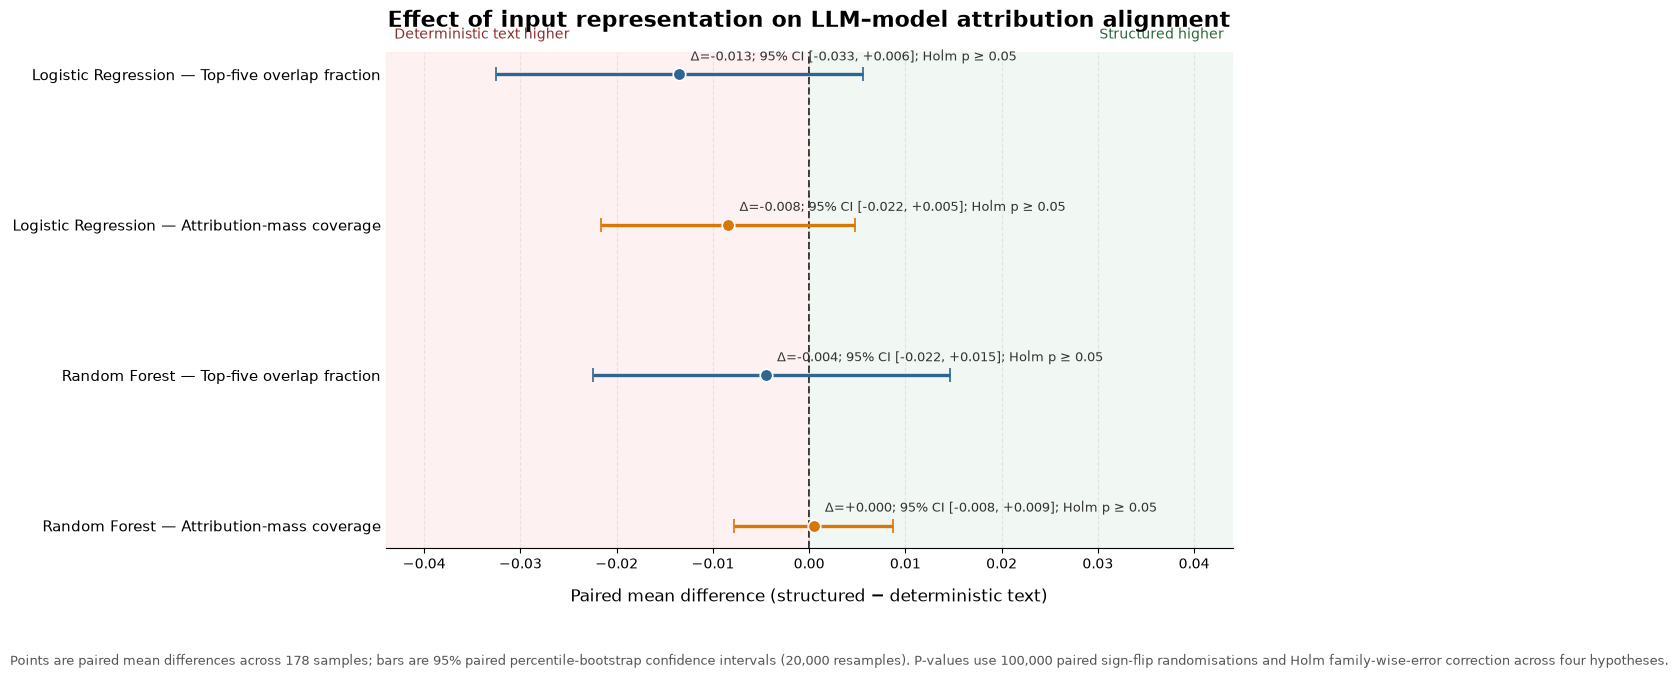


Paired alignment inference summary:


,value
paired_sample_count,178
reference_model_count,2
confirmatory_metric_count,2
confirmatory_hypothesis_count,4
difference_definition,structured minus deterministic_text
bootstrap_replicate_count,20000
permutation_replicate_count,100000
random_seed,742
confidence_level,0.95
multiplicity_method,Holm family-wise error control



Paired confirmatory inference completed. The result table and figure remain in memory; no model was refitted and no file was written.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# -----------------------------------------------------------------------------
# 1. Lock the confirmatory paired-inference contract.
# -----------------------------------------------------------------------------
INFERENCE_RANDOM_SEED = 742
BOOTSTRAP_REPLICATES = 20_000
PERMUTATION_REPLICATES = 100_000
CONFIDENCE_LEVEL = 0.95
FAMILYWISE_ALPHA = 0.05
EXPECTED_PAIRED_SAMPLE_COUNT = 178

# Overlap count, overlap fraction, and Jaccard are deterministic functions of
# the same five-versus-five set intersection. Testing all three would count
# essentially the same signal repeatedly. Retain one set-based outcome and one
# attribution-mass outcome as the two confirmatory measures.
PRIMARY_ALIGNMENT_METRICS = {
    "top_five_overlap_fraction": {
        "display_name": "Top-five overlap fraction",
        "interpretation_unit": "proportion",
    },
    "attribution_mass_coverage": {
        "display_name": "Attribution-mass coverage",
        "interpretation_unit": "proportion",
    },
}

REFERENCE_MODEL_LABELS = {
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
}

CONDITION_ORDER = [
    "deterministic_text",
    "structured",
]

DIFFERENCE_DEFINITION = "structured minus deterministic_text"

assert "paired_alignment_summary" in globals(), (
    "paired_alignment_summary is missing. Run the preceding paired-alignment "
    "construction cell first."
)

required_inference_columns = {
    "sample_id",
    "reference_model",
    "condition",
    *PRIMARY_ALIGNMENT_METRICS.keys(),
}

missing_inference_columns = sorted(
    required_inference_columns
    - set(paired_alignment_summary.columns)
)

assert not missing_inference_columns, (
    "paired_alignment_summary is missing required inference columns: "
    f"{missing_inference_columns}"
)


# -----------------------------------------------------------------------------
# 2. Define memory-bounded paired resampling and multiplicity functions.
# -----------------------------------------------------------------------------
def paired_bootstrap_mean_ci(
    differences,
    rng,
    replicate_count=BOOTSTRAP_REPLICATES,
    confidence_level=CONFIDENCE_LEVEL,
    batch_size=2_000,
):
    """
    Calculate a paired percentile-bootstrap confidence interval.

    The paired difference is the resampling unit. Therefore, the two
    representation conditions cannot become separated during resampling.
    """
    values = np.asarray(differences, dtype=float)

    assert values.ndim == 1
    assert values.size > 1
    assert np.isfinite(values).all()

    bootstrap_means = np.empty(
        replicate_count,
        dtype=float,
    )

    completed = 0

    while completed < replicate_count:
        current_batch_size = min(
            batch_size,
            replicate_count - completed,
        )

        sampled_indices = rng.integers(
            low=0,
            high=values.size,
            size=(current_batch_size, values.size),
        )

        bootstrap_means[
            completed:completed + current_batch_size
        ] = values[sampled_indices].mean(axis=1)

        completed += current_batch_size

    tail_probability = (
        1.0 - confidence_level
    ) / 2.0

    lower, upper = np.quantile(
        bootstrap_means,
        [
            tail_probability,
            1.0 - tail_probability,
        ],
    )

    return float(lower), float(upper)


def paired_sign_flip_p_value(
    differences,
    rng,
    replicate_count=PERMUTATION_REPLICATES,
    batch_size=5_000,
):
    """
    Calculate a two-sided paired sign-flip randomisation p-value.

    Under the paired null hypothesis, the labels 'structured' and
    'deterministic text' are exchangeable within each sample. Exchanging
    those labels is equivalent to reversing the sign of that sample's
    paired difference.
    """
    values = np.asarray(differences, dtype=float)

    assert values.ndim == 1
    assert values.size > 1
    assert np.isfinite(values).all()

    observed_absolute_mean = abs(values.mean())

    # Protect comparisons at the floating-point boundary.
    comparison_tolerance = 1e-15

    at_least_as_extreme = 0
    completed = 0

    while completed < replicate_count:
        current_batch_size = min(
            batch_size,
            replicate_count - completed,
        )

        random_signs = rng.choice(
            np.array([-1.0, 1.0]),
            size=(current_batch_size, values.size),
            replace=True,
        )

        permuted_absolute_means = np.abs(
            (random_signs * values).mean(axis=1)
        )

        at_least_as_extreme += int(
            (
                permuted_absolute_means
                >= observed_absolute_mean - comparison_tolerance
            ).sum()
        )

        completed += current_batch_size

    # The plus-one correction prevents a Monte Carlo p-value of exactly zero.
    corrected_p_value = (
        at_least_as_extreme + 1
    ) / (
        replicate_count + 1
    )

    return float(corrected_p_value)


def holm_adjust(raw_p_values):
    """
    Calculate Holm family-wise-error-adjusted p-values.
    """
    p_values = np.asarray(
        raw_p_values,
        dtype=float,
    )

    assert p_values.ndim == 1
    assert np.isfinite(p_values).all()
    assert (
        (p_values >= 0)
        & (p_values <= 1)
    ).all()

    hypothesis_count = p_values.size

    order = np.argsort(
        p_values,
        kind="mergesort",
    )

    ordered_p_values = p_values[order]

    ordered_adjusted = np.maximum.accumulate(
        (
            hypothesis_count
            - np.arange(hypothesis_count)
        )
        * ordered_p_values
    )

    ordered_adjusted = np.minimum(
        ordered_adjusted,
        1.0,
    )

    adjusted_p_values = np.empty(
        hypothesis_count,
        dtype=float,
    )

    adjusted_p_values[order] = ordered_adjusted

    return adjusted_p_values


# -----------------------------------------------------------------------------
# 3. Construct one paired vector for every model–metric hypothesis.
# -----------------------------------------------------------------------------
hypothesis_count = (
    len(REFERENCE_MODEL_LABELS)
    * len(PRIMARY_ALIGNMENT_METRICS)
)

# SeedSequence produces deterministic but independent random streams for every
# model–metric hypothesis.
seed_sequence = np.random.SeedSequence(
    INFERENCE_RANDOM_SEED
)

hypothesis_seed_sequences = seed_sequence.spawn(
    hypothesis_count
)

paired_difference_tables = {}
inference_rows = []
hypothesis_index = 0

for reference_model, reference_label in (
    REFERENCE_MODEL_LABELS.items()
):
    for metric_name, metric_specification in (
        PRIMARY_ALIGNMENT_METRICS.items()
    ):
        metric_subset = paired_alignment_summary.loc[
            paired_alignment_summary[
                "reference_model"
            ].eq(reference_model),
            [
                "sample_id",
                "condition",
                metric_name,
            ],
        ].copy()

        # Every sample must contain exactly one value under each condition.
        # pivot will raise an exception if duplicate sample-condition rows exist.
        paired_wide = metric_subset.pivot(
            index="sample_id",
            columns="condition",
            values=metric_name,
        )

        assert set(paired_wide.columns) == set(
            CONDITION_ORDER
        )

        paired_wide = paired_wide.loc[
            :,
            CONDITION_ORDER,
        ]

        assert len(paired_wide) == EXPECTED_PAIRED_SAMPLE_COUNT
        assert paired_wide.notna().all().all()

        # Positive differences favour structured input.
        paired_wide["paired_difference"] = (
            paired_wide["structured"]
            - paired_wide["deterministic_text"]
        )

        differences = paired_wide[
            "paired_difference"
        ].to_numpy(dtype=float)

        # Use separate deterministic random streams for the confidence interval
        # and randomisation test.
        bootstrap_seed, permutation_seed = (
            hypothesis_seed_sequences[
                hypothesis_index
            ].spawn(2)
        )

        bootstrap_rng = np.random.default_rng(
            bootstrap_seed
        )

        permutation_rng = np.random.default_rng(
            permutation_seed
        )

        (
            confidence_interval_lower,
            confidence_interval_upper,
        ) = paired_bootstrap_mean_ci(
            differences=differences,
            rng=bootstrap_rng,
        )

        raw_p_value = paired_sign_flip_p_value(
            differences=differences,
            rng=permutation_rng,
        )

        difference_standard_deviation = differences.std(
            ddof=1
        )

        paired_cohens_dz = (
            differences.mean()
            / difference_standard_deviation
            if difference_standard_deviation > 0
            else np.nan
        )

        paired_wide = paired_wide.reset_index()
        paired_wide["reference_model"] = reference_model
        paired_wide["metric"] = metric_name

        paired_difference_tables[
            (reference_model, metric_name)
        ] = paired_wide

        inference_rows.append(
            {
                "reference_model": reference_model,
                "reference_model_label": reference_label,
                "metric": metric_name,
                "metric_label": metric_specification[
                    "display_name"
                ],
                "paired_sample_count": len(differences),
                "deterministic_text_mean": float(
                    paired_wide[
                        "deterministic_text"
                    ].mean()
                ),
                "structured_mean": float(
                    paired_wide[
                        "structured"
                    ].mean()
                ),
                "mean_paired_difference": float(
                    differences.mean()
                ),
                "ci_95_lower": (
                    confidence_interval_lower
                ),
                "ci_95_upper": (
                    confidence_interval_upper
                ),
                "paired_cohens_dz": float(
                    paired_cohens_dz
                ),
                "structured_higher_count": int(
                    (differences > 0).sum()
                ),
                "equal_count": int(
                    (differences == 0).sum()
                ),
                "structured_lower_count": int(
                    (differences < 0).sum()
                ),
                "raw_randomisation_p_value": (
                    raw_p_value
                ),
            }
        )

        hypothesis_index += 1

paired_alignment_inference = pd.DataFrame(
    inference_rows
)


# -----------------------------------------------------------------------------
# 4. Control family-wise error across four confirmatory hypotheses.
# -----------------------------------------------------------------------------
paired_alignment_inference[
    "holm_adjusted_p_value"
] = holm_adjust(
    paired_alignment_inference[
        "raw_randomisation_p_value"
    ].to_numpy()
)

paired_alignment_inference[
    "reject_holm_0_05"
] = paired_alignment_inference[
    "holm_adjusted_p_value"
].le(FAMILYWISE_ALPHA)

paired_alignment_inference[
    "ci_excludes_zero"
] = (
    (
        paired_alignment_inference[
            "ci_95_lower"
        ] > 0
    )
    | (
        paired_alignment_inference[
            "ci_95_upper"
        ] < 0
    )
)

paired_alignment_inference[
    "estimated_direction"
] = np.select(
    [
        paired_alignment_inference[
            "mean_paired_difference"
        ] > 0,
        paired_alignment_inference[
            "mean_paired_difference"
        ] < 0,
    ],
    [
        "structured higher",
        "deterministic text higher",
    ],
    default="no mean difference",
)

# For overlap fraction, multiplying the difference by five gives the average
# difference in the number of overlapping fields per response.
paired_alignment_inference[
    "overlap_field_count_difference"
] = np.where(
    paired_alignment_inference[
        "metric"
    ].eq("top_five_overlap_fraction"),
    paired_alignment_inference[
        "mean_paired_difference"
    ] * 5.0,
    np.nan,
)


# -----------------------------------------------------------------------------
# 5. Validate the inference design and numerical results.
# -----------------------------------------------------------------------------
paired_inference_integrity_checks = pd.DataFrame(
    [
        {
            "check": "Confirmatory hypothesis count",
            "observed": len(
                paired_alignment_inference
            ),
            "expected": 4,
            "passed": (
                len(paired_alignment_inference) == 4
            ),
        },
        {
            "check": (
                "Every hypothesis uses 178 paired samples"
            ),
            "observed": int(
                paired_alignment_inference[
                    "paired_sample_count"
                ].eq(
                    EXPECTED_PAIRED_SAMPLE_COUNT
                ).sum()
            ),
            "expected": 4,
            "passed": bool(
                paired_alignment_inference[
                    "paired_sample_count"
                ].eq(
                    EXPECTED_PAIRED_SAMPLE_COUNT
                ).all()
            ),
        },
        {
            "check": (
                "All confidence intervals are ordered"
            ),
            "observed": int(
                (
                    paired_alignment_inference[
                        "ci_95_lower"
                    ]
                    <= paired_alignment_inference[
                        "ci_95_upper"
                    ]
                ).sum()
            ),
            "expected": 4,
            "passed": bool(
                (
                    paired_alignment_inference[
                        "ci_95_lower"
                    ]
                    <= paired_alignment_inference[
                        "ci_95_upper"
                    ]
                ).all()
            ),
        },
        {
            "check": (
                "All raw p-values are within [0, 1]"
            ),
            "observed": int(
                paired_alignment_inference[
                    "raw_randomisation_p_value"
                ].between(0, 1).sum()
            ),
            "expected": 4,
            "passed": bool(
                paired_alignment_inference[
                    "raw_randomisation_p_value"
                ].between(0, 1).all()
            ),
        },
        {
            "check": (
                "All Holm-adjusted p-values are within [0, 1]"
            ),
            "observed": int(
                paired_alignment_inference[
                    "holm_adjusted_p_value"
                ].between(0, 1).sum()
            ),
            "expected": 4,
            "passed": bool(
                paired_alignment_inference[
                    "holm_adjusted_p_value"
                ].between(0, 1).all()
            ),
        },
        {
            "check": (
                "Holm p-values are not smaller than raw p-values"
            ),
            "observed": int(
                (
                    paired_alignment_inference[
                        "holm_adjusted_p_value"
                    ]
                    >= paired_alignment_inference[
                        "raw_randomisation_p_value"
                    ] - 1e-15
                ).sum()
            ),
            "expected": 4,
            "passed": bool(
                (
                    paired_alignment_inference[
                        "holm_adjusted_p_value"
                    ]
                    >= paired_alignment_inference[
                        "raw_randomisation_p_value"
                    ] - 1e-15
                ).all()
            ),
        },
        {
            "check": (
                "Direction counts sum to 178 for every hypothesis"
            ),
            "observed": int(
                (
                    paired_alignment_inference[
                        "structured_higher_count"
                    ]
                    + paired_alignment_inference[
                        "equal_count"
                    ]
                    + paired_alignment_inference[
                        "structured_lower_count"
                    ]
                ).eq(
                    EXPECTED_PAIRED_SAMPLE_COUNT
                ).sum()
            ),
            "expected": 4,
            "passed": bool(
                (
                    paired_alignment_inference[
                        "structured_higher_count"
                    ]
                    + paired_alignment_inference[
                        "equal_count"
                    ]
                    + paired_alignment_inference[
                        "structured_lower_count"
                    ]
                ).eq(
                    EXPECTED_PAIRED_SAMPLE_COUNT
                ).all()
            ),
        },
    ]
)

failed_paired_inference_checks = (
    paired_inference_integrity_checks.loc[
        ~paired_inference_integrity_checks[
            "passed"
        ]
    ].copy()
)

print("Paired-inference integrity checks:")

display(
    paired_inference_integrity_checks.style.map(
        lambda value: (
            "background-color: #d9ead3; "
            "color: #274e13; "
            "font-weight: bold;"
            if value is True
            else (
                "background-color: #f4cccc; "
                "color: #990000; "
                "font-weight: bold;"
                if value is False
                else ""
            )
        ),
        subset=["passed"],
    )
)

print("\nFailed paired-inference checks:")

if failed_paired_inference_checks.empty:
    print("None")
else:
    display(failed_paired_inference_checks)

assert failed_paired_inference_checks.empty, (
    "The paired inference failed one or more integrity checks. "
    "Do not interpret or export the statistical results."
)


# -----------------------------------------------------------------------------
# 6. Display the complete statistical result table.
# -----------------------------------------------------------------------------
result_display_columns = [
    "reference_model_label",
    "metric_label",
    "paired_sample_count",
    "deterministic_text_mean",
    "structured_mean",
    "mean_paired_difference",
    "ci_95_lower",
    "ci_95_upper",
    "paired_cohens_dz",
    "structured_higher_count",
    "equal_count",
    "structured_lower_count",
    "raw_randomisation_p_value",
    "holm_adjusted_p_value",
    "reject_holm_0_05",
    "estimated_direction",
]

print(
    "\nConfirmatory paired comparison results "
    "(difference = structured − deterministic text):"
)

with pd.option_context(
    "display.max_columns",
    None,
    "display.width",
    260,
    "display.float_format",
    "{:.6f}".format,
):
    display(
        paired_alignment_inference.loc[
            :,
            result_display_columns,
        ].style.map(
            lambda value: (
                "background-color: #d9ead3; "
                "color: #274e13; "
                "font-weight: bold;"
                if value is True
                else ""
            ),
            subset=["reject_holm_0_05"],
        )
    )


# -----------------------------------------------------------------------------
# 7. Create a publication-quality paired-effect forest plot.
# -----------------------------------------------------------------------------
plot_table = paired_alignment_inference.copy()

plot_table["plot_label"] = (
    plot_table["reference_model_label"]
    + " — "
    + plot_table["metric_label"]
)

# Keep the two outcomes adjacent within each reference model.
plot_table["model_order"] = plot_table[
    "reference_model"
].map(
    {
        "logistic_regression": 0,
        "random_forest": 1,
    }
)

plot_table["metric_order"] = plot_table[
    "metric"
].map(
    {
        "top_five_overlap_fraction": 0,
        "attribution_mass_coverage": 1,
    }
)

plot_table = (
    plot_table
    .sort_values(
        [
            "model_order",
            "metric_order",
        ]
    )
    .reset_index(drop=True)
)

metric_colours = {
    "top_five_overlap_fraction": "#2F6690",
    "attribution_mass_coverage": "#D97706",
}

figure, axis = plt.subplots(
    figsize=(12.5, 6.8)
)

y_positions = np.arange(
    len(plot_table)
)[::-1]

all_limits = np.concatenate(
    [
        plot_table[
            "ci_95_lower"
        ].to_numpy(),
        plot_table[
            "ci_95_upper"
        ].to_numpy(),
        np.array([0.0]),
    ]
)

plot_limit = max(
    abs(all_limits.min()),
    abs(all_limits.max()),
)

plot_limit = max(
    plot_limit * 1.35,
    0.01,
)

# Directional shading indicates which representation has the higher mean.
# It does not independently indicate statistical significance.
axis.axvspan(
    -plot_limit,
    0,
    color="#FCE8E6",
    alpha=0.55,
    zorder=0,
)

axis.axvspan(
    0,
    plot_limit,
    color="#E6F4EA",
    alpha=0.55,
    zorder=0,
)

axis.axvline(
    0,
    color="#333333",
    linewidth=1.4,
    linestyle="--",
    zorder=1,
)

for row_index, row in plot_table.iterrows():
    y_position = y_positions[row_index]
    point_estimate = row[
        "mean_paired_difference"
    ]

    lower_error = (
        point_estimate
        - row["ci_95_lower"]
    )

    upper_error = (
        row["ci_95_upper"]
        - point_estimate
    )

    colour = metric_colours[
        row["metric"]
    ]

    axis.errorbar(
        point_estimate,
        y_position,
        xerr=np.array(
            [
                [lower_error],
                [upper_error],
            ]
        ),
        fmt="o",
        markersize=9,
        markerfacecolor=colour,
        markeredgecolor="white",
        markeredgewidth=1.2,
        ecolor=colour,
        elinewidth=2.4,
        capsize=5,
        capthick=2.0,
        zorder=3,
    )

    significance_marker = (
        "Holm p < 0.05"
        if row["reject_holm_0_05"]
        else "Holm p ≥ 0.05"
    )

    axis.annotate(
        (
            f"Δ={point_estimate:+.3f}; "
            f"95% CI "
            f"[{row['ci_95_lower']:+.3f}, "
            f"{row['ci_95_upper']:+.3f}]; "
            f"{significance_marker}"
        ),
        xy=(
            point_estimate,
            y_position,
        ),
        xytext=(8, 10),
        textcoords="offset points",
        fontsize=9.5,
        color="#333333",
    )

axis.set_yticks(y_positions)

axis.set_yticklabels(
    plot_table["plot_label"],
    fontsize=11,
)

axis.set_xlim(
    -plot_limit,
    plot_limit,
)

axis.set_xlabel(
    "Paired mean difference "
    "(structured − deterministic text)",
    fontsize=12,
    labelpad=12,
)

axis.set_title(
    "Effect of input representation on "
    "LLM–model attribution alignment",
    fontsize=16,
    fontweight="bold",
    pad=18,
)

axis.text(
    0.01,
    1.02,
    "Deterministic text higher",
    transform=axis.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color="#8B2E2E",
)

axis.text(
    0.99,
    1.02,
    "Structured higher",
    transform=axis.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color="#276738",
)

axis.grid(
    axis="x",
    linestyle="--",
    alpha=0.25,
)

axis.grid(
    axis="y",
    visible=False,
)

axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)
axis.spines["left"].set_visible(False)

axis.tick_params(
    axis="y",
    length=0,
)

figure.text(
    0.01,
    0.01,
    (
        "Points are paired mean differences across 178 samples; "
        "bars are 95% paired percentile-bootstrap confidence "
        f"intervals ({BOOTSTRAP_REPLICATES:,} resamples). "
        f"P-values use {PERMUTATION_REPLICATES:,} paired "
        "sign-flip randomisations and Holm family-wise-error "
        "correction across four hypotheses."
    ),
    ha="left",
    va="bottom",
    fontsize=9.5,
    color="#555555",
)

plt.tight_layout(
    rect=[0, 0.08, 1, 1]
)

plt.show()


# -----------------------------------------------------------------------------
# 8. Retain a complete, auditable inference summary in kernel memory.
# -----------------------------------------------------------------------------
paired_alignment_inference_summary = pd.Series(
    {
        "paired_sample_count": (
            EXPECTED_PAIRED_SAMPLE_COUNT
        ),
        "reference_model_count": len(
            REFERENCE_MODEL_LABELS
        ),
        "confirmatory_metric_count": len(
            PRIMARY_ALIGNMENT_METRICS
        ),
        "confirmatory_hypothesis_count": len(
            paired_alignment_inference
        ),
        "difference_definition": (
            DIFFERENCE_DEFINITION
        ),
        "bootstrap_replicate_count": (
            BOOTSTRAP_REPLICATES
        ),
        "permutation_replicate_count": (
            PERMUTATION_REPLICATES
        ),
        "random_seed": (
            INFERENCE_RANDOM_SEED
        ),
        "confidence_level": (
            CONFIDENCE_LEVEL
        ),
        "multiplicity_method": (
            "Holm family-wise error control"
        ),
        "familywise_alpha": (
            FAMILYWISE_ALPHA
        ),
        "rejected_hypothesis_count": int(
            paired_alignment_inference[
                "reject_holm_0_05"
            ].sum()
        ),
        "integrity_check_count": len(
            paired_inference_integrity_checks
        ),
        "passed_integrity_check_count": int(
            paired_inference_integrity_checks[
                "passed"
            ].sum()
        ),
        "failed_integrity_check_count": int(
            (
                ~paired_inference_integrity_checks[
                    "passed"
                ]
            ).sum()
        ),
        "analysis_population_changed": False,
        "models_refitted_by_this_cell": False,
        "files_written_by_this_cell": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "paired_alignment_confirmatory_inference"
        ),
    },
    name="value",
)

print("\nPaired alignment inference summary:")

display(
    paired_alignment_inference_summary.to_frame()
)

print(
    "\nPaired confirmatory inference completed. "
    "The result table and figure remain in memory; "
    "no model was refitted and no file was written."
)

## 10.8 Preservation of the validated alignment artifacts

The paired confirmatory analysis found no statistically detectable effect of input
representation on either top-five feature overlap or attribution-mass coverage under
the Logistic Regression or Random Forest reference explanation.

All four paired effect estimates were small, all 95% confidence intervals included
zero, and no hypothesis was rejected after Holm family-wise-error correction.
Accordingly, the evidence does not support the claim that structured input
systematically improves or reduces LLM–model explanation alignment in this paired
pilot population.

The absence of a statistically significant representation effect must not be
interpreted as proof that the conditions are exactly equivalent. Instead, it means
that the observed data do not provide sufficient evidence of a systematic difference,
and the estimated differences are small relative to their uncertainty.

This section preserves the validated analytical artifacts before proceeding to
additional supporting analyses. The following files are written:

1. the feature-level citation–reference alignment table;
2. the response-level paired alignment table;
3. the four-row confirmatory inference table;
4. a 300-dpi PNG version of the paired-effect forest plot;
5. a vector PDF version of the same figure; and
6. a machine-readable reproducibility manifest containing the analytical contract,
   software versions, file sizes, and SHA-256 digests.

The artifacts are stored under:

`results/explanation_alignment/primary_46/`

CSV files are read back after writing and checked against their expected row and
sample counts. File replacement is atomic, so an interrupted write cannot leave a
partially written canonical artifact.

This export cell performs no additional statistical test, refits no model, changes
no analytical observation, and makes no network request.

In [25]:
from pathlib import Path
import hashlib
import json
import os
import platform
import sys

import matplotlib
import pandas as pd
from IPython.display import display


# -----------------------------------------------------------------------------
# 1. Validate the completed in-memory analysis before saving anything.
# -----------------------------------------------------------------------------
required_export_objects = [
    "PROJECT_ROOT",
    "paired_alignment_feature_long",
    "paired_alignment_summary",
    "paired_alignment_inference",
    "paired_alignment_inference_summary",
    "paired_inference_integrity_checks",
    "figure",
]

missing_export_objects = [
    name
    for name in required_export_objects
    if name not in globals()
]

assert not missing_export_objects, (
    "Required export objects are missing: "
    f"{missing_export_objects}. Run the preceding alignment and inference "
    "cells before this export cell."
)

project_root_path = (
    Path(PROJECT_ROOT)
    .expanduser()
    .resolve()
)

assert project_root_path.is_dir(), (
    f"PROJECT_ROOT is not a valid directory: {project_root_path}"
)

# Only fully validated results are eligible for export.
assert len(paired_alignment_feature_long) == 3_560
assert len(paired_alignment_summary) == 712
assert len(paired_alignment_inference) == 4
assert paired_alignment_summary["sample_id"].nunique() == 178
assert paired_inference_integrity_checks["passed"].all()

assert int(
    paired_alignment_inference_summary[
        "failed_integrity_check_count"
    ]
) == 0


# -----------------------------------------------------------------------------
# 2. Define the canonical output directory and artifact paths.
# -----------------------------------------------------------------------------
alignment_output_directory = (
    project_root_path
    / "results"
    / "explanation_alignment"
    / "primary_46"
)

alignment_output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

alignment_artifact_paths = {
    "feature_level_alignment_csv": (
        alignment_output_directory
        / "paired_llm_model_alignment_feature_long.csv"
    ),
    "response_level_alignment_csv": (
        alignment_output_directory
        / "paired_llm_model_alignment_summary.csv"
    ),
    "confirmatory_inference_csv": (
        alignment_output_directory
        / "paired_alignment_confirmatory_inference.csv"
    ),
    "effect_forest_png": (
        alignment_output_directory
        / "paired_alignment_effect_forest.png"
    ),
    "effect_forest_pdf": (
        alignment_output_directory
        / "paired_alignment_effect_forest.pdf"
    ),
    "inference_manifest_json": (
        alignment_output_directory
        / "paired_alignment_inference_manifest.json"
    ),
}


# -----------------------------------------------------------------------------
# 3. Define atomic writers and a streaming file-digest function.
# -----------------------------------------------------------------------------
def atomic_write_csv(dataframe, destination):
    """
    Write a CSV completely before replacing its canonical destination.
    """
    destination = Path(destination)

    temporary_path = destination.with_name(
        destination.name + ".tmp"
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
        encoding="utf-8",
        float_format="%.12g",
        lineterminator="\n",
    )

    os.replace(
        temporary_path,
        destination,
    )


def atomic_save_figure(
    matplotlib_figure,
    destination,
    file_format,
    dpi=None,
):
    """
    Save a figure completely before replacing its canonical destination.
    """
    destination = Path(destination)

    temporary_path = destination.with_name(
        destination.name + ".tmp"
    )

    save_arguments = {
        "format": file_format,
        "bbox_inches": "tight",
        "facecolor": "white",
    }

    if dpi is not None:
        save_arguments["dpi"] = dpi

    matplotlib_figure.savefig(
        temporary_path,
        **save_arguments,
    )

    os.replace(
        temporary_path,
        destination,
    )


def sha256_file(
    file_path,
    chunk_size=1_048_576,
):
    """
    Return a SHA-256 digest without loading the whole file into memory.
    """
    digest = hashlib.sha256()

    with Path(file_path).open("rb") as file_handle:
        while True:
            chunk = file_handle.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


# -----------------------------------------------------------------------------
# 4. Save detailed tables and the confirmatory result table.
# -----------------------------------------------------------------------------
atomic_write_csv(
    paired_alignment_feature_long,
    alignment_artifact_paths[
        "feature_level_alignment_csv"
    ],
)

atomic_write_csv(
    paired_alignment_summary,
    alignment_artifact_paths[
        "response_level_alignment_csv"
    ],
)

atomic_write_csv(
    paired_alignment_inference,
    alignment_artifact_paths[
        "confirmatory_inference_csv"
    ],
)


# -----------------------------------------------------------------------------
# 5. Save the forest plot in raster and vector formats.
# -----------------------------------------------------------------------------
# The PNG is suitable for notebooks, reports, and presentation slides.
atomic_save_figure(
    figure,
    alignment_artifact_paths[
        "effect_forest_png"
    ],
    file_format="png",
    dpi=300,
)

# The PDF preserves vector text and lines for high-quality resizing.
atomic_save_figure(
    figure,
    alignment_artifact_paths[
        "effect_forest_pdf"
    ],
    file_format="pdf",
)


# -----------------------------------------------------------------------------
# 6. Read the CSV files back and verify their essential contracts.
# -----------------------------------------------------------------------------
feature_level_readback = pd.read_csv(
    alignment_artifact_paths[
        "feature_level_alignment_csv"
    ]
)

response_level_readback = pd.read_csv(
    alignment_artifact_paths[
        "response_level_alignment_csv"
    ]
)

inference_readback = pd.read_csv(
    alignment_artifact_paths[
        "confirmatory_inference_csv"
    ]
)

assert len(feature_level_readback) == 3_560
assert len(response_level_readback) == 712
assert len(inference_readback) == 4

assert (
    feature_level_readback["sample_id"].nunique()
    == 178
)

assert (
    response_level_readback["sample_id"].nunique()
    == 178
)

assert inference_readback[
    "paired_sample_count"
].eq(178).all()


# -----------------------------------------------------------------------------
# 7. Record methods, software versions, sizes, and SHA-256 digests.
# -----------------------------------------------------------------------------
manifest_artifact_keys = [
    "feature_level_alignment_csv",
    "response_level_alignment_csv",
    "confirmatory_inference_csv",
    "effect_forest_png",
    "effect_forest_pdf",
]

artifact_records = []

for artifact_key in manifest_artifact_keys:
    artifact_path = alignment_artifact_paths[
        artifact_key
    ]

    assert artifact_path.is_file()
    assert artifact_path.stat().st_size > 0

    artifact_records.append(
        {
            "artifact_key": artifact_key,
            "relative_path": str(
                artifact_path.relative_to(
                    project_root_path
                )
            ),
            "byte_size": int(
                artifact_path.stat().st_size
            ),
            "sha256": sha256_file(
                artifact_path
            ),
        }
    )

paired_alignment_inference_manifest = {
    "artifact_family": (
        "paired_llm_model_explanation_alignment"
    ),
    "feature_policy": "primary_46",
    "paired_sample_count": 178,
    "condition_count": 2,
    "reference_model_count": 2,
    "feature_level_row_count": 3_560,
    "response_reference_row_count": 712,
    "confirmatory_result_row_count": 4,
    "conditions": [
        "deterministic_text",
        "structured",
    ],
    "reference_models": [
        "logistic_regression",
        "random_forest",
    ],
    "confirmatory_metrics": [
        "top_five_overlap_fraction",
        "attribution_mass_coverage",
    ],
    "difference_definition": (
        "structured minus deterministic_text"
    ),
    "bootstrap_replicate_count": 20_000,
    "permutation_replicate_count": 100_000,
    "random_seed": 742,
    "confidence_level": 0.95,
    "multiplicity_method": (
        "Holm family-wise error control"
    ),
    "familywise_alpha": 0.05,
    "rejected_hypothesis_count": int(
        paired_alignment_inference[
            "reject_holm_0_05"
        ].sum()
    ),
    "software": {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "pandas": pd.__version__,
        "matplotlib": matplotlib.__version__,
    },
    "artifacts": artifact_records,
    "models_refitted_during_export": False,
    "network_request_made_during_export": False,
}

manifest_path = alignment_artifact_paths[
    "inference_manifest_json"
]

temporary_manifest_path = manifest_path.with_name(
    manifest_path.name + ".tmp"
)

with temporary_manifest_path.open(
    "w",
    encoding="utf-8",
) as file_handle:
    json.dump(
        paired_alignment_inference_manifest,
        file_handle,
        indent=2,
        ensure_ascii=False,
        sort_keys=True,
    )

    file_handle.write("\n")

os.replace(
    temporary_manifest_path,
    manifest_path,
)


# Read the JSON manifest back to ensure that it is valid JSON.
with manifest_path.open(
    "r",
    encoding="utf-8",
) as file_handle:
    manifest_readback = json.load(file_handle)

assert manifest_readback[
    "paired_sample_count"
] == 178

assert len(
    manifest_readback["artifacts"]
) == 5


# -----------------------------------------------------------------------------
# 8. Display a final file-level export audit.
# -----------------------------------------------------------------------------
export_audit_rows = []

for artifact_key, artifact_path in (
    alignment_artifact_paths.items()
):
    export_audit_rows.append(
        {
            "artifact": artifact_key,
            "relative_path": str(
                artifact_path.relative_to(
                    project_root_path
                )
            ),
            "exists": artifact_path.exists(),
            "byte_size": (
                int(artifact_path.stat().st_size)
                if artifact_path.exists()
                else 0
            ),
            "nonempty": bool(
                artifact_path.exists()
                and artifact_path.stat().st_size > 0
            ),
        }
    )

paired_alignment_export_audit = pd.DataFrame(
    export_audit_rows
)

assert paired_alignment_export_audit[
    "exists"
].all()

assert paired_alignment_export_audit[
    "nonempty"
].all()

print("Paired alignment artifact export audit:")

with pd.option_context(
    "display.max_colwidth",
    None,
    "display.max_columns",
    None,
):
    display(
        paired_alignment_export_audit.style.map(
            lambda value: (
                "background-color: #d9ead3; "
                "color: #274e13; "
                "font-weight: bold;"
                if value is True
                else (
                    "background-color: #f4cccc; "
                    "color: #990000; "
                    "font-weight: bold;"
                    if value is False
                    else ""
                )
            ),
            subset=[
                "exists",
                "nonempty",
            ],
        )
    )


# -----------------------------------------------------------------------------
# 9. Retain an explicit export summary in kernel memory.
# -----------------------------------------------------------------------------
paired_alignment_export_summary = pd.Series(
    {
        "output_directory": str(
            alignment_output_directory.relative_to(
                project_root_path
            )
        ),
        "artifact_count": len(
            paired_alignment_export_audit
        ),
        "verified_artifact_count": int(
            paired_alignment_export_audit[
                "nonempty"
            ].sum()
        ),
        "feature_level_row_count": len(
            feature_level_readback
        ),
        "response_level_row_count": len(
            response_level_readback
        ),
        "confirmatory_result_row_count": len(
            inference_readback
        ),
        "png_dpi": 300,
        "vector_pdf_saved": True,
        "sha256_digests_recorded": True,
        "models_refitted_by_this_cell": False,
        "network_request_made": False,
        "notebook_10_phase": (
            "paired_alignment_artifacts_saved"
        ),
    },
    name="value",
)

print("\nPaired alignment export summary:")

display(
    paired_alignment_export_summary.to_frame()
)

print(
    "\nThe validated alignment tables, confirmatory results, "
    "300-dpi PNG, vector PDF, and reproducibility manifest "
    "were saved successfully."
)

Paired alignment artifact export audit:


,artifact,relative_path,exists,byte_size,nonempty
0,feature_level_alignment_csv,results/explanation_alignment/primary_46/paired_llm_model_alignment_feature_long.csv,True,634718,True
1,response_level_alignment_csv,results/explanation_alignment/primary_46/paired_llm_model_alignment_summary.csv,True,262916,True
2,confirmatory_inference_csv,results/explanation_alignment/primary_46/paired_alignment_confirmatory_inference.csv,True,1439,True
3,effect_forest_png,results/explanation_alignment/primary_46/paired_alignment_effect_forest.png,True,306618,True
4,effect_forest_pdf,results/explanation_alignment/primary_46/paired_alignment_effect_forest.pdf,True,34088,True
5,inference_manifest_json,results/explanation_alignment/primary_46/paired_alignment_inference_manifest.json,True,2495,True



Paired alignment export summary:


,value
output_directory,results/explanation_alignment/primary_46
artifact_count,6
verified_artifact_count,6
feature_level_row_count,3560
response_level_row_count,712
confirmatory_result_row_count,4
png_dpi,300
vector_pdf_saved,True
sha256_digests_recorded,True
models_refitted_by_this_cell,False



The validated alignment tables, confirmatory results, 300-dpi PNG, vector PDF, and reproducibility manifest were saved successfully.


## Supporting analysis: class-stratified sample-mismatch baseline

The confirmatory paired analysis evaluates whether structured and deterministic-text
representations differ in their alignment with the two reference models. It does not,
however, establish whether the observed alignment is specific to the corresponding
observation.

This supporting analysis compares each LLM explanation with:

1. the reference-model attribution for the same held-out observation; and
2. reference-model attributions randomly reassigned from a different observation
   belonging to the same true class.

The class-stratified null preserves the Benign/DoS composition and the reference
models' class-dependent and global feature preferences. Strict within-class
derangements are used, so an explanation is never matched back to its own sample.

For each reference model, representation condition, and primary alignment metric,
50,000 class-stratified mismatch randomisations are generated. A one-sided
randomisation p-value evaluates whether same-sample alignment exceeds the mismatch
baseline. Holm correction controls the family-wise error rate across the eight
supporting tests.

This is a supporting sample-specificity analysis. It does not replace the primary
paired comparison between the two input-representation conditions.

Class-stratified mismatch integrity checks:


,check,observed,expected,passed
0,Supporting result rows,8,8,True
1,Every result uses 178 samples,8,8,True
2,All mismatch intervals are ordered,8,8,True
3,"All p-values are within [0, 1]",8,8,True
4,"Eight null distributions contain 50,000 values",8,8,True



Failed class-stratified mismatch checks:
None

Class-stratified sample-mismatch results:


,reference_model,condition,metric,sample_count,observed_same_sample_mean,exact_class_stratified_mismatch_mean,observed_minus_mismatch_mean,mismatch_null_2_5_percentile,mismatch_null_97_5_percentile,mismatch_null_standard_deviation,one_sided_raw_p_value,holm_adjusted_p_value,above_mismatch_after_holm
0,logistic_regression,deterministic_text,top_five_overlap_fraction,178,0.110112,0.083542,0.026570,0.075281,0.092135,0.004516,0.000020,0.000160,True
1,logistic_regression,deterministic_text,attribution_mass_coverage,178,0.100752,0.084582,0.016170,0.078910,0.090343,0.002912,0.000020,0.000160,True
2,logistic_regression,structured,top_five_overlap_fraction,178,0.096629,0.076615,0.020015,0.068539,0.085393,0.004334,0.000020,0.000160,True
3,logistic_regression,structured,attribution_mass_coverage,178,0.092356,0.080464,0.011891,0.075098,0.086126,0.002806,0.000080,0.000240,True
4,random_forest,deterministic_text,top_five_overlap_fraction,178,0.051685,0.053293,-0.001608,0.048315,0.059551,0.002873,0.770645,1.000000,False
5,random_forest,deterministic_text,attribution_mass_coverage,178,0.107022,0.100715,0.006307,0.098251,0.103181,0.001256,0.000020,0.000160,True
6,random_forest,structured,top_five_overlap_fraction,178,0.047191,0.048604,-0.001413,0.043820,0.053933,0.002692,0.764625,1.000000,False
7,random_forest,structured,attribution_mass_coverage,178,0.107497,0.099259,0.008237,0.096900,0.101623,0.001206,0.000020,0.000160,True



Class-stratified mismatch artifact audit:


,artifact,relative_path,exists,byte_size,nonempty
0,results_csv,results/explanation_alignment/primary_46/class_stratified_mismatch_alignment_results.csv,True,1850,True
1,figure_png,results/explanation_alignment/primary_46/class_stratified_mismatch_alignment.png,True,264722,True
2,figure_pdf,results/explanation_alignment/primary_46/class_stratified_mismatch_alignment.pdf,True,33376,True
3,manifest_json,results/explanation_alignment/primary_46/class_stratified_mismatch_alignment_manifest.json,True,1280,True



Class-stratified mismatch analysis summary:


,value
paired_sample_count,178
true_class_stratum_count,2
supporting_test_count,8
permutation_count,50000
significant_above_mismatch_count,6
integrity_check_count,5
passed_integrity_check_count,5
saved_artifact_count,4
models_refitted_by_this_cell,False
network_request_made,False



Class-stratified sample-mismatch analysis completed and all four artifacts were saved.


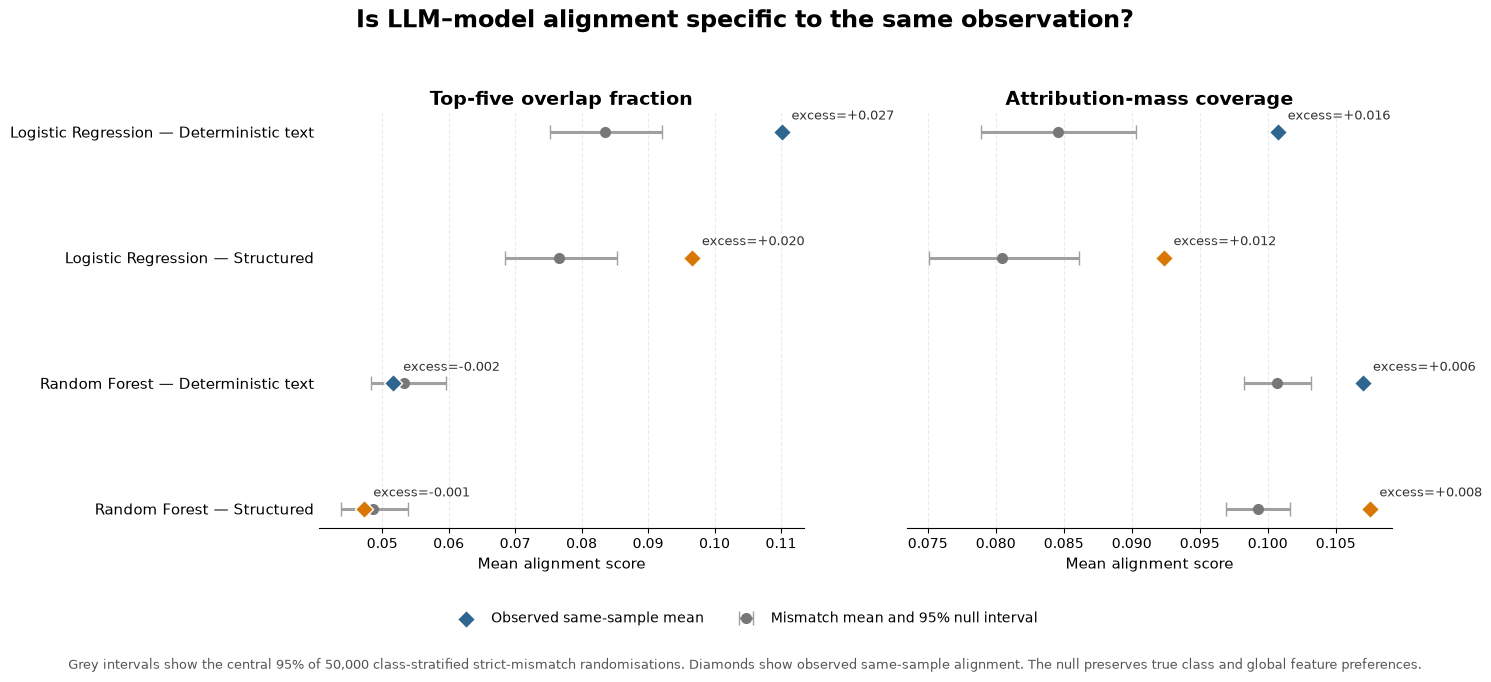

In [26]:
from pathlib import Path
import hashlib
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# -----------------------------------------------------------------------------
# 1. Lock and validate the class-stratified mismatch design.
# -----------------------------------------------------------------------------
RANDOM_SEED = 742
PERMUTATION_COUNT = 50_000
BATCH_SIZE = 1_000
ALPHA = 0.05
N_SAMPLES = 178
N_FEATURES = 46
TOP_K = 5

CONDITIONS = [
    "deterministic_text",
    "structured",
]

REFERENCE_MODELS = [
    "logistic_regression",
    "random_forest",
]

required_objects = [
    "PROJECT_ROOT",
    "paired_citation_base",
    "paired_alignment_summary",
    "standardised_reference_tables",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

assert not missing_objects, (
    f"Required objects are missing: {missing_objects}. "
    "Run the preceding alignment cells first."
)

assert set(REFERENCE_MODELS) == set(standardised_reference_tables)

assert set(CONDITIONS) == set(
    paired_citation_base["condition"].unique()
)


def stratified_permutations(
    strata,
    n_samples,
    n_replicates,
    rng,
):
    """
    Generate strict within-class derangements.

    Every response is matched to a different model-attribution sample from the
    same true class. No observation can be matched back to itself.
    """
    mappings = np.broadcast_to(
        np.arange(n_samples),
        (n_replicates, n_samples),
    ).copy()

    for indices in strata:
        pending = np.arange(n_replicates)
        local_identity = np.arange(len(indices))

        # Random permutations containing a fixed point are regenerated until
        # every mapping in this class stratum is a strict derangement.
        while len(pending):
            random_keys = rng.random(
                (len(pending), len(indices))
            )

            order = np.argsort(
                random_keys,
                axis=1,
                kind="stable",
            )

            valid = np.all(
                order != local_identity,
                axis=1,
            )

            accepted = pending[valid]

            mappings[
                accepted[:, None],
                indices[None, :],
            ] = indices[order[valid]]

            pending = pending[~valid]

    return mappings


def holm_adjust(p_values):
    """
    Calculate Holm family-wise-error-adjusted p-values.
    """
    values = np.asarray(
        p_values,
        dtype=float,
    )

    assert values.ndim == 1
    assert np.isfinite(values).all()
    assert ((values >= 0) & (values <= 1)).all()

    order = np.argsort(
        values,
        kind="mergesort",
    )

    ordered = values[order]

    adjusted_ordered = np.maximum.accumulate(
        (len(values) - np.arange(len(values))) * ordered
    )

    adjusted_ordered = np.minimum(
        adjusted_ordered,
        1.0,
    )

    adjusted = np.empty_like(values)
    adjusted[order] = adjusted_ordered

    return adjusted


def sha256_file(
    path,
    chunk_size=1_048_576,
):
    """
    Calculate a SHA-256 digest without loading the entire file into memory.
    """
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


# -----------------------------------------------------------------------------
# 2. Freeze the common sample order, true-class strata, and feature order.
# -----------------------------------------------------------------------------
sample_metadata = (
    paired_alignment_summary[
        [
            "sample_id",
            "true_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "sample_id",
        kind="mergesort",
    )
    .reset_index(drop=True)
)

assert len(sample_metadata) == N_SAMPLES
assert sample_metadata["sample_id"].is_unique
assert sample_metadata["true_label"].nunique() == 2

sample_ids = sample_metadata["sample_id"].tolist()
sample_labels = sample_metadata["true_label"].to_numpy()

strata = [
    np.flatnonzero(sample_labels == label)
    for label in sorted(
        sample_metadata["true_label"].unique()
    )
]

assert sum(map(len, strata)) == N_SAMPLES
assert all(len(indices) > 1 for indices in strata)


# Verify separately that the null generator preserves true class and forbids
# accidental self-matches.
probe_mappings = stratified_permutations(
    strata=strata,
    n_samples=N_SAMPLES,
    n_replicates=20,
    rng=np.random.default_rng(RANDOM_SEED + 1),
)

assert np.all(
    probe_mappings
    != np.arange(N_SAMPLES)[None, :]
)

assert np.all(
    sample_labels[probe_mappings]
    == sample_labels[None, :]
)


feature_sets = {
    model: set(table["feature_name"].unique())
    for model, table
    in standardised_reference_tables.items()
}

assert all(
    len(values) == N_FEATURES
    for values in feature_sets.values()
)

assert len(
    {
        frozenset(values)
        for values in feature_sets.values()
    }
) == 1

feature_names = sorted(
    next(iter(feature_sets.values()))
)


# -----------------------------------------------------------------------------
# 3. Build binary LLM-citation matrices.
#
# Each row corresponds to one paired sample and each column corresponds to one
# of the locked 46 original features. A value of one means the LLM cited the
# feature in its five-feature explanation.
# -----------------------------------------------------------------------------
citation_matrices = {}

for condition in CONDITIONS:
    citations = paired_citation_base.loc[
        paired_citation_base["condition"].eq(condition),
        [
            "sample_id",
            "feature_name",
        ],
    ]

    citation_frame = pd.crosstab(
        citations["sample_id"],
        citations["feature_name"],
    ).reindex(
        index=sample_ids,
        columns=feature_names,
        fill_value=0,
    )

    citation_matrix = citation_frame.to_numpy(
        dtype=float
    )

    assert citation_matrix.shape == (
        N_SAMPLES,
        N_FEATURES,
    )

    assert np.isin(
        citation_matrix,
        [0.0, 1.0],
    ).all()

    assert np.all(
        citation_matrix.sum(axis=1) == TOP_K
    )

    citation_matrices[condition] = citation_matrix


# -----------------------------------------------------------------------------
# 4. Build model top-five and row-normalised attribution-mass matrices.
# -----------------------------------------------------------------------------
top_five_matrices = {}
mass_matrices = {}

for model in REFERENCE_MODELS:
    reference_table = (
        standardised_reference_tables[model]
        .loc[
            lambda frame:
            frame["sample_id"].isin(sample_ids)
        ]
        .copy()
    )

    rank_frame = reference_table.pivot(
        index="sample_id",
        columns="feature_name",
        values="reference_absolute_rank",
    ).reindex(
        index=sample_ids,
        columns=feature_names,
    )

    attribution_frame = reference_table.pivot(
        index="sample_id",
        columns="feature_name",
        values="reference_absolute_attribution",
    ).reindex(
        index=sample_ids,
        columns=feature_names,
    )

    assert rank_frame.notna().all().all()
    assert attribution_frame.notna().all().all()

    top_matrix = rank_frame.le(
        TOP_K
    ).to_numpy(dtype=float)

    absolute_matrix = attribution_frame.to_numpy(
        dtype=float
    )

    row_totals = absolute_matrix.sum(
        axis=1,
        keepdims=True,
    )

    assert np.all(
        top_matrix.sum(axis=1) == TOP_K
    )

    assert np.isfinite(absolute_matrix).all()
    assert (absolute_matrix >= 0).all()
    assert (row_totals > 0).all()

    top_five_matrices[model] = top_matrix
    mass_matrices[model] = (
        absolute_matrix / row_totals
    )


# -----------------------------------------------------------------------------
# 5. Generate class-stratified strict-mismatch null distributions.
#
# A pair-score matrix stores the alignment between every LLM response i and
# every reference-model explanation j. Its diagonal contains the observed
# same-sample scores. The null repeatedly selects an off-diagonal, same-class,
# one-to-one reassignment.
# -----------------------------------------------------------------------------
seed_sequence = np.random.SeedSequence(
    RANDOM_SEED
)

analysis_seeds = seed_sequence.spawn(
    len(REFERENCE_MODELS) * len(CONDITIONS)
)

null_distributions = {}
result_rows = []
analysis_index = 0

row_indices = np.arange(
    N_SAMPLES
)[None, :]


for model in REFERENCE_MODELS:
    for condition in CONDITIONS:
        citation_matrix = citation_matrices[
            condition
        ]

        # Element [i, j] evaluates LLM response i against model explanation j.
        overlap_pair_scores = (
            citation_matrix
            @ top_five_matrices[model].T
        ) / TOP_K

        mass_pair_scores = (
            citation_matrix
            @ mass_matrices[model].T
        )

        score_matrices = {
            "top_five_overlap_fraction":
                overlap_pair_scores,
            "attribution_mass_coverage":
                mass_pair_scores,
        }

        observed_scores = {
            metric: float(
                np.diag(matrix).mean()
            )
            for metric, matrix
            in score_matrices.items()
        }

        # Reproduce the previously validated paired-alignment means before
        # constructing any new null distribution.
        prior_results = paired_alignment_summary.loc[
            paired_alignment_summary[
                "reference_model"
            ].eq(model)
            & paired_alignment_summary[
                "condition"
            ].eq(condition)
        ]

        for metric, observed_value in observed_scores.items():
            assert np.isclose(
                observed_value,
                prior_results[metric].mean(),
                atol=1e-12,
                rtol=0,
            )

        simulated = {
            metric: np.empty(
                PERMUTATION_COUNT,
                dtype=float,
            )
            for metric in score_matrices
        }

        rng = np.random.default_rng(
            analysis_seeds[analysis_index]
        )

        completed = 0

        while completed < PERMUTATION_COUNT:
            current_batch = min(
                BATCH_SIZE,
                PERMUTATION_COUNT - completed,
            )

            mappings = stratified_permutations(
                strata=strata,
                n_samples=N_SAMPLES,
                n_replicates=current_batch,
                rng=rng,
            )

            batch_slice = slice(
                completed,
                completed + current_batch,
            )

            for metric, matrix in score_matrices.items():
                simulated[metric][batch_slice] = (
                    matrix[
                        row_indices,
                        mappings,
                    ].mean(axis=1)
                )

            completed += current_batch

        for metric, null_values in simulated.items():
            matrix = score_matrices[metric]

            # Calculate the exact expected mismatch mean over every allowable
            # off-diagonal within-class pairing. Monte Carlo is required only
            # for the null distribution and p-value.
            exact_null_mean = 0.0

            for indices in strata:
                within_class_block = matrix[
                    np.ix_(indices, indices)
                ]

                exact_null_mean += (
                    within_class_block.sum()
                    - np.trace(within_class_block)
                ) / (
                    len(indices) - 1
                )

            exact_null_mean /= N_SAMPLES

            null_lower, null_upper = np.quantile(
                null_values,
                [0.025, 0.975],
            )

            observed_value = observed_scores[metric]

            # Directional supporting hypothesis:
            # same-sample alignment exceeds strict within-class mismatch.
            raw_p_value = (
                1
                + int(
                    (
                        null_values
                        >= observed_value - 1e-15
                    ).sum()
                )
            ) / (
                PERMUTATION_COUNT + 1
            )

            null_distributions[
                (
                    model,
                    condition,
                    metric,
                )
            ] = null_values

            result_rows.append(
                {
                    "reference_model":
                        model,
                    "condition":
                        condition,
                    "metric":
                        metric,
                    "sample_count":
                        N_SAMPLES,
                    "observed_same_sample_mean":
                        observed_value,
                    "exact_class_stratified_mismatch_mean":
                        float(exact_null_mean),
                    "observed_minus_mismatch_mean":
                        float(
                            observed_value
                            - exact_null_mean
                        ),
                    "mismatch_null_2_5_percentile":
                        float(null_lower),
                    "mismatch_null_97_5_percentile":
                        float(null_upper),
                    "mismatch_null_standard_deviation":
                        float(
                            null_values.std(ddof=1)
                        ),
                    "one_sided_raw_p_value":
                        float(raw_p_value),
                }
            )

        analysis_index += 1


class_stratified_mismatch_results = pd.DataFrame(
    result_rows
)

class_stratified_mismatch_results[
    "holm_adjusted_p_value"
] = holm_adjust(
    class_stratified_mismatch_results[
        "one_sided_raw_p_value"
    ]
)

class_stratified_mismatch_results[
    "above_mismatch_after_holm"
] = (
    class_stratified_mismatch_results[
        "holm_adjusted_p_value"
    ].le(ALPHA)
    & class_stratified_mismatch_results[
        "observed_minus_mismatch_mean"
    ].gt(0)
)


# -----------------------------------------------------------------------------
# 6. Validate and display the supporting results.
# -----------------------------------------------------------------------------
mismatch_checks = pd.DataFrame(
    [
        {
            "check":
                "Supporting result rows",
            "observed":
                len(class_stratified_mismatch_results),
            "expected":
                8,
            "passed":
                len(class_stratified_mismatch_results) == 8,
        },
        {
            "check":
                "Every result uses 178 samples",
            "observed":
                int(
                    class_stratified_mismatch_results[
                        "sample_count"
                    ].eq(178).sum()
                ),
            "expected":
                8,
            "passed":
                class_stratified_mismatch_results[
                    "sample_count"
                ].eq(178).all(),
        },
        {
            "check":
                "All mismatch intervals are ordered",
            "observed":
                int(
                    (
                        class_stratified_mismatch_results[
                            "mismatch_null_2_5_percentile"
                        ]
                        <=
                        class_stratified_mismatch_results[
                            "mismatch_null_97_5_percentile"
                        ]
                    ).sum()
                ),
            "expected":
                8,
            "passed":
                (
                    class_stratified_mismatch_results[
                        "mismatch_null_2_5_percentile"
                    ]
                    <=
                    class_stratified_mismatch_results[
                        "mismatch_null_97_5_percentile"
                    ]
                ).all(),
        },
        {
            "check":
                "All p-values are within [0, 1]",
            "observed":
                int(
                    class_stratified_mismatch_results[
                        [
                            "one_sided_raw_p_value",
                            "holm_adjusted_p_value",
                        ]
                    ]
                    .apply(
                        lambda column:
                        column.between(0, 1)
                    )
                    .all(axis=1)
                    .sum()
                ),
            "expected":
                8,
            "passed":
                class_stratified_mismatch_results[
                    [
                        "one_sided_raw_p_value",
                        "holm_adjusted_p_value",
                    ]
                ]
                .apply(
                    lambda column:
                    column.between(0, 1)
                )
                .all()
                .all(),
        },
        {
            "check":
                "Eight null distributions contain 50,000 values",
            "observed":
                sum(
                    len(values)
                    == PERMUTATION_COUNT
                    for values
                    in null_distributions.values()
                ),
            "expected":
                8,
            "passed":
                (
                    len(null_distributions) == 8
                    and all(
                        len(values)
                        == PERMUTATION_COUNT
                        for values
                        in null_distributions.values()
                    )
                ),
        },
    ]
)

failed_mismatch_checks = mismatch_checks.loc[
    ~mismatch_checks["passed"]
].copy()


print(
    "Class-stratified mismatch integrity checks:"
)

display(
    mismatch_checks.style.map(
        lambda value: (
            "background-color: #d9ead3; "
            "color: #274e13; "
            "font-weight: bold;"
            if value is True
            else (
                "background-color: #f4cccc; "
                "color: #990000; "
                "font-weight: bold;"
                if value is False
                else ""
            )
        ),
        subset=["passed"],
    )
)


print(
    "\nFailed class-stratified mismatch checks:"
)

print(
    "None"
    if failed_mismatch_checks.empty
    else failed_mismatch_checks
)

assert failed_mismatch_checks.empty, (
    "The mismatch analysis failed an integrity check. "
    "Do not interpret or save the results."
)


print(
    "\nClass-stratified sample-mismatch results:"
)

with pd.option_context(
    "display.max_columns",
    None,
    "display.width",
    260,
    "display.float_format",
    "{:.6f}".format,
):
    display(
        class_stratified_mismatch_results
    )


# -----------------------------------------------------------------------------
# 7. Create a publication-quality observed-versus-null figure.
# -----------------------------------------------------------------------------
metric_labels = {
    "top_five_overlap_fraction":
        "Top-five overlap fraction",
    "attribution_mass_coverage":
        "Attribution-mass coverage",
}

model_labels = {
    "logistic_regression":
        "Logistic Regression",
    "random_forest":
        "Random Forest",
}

condition_labels = {
    "deterministic_text":
        "Deterministic text",
    "structured":
        "Structured",
}

condition_colours = {
    "deterministic_text":
        "#2F6690",
    "structured":
        "#D97706",
}

row_order = [
    (
        "logistic_regression",
        "deterministic_text",
    ),
    (
        "logistic_regression",
        "structured",
    ),
    (
        "random_forest",
        "deterministic_text",
    ),
    (
        "random_forest",
        "structured",
    ),
]

y_positions = np.arange(
    len(row_order)
)[::-1]

y_labels = [
    (
        f"{model_labels[model]} — "
        f"{condition_labels[condition]}"
    )
    for model, condition in row_order
]


mismatch_figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6.8),
    sharey=True,
)


for axis, metric in zip(
    axes,
    metric_labels,
):
    result_subset = (
        class_stratified_mismatch_results.loc[
            class_stratified_mismatch_results[
                "metric"
            ].eq(metric)
        ]
        .set_index(
            [
                "reference_model",
                "condition",
            ]
        )
    )

    for y_position, (
        model,
        condition,
    ) in zip(
        y_positions,
        row_order,
    ):
        result_row = result_subset.loc[
            (
                model,
                condition,
            )
        ]

        null_mean = result_row[
            "exact_class_stratified_mismatch_mean"
        ]

        null_lower = result_row[
            "mismatch_null_2_5_percentile"
        ]

        null_upper = result_row[
            "mismatch_null_97_5_percentile"
        ]

        observed_value = result_row[
            "observed_same_sample_mean"
        ]

        axis.errorbar(
            null_mean,
            y_position,
            xerr=np.array(
                [
                    [null_mean - null_lower],
                    [null_upper - null_mean],
                ]
            ),
            fmt="o",
            markersize=7,
            color="#777777",
            ecolor="#A0A0A0",
            elinewidth=2.2,
            capsize=5,
            label=(
                "Mismatch mean and 95% null interval"
                if y_position == 3
                else None
            ),
            zorder=2,
        )

        axis.scatter(
            observed_value,
            y_position,
            marker="D",
            s=85,
            color=condition_colours[condition],
            edgecolor="white",
            linewidth=1.0,
            label=(
                "Observed same-sample mean"
                if y_position == 3
                else None
            ),
            zorder=3,
        )

        axis.annotate(
            (
                "excess="
                f"{result_row['observed_minus_mismatch_mean']:+.3f}"
            ),
            xy=(
                observed_value,
                y_position,
            ),
            xytext=(7, 9),
            textcoords="offset points",
            fontsize=9,
            color="#333333",
        )

    axis.set_title(
        metric_labels[metric],
        fontsize=14,
        fontweight="bold",
    )

    axis.set_xlabel(
        "Mean alignment score",
        fontsize=11,
    )

    axis.grid(
        axis="x",
        linestyle="--",
        alpha=0.25,
    )

    axis.grid(
        axis="y",
        visible=False,
    )

    for spine_name in [
        "top",
        "right",
        "left",
    ]:
        axis.spines[
            spine_name
        ].set_visible(False)

    axis.tick_params(
        axis="y",
        length=0,
    )


axes[0].set_yticks(
    y_positions
)

axes[0].set_yticklabels(
    y_labels,
    fontsize=10.5,
)

legend_handles, legend_labels = (
    axes[0].get_legend_handles_labels()
)

mismatch_figure.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.055),
    ncol=2,
    frameon=False,
)

mismatch_figure.suptitle(
    "Is LLM–model alignment specific to the same observation?",
    fontsize=17,
    fontweight="bold",
    y=0.98,
)

mismatch_figure.text(
    0.5,
    0.01,
    (
        "Grey intervals show the central 95% of 50,000 "
        "class-stratified strict-mismatch randomisations. "
        "Diamonds show observed same-sample alignment. "
        "The null preserves true class and global feature preferences."
    ),
    ha="center",
    fontsize=9.5,
    color="#555555",
)

plt.tight_layout(
    rect=[0, 0.13, 1, 0.94]
)


# -----------------------------------------------------------------------------
# 8. Save the table, 300-dpi PNG, vector PDF, and manifest immediately.
#
# The figure is saved before plt.show(), avoiding backend-dependent loss of the
# figure object.
# -----------------------------------------------------------------------------
project_root = Path(
    PROJECT_ROOT
).expanduser().resolve()

output_directory = (
    project_root
    / "results"
    / "explanation_alignment"
    / "primary_46"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)


artifact_paths = {
    "results_csv":
        output_directory
        / "class_stratified_mismatch_alignment_results.csv",
    "figure_png":
        output_directory
        / "class_stratified_mismatch_alignment.png",
    "figure_pdf":
        output_directory
        / "class_stratified_mismatch_alignment.pdf",
    "manifest_json":
        output_directory
        / "class_stratified_mismatch_alignment_manifest.json",
}


# Write the tabular result atomically.
temporary_csv = artifact_paths[
    "results_csv"
].with_name(
    artifact_paths["results_csv"].name
    + ".tmp"
)

class_stratified_mismatch_results.to_csv(
    temporary_csv,
    index=False,
    encoding="utf-8",
    float_format="%.12g",
    lineterminator="\n",
)

os.replace(
    temporary_csv,
    artifact_paths["results_csv"],
)


# Save both a high-resolution raster figure and a vector figure.
for artifact_key, file_format, dpi in [
    (
        "figure_png",
        "png",
        300,
    ),
    (
        "figure_pdf",
        "pdf",
        None,
    ),
]:
    destination = artifact_paths[
        artifact_key
    ]

    temporary_figure = destination.with_name(
        destination.name + ".tmp"
    )

    save_arguments = {
        "format":
            file_format,
        "bbox_inches":
            "tight",
        "facecolor":
            "white",
    }

    if dpi is not None:
        save_arguments["dpi"] = dpi

    mismatch_figure.savefig(
        temporary_figure,
        **save_arguments,
    )

    os.replace(
        temporary_figure,
        destination,
    )


# Read the CSV back from disk before declaring the export successful.
readback_results = pd.read_csv(
    artifact_paths["results_csv"]
)

assert len(readback_results) == 8

assert readback_results[
    "sample_count"
].eq(178).all()


# Construct a reproducibility manifest containing file sizes and hashes.
manifest_artifact_keys = [
    "results_csv",
    "figure_png",
    "figure_pdf",
]

mismatch_manifest = {
    "analysis":
        "class_stratified_sample_mismatch_alignment_baseline",
    "feature_policy":
        "primary_46",
    "paired_sample_count":
        N_SAMPLES,
    "permutation_count":
        PERMUTATION_COUNT,
    "random_seed":
        RANDOM_SEED,
    "directional_alternative":
        (
            "same-sample alignment exceeds "
            "strict within-class mismatch"
        ),
    "self_matches_allowed_in_null":
        False,
    "multiplicity_method":
        "Holm correction across eight supporting tests",
    "artifacts":
        [
            {
                "artifact_key":
                    artifact_key,
                "relative_path":
                    str(
                        artifact_paths[
                            artifact_key
                        ].relative_to(
                            project_root
                        )
                    ),
                "byte_size":
                    int(
                        artifact_paths[
                            artifact_key
                        ].stat().st_size
                    ),
                "sha256":
                    sha256_file(
                        artifact_paths[
                            artifact_key
                        ]
                    ),
            }
            for artifact_key
            in manifest_artifact_keys
        ],
    "models_refitted":
        False,
    "network_request_made":
        False,
}


manifest_path = artifact_paths[
    "manifest_json"
]

temporary_manifest = manifest_path.with_name(
    manifest_path.name + ".tmp"
)

with temporary_manifest.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        mismatch_manifest,
        handle,
        indent=2,
        ensure_ascii=False,
        sort_keys=True,
    )

    handle.write("\n")

os.replace(
    temporary_manifest,
    manifest_path,
)


# Verify that every expected artifact exists and is nonempty.
export_audit = pd.DataFrame(
    [
        {
            "artifact":
                artifact_key,
            "relative_path":
                str(
                    path.relative_to(
                        project_root
                    )
                ),
            "exists":
                path.exists(),
            "byte_size":
                int(path.stat().st_size)
                if path.exists()
                else 0,
            "nonempty":
                bool(
                    path.exists()
                    and path.stat().st_size > 0
                ),
        }
        for artifact_key, path
        in artifact_paths.items()
    ]
)

assert export_audit[
    "exists"
].all()

assert export_audit[
    "nonempty"
].all()


print(
    "\nClass-stratified mismatch artifact audit:"
)

with pd.option_context(
    "display.max_colwidth",
    None,
):
    display(
        export_audit.style.map(
            lambda value: (
                "background-color: #d9ead3; "
                "color: #274e13; "
                "font-weight: bold;"
                if value is True
                else ""
            ),
            subset=[
                "exists",
                "nonempty",
            ],
        )
    )


class_stratified_mismatch_summary = pd.Series(
    {
        "paired_sample_count":
            N_SAMPLES,
        "true_class_stratum_count":
            len(strata),
        "supporting_test_count":
            len(
                class_stratified_mismatch_results
            ),
        "permutation_count":
            PERMUTATION_COUNT,
        "significant_above_mismatch_count":
            int(
                class_stratified_mismatch_results[
                    "above_mismatch_after_holm"
                ].sum()
            ),
        "integrity_check_count":
            len(mismatch_checks),
        "passed_integrity_check_count":
            int(
                mismatch_checks[
                    "passed"
                ].sum()
            ),
        "saved_artifact_count":
            len(export_audit),
        "models_refitted_by_this_cell":
            False,
        "network_request_made":
            False,
        "notebook_10_phase":
            (
                "class_stratified_"
                "mismatch_baseline_completed"
            ),
    },
    name="value",
)


print(
    "\nClass-stratified mismatch analysis summary:"
)

display(
    class_stratified_mismatch_summary.to_frame()
)


print(
    "\nClass-stratified sample-mismatch analysis "
    "completed and all four artifacts were saved."
)

plt.show()

## Final synthesis, reference-attribution export, and artifact audit

This final section closes the primary 46-feature explanation-alignment analysis.
No additional hypothesis test is introduced.

The section performs four reproducibility tasks:

1. preserves all held-out Logistic Regression and Random Forest local
   attributions in a single long-form table;
2. reconstructs and saves the global attribution summaries and Top-15
   reference-model figure;
3. records the confirmatory representation comparison and the supporting
   class-stratified mismatch findings in a machine-readable final summary; and
4. verifies the complete set of Notebook 10 result tables, figures, manifests,
   file sizes, and SHA-256 digests.

Logistic Regression contributions are expressed on the DoS log-odds scale,
whereas Random Forest TreeSHAP contributions are expressed on the predicted
DoS-probability scale. Magnitudes should therefore be compared within each
reference model, not directly between models. Attribution magnitude describes
model reliance and does not support a causal interpretation.

Final reference-attribution integrity summary:


,reference_model,sample_count,original_feature_count,local_attribution_row_count,attribution_scale
0,logistic_regression,200,46,9200,DoS log-odds
1,random_forest,200,46,9200,DoS probability



Global held-out attribution summaries (top 15 per model):


,reference_model,attribution_scale,feature_name,sample_count,mean_absolute_attribution,median_absolute_attribution,mean_signed_attribution,top_five_frequency,global_mean_absolute_rank
0,logistic_regression,DoS log-odds,MIN_IP_PKT_LEN,200,1.076385,0.920492,0.021751,133,1
1,logistic_regression,DoS log-odds,MAX_TTL,200,0.890210,0.750672,0.000412,190,2
2,logistic_regression,DoS log-odds,MIN_TTL,200,0.890066,0.751375,0.000399,194,3
3,logistic_regression,DoS log-odds,SERVER_TCP_FLAGS,200,0.687943,0.883610,-0.005198,140,4
4,logistic_regression,DoS log-odds,DST_TO_SRC_AVG_THROUGHPUT,200,0.361351,0.263004,0.002394,53,5
5,logistic_regression,DoS log-odds,NUM_PKTS_256_TO_512_BYTES,200,0.340768,0.013038,-0.321059,5,6
6,logistic_regression,DoS log-odds,L7_PROTO,200,0.309312,0.197975,-0.005550,61,7
7,logistic_regression,DoS log-odds,DST_TO_SRC_IAT_AVG,200,0.302202,0.206670,0.018173,28,8
8,logistic_regression,DoS log-odds,TCP_WIN_MAX_IN,200,0.272148,0.160448,0.020414,51,9
9,logistic_regression,DoS log-odds,NUM_PKTS_UP_TO_128_BYTES,200,0.270346,0.071818,-0.117893,13,10



Notebook 10 final artifact audit:


,artifact,relative_path,exists,byte_size,nonempty
0,paired_llm_model_alignment_feature_long_csv,results/explanation_alignment/primary_46/paired_llm_model_alignment_feature_long.csv,True,634718,True
1,paired_llm_model_alignment_summary_csv,results/explanation_alignment/primary_46/paired_llm_model_alignment_summary.csv,True,262916,True
2,paired_alignment_confirmatory_inference_csv,results/explanation_alignment/primary_46/paired_alignment_confirmatory_inference.csv,True,1439,True
3,paired_alignment_effect_forest_png,results/explanation_alignment/primary_46/paired_alignment_effect_forest.png,True,306618,True
4,paired_alignment_effect_forest_pdf,results/explanation_alignment/primary_46/paired_alignment_effect_forest.pdf,True,34088,True
5,paired_alignment_inference_manifest_json,results/explanation_alignment/primary_46/paired_alignment_inference_manifest.json,True,2495,True
6,class_stratified_mismatch_alignment_results_csv,results/explanation_alignment/primary_46/class_stratified_mismatch_alignment_results.csv,True,1850,True
7,class_stratified_mismatch_alignment_png,results/explanation_alignment/primary_46/class_stratified_mismatch_alignment.png,True,264722,True
8,class_stratified_mismatch_alignment_pdf,results/explanation_alignment/primary_46/class_stratified_mismatch_alignment.pdf,True,33376,True
9,class_stratified_mismatch_alignment_manifest_json,results/explanation_alignment/primary_46/class_stratified_mismatch_alignment_manifest.json,True,1280,True



Notebook 10 completion summary:


,value
analysis_population,178 paired samples; 356 validated responses
locked_original_feature_count,46
reference_sample_counts,"{'logistic_regression': 200, 'random_forest': ..."
reference_attribution_row_count,18400
reference_model_count,2
representation_condition_count,2
primary_confirmatory_hypothesis_count,4
primary_holm_rejection_count,0
supporting_mismatch_test_count,8
supporting_significant_count,6



Notebook 10 is complete: reference attributions, primary inference, supporting mismatch analysis, figures, summaries, hashes, and the final artifact inventory have all been saved and verified.


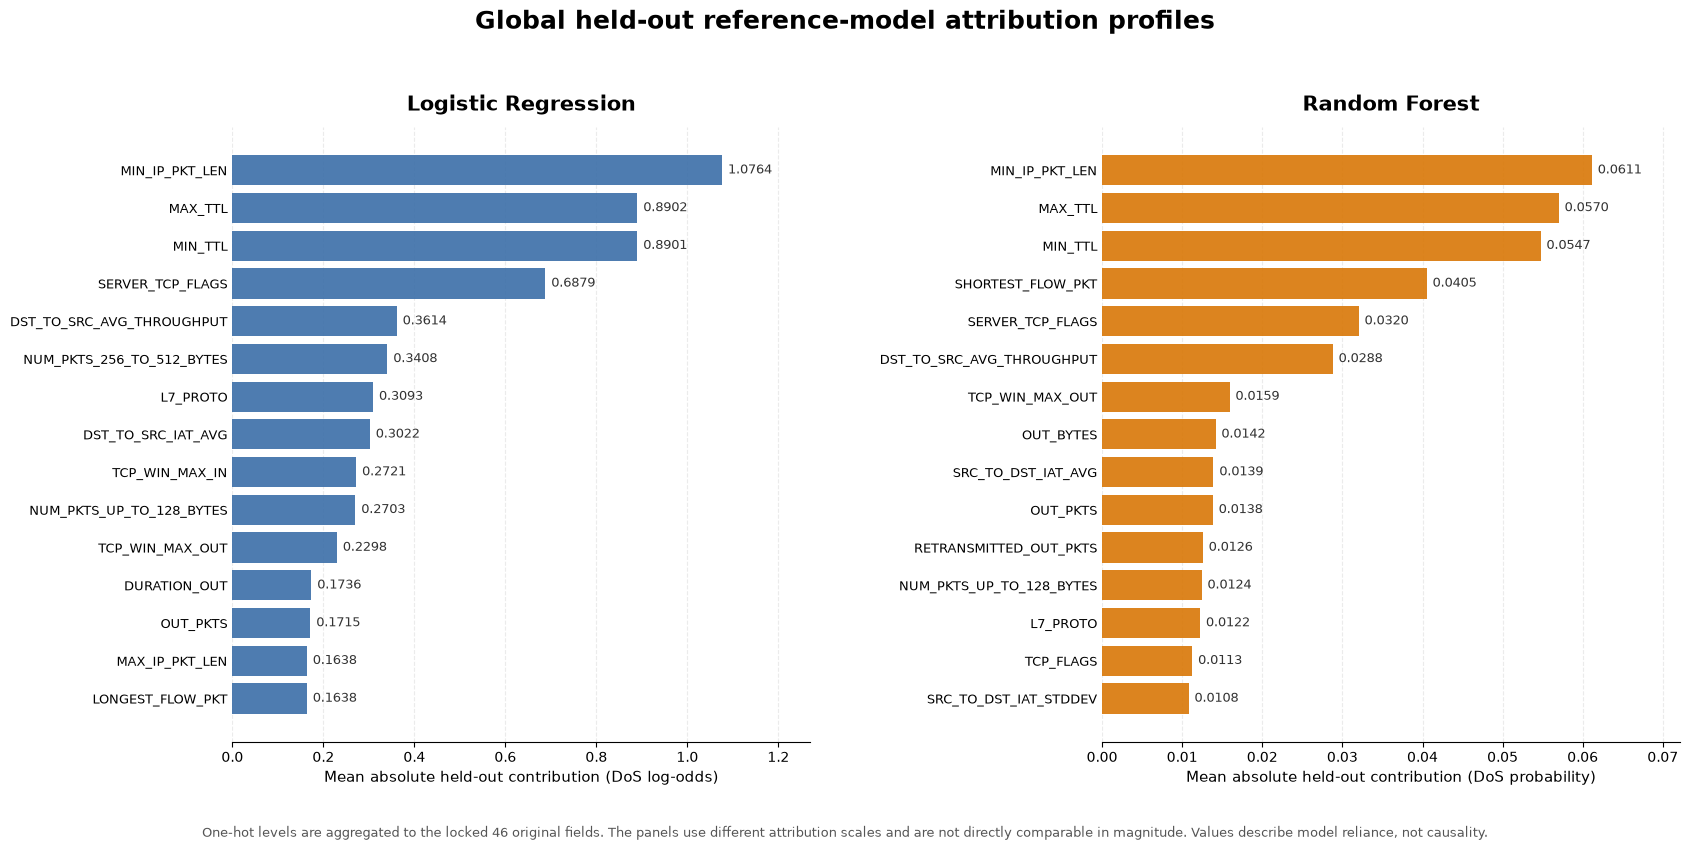

In [31]:
from pathlib import Path
import hashlib
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# -----------------------------------------------------------------------------
# 1. Validate the final Notebook 10 in-memory contract.
# -----------------------------------------------------------------------------
REQUIRED_OBJECTS = [
    "PROJECT_ROOT",
    "standardised_reference_tables",
    "paired_alignment_inference",
    "class_stratified_mismatch_results",
]

missing_objects = [
    name for name in REQUIRED_OBJECTS
    if name not in globals()
]

assert not missing_objects, (
    f"Required objects are missing: {missing_objects}. "
    "Run the preceding Notebook 10 cells first."
)

REFERENCE_MODELS = ["logistic_regression", "random_forest"]

MODEL_LABELS = {
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
}

ATTRIBUTION_SCALES = {
    "logistic_regression": "DoS log-odds",
    "random_forest": "DoS probability",
}

MODEL_COLOURS = {
    "logistic_regression": "#3B6EA8",
    "random_forest": "#D97706",
}

N_PAIRED_SAMPLES = 178
N_FEATURES = 46
TOP_K = 15

assert set(standardised_reference_tables) == set(REFERENCE_MODELS)
assert len(paired_alignment_inference) == 4
assert len(class_stratified_mismatch_results) == 8


def sha256_file(path, chunk_size=1_048_576):
    """Calculate a SHA-256 digest without loading the whole file at once."""
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


def atomic_write_csv(frame, destination):
    """Write a CSV through a temporary file and atomically replace the target."""
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".tmp")

    frame.to_csv(
        temporary,
        index=False,
        encoding="utf-8",
        float_format="%.12g",
        lineterminator="\n",
    )

    os.replace(temporary, destination)

    return destination


def atomic_save_figure(figure, destination, file_format, dpi=None):
    """Save a figure atomically in a specified raster or vector format."""
    destination = Path(destination)
    temporary = destination.with_name(destination.name + ".tmp")

    arguments = {
        "format": file_format,
        "bbox_inches": "tight",
        "facecolor": "white",
    }

    if dpi is not None:
        arguments["dpi"] = dpi

    figure.savefig(temporary, **arguments)
    os.replace(temporary, destination)

    return destination


# -----------------------------------------------------------------------------
# 2. Preserve all held-out local reference attributions in one long table.
#
# The number of samples is detected separately for each model. Therefore this
# cell supports either:
#
#     200 samples × 46 features × 2 models = 18,400 rows
#
# or:
#
#     178 samples × 46 features × 2 models = 16,376 rows
#
# without assuming either number in advance.
# -----------------------------------------------------------------------------
required_reference_columns = {
    "sample_id",
    "feature_name",
    "reference_absolute_attribution",
    "reference_signed_attribution",
    "reference_absolute_rank",
}

reference_frames = []
reference_sample_counts = {}

for model in REFERENCE_MODELS:
    table = standardised_reference_tables[model].copy()

    missing_columns = required_reference_columns.difference(table.columns)

    assert not missing_columns, (
        f"{model} reference table is missing columns: "
        f"{sorted(missing_columns)}"
    )

    reference_sample_count = int(table["sample_id"].nunique())

    assert reference_sample_count >= N_PAIRED_SAMPLES, (
        f"{model} contains only {reference_sample_count} reference samples; "
        f"at least {N_PAIRED_SAMPLES} are required."
    )

    assert table["feature_name"].nunique() == N_FEATURES, (
        f"{model} does not contain exactly {N_FEATURES} original features."
    )

    assert len(table) == reference_sample_count * N_FEATURES, (
        f"{model} has {len(table)} rows, but "
        f"{reference_sample_count * N_FEATURES} rows were expected from "
        f"{reference_sample_count} samples × {N_FEATURES} features."
    )

    reference_sample_counts[model] = reference_sample_count

    # Assignment is deliberately used instead of DataFrame.insert().
    # These columns may already exist if this cell or a previous standardisation
    # step has been run before. Assignment makes the cell safely repeatable.
    table["reference_model"] = model
    table["attribution_scale"] = ATTRIBUTION_SCALES[model]

    leading_columns = [
        "reference_model",
        "attribution_scale",
    ]

    remaining_columns = [
        column
        for column in table.columns
        if column not in leading_columns
    ]

    table = table[leading_columns + remaining_columns]

    reference_frames.append(table)


held_out_reference_attributions_long = (
    pd.concat(
        reference_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "reference_model",
            "sample_id",
            "reference_absolute_rank",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


expected_reference_row_count = sum(
    sample_count * N_FEATURES
    for sample_count in reference_sample_counts.values()
)


assert len(held_out_reference_attributions_long) == expected_reference_row_count, (
    "The combined reference-attribution table has an unexpected row count. "
    f"Observed={len(held_out_reference_attributions_long):,}; "
    f"expected={expected_reference_row_count:,}; "
    f"sample counts={reference_sample_counts}."
)


assert not held_out_reference_attributions_long.duplicated(
    [
        "reference_model",
        "sample_id",
        "feature_name",
    ]
).any(), (
    "Duplicate model–sample–feature rows were found in the combined "
    "reference-attribution table."
)


# -----------------------------------------------------------------------------
# 3. Reconstruct the global 46-feature summaries for both reference models.
# -----------------------------------------------------------------------------
reference_model_global_attribution_summary = (
    held_out_reference_attributions_long
    .groupby(
        [
            "reference_model",
            "attribution_scale",
            "feature_name",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        sample_count=(
            "sample_id",
            "nunique",
        ),
        mean_absolute_attribution=(
            "reference_absolute_attribution",
            "mean",
        ),
        median_absolute_attribution=(
            "reference_absolute_attribution",
            "median",
        ),
        mean_signed_attribution=(
            "reference_signed_attribution",
            "mean",
        ),
        top_five_frequency=(
            "reference_absolute_rank",
            lambda values: int(np.sum(np.asarray(values) <= 5)),
        ),
    )
)


reference_model_global_attribution_summary[
    "global_mean_absolute_rank"
] = (
    reference_model_global_attribution_summary
    .groupby("reference_model")["mean_absolute_attribution"]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)


reference_model_global_attribution_summary = (
    reference_model_global_attribution_summary
    .sort_values(
        [
            "reference_model",
            "global_mean_absolute_rank",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# Two models × 46 original features = 92 global rows.
assert len(reference_model_global_attribution_summary) == 92


observed_reference_sample_counts = (
    reference_model_global_attribution_summary
    .groupby("reference_model")["sample_count"]
    .first()
    .astype(int)
    .to_dict()
)


assert observed_reference_sample_counts == reference_sample_counts, (
    "The sample counts in the global summaries do not match the underlying "
    f"reference tables. Observed={observed_reference_sample_counts}; "
    f"expected={reference_sample_counts}."
)


assert (
    reference_model_global_attribution_summary
    .groupby("reference_model")["global_mean_absolute_rank"]
    .apply(
        lambda values: set(values) == set(range(1, 47))
    )
    .all()
), "Each model must contain one global rank for every feature from 1 to 46."


print("Final reference-attribution integrity summary:")

display(
    pd.DataFrame(
        [
            {
                "reference_model": model,
                "sample_count": int(
                    held_out_reference_attributions_long.loc[
                        held_out_reference_attributions_long[
                            "reference_model"
                        ].eq(model),
                        "sample_id",
                    ].nunique()
                ),
                "original_feature_count": int(
                    held_out_reference_attributions_long.loc[
                        held_out_reference_attributions_long[
                            "reference_model"
                        ].eq(model),
                        "feature_name",
                    ].nunique()
                ),
                "local_attribution_row_count": int(
                    held_out_reference_attributions_long[
                        "reference_model"
                    ].eq(model).sum()
                ),
                "attribution_scale": ATTRIBUTION_SCALES[model],
            }
            for model in REFERENCE_MODELS
        ]
    )
)


print("\nGlobal held-out attribution summaries (top 15 per model):")

display(
    reference_model_global_attribution_summary.loc[
        reference_model_global_attribution_summary[
            "global_mean_absolute_rank"
        ].le(TOP_K)
    ]
)


# -----------------------------------------------------------------------------
# 4. Create a publication-quality two-panel reference-attribution figure.
#
# Logistic Regression uses the DoS log-odds attribution scale.
# Random Forest uses the DoS probability attribution scale.
#
# Therefore, bar lengths should be interpreted within each panel. The absolute
# magnitudes should not be compared directly between the two model types.
# -----------------------------------------------------------------------------
reference_attribution_figure, axes = plt.subplots(
    1,
    2,
    figsize=(17, 8.5),
)


for axis, model in zip(axes, REFERENCE_MODELS):
    plot_data = (
        reference_model_global_attribution_summary.loc[
            reference_model_global_attribution_summary[
                "reference_model"
            ].eq(model)
            &
            reference_model_global_attribution_summary[
                "global_mean_absolute_rank"
            ].le(TOP_K)
        ]
        .sort_values(
            "mean_absolute_attribution",
            ascending=True,
        )
    )

    bars = axis.barh(
        plot_data["feature_name"],
        plot_data["mean_absolute_attribution"],
        color=MODEL_COLOURS[model],
        alpha=0.90,
    )

    maximum_value = float(
        plot_data["mean_absolute_attribution"].max()
    )

    axis.set_xlim(
        0,
        maximum_value * 1.18,
    )

    for bar, value in zip(
        bars,
        plot_data["mean_absolute_attribution"],
    ):
        axis.text(
            bar.get_width() + maximum_value * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            fontsize=9,
            color="#333333",
        )

    axis.set_title(
        MODEL_LABELS[model],
        fontsize=15,
        fontweight="bold",
        pad=12,
    )

    axis.set_xlabel(
        (
            "Mean absolute held-out contribution "
            f"({ATTRIBUTION_SCALES[model]})"
        ),
        fontsize=10.5,
    )

    axis.grid(
        axis="x",
        linestyle="--",
        alpha=0.25,
    )

    axis.set_axisbelow(True)

    axis.tick_params(
        axis="y",
        labelsize=9.5,
        length=0,
    )

    for spine_name in [
        "top",
        "right",
        "left",
    ]:
        axis.spines[spine_name].set_visible(False)


reference_attribution_figure.suptitle(
    "Global held-out reference-model attribution profiles",
    fontsize=18,
    fontweight="bold",
    y=0.985,
)


reference_attribution_figure.text(
    0.5,
    0.012,
    (
        "One-hot levels are aggregated to the locked 46 original fields. "
        "The panels use different attribution scales and are not directly "
        "comparable in magnitude. Values describe model reliance, not causality."
    ),
    ha="center",
    fontsize=9.5,
    color="#555555",
)


plt.tight_layout(
    rect=[0, 0.055, 1, 0.95],
    w_pad=5.0,
)


# -----------------------------------------------------------------------------
# 5. Save the recovered reference-attribution artifacts.
# -----------------------------------------------------------------------------
project_root = Path(PROJECT_ROOT).expanduser().resolve()

output_directory = (
    project_root
    / "results"
    / "explanation_alignment"
    / "primary_46"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)


new_artifact_paths = {
    "reference_attributions_long_csv": (
        output_directory
        / "held_out_reference_attributions_long.csv"
    ),
    "reference_global_summary_csv": (
        output_directory
        / "reference_model_global_attribution_summary.csv"
    ),
    "reference_global_figure_png": (
        output_directory
        / "reference_model_global_attribution_top15.png"
    ),
    "reference_global_figure_pdf": (
        output_directory
        / "reference_model_global_attribution_top15.pdf"
    ),
}


atomic_write_csv(
    held_out_reference_attributions_long,
    new_artifact_paths["reference_attributions_long_csv"],
)


atomic_write_csv(
    reference_model_global_attribution_summary,
    new_artifact_paths["reference_global_summary_csv"],
)


atomic_save_figure(
    reference_attribution_figure,
    new_artifact_paths["reference_global_figure_png"],
    file_format="png",
    dpi=300,
)


atomic_save_figure(
    reference_attribution_figure,
    new_artifact_paths["reference_global_figure_pdf"],
    file_format="pdf",
)


# Read both CSV files back from disk before declaring success.
assert len(
    pd.read_csv(
        new_artifact_paths["reference_attributions_long_csv"]
    )
) == expected_reference_row_count


assert len(
    pd.read_csv(
        new_artifact_paths["reference_global_summary_csv"]
    )
) == 92


# -----------------------------------------------------------------------------
# 6. Verify the primary and supporting artifacts saved by preceding cells.
# -----------------------------------------------------------------------------
previous_artifact_names = [
    "paired_llm_model_alignment_feature_long.csv",
    "paired_llm_model_alignment_summary.csv",
    "paired_alignment_confirmatory_inference.csv",
    "paired_alignment_effect_forest.png",
    "paired_alignment_effect_forest.pdf",
    "paired_alignment_inference_manifest.json",
    "class_stratified_mismatch_alignment_results.csv",
    "class_stratified_mismatch_alignment.png",
    "class_stratified_mismatch_alignment.pdf",
    "class_stratified_mismatch_alignment_manifest.json",
]


previous_artifact_paths = {
    name.replace(".", "_"): output_directory / name
    for name in previous_artifact_names
}


missing_previous_artifacts = [
    str(path.relative_to(project_root))
    for path in previous_artifact_paths.values()
    if not path.exists() or path.stat().st_size == 0
]


assert not missing_previous_artifacts, (
    "Previously expected artifacts are missing or empty: "
    f"{missing_previous_artifacts}"
)


# -----------------------------------------------------------------------------
# 7. Construct and save a machine-readable final Notebook 10 summary.
# -----------------------------------------------------------------------------
primary_rejection_column = "reject_holm_0_05"

assert primary_rejection_column in paired_alignment_inference.columns


supporting_rejection_column = "above_mismatch_after_holm"

assert (
    supporting_rejection_column
    in class_stratified_mismatch_results.columns
)


notebook_10_final_summary = {
    "notebook": "10_explanation_alignment.ipynb",
    "analysis_status": "completed",
    "feature_policy": "primary_46",
    "paired_sample_count": N_PAIRED_SAMPLES,
    "validated_llm_response_count": 356,
    "reference_models": REFERENCE_MODELS,
    "reference_sample_counts": reference_sample_counts,
    "reference_attribution_row_count": expected_reference_row_count,
    "representation_conditions": [
        "deterministic_text",
        "structured",
    ],
    "primary_alignment_metrics": [
        "top_five_overlap_fraction",
        "attribution_mass_coverage",
    ],
    "primary_confirmatory_hypothesis_count": int(
        len(paired_alignment_inference)
    ),
    "primary_holm_rejection_count": int(
        paired_alignment_inference[
            primary_rejection_column
        ].sum()
    ),
    "supporting_mismatch_test_count": int(
        len(class_stratified_mismatch_results)
    ),
    "supporting_above_mismatch_after_holm_count": int(
        class_stratified_mismatch_results[
            supporting_rejection_column
        ].sum()
    ),
    "primary_result": (
        "No Holm-corrected evidence that structured input changes LLM-model "
        "attribution alignment relative to deterministic text."
    ),
    "supporting_result": (
        "Six of eight class-stratified strict-mismatch tests show greater "
        "same-sample alignment. Both Logistic Regression metrics and both "
        "Random Forest attribution-mass tests pass; the two Random Forest "
        "top-five-overlap tests do not."
    ),
    "interpretive_boundary": (
        "Attribution magnitude describes model reliance rather than causal "
        "importance. A non-significant representation effect is not evidence "
        "of equivalence."
    ),
    "models_refitted_during_explanation_analysis": False,
    "network_request_made_during_explanation_analysis": False,
    "primary_confirmatory_results": json.loads(
        paired_alignment_inference.to_json(
            orient="records"
        )
    ),
    "supporting_mismatch_results": json.loads(
        class_stratified_mismatch_results.to_json(
            orient="records"
        )
    ),
}


summary_json_path = (
    output_directory
    / "notebook_10_final_summary.json"
)


temporary_summary_path = summary_json_path.with_name(
    summary_json_path.name + ".tmp"
)


with temporary_summary_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        notebook_10_final_summary,
        handle,
        indent=2,
        ensure_ascii=False,
        sort_keys=True,
    )

    handle.write("\n")


os.replace(
    temporary_summary_path,
    summary_json_path,
)


# -----------------------------------------------------------------------------
# 8. Build, save, and verify the final artifact inventory.
#
# The stored inventory intentionally excludes itself. This avoids a circular
# checksum problem in which writing the inventory would change its own checksum.
# The displayed final audit adds the inventory as artifact number sixteen.
# -----------------------------------------------------------------------------
artifacts_before_inventory = {
    **previous_artifact_paths,
    **new_artifact_paths,
    "notebook_10_final_summary_json": summary_json_path,
}


notebook_10_artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": key,
            "relative_path": str(
                path.relative_to(project_root)
            ),
            "exists": path.exists(),
            "byte_size": (
                int(path.stat().st_size)
                if path.exists()
                else 0
            ),
            "nonempty": bool(
                path.exists()
                and path.stat().st_size > 0
            ),
            "sha256": (
                sha256_file(path)
                if path.exists()
                else None
            ),
        }
        for key, path in artifacts_before_inventory.items()
    ]
)


assert notebook_10_artifact_inventory["exists"].all()
assert notebook_10_artifact_inventory["nonempty"].all()
assert (
    notebook_10_artifact_inventory["sha256"]
    .str.len()
    .eq(64)
    .all()
)


inventory_csv_path = (
    output_directory
    / "notebook_10_artifact_inventory.csv"
)


atomic_write_csv(
    notebook_10_artifact_inventory,
    inventory_csv_path,
)


final_artifact_paths = {
    **artifacts_before_inventory,
    "notebook_10_artifact_inventory_csv": inventory_csv_path,
}


notebook_10_final_artifact_audit = pd.DataFrame(
    [
        {
            "artifact": key,
            "relative_path": str(
                path.relative_to(project_root)
            ),
            "exists": path.exists(),
            "byte_size": (
                int(path.stat().st_size)
                if path.exists()
                else 0
            ),
            "nonempty": bool(
                path.exists()
                and path.stat().st_size > 0
            ),
        }
        for key, path in final_artifact_paths.items()
    ]
)


assert len(notebook_10_final_artifact_audit) == 16, (
    "Unexpected final artifact count: "
    f"{len(notebook_10_final_artifact_audit)}; "
    f"keys={list(final_artifact_paths)}"
)


assert notebook_10_final_artifact_audit["exists"].all()
assert notebook_10_final_artifact_audit["nonempty"].all()


print("\nNotebook 10 final artifact audit:")


with pd.option_context(
    "display.max_colwidth",
    None,
):
    display(
        notebook_10_final_artifact_audit.style.map(
            lambda value: (
                (
                    "background-color: #d9ead3; "
                    "color: #274e13; "
                    "font-weight: bold;"
                )
                if value is True
                else (
                    (
                        "background-color: #f4cccc; "
                        "color: #990000; "
                        "font-weight: bold;"
                    )
                    if value is False
                    else ""
                )
            ),
            subset=[
                "exists",
                "nonempty",
            ],
        )
    )


notebook_10_completion_summary = pd.Series(
    {
        "analysis_population": (
            "178 paired samples; 356 validated responses"
        ),
        "locked_original_feature_count": 46,
        "reference_sample_counts": str(reference_sample_counts),
        "reference_attribution_row_count": (
            expected_reference_row_count
        ),
        "reference_model_count": 2,
        "representation_condition_count": 2,
        "primary_confirmatory_hypothesis_count": 4,
        "primary_holm_rejection_count": int(
            paired_alignment_inference[
                primary_rejection_column
            ].sum()
        ),
        "supporting_mismatch_test_count": 8,
        "supporting_significant_count": int(
            class_stratified_mismatch_results[
                supporting_rejection_column
            ].sum()
        ),
        "saved_and_verified_artifact_count": int(
            len(notebook_10_final_artifact_audit)
        ),
        "models_refitted_by_this_cell": False,
        "network_request_made": False,
        "notebook_10_phase": "completed_and_audited",
    },
    name="value",
)


print("\nNotebook 10 completion summary:")

display(
    notebook_10_completion_summary.to_frame()
)


print(
    "\nNotebook 10 is complete: reference attributions, primary inference, "
    "supporting mismatch analysis, figures, summaries, hashes, and the final "
    "artifact inventory have all been saved and verified."
)


plt.show()

In [32]:
from pathlib import Path
import subprocess

project_root = Path(PROJECT_ROOT).expanduser().resolve()

print("Project root:")
print(project_root)

print("\nGit status:")
result = subprocess.run(
    ["git", "-C", str(project_root), "status", "--short"],
    capture_output=True,
    text=True,
    check=False,
)

print(result.stdout if result.stdout else "Working tree is clean.")

if result.stderr:
    print("\nGit message:")
    print(result.stderr)

Project root:
/Users/ruiwang/Developer/compsci742-rui-pilot

Git status:


python(90609) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


?? notebooks/10_explanation_alignment.ipynb
?? results/explanation_alignment/



# Notebook 10 Summary: Explanation–Attribution Alignment

## 1. Purpose

This notebook evaluates the **attribution-agreement component of RQ3**:

> How closely do the features cited in the LLM explanations agree with the features that conventional reference models rely on for the same network-flow record?

This is a **supplementary explanation-alignment study** using Rui's locked 46-feature binary-detection pipeline. It complements the team's main experiments but does not replace them.

The analysis compares two LLM input representations:

1. **Deterministic text**
2. **Structured JSON**

against two conventional reference models:

1. **Logistic Regression (LR)**
2. **Random Forest (RF)**

The purpose is not to compare the predictive accuracy of LR and RF in this notebook. Instead, LR and RF provide two independent reference attribution profiles against which the LLM's cited features can be evaluated.

---

## 2. Analysis population

The original inference experiment contained:

- **200 network-flow records**
- **400 LLM requests**
- Two input representations per record
- **46 locked original features**

After response validation, the complete paired analysis contained:

- **178 network-flow records**
- **356 validated LLM responses**
- One deterministic-text response and one structured-JSON response for every included record
- **92 Benign records**
- **86 DoS records**

The 22 records without a complete valid response pair were excluded from the paired comparison rather than being imputed or replaced.

Reference-model attributions were retained for all 200 held-out records:

- 200 samples × 46 features = 9,200 LR attribution rows
- 200 samples × 46 features = 9,200 RF attribution rows
- **18,400 total reference-attribution rows**

No model was refitted during the explanation-alignment analysis.

---

## 3. Reference attribution methods

For each held-out record, feature contributions were calculated using the fitted model assigned to that record's cross-validation fold.

### Logistic Regression

LR contributions were calculated on the **DoS log-odds scale**. One-hot encoded levels were aggregated back to the corresponding original feature.

### Random Forest

RF contributions were calculated using held-out **TreeSHAP values on the DoS probability scale**. Transformed features were likewise aggregated back to the 46 original features.

The attribution calculations passed their dimensional, mapping, fold-assignment, prediction-reconstruction, and additivity checks.

Because LR and RF use different attribution scales, their absolute attribution magnitudes must **not** be compared directly with each other.

---

## 4. Alignment metrics

Two confirmatory alignment metrics were used.

### Top-five overlap fraction

This measures how many of the five features cited by the LLM also appear among the reference model's five largest absolute local attributions.

For example:

- `0.0` means no cited feature appears in the reference top five.
- `0.2` means one of the five cited features overlaps.
- `1.0` means all five cited features overlap.

### Attribution-mass coverage

This measures the proportion of the reference model's total absolute local attribution captured by the five features cited by the LLM.

A larger value means that the LLM cited features accounting for a greater share of the reference model's local decision.

These metrics measure **agreement**, not causality and not necessarily explanation correctness.

---

## 5. Four primary paired comparisons

The four confirmatory comparisons were:

1. LR × top-five overlap fraction
2. LR × attribution-mass coverage
3. RF × top-five overlap fraction
4. RF × attribution-mass coverage

For every comparison, the score from the structured-JSON response was paired with the deterministic-text score for the **same network-flow record**.

The estimated difference was defined as:

> **Structured JSON − deterministic text**

Therefore:

- A positive difference favours structured JSON.
- A negative difference favours deterministic text.

Confidence intervals were estimated using 20,000 paired bootstrap replicates. Paired randomisation tests used 100,000 replicates. Holm correction controlled the family-wise error rate across the four confirmatory hypotheses.

---

## 6. Primary results

| Reference model | Alignment metric | Deterministic-text mean | Structured-JSON mean | Paired difference | 95% CI | Holm-adjusted p |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | Top-five overlap fraction | 0.1101 | 0.0966 | −0.0135 | [−0.0326, 0.0056] | 0.8272 |
| Logistic Regression | Attribution-mass coverage | 0.1008 | 0.0924 | −0.0084 | [−0.0216, 0.0047] | 0.8272 |
| Random Forest | Top-five overlap fraction | 0.0517 | 0.0472 | −0.0045 | [−0.0225, 0.0146] | 1.0000 |
| Random Forest | Attribution-mass coverage | 0.1070 | 0.1075 | +0.0005 | [−0.0079, 0.0087] | 1.0000 |

None of the four Holm-adjusted tests rejected the null hypothesis at the 0.05 level.

### Primary conclusion

There is **no statistically significant evidence** that structured JSON changed LLM–model attribution alignment relative to deterministic text.

Deterministic text produced numerically higher mean alignment in three of the four comparisons, but the estimated differences were small, all confidence intervals included zero, and none survived multiplicity correction.

This result should not be interpreted as proof that the two representations are equivalent. It means that this experiment did not detect a reliable representation effect on explanation–attribution alignment.

---

## 7. Supporting same-sample mismatch analysis

A supporting analysis asked a different question:

> Do the LLM's cited features align more closely with the reference-model attribution for the correct record than with attribution profiles from other records of the same true class?

This is important because an LLM may repeatedly cite globally common features without explaining the specific observation presented to it.

To test this possibility, the observed same-record alignment was compared with a strict mismatch null distribution created by pairing each LLM explanation with attribution profiles from different records while preserving the true Benign/DoS class.

Each of the eight model–condition–metric combinations used 50,000 class-stratified mismatch randomisations. Holm correction was applied across the eight supporting tests.

| Reference | Condition | Metric | Same-sample mean | Mismatch mean | Excess alignment | Holm-adjusted p | Significant |
|---|---|---:|---:|---:|---:|---:|---:|
| LR | Deterministic text | Top-five overlap | 0.1101 | 0.0835 | +0.0266 | 0.00016 | Yes |
| LR | Deterministic text | Attribution mass | 0.1008 | 0.0846 | +0.0162 | 0.00016 | Yes |
| LR | Structured JSON | Top-five overlap | 0.0966 | 0.0766 | +0.0200 | 0.00016 | Yes |
| LR | Structured JSON | Attribution mass | 0.0924 | 0.0805 | +0.0119 | 0.00024 | Yes |
| RF | Deterministic text | Top-five overlap | 0.0517 | 0.0533 | −0.0016 | 1.00000 | No |
| RF | Deterministic text | Attribution mass | 0.1070 | 0.1007 | +0.0063 | 0.00016 | Yes |
| RF | Structured JSON | Top-five overlap | 0.0472 | 0.0486 | −0.0014 | 1.00000 | No |
| RF | Structured JSON | Attribution mass | 0.1075 | 0.0993 | +0.0082 | 0.00016 | Yes |

Six of the eight supporting comparisons showed significantly greater same-sample alignment than expected under the strict mismatch baseline.

### Supporting conclusion

The LLM explanations were not merely repeating the same globally popular features in every response.

Evidence of observation-specific alignment was found for:

- Both LR metrics under both representations
- RF attribution-mass coverage under both representations

However, RF top-five overlap did not exceed the strict mismatch baseline under either representation. Therefore, the LLM's exact five-feature selections corresponded only weakly with the RF's exact local top-five feature sets.

---

## 8. Global reference-model attribution profiles

Across the 200 held-out records, both reference models placed substantial importance on packet-length and TTL-related fields.

The five largest global mean absolute LR attributions were:

1. `MIN_IP_PKT_LEN`
2. `MAX_TTL`
3. `MIN_TTL`
4. `SERVER_TCP_FLAGS`
5. `DST_TO_SRC_AVG_THROUGHPUT`

The five largest global mean absolute RF TreeSHAP attributions were:

1. `MIN_IP_PKT_LEN`
2. `MAX_TTL`
3. `MIN_TTL`
4. `SHORTEST_FLOW_PKT`
5. `SERVER_TCP_FLAGS`

This cross-model recurrence suggests that minimum packet length, TTL behaviour, and TCP flag information were important signals in the fitted binary DoS detectors.

However, these results describe how the fitted models used the available data. They do not establish that these features causally determine whether traffic is benign or malicious.

---

## 9. Overall interpretation for RQ3

The results support three main conclusions.

1. **Input representation did not produce a detectable change in attribution agreement.**  
   Structured JSON was not significantly better or worse than deterministic text on any of the four confirmatory LR/RF alignment comparisons.

2. **LLM–model alignment was generally modest rather than strong.**  
   The mean top-five overlap fractions and attribution-mass coverage values were relatively low. Therefore, the LLM explanations should not be described as closely reproducing conventional-model attributions.

3. **Some explanation content was specific to the evaluated observation.**  
   Six of eight strict mismatch comparisons showed greater same-sample alignment, although this evidence was weaker for exact RF top-five feature selection.

In plain language:

> Changing the same 46 feature values from deterministic text to structured JSON did not reliably change how closely the LLM's cited features matched LR or RF explanations. The overlap was limited, but it was not entirely generic: in most supporting tests, the LLM matched the correct record better than a different record from the same class.

---

## 10. Scope and limitations

This notebook evaluates **feature-citation agreement**, which is only one component of explanation quality.

It does not independently establish that an explanation is:

- Causally correct
- Semantically complete
- Useful to a security analyst
- Free from all factual errors
- Equivalent to the internal reasoning process of the LLM

Additional limitations include:

- Only 178 records had complete validated response pairs.
- The study used one locked 46-feature binary-detection pipeline.
- Only two input representations were compared.
- LR and RF provide reference explanations, not unquestionable ground truth.
- LR and RF attribution magnitudes are expressed on different scales.
- Failure to detect a representation difference is not evidence of statistical equivalence.
- These results concern binary Benign-versus-DoS detection and should not be generalised to multiclass attack-category classification.

---

## 11. Final conclusion

This supplementary experiment provides a conservative answer to the attribution-agreement portion of RQ3.

> The input representation—deterministic text or structured JSON—did not significantly affect how closely the LLM's cited features agreed with held-out LR or RF attributions. Overall agreement was modest. Nevertheless, six of eight strict mismatch tests indicated that the explanations contained some observation-specific attribution signal rather than only repeating globally common features.

All reference attributions, paired analyses, supporting mismatch analyses, figures, manifests, hashes, and final summaries were saved and verified successfully.

In [33]:
from pathlib import Path
import pandas as pd
from IPython.display import display

project_root = Path(PROJECT_ROOT).expanduser().resolve()

notebook_path = (
    project_root
    / "notebooks"
    / "10_explanation_alignment.ipynb"
)

result_directory = (
    project_root
    / "results"
    / "explanation_alignment"
    / "primary_46"
)

assert notebook_path.exists(), (
    f"Notebook was not found: {notebook_path}"
)

assert result_directory.exists(), (
    f"Result directory was not found: {result_directory}"
)

result_files = sorted(
    path
    for path in result_directory.rglob("*")
    if path.is_file()
)

temporary_files = [
    path
    for path in result_files
    if (
        path.name.endswith(".tmp")
        or path.name.startswith(".")
        or "__pycache__" in path.parts
    )
]

file_audit = pd.DataFrame(
    [
        {
            "file_name": path.name,
            "relative_path": str(
                path.relative_to(project_root)
            ),
            "size_kb": round(
                path.stat().st_size / 1024,
                2,
            ),
            "nonempty": path.stat().st_size > 0,
        }
        for path in result_files
    ]
)

print("Notebook:")
print(notebook_path.relative_to(project_root))
print(
    f"Notebook size: "
    f"{notebook_path.stat().st_size / 1024:.2f} KB"
)

print("\nSaved Notebook 10 result files:")
display(file_audit)

print("\nFinal verification:")
print(f"Result file count: {len(result_files)}")
print(
    f"Total result size: "
    f"{sum(path.stat().st_size for path in result_files) / 1024 / 1024:.2f} MB"
)
print(f"Empty file count: {(~file_audit['nonempty']).sum()}")
print(f"Temporary file count: {len(temporary_files)}")

assert len(result_files) == 16, (
    f"Expected 16 result files, but found {len(result_files)}."
)

assert file_audit["nonempty"].all(), (
    "One or more saved result files are empty."
)

assert not temporary_files, (
    "Temporary or hidden files were found: "
    f"{[str(path) for path in temporary_files]}"
)

print(
    "\nPASSED: Notebook 10 and all 16 result artifacts "
    "are present, nonempty, and ready for Git staging."
)

Notebook:
notebooks/10_explanation_alignment.ipynb
Notebook size: 2121.50 KB

Saved Notebook 10 result files:


,file_name,relative_path,size_kb,nonempty
0,class_stratified_mismatch_alignment.pdf,results/explanation_alignment/primary_46/class...,32.59,True
1,class_stratified_mismatch_alignment.png,results/explanation_alignment/primary_46/class...,258.52,True
2,class_stratified_mismatch_alignment_manifest.json,results/explanation_alignment/primary_46/class...,1.25,True
3,class_stratified_mismatch_alignment_results.csv,results/explanation_alignment/primary_46/class...,1.81,True
4,held_out_reference_attributions_long.csv,results/explanation_alignment/primary_46/held_...,1773.62,True
5,notebook_10_artifact_inventory.csv,results/explanation_alignment/primary_46/noteb...,3.00,True
6,notebook_10_final_summary.json,results/explanation_alignment/primary_46/noteb...,9.59,True
7,paired_alignment_confirmatory_inference.csv,results/explanation_alignment/primary_46/paire...,1.41,True
8,paired_alignment_effect_forest.pdf,results/explanation_alignment/primary_46/paire...,33.29,True
9,paired_alignment_effect_forest.png,results/explanation_alignment/primary_46/paire...,299.43,True



Final verification:
Result file count: 16
Total result size: 3.68 MB
Empty file count: 0
Temporary file count: 0

PASSED: Notebook 10 and all 16 result artifacts are present, nonempty, and ready for Git staging.


In [34]:
from pathlib import Path
import subprocess

project_root = Path(PROJECT_ROOT).expanduser().resolve()

paths_to_stage = [
    "notebooks/10_explanation_alignment.ipynb",
    "results/explanation_alignment/primary_46",
]

stage_result = subprocess.run(
    [
        "git",
        "-C",
        str(project_root),
        "add",
        "--",
        *paths_to_stage,
    ],
    capture_output=True,
    text=True,
    check=False,
)

assert stage_result.returncode == 0, (
    "Git staging failed:\n"
    f"{stage_result.stderr}"
)

print("Successfully staged:")
for path in paths_to_stage:
    print(f"  - {path}")

status_result = subprocess.run(
    [
        "git",
        "-C",
        str(project_root),
        "status",
        "--short",
    ],
    capture_output=True,
    text=True,
    check=False,
)

assert status_result.returncode == 0, status_result.stderr

print("\nGit status after staging:")
print(
    status_result.stdout
    if status_result.stdout
    else "Working tree is clean."
)

stat_result = subprocess.run(
    [
        "git",
        "-C",
        str(project_root),
        "diff",
        "--cached",
        "--stat",
    ],
    capture_output=True,
    text=True,
    check=False,
)

assert stat_result.returncode == 0, stat_result.stderr

print("\nStaged change summary:")
print(stat_result.stdout)

print(
    "\nSTAGING PASSED: Notebook 10 and its verified "
    "primary_46 artifacts are ready to commit."
)

Successfully staged:
  - notebooks/10_explanation_alignment.ipynb
  - results/explanation_alignment/primary_46

Git status after staging:
A  notebooks/10_explanation_alignment.ipynb
A  results/explanation_alignment/primary_46/class_stratified_mismatch_alignment.pdf
A  results/explanation_alignment/primary_46/class_stratified_mismatch_alignment.png
A  results/explanation_alignment/primary_46/class_stratified_mismatch_alignment_manifest.json
A  results/explanation_alignment/primary_46/class_stratified_mismatch_alignment_results.csv
A  results/explanation_alignment/primary_46/held_out_reference_attributions_long.csv
A  results/explanation_alignment/primary_46/notebook_10_artifact_inventory.csv
A  results/explanation_alignment/primary_46/notebook_10_final_summary.json
A  results/explanation_alignment/primary_46/paired_alignment_confirmatory_inference.csv
A  results/explanation_alignment/primary_46/paired_alignment_effect_forest.pdf
A  results/explanation_alignment/primary_46/paired_alignme

python(90614) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(90615) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(90616) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
